In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
import warnings
warnings.filterwarnings("ignore")

In [2]:
data_dir = Path("/Users/leekaijen/t7ssd/tla_centroids_distances.h5")

In [3]:
with h5py.File(data_dir, 'r') as f:
    data = f['cma_random_10']['1_1_2']['all']['euclidean_dist_to_median'][:]
    print(f['cma_random_10'].keys())

<KeysViewHDF5 ['10_100_2', '10_10_2', '10_11_2', '10_12_2', '10_13_2', '10_14_2', '10_15_2', '10_16_2', '10_17_2', '10_18_2', '10_19_2', '10_1_2', '10_20_2', '10_21_2', '10_22_2', '10_23_2', '10_24_2', '10_25_2', '10_26_2', '10_27_2', '10_28_2', '10_29_2', '10_2_2', '10_30_2', '10_31_2', '10_32_2', '10_33_2', '10_34_2', '10_35_2', '10_36_2', '10_37_2', '10_38_2', '10_39_2', '10_3_2', '10_40_2', '10_41_2', '10_42_2', '10_43_2', '10_44_2', '10_45_2', '10_46_2', '10_47_2', '10_48_2', '10_49_2', '10_4_2', '10_50_2', '10_51_2', '10_52_2', '10_53_2', '10_54_2', '10_55_2', '10_56_2', '10_57_2', '10_58_2', '10_59_2', '10_5_2', '10_60_2', '10_61_2', '10_62_2', '10_63_2', '10_64_2', '10_65_2', '10_66_2', '10_67_2', '10_68_2', '10_69_2', '10_6_2', '10_70_2', '10_71_2', '10_72_2', '10_73_2', '10_74_2', '10_75_2', '10_76_2', '10_77_2', '10_78_2', '10_79_2', '10_7_2', '10_80_2', '10_81_2', '10_82_2', '10_83_2', '10_84_2', '10_85_2', '10_86_2', '10_87_2', '10_88_2', '10_89_2', '10_8_2', '10_90_2', '1

## Overall Aggregation
- Per instance, average across all runs (30 runs)
- Per function, average across all instances (100 instances)
- Boxplot distribution across all functions (24 functions)

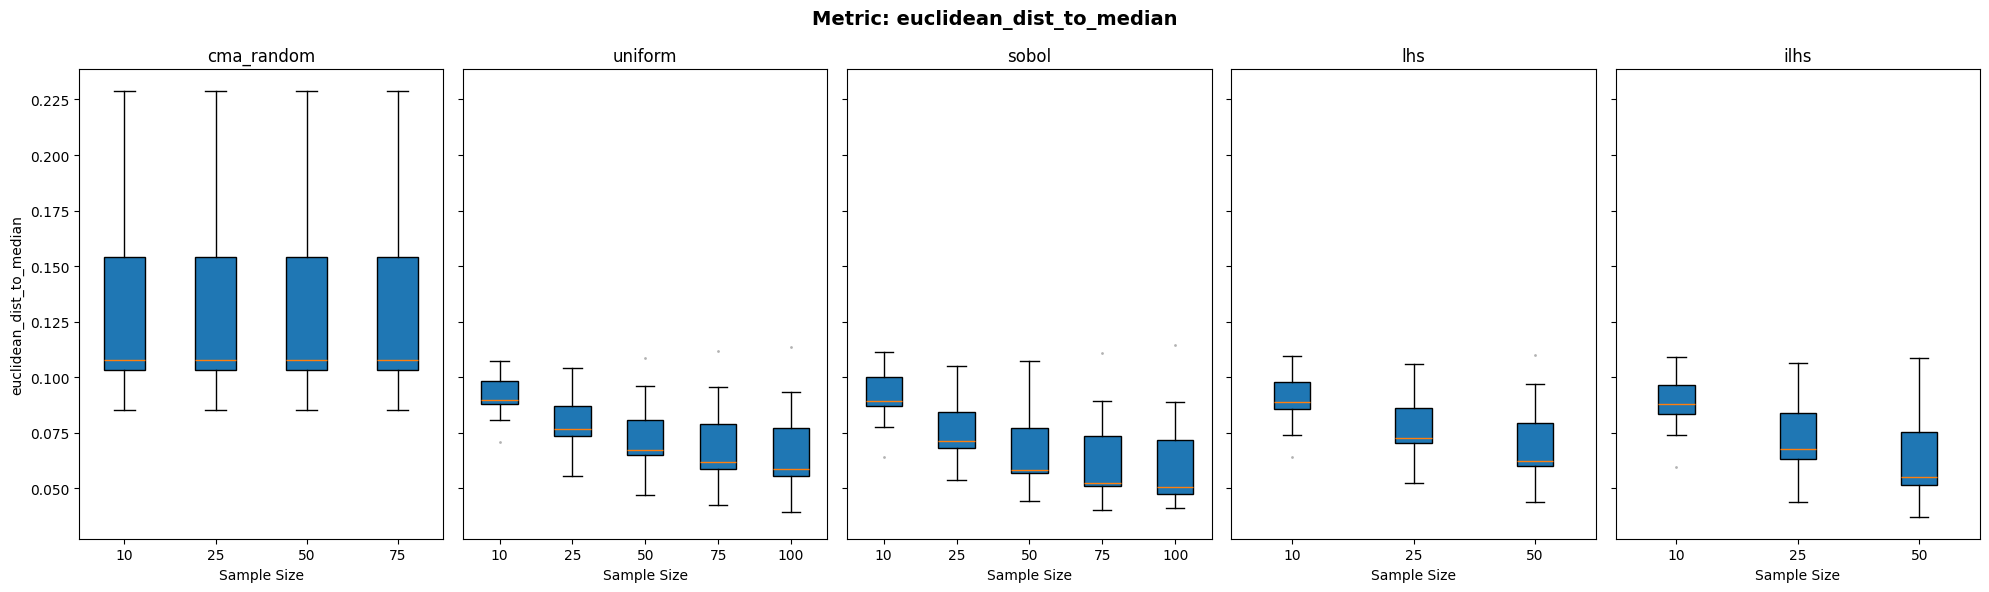

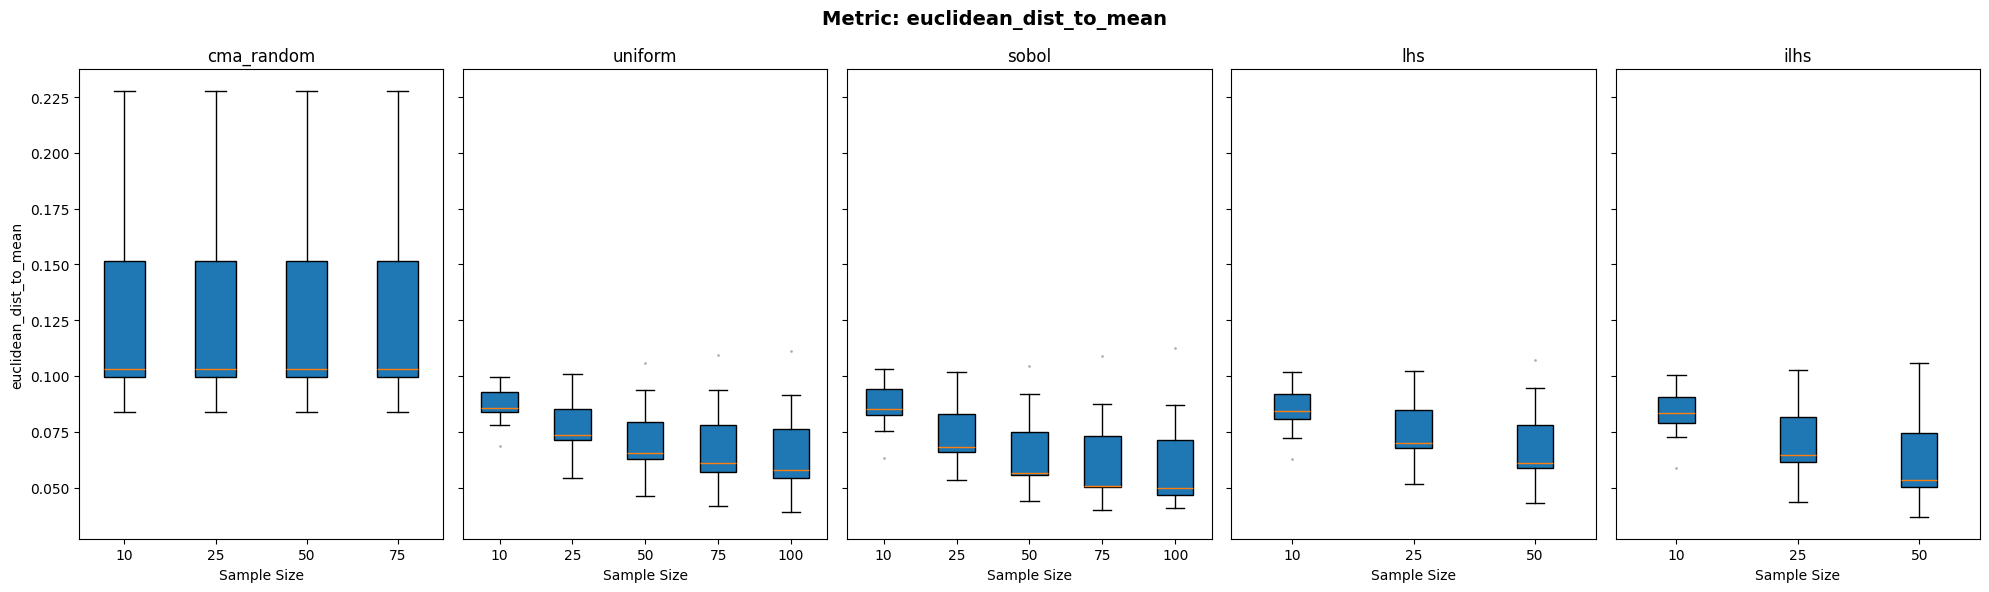

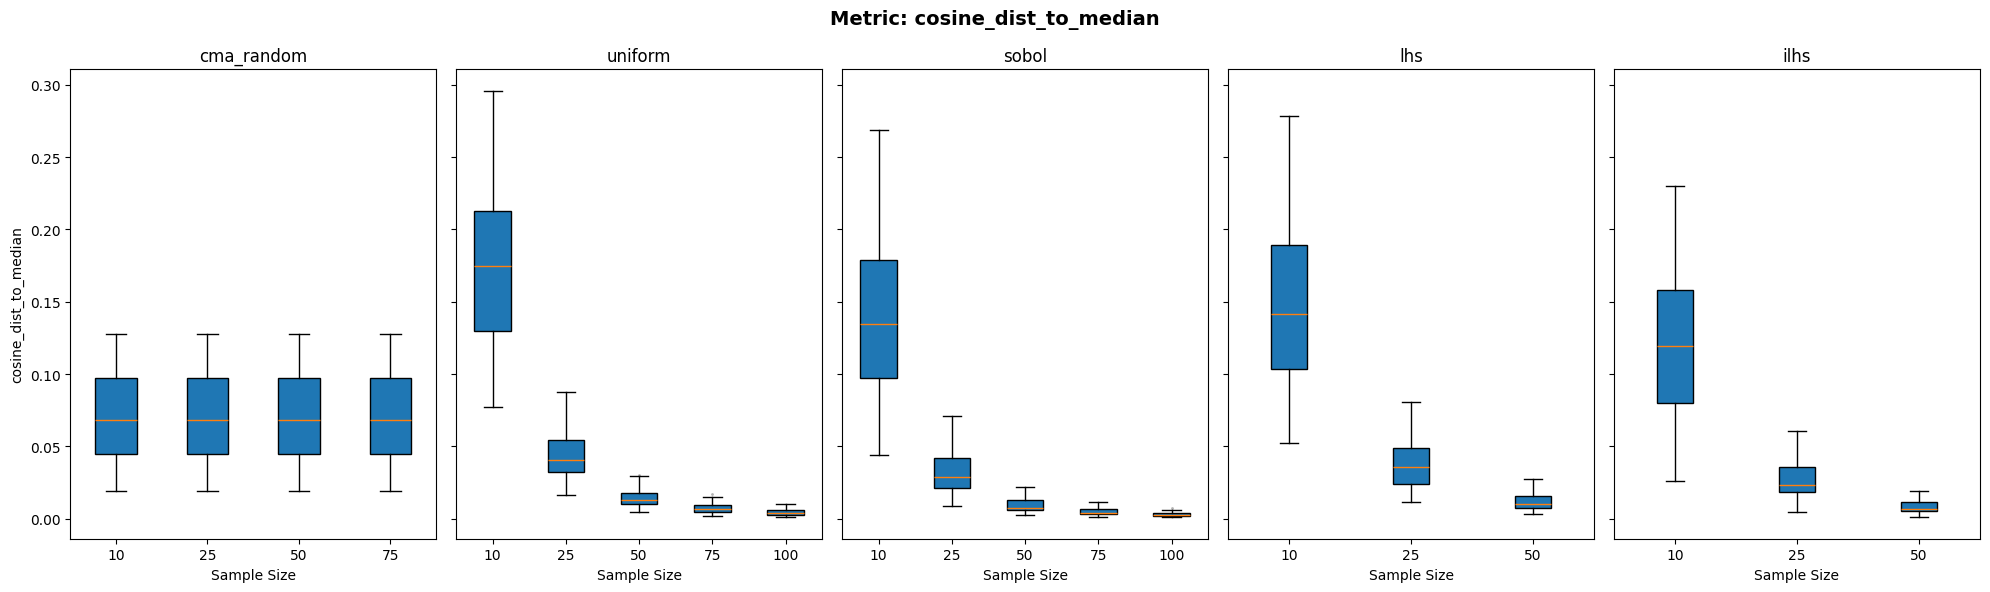

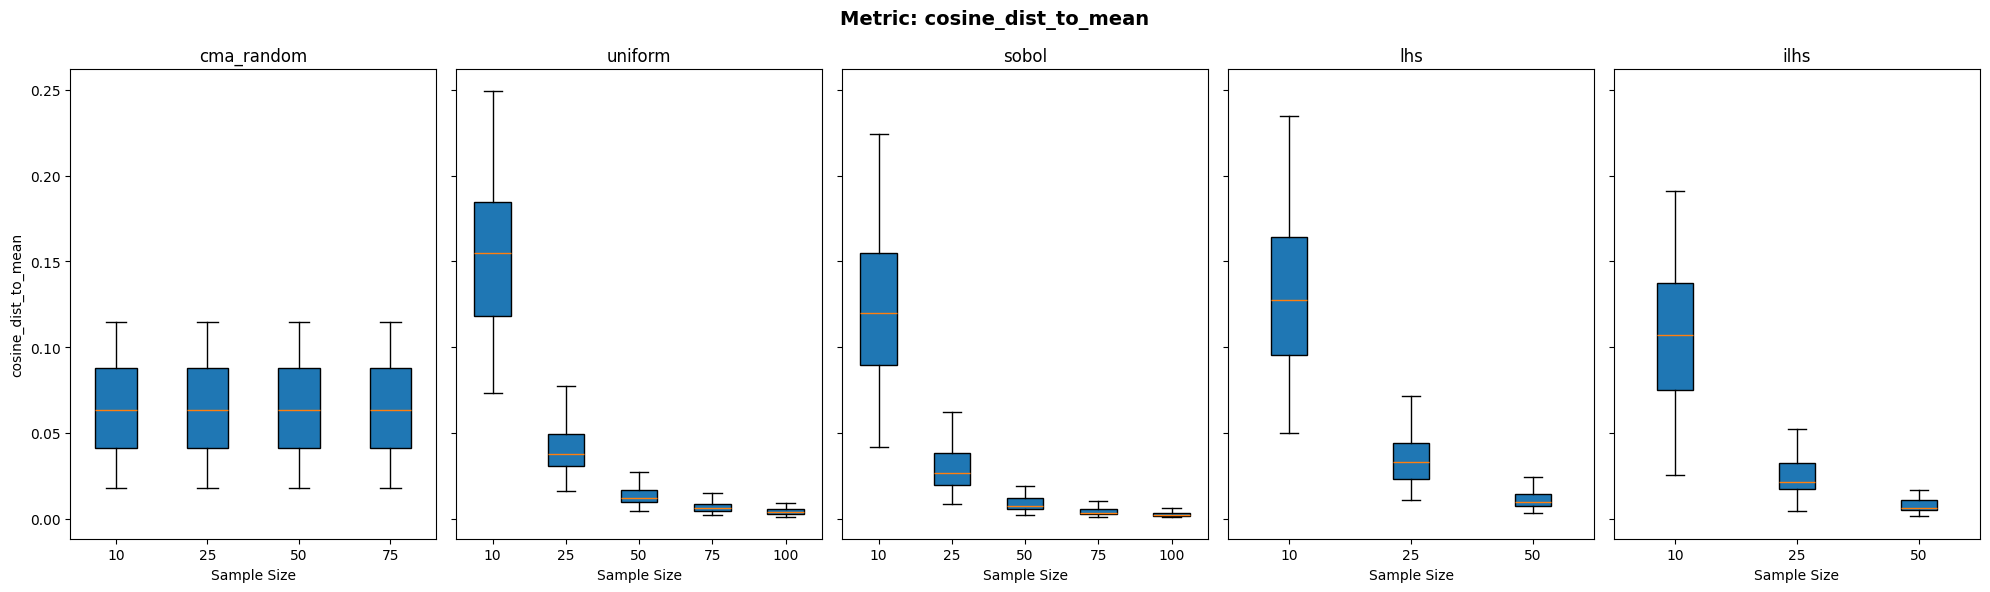

In [4]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

functions = range(1, 25)
instances = range(1, 101)
dimension = 2

sample_methods = ['cma_random', 'uniform', 'sobol', 'lhs', 'ilhs']
sample_sizes = [10, 25, 50, 75, 100]
metrics = [
    'euclidean_dist_to_median',
    'euclidean_dist_to_mean',
    'cosine_dist_to_median',
    'cosine_dist_to_mean'
]

with h5py.File(data_dir, 'r') as f:
    for metric in metrics:
        fig, axes = plt.subplots(1, len(sample_methods), figsize=(20, 6), sharey=True)
        fig.suptitle(f'Metric: {metric}', fontsize=14, fontweight='bold')

        for ax, method in zip(axes, sample_methods):
            box_data = []
            valid_sizes = []

            for size in sample_sizes:
                key = f'{method}_{size}'

                if key not in f:
                    continue

                method_grp = f[key]

                # Step 1: average per instance, then average per function
                function_means = []

                for function in functions:
                    instance_means = []

                    for instance in instances:
                        instance_key = f'{function}_{instance}_{dimension}'

                        if instance_key not in method_grp:
                            continue

                        try:
                            values = method_grp[instance_key]['all'][metric][:]
                            # Average across runs for this instance
                            instance_mean = np.mean(values.flatten())
                            instance_means.append(instance_mean)
                        except KeyError:
                            continue

                    # Average across instances for this function
                    if len(instance_means) > 0:
                        function_means.append(np.mean(instance_means))

                if len(function_means) > 0:
                    box_data.append(function_means)
                    valid_sizes.append(size)

            if len(box_data) > 0:
                ax.boxplot(box_data, labels=valid_sizes, patch_artist=True,
                           flierprops=dict(marker='.', markersize=2, alpha=0.3))
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes)

            ax.set_title(method)
            ax.set_xlabel('Sample Size')
            if ax == axes[0]:
                ax.set_ylabel(metric)

        plt.tight_layout()
        plt.show()

## Each function - instance 1 only

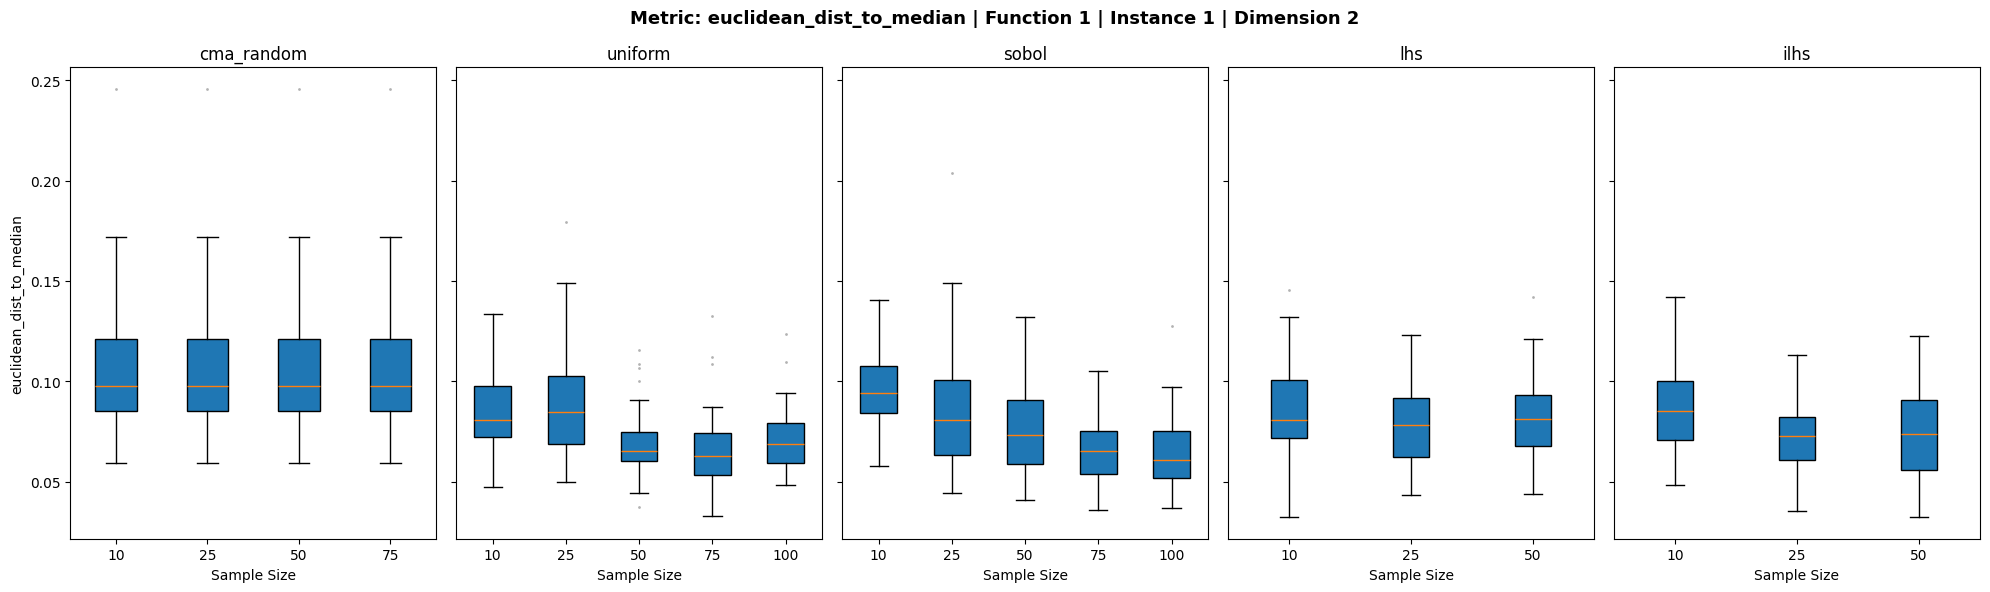

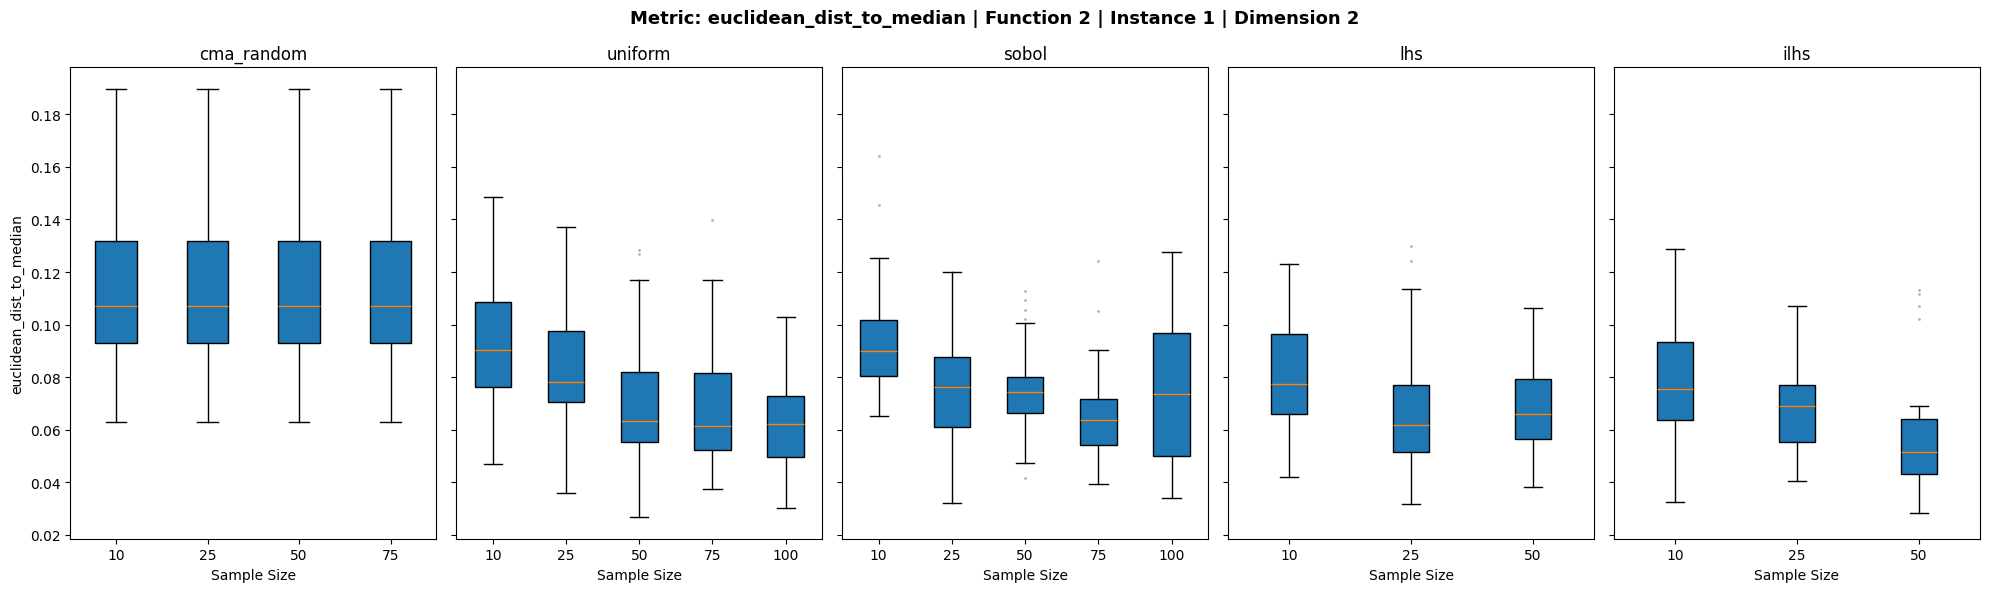

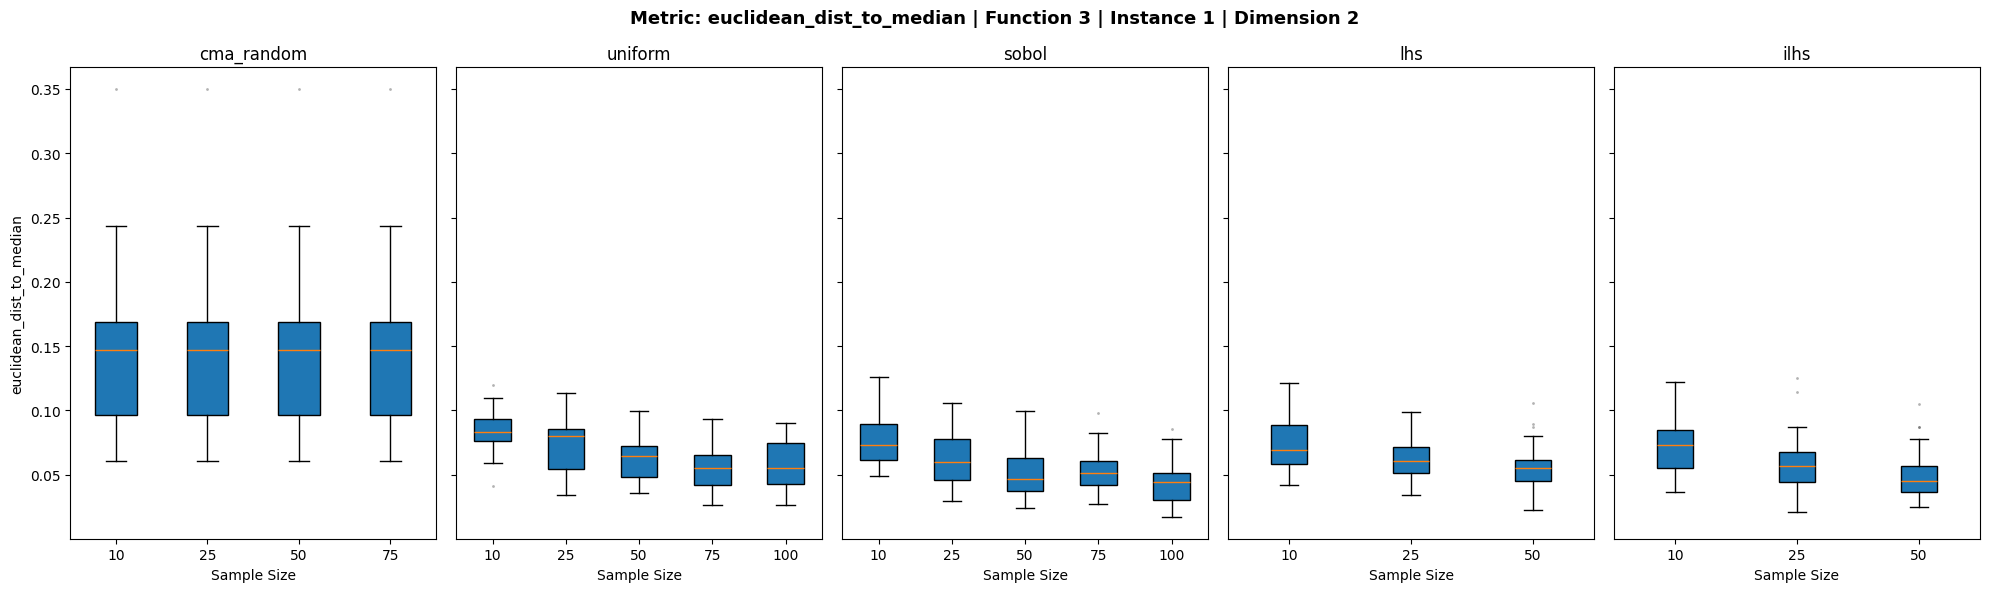

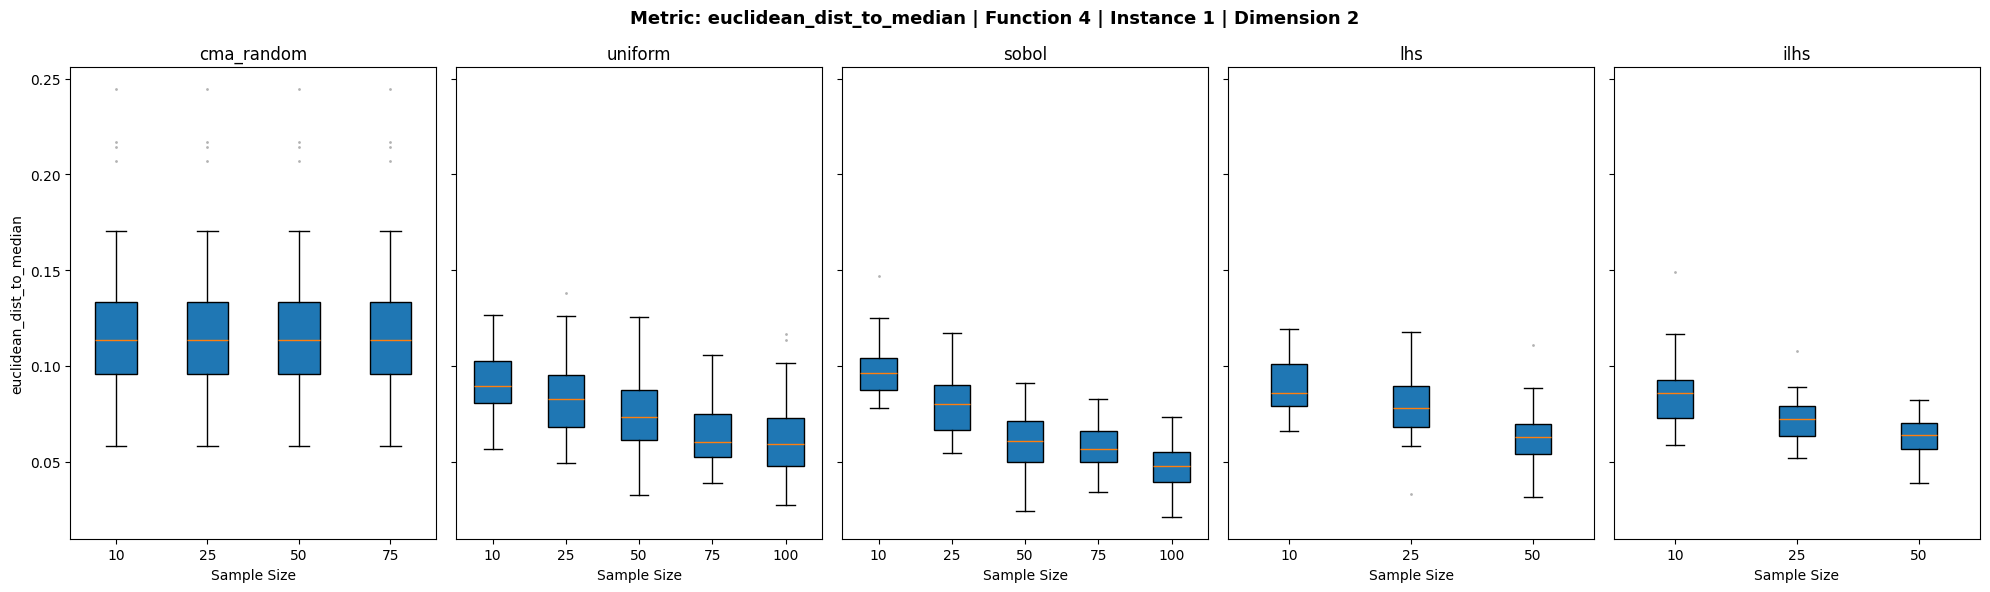

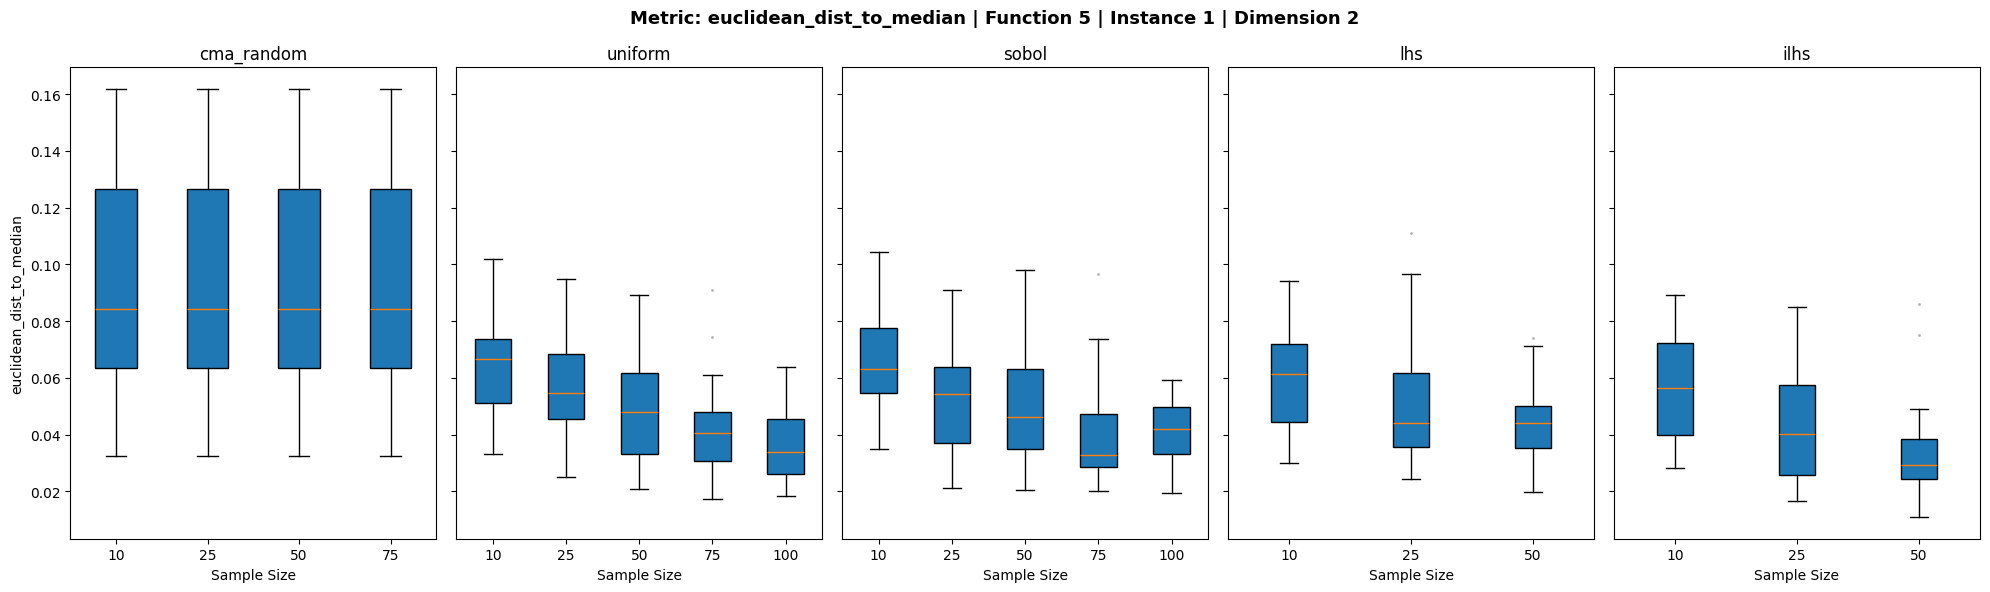

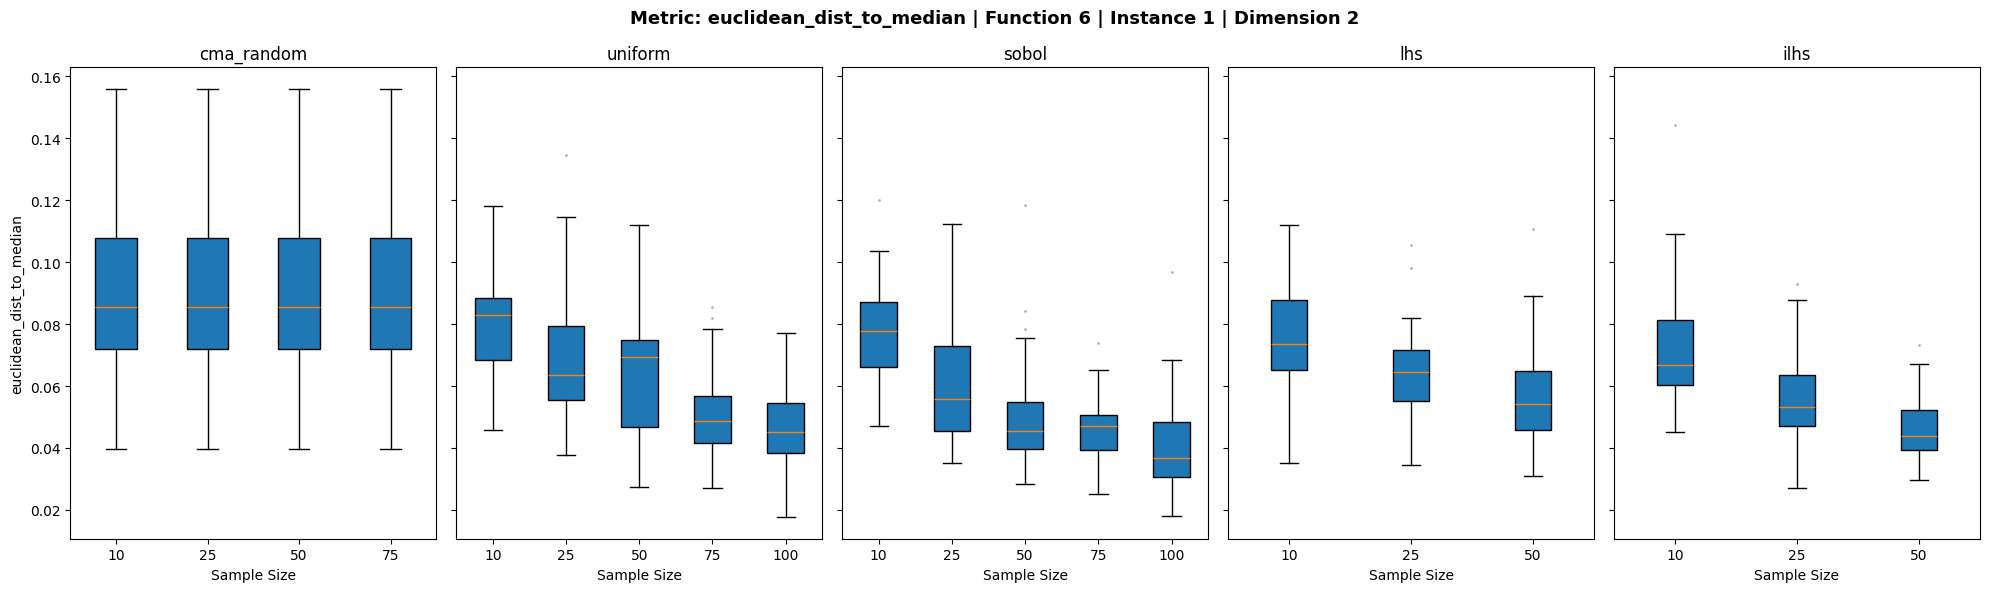

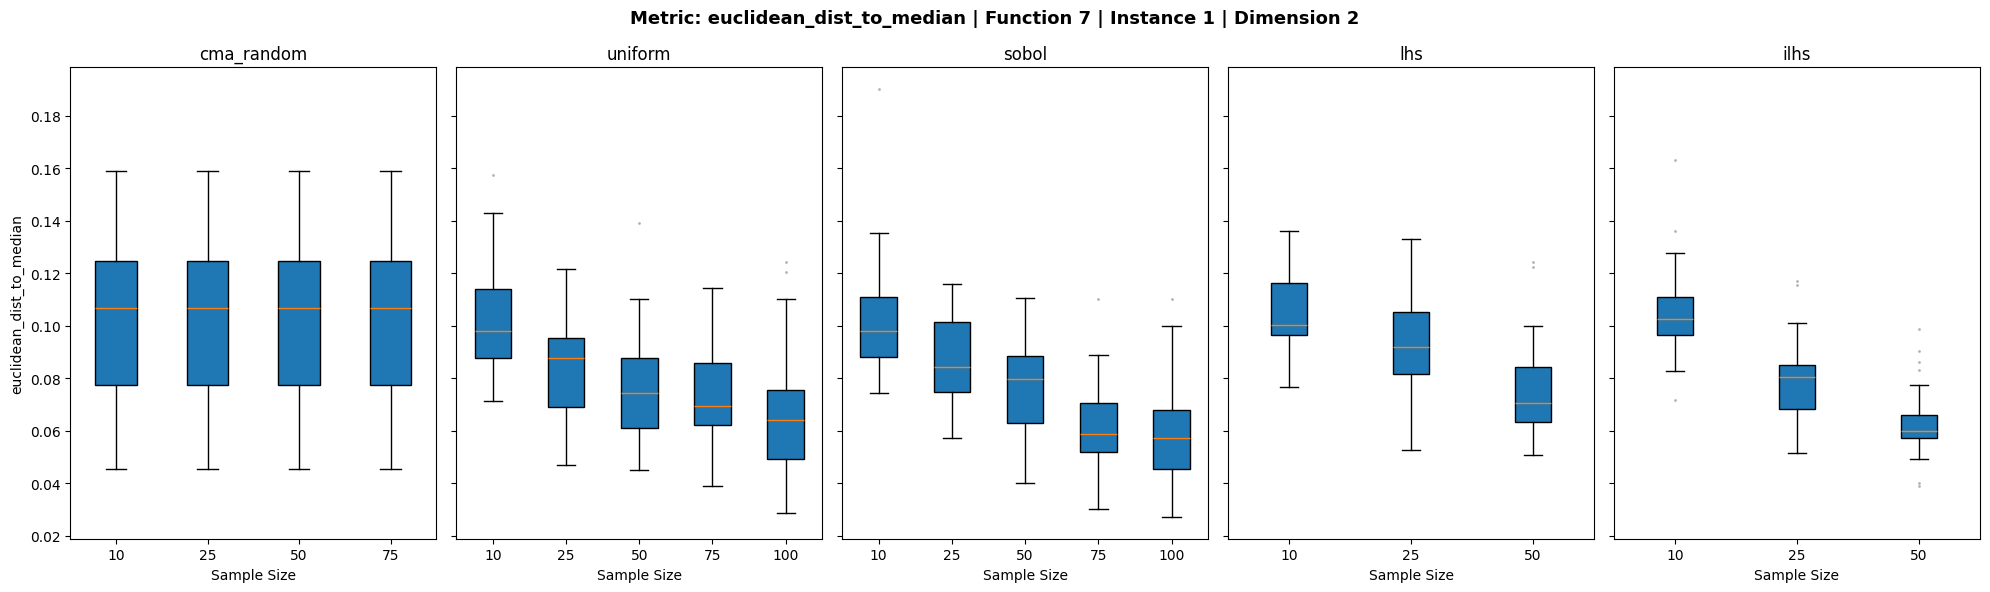

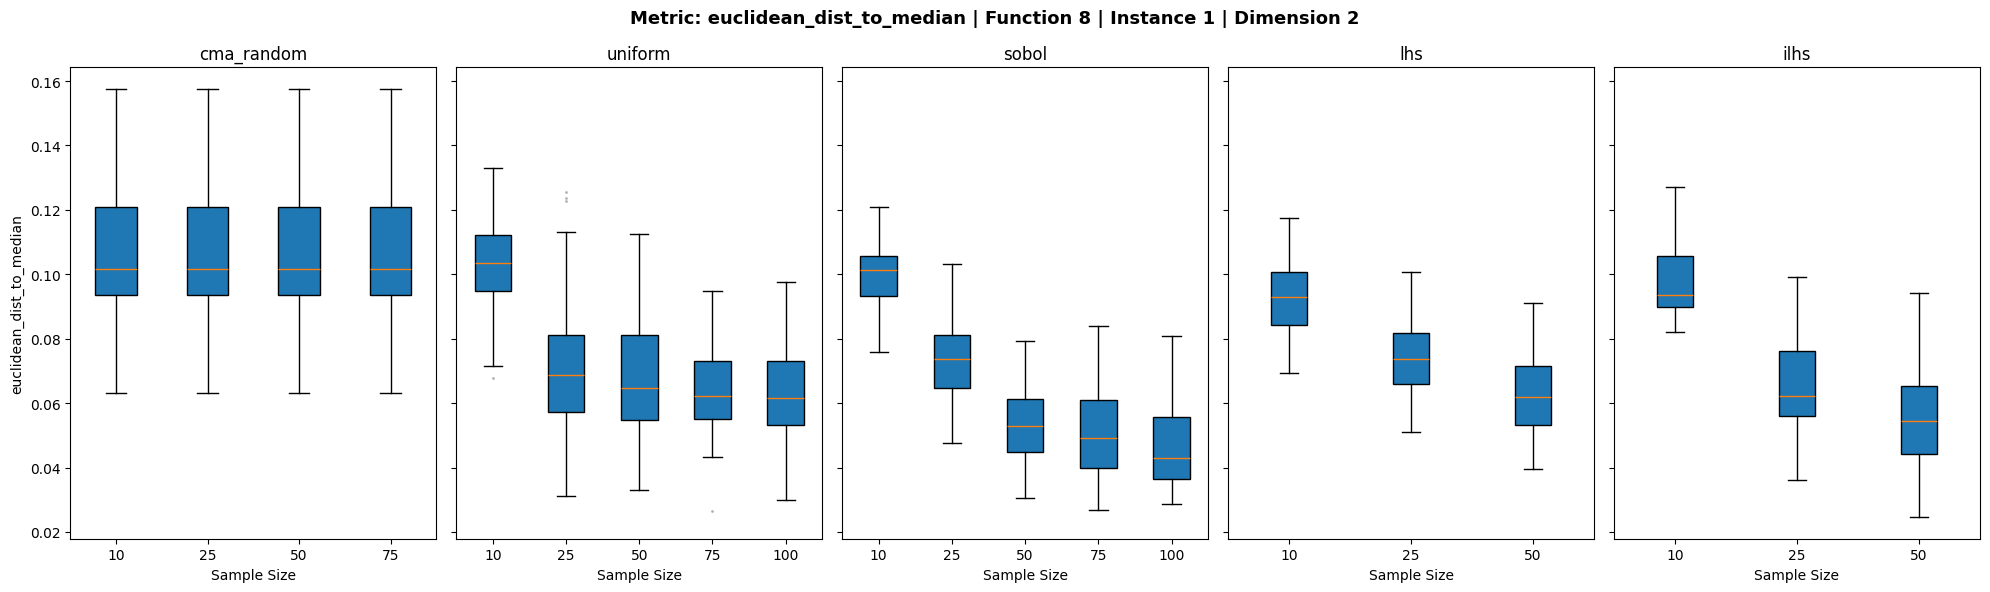

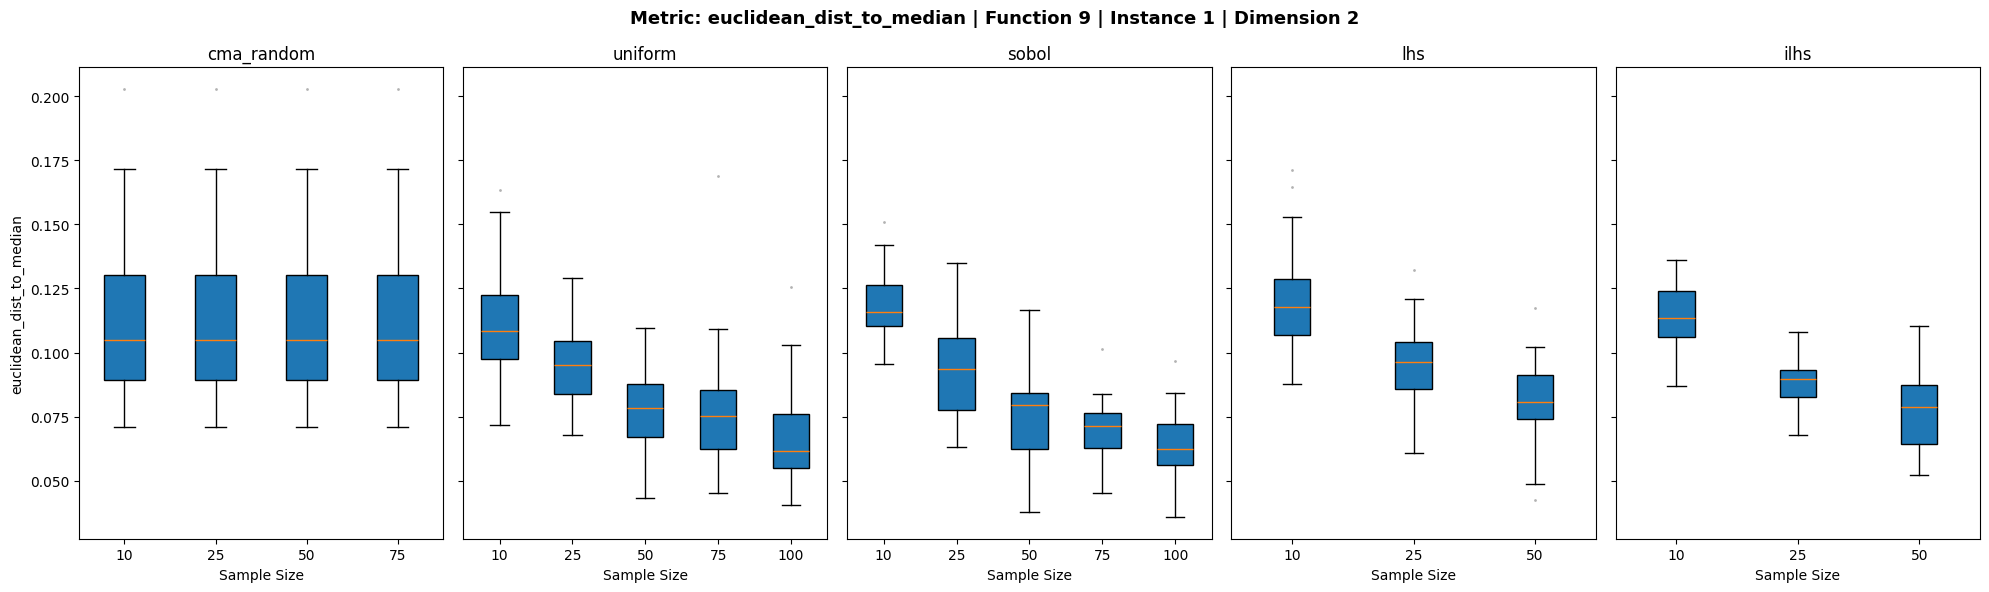

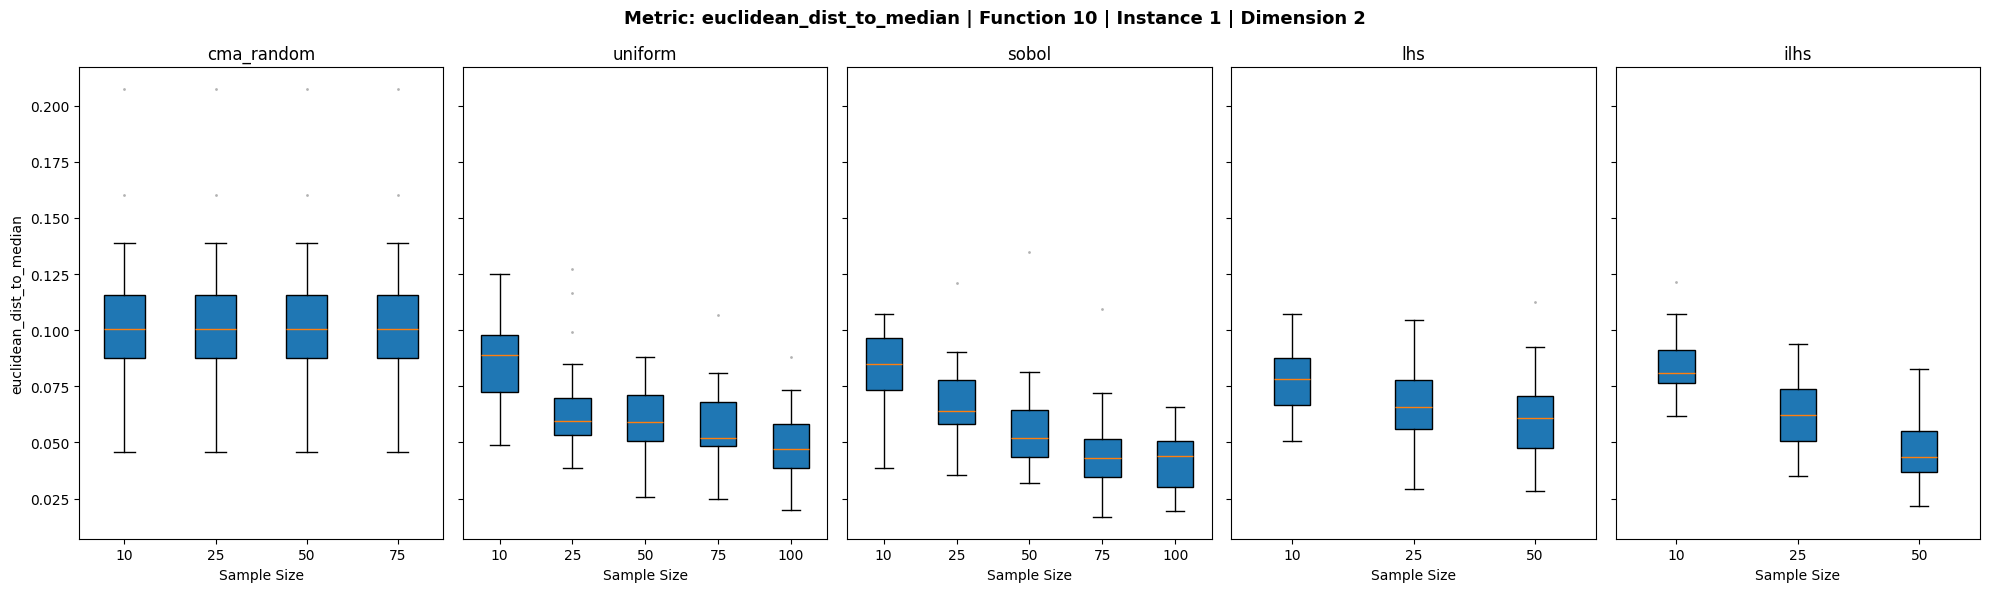

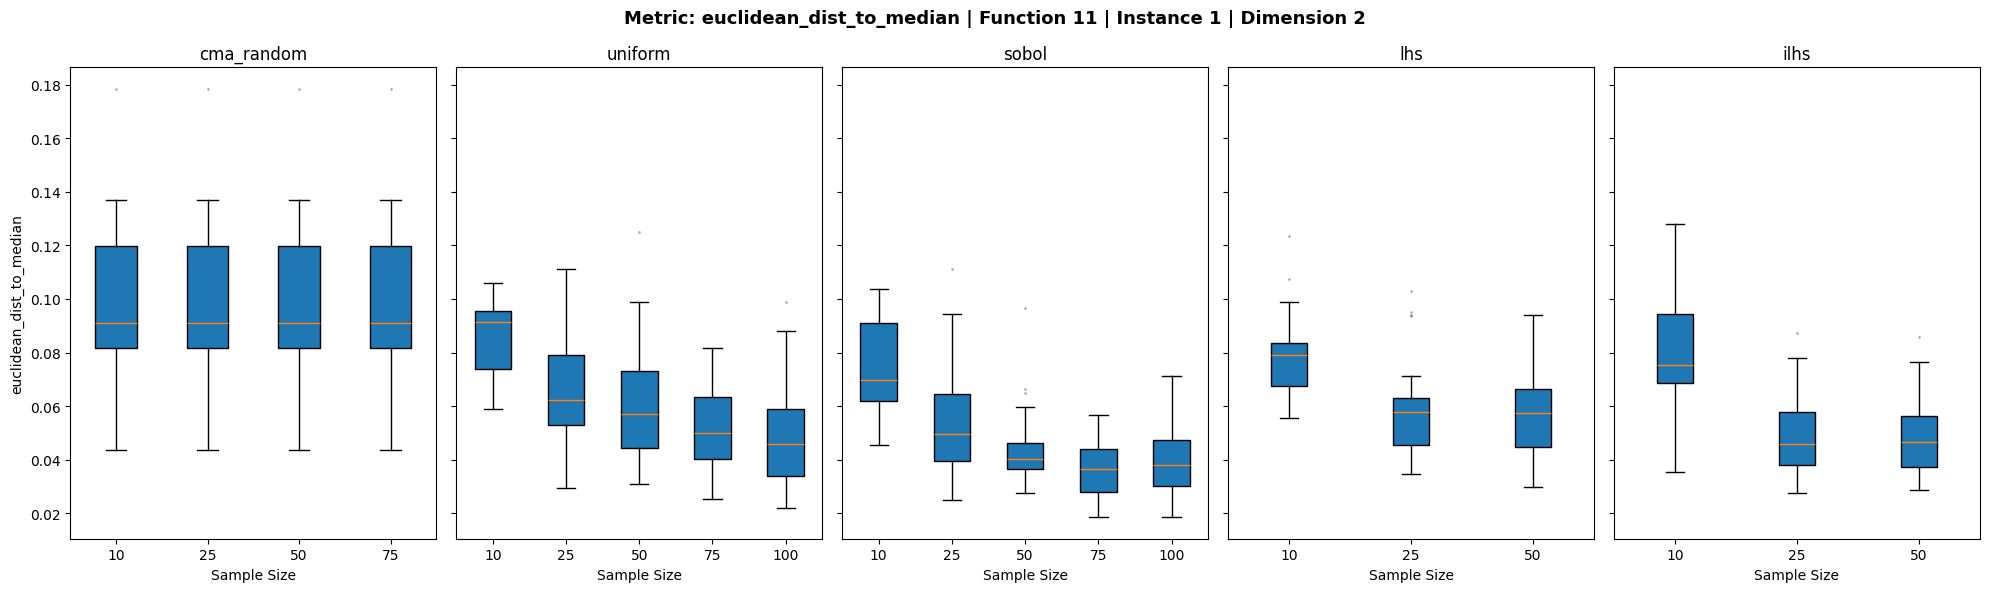

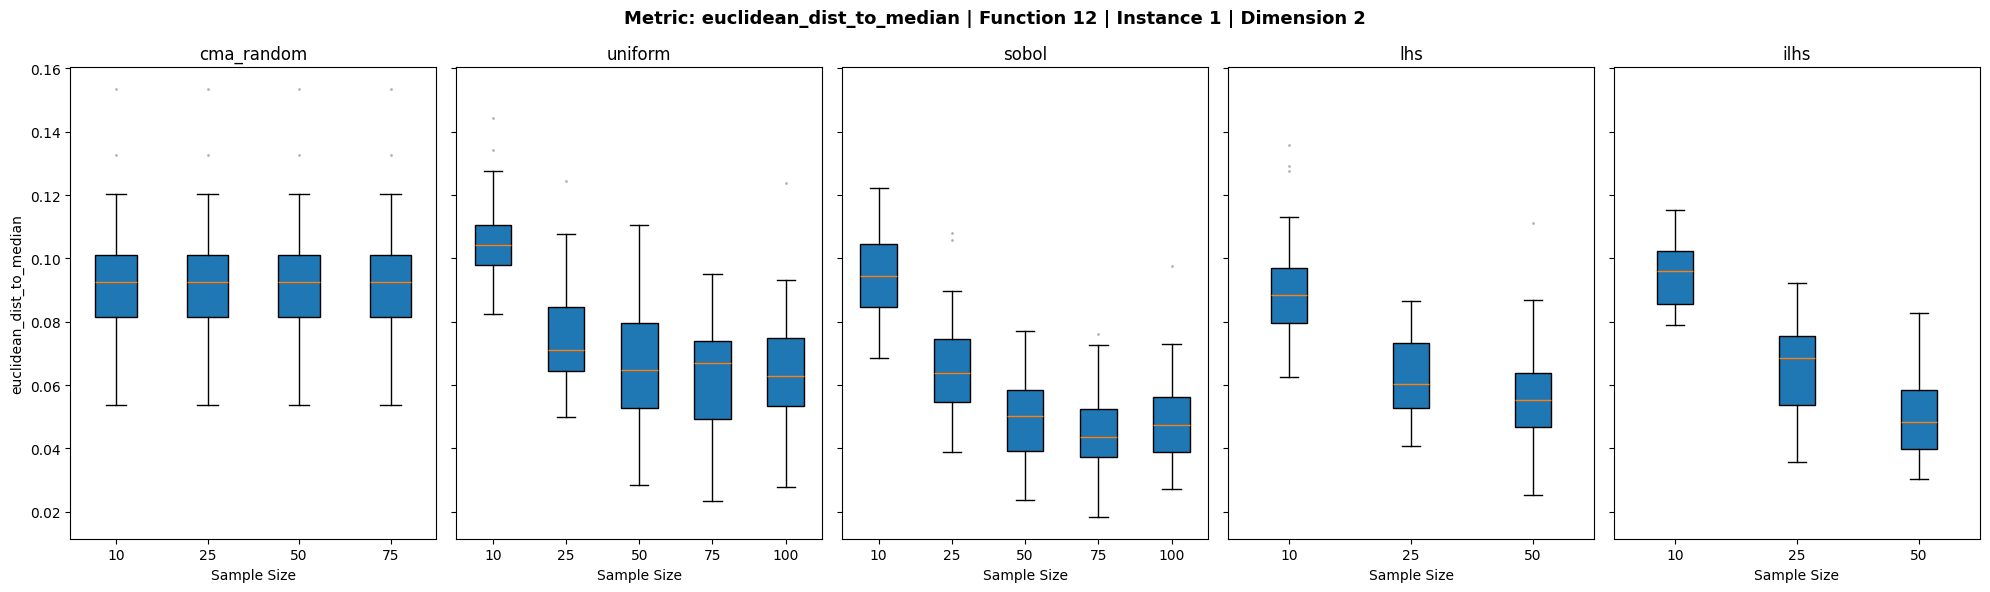

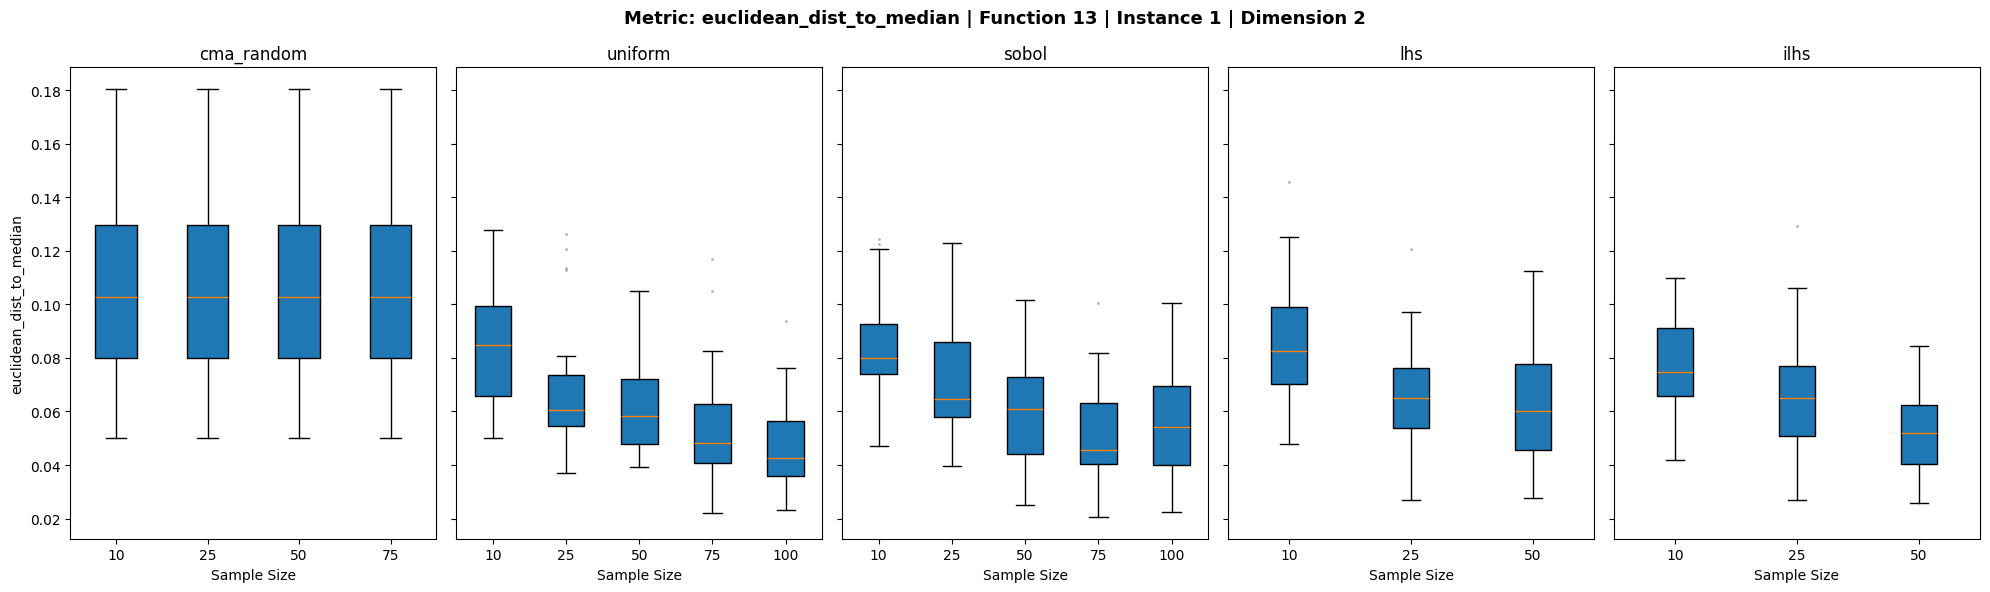

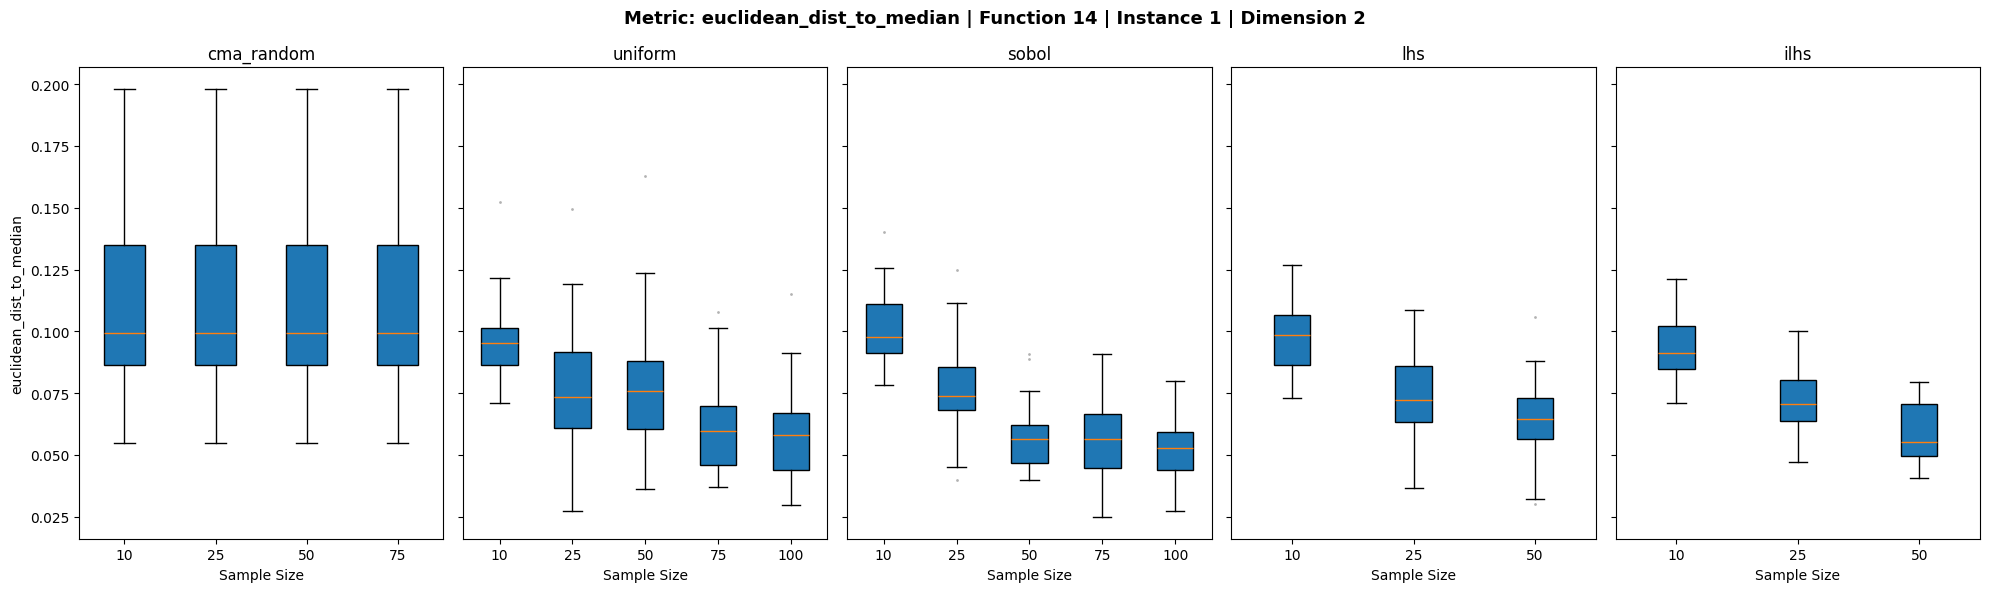

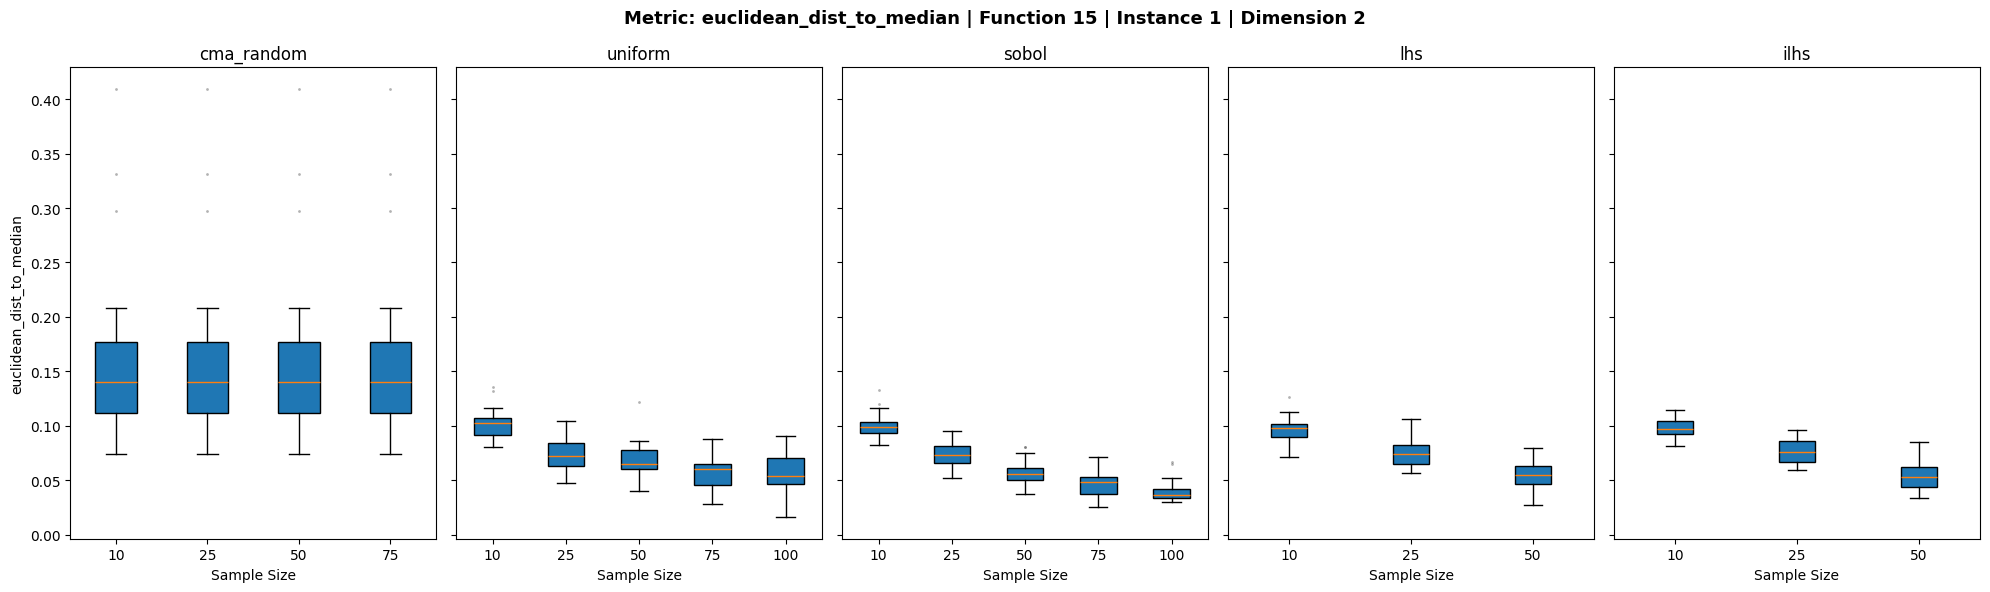

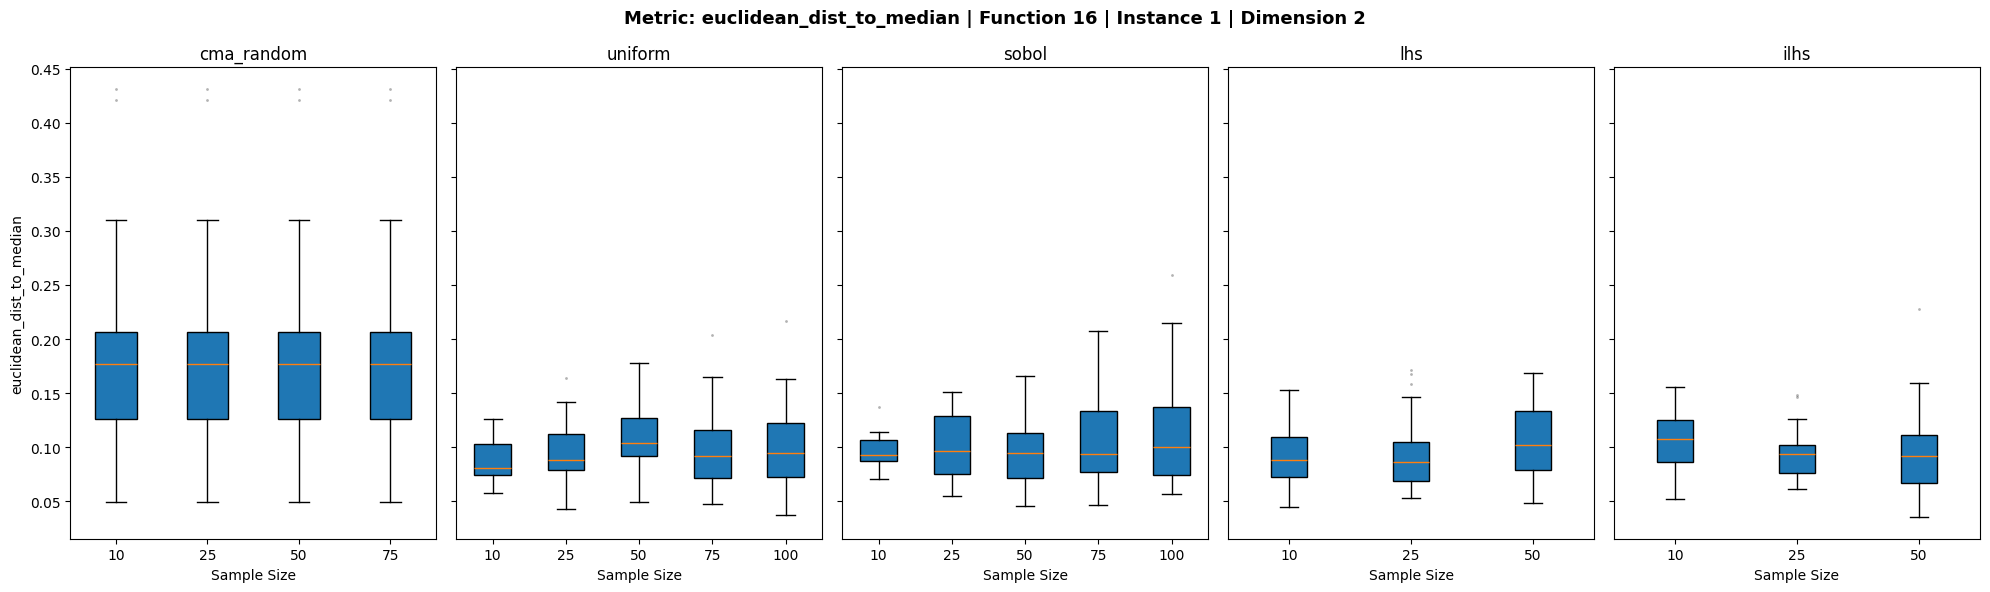

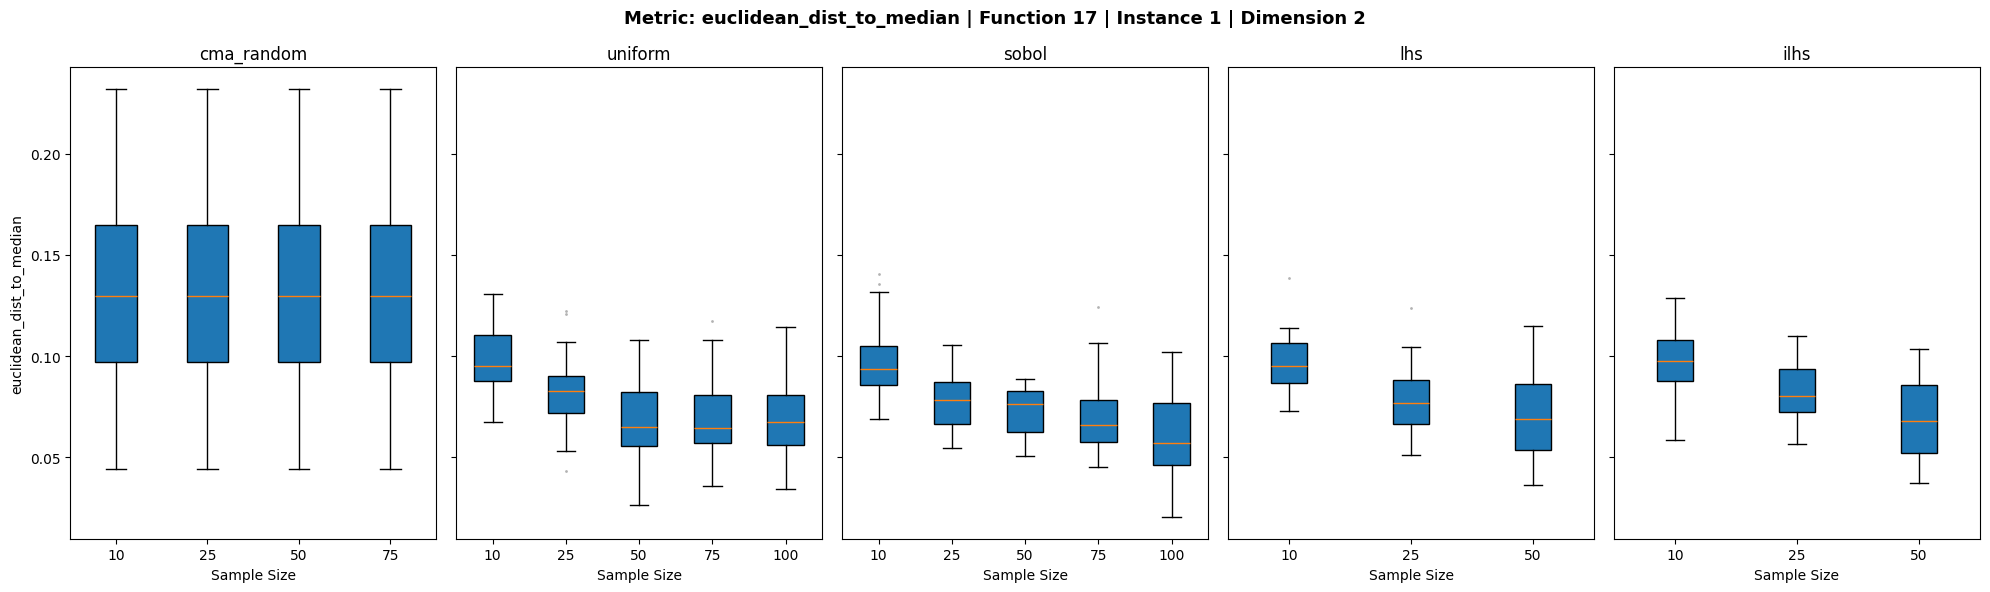

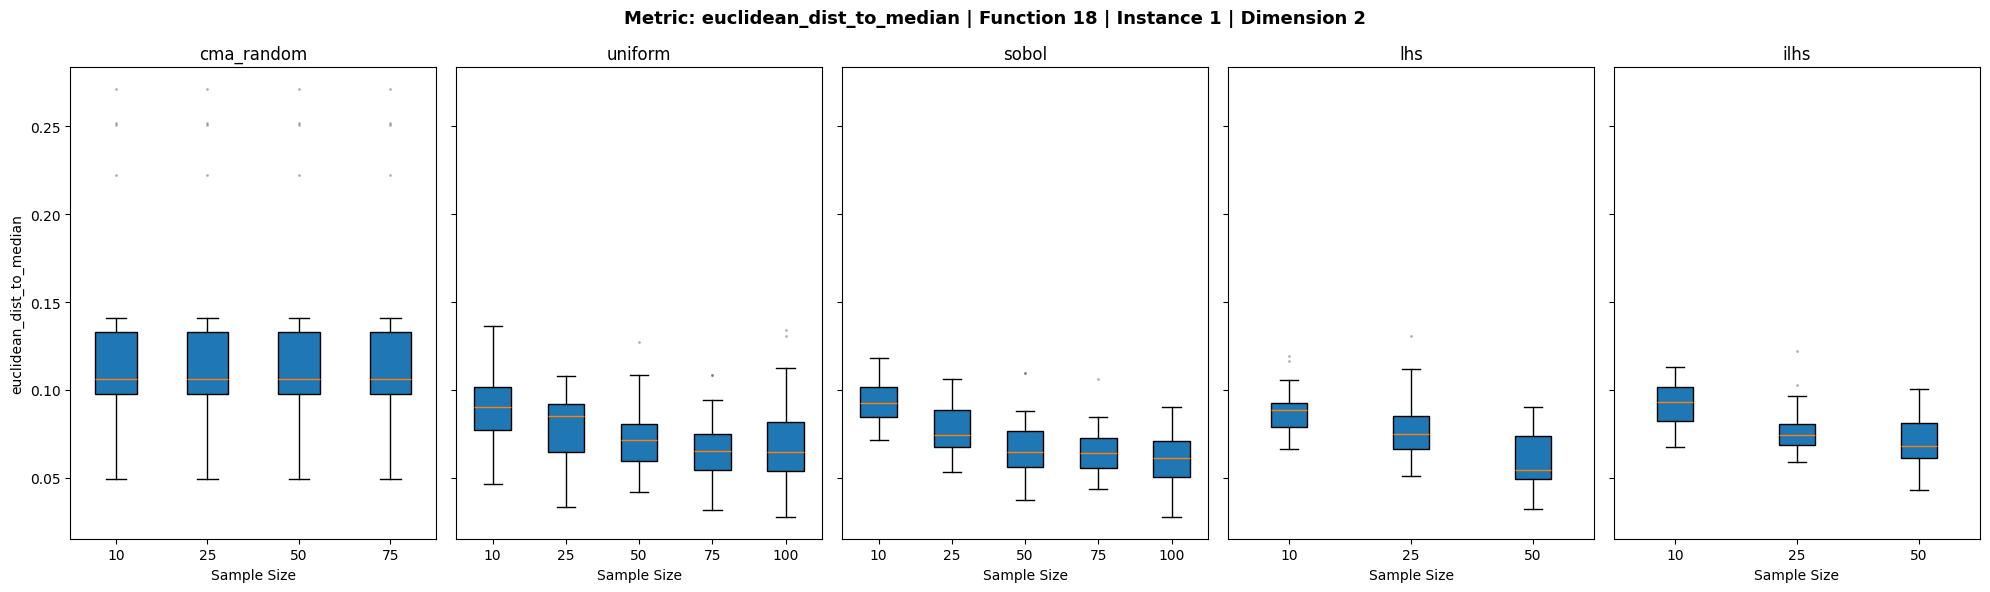

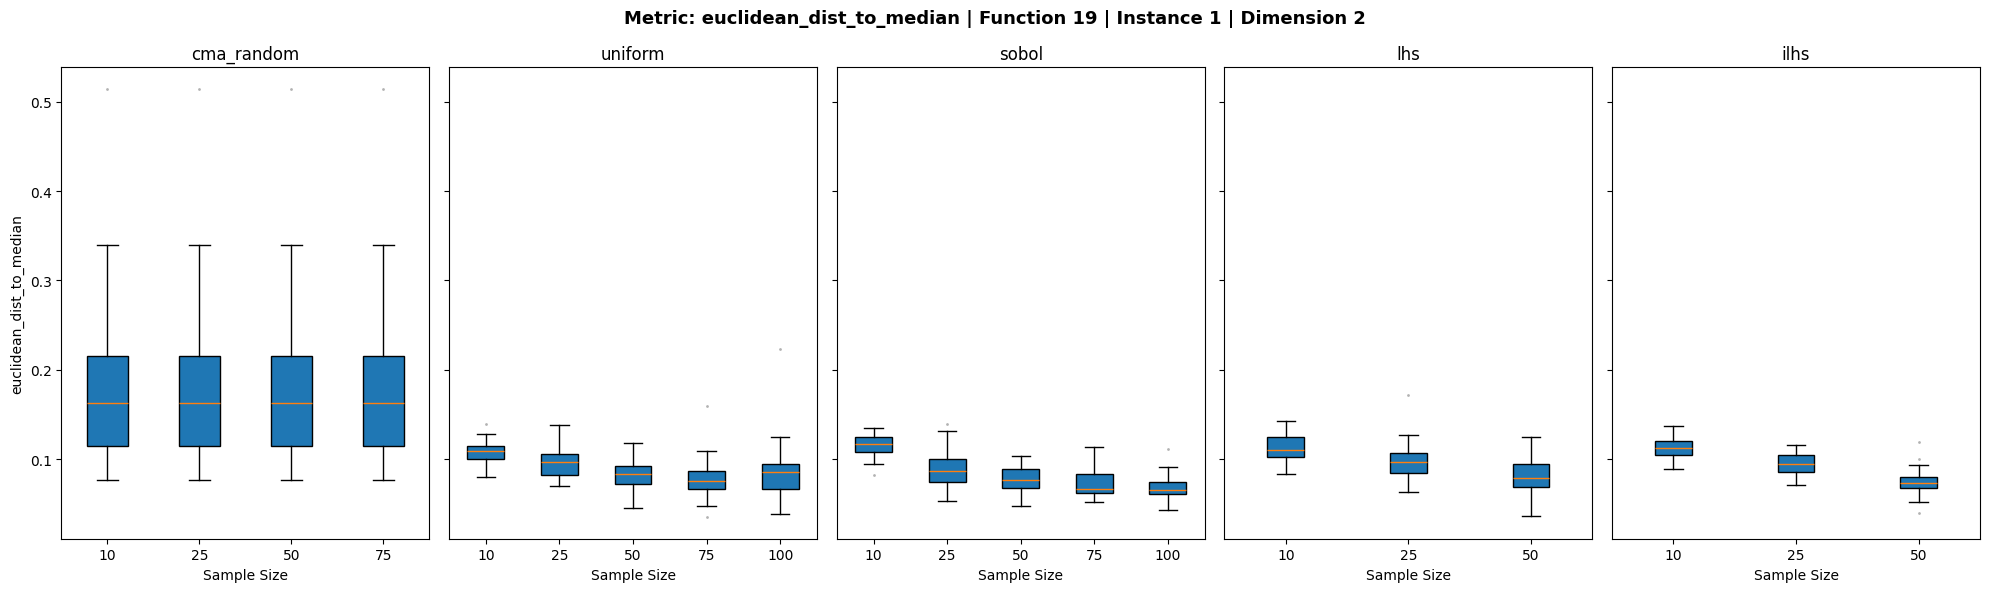

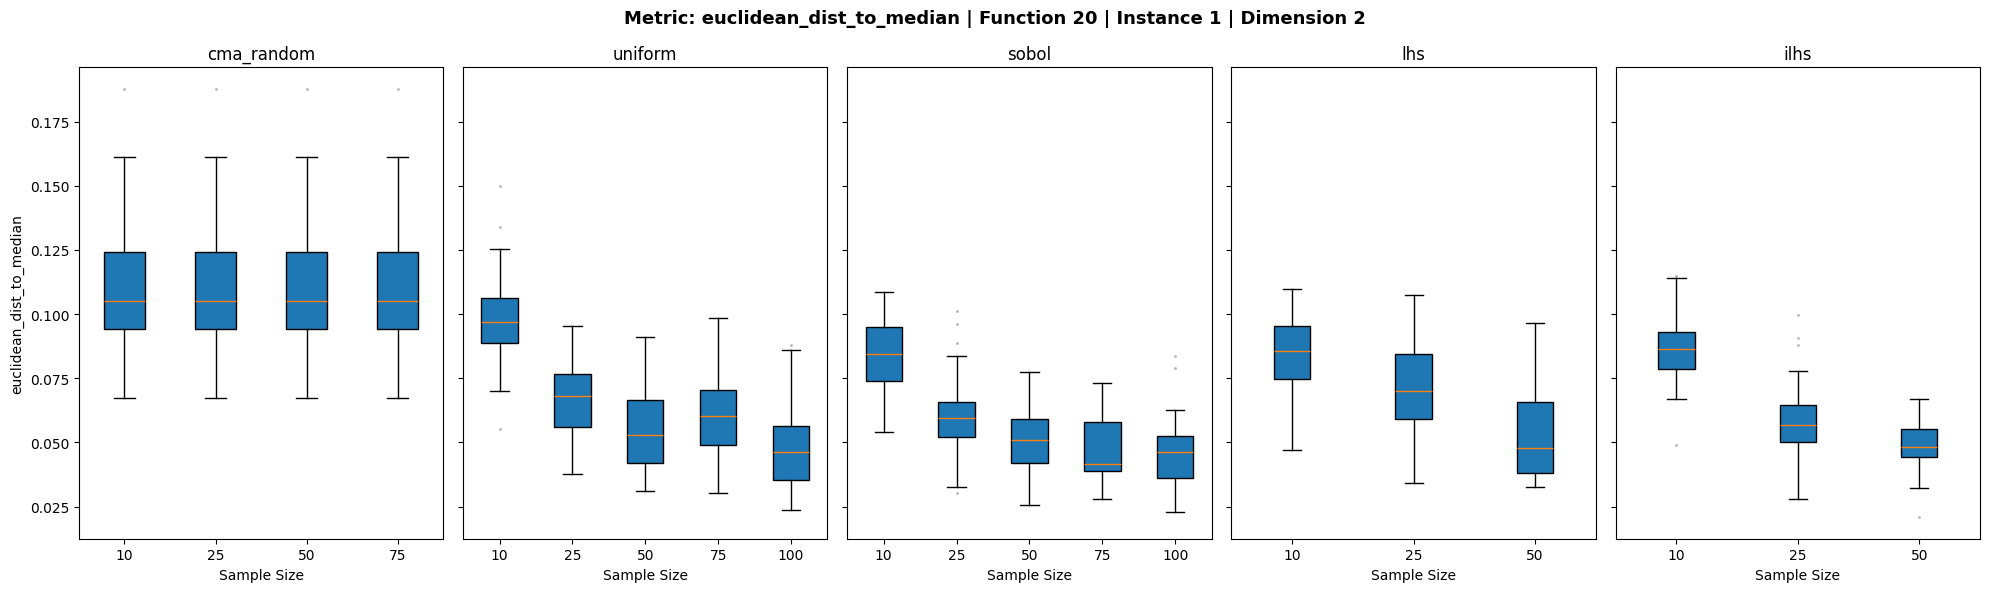

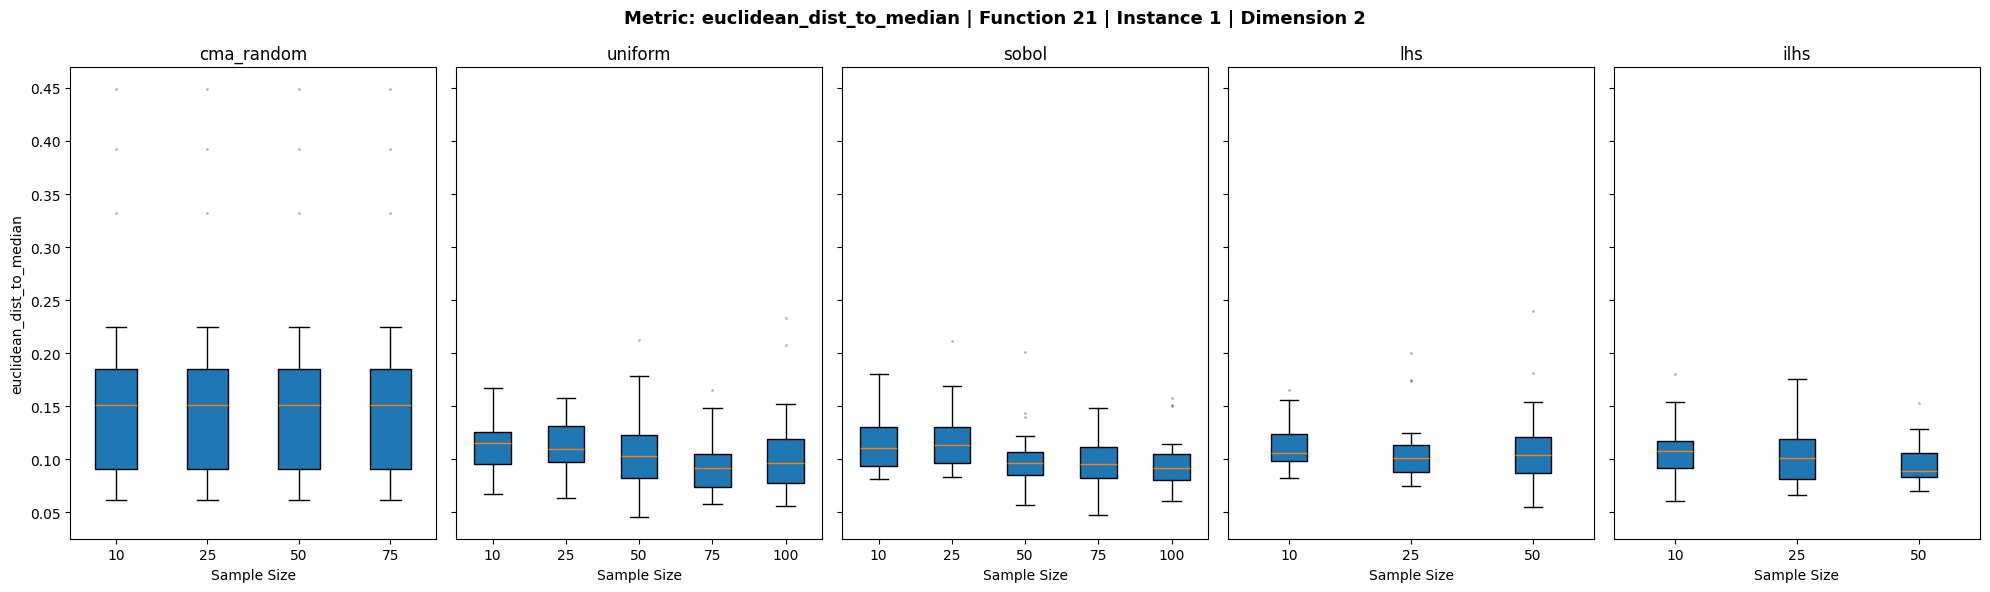

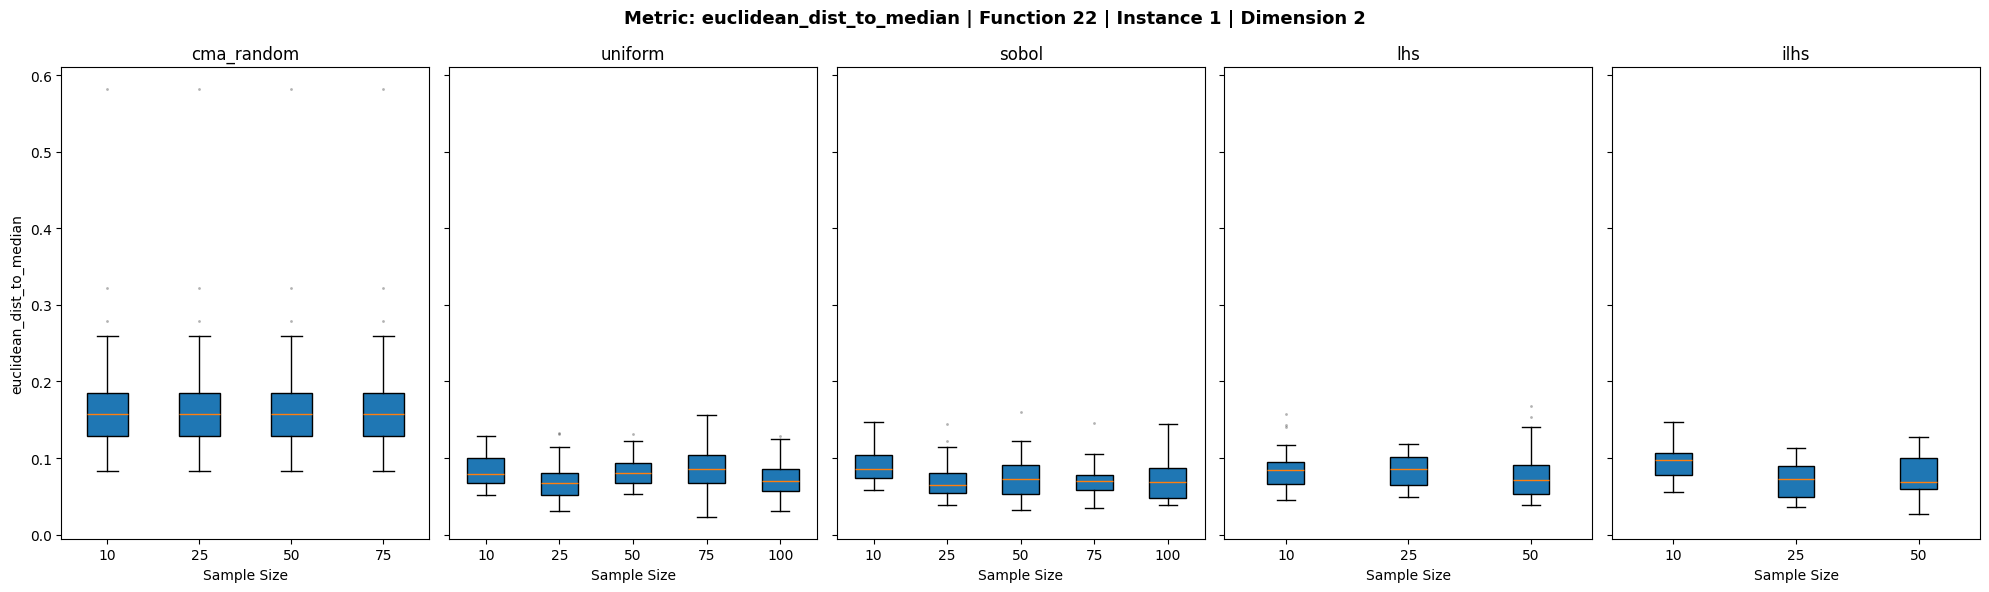

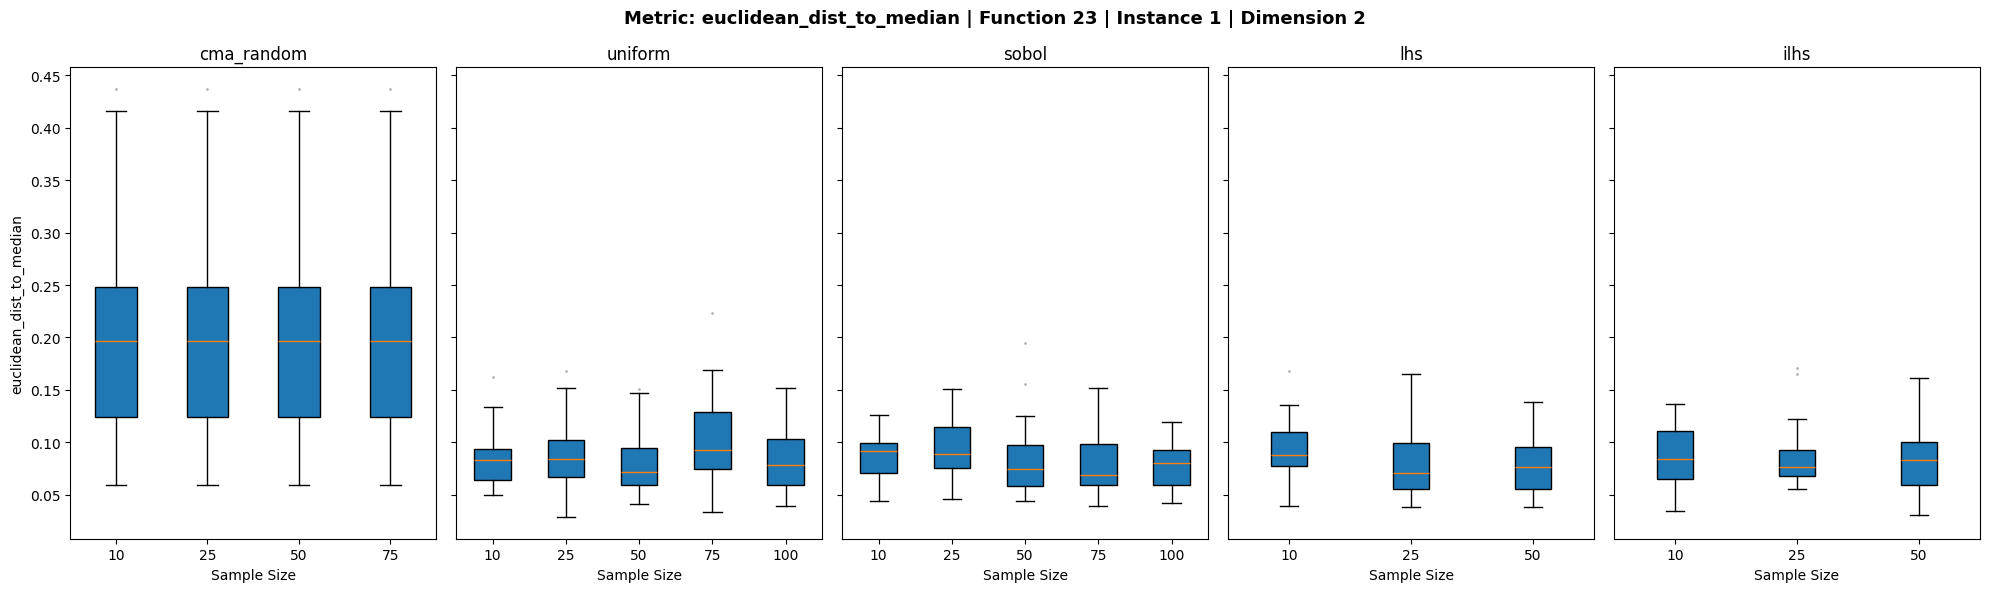

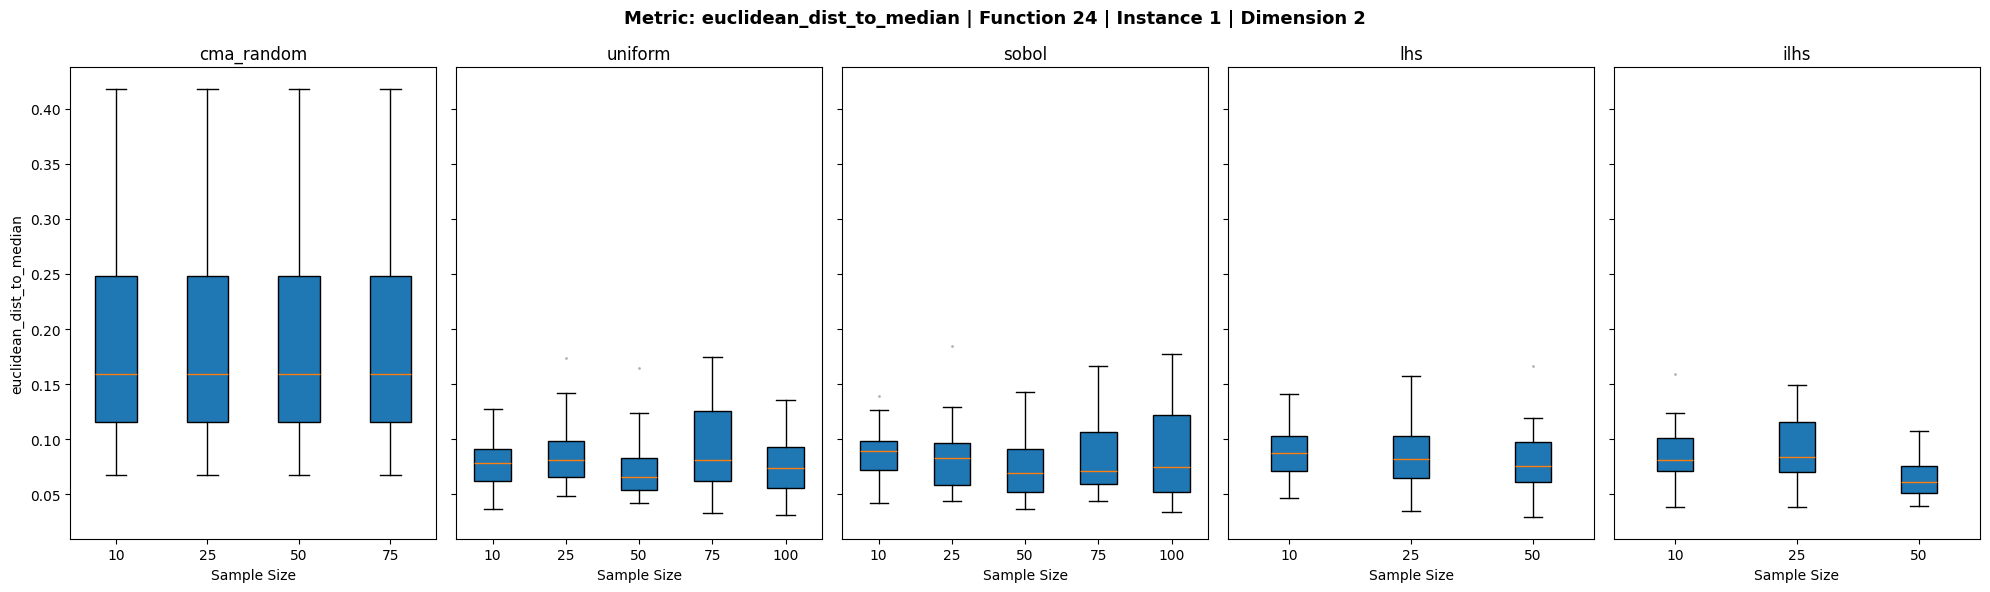

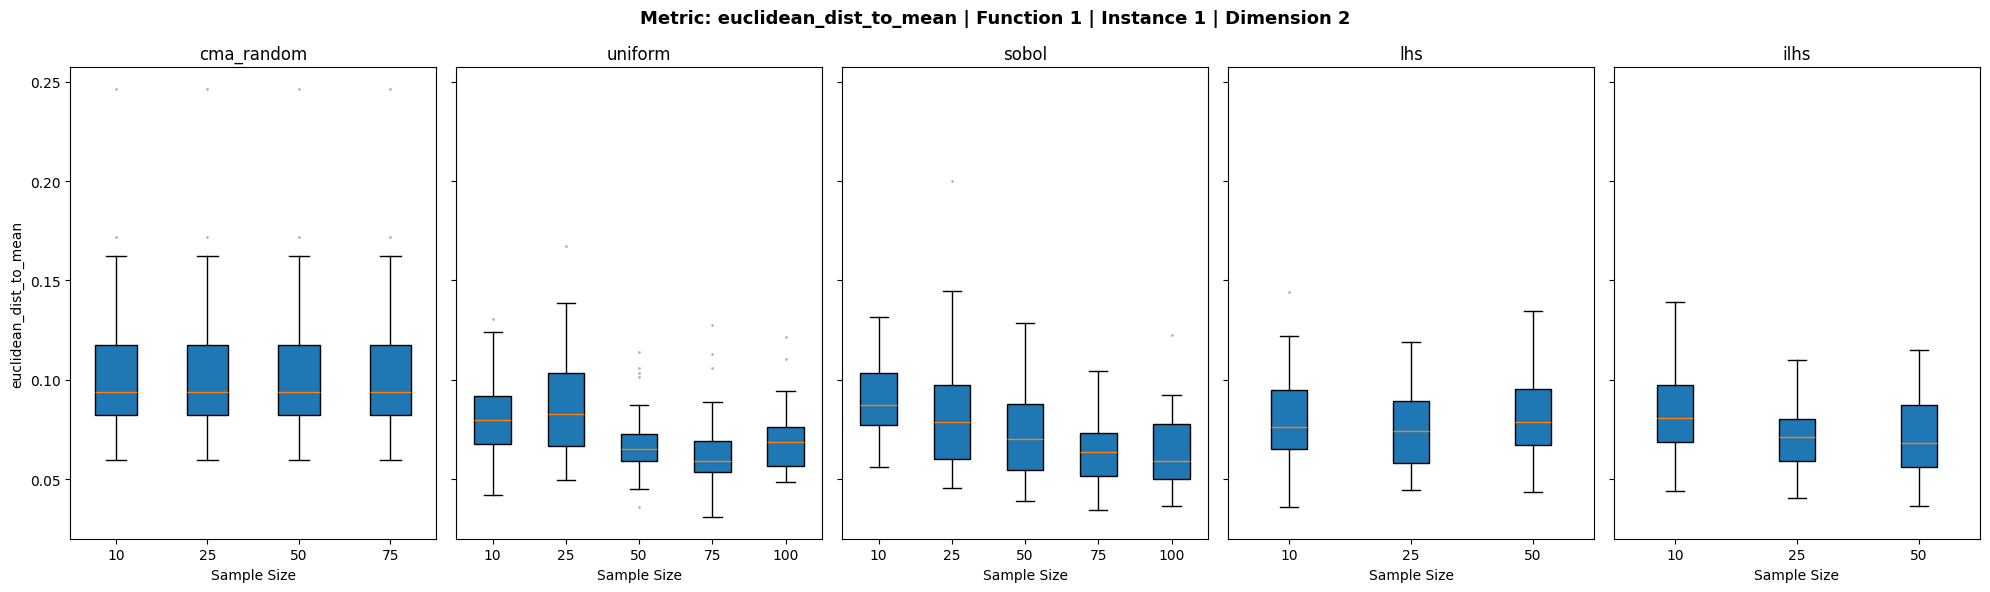

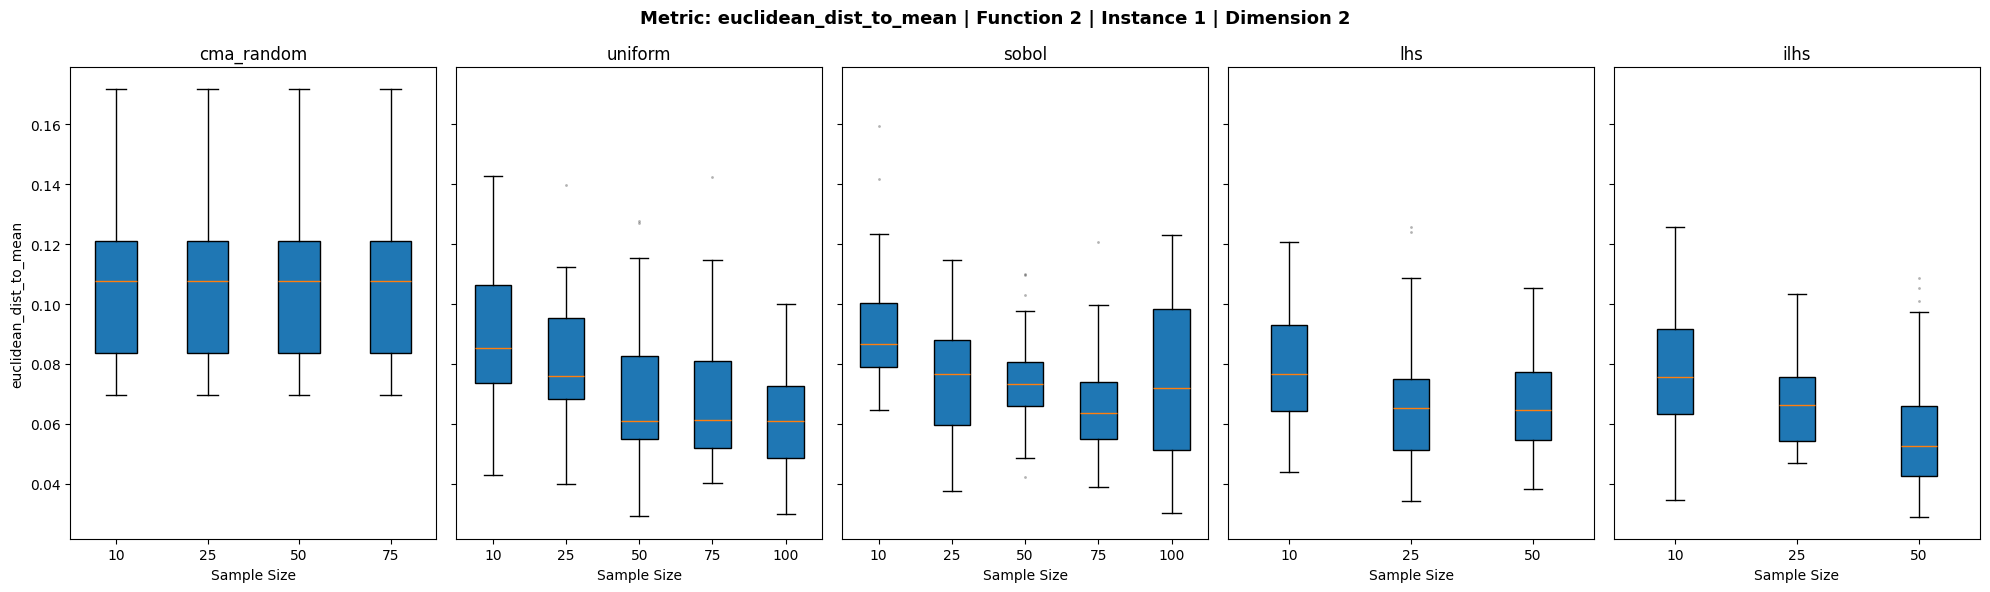

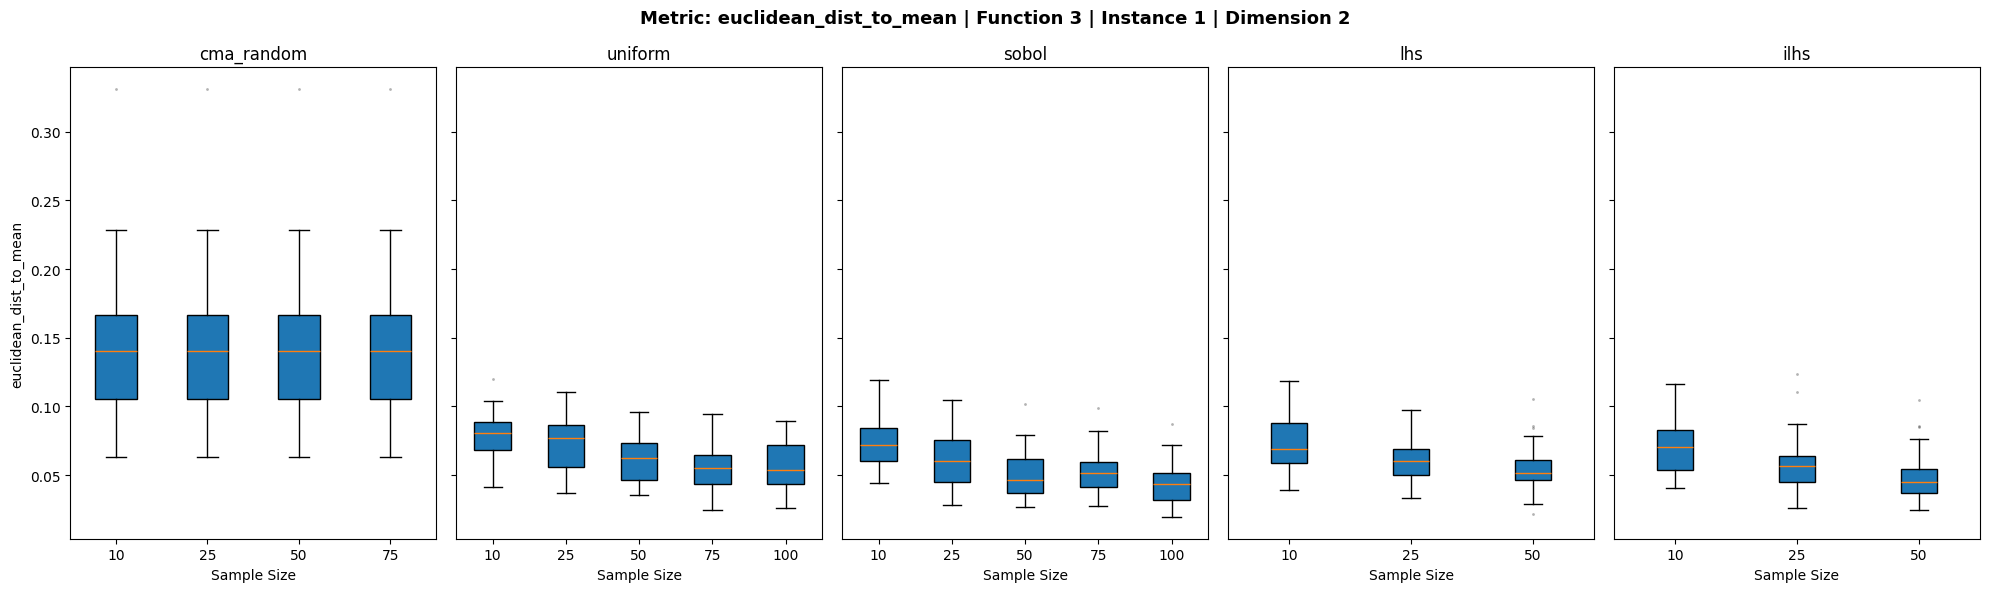

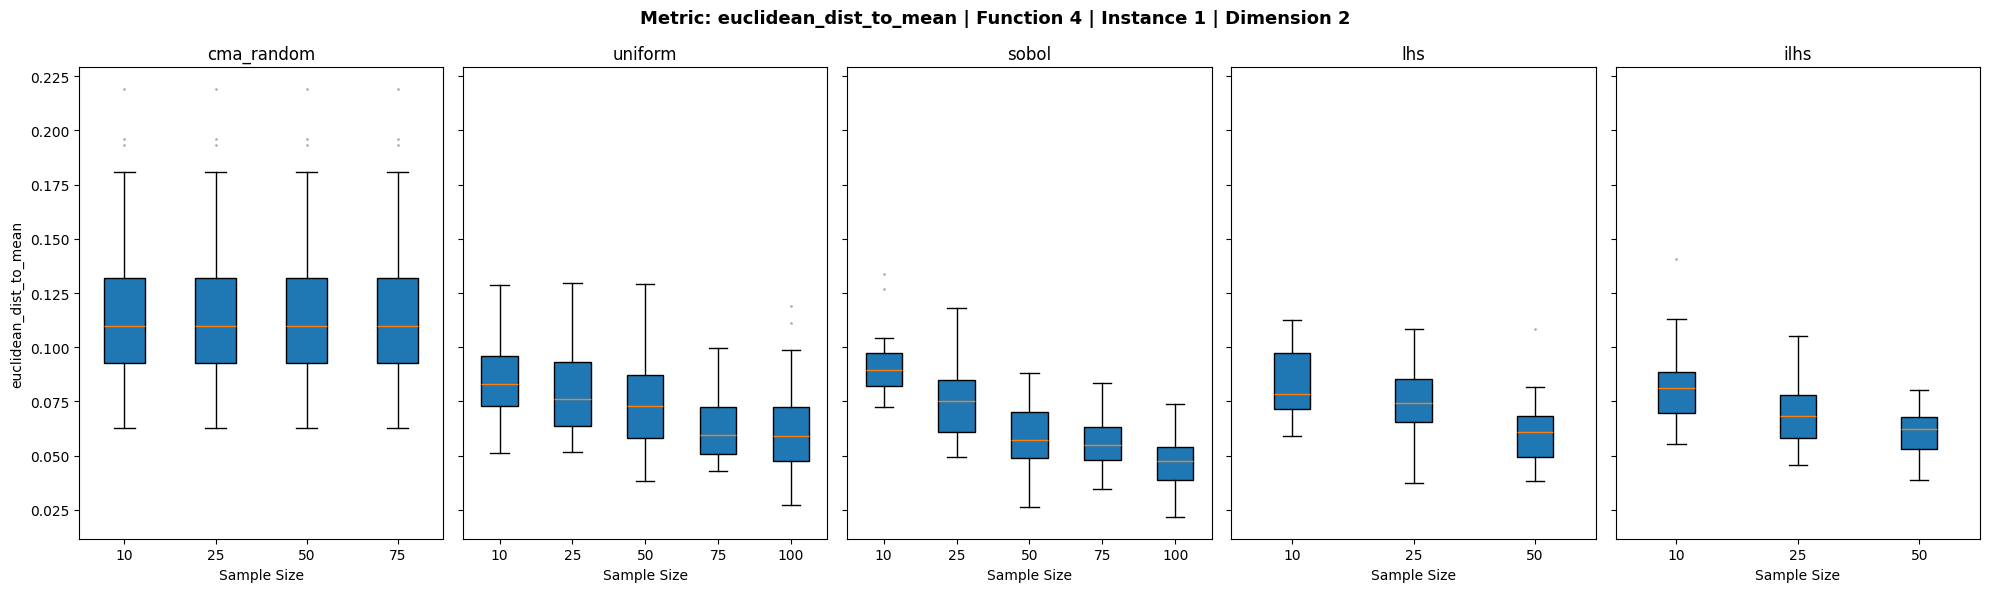

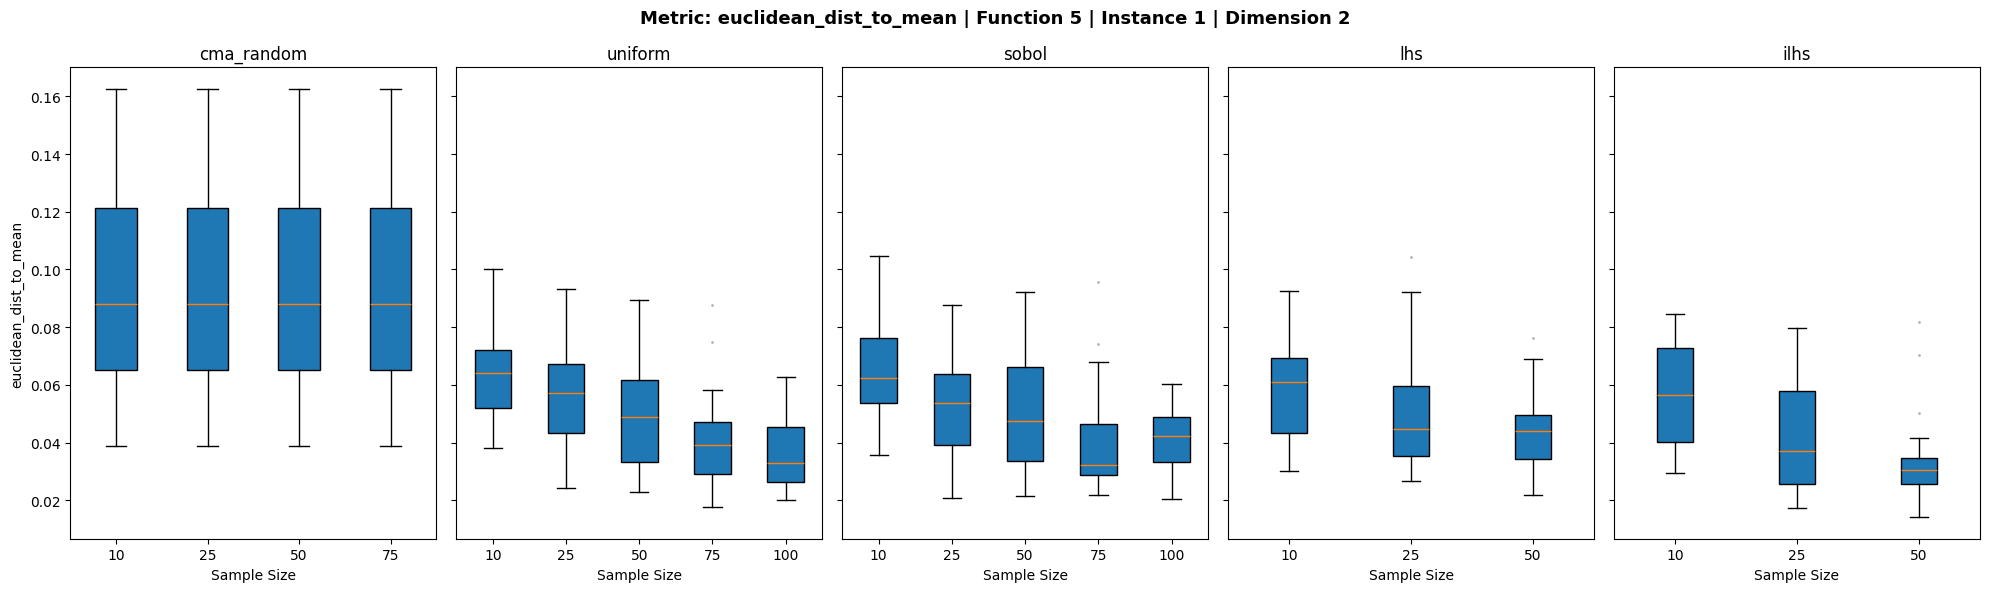

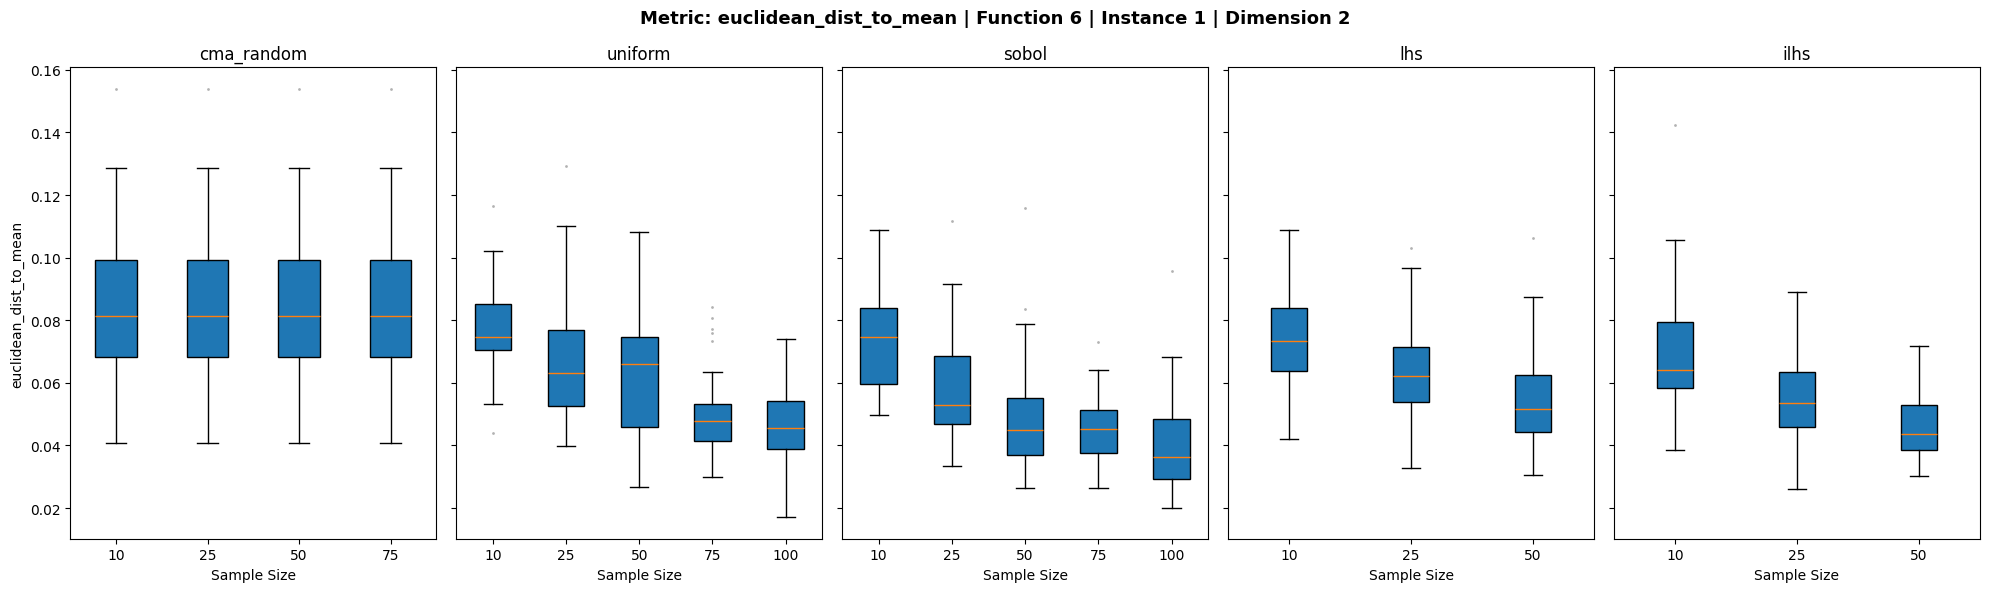

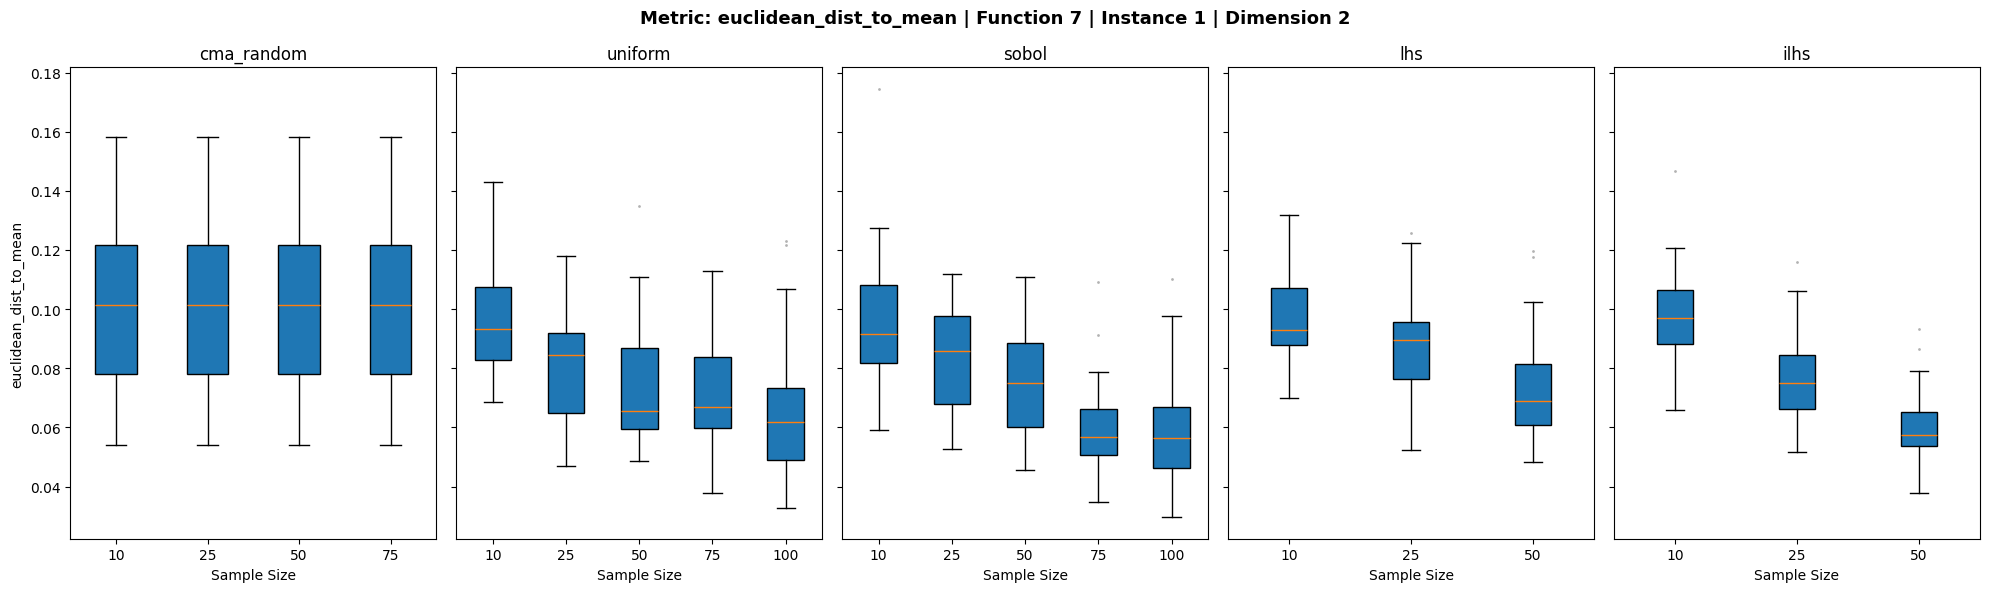

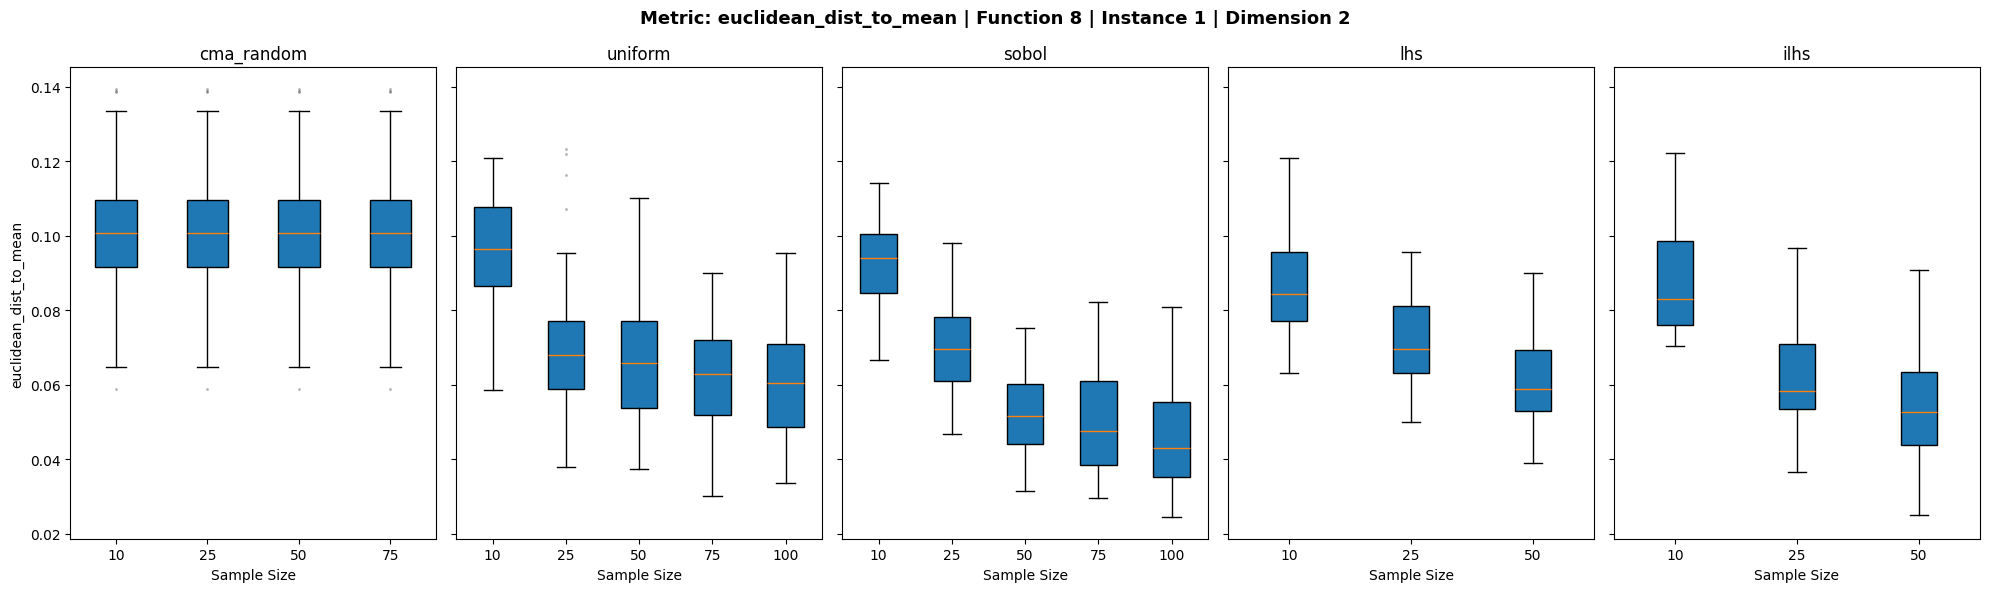

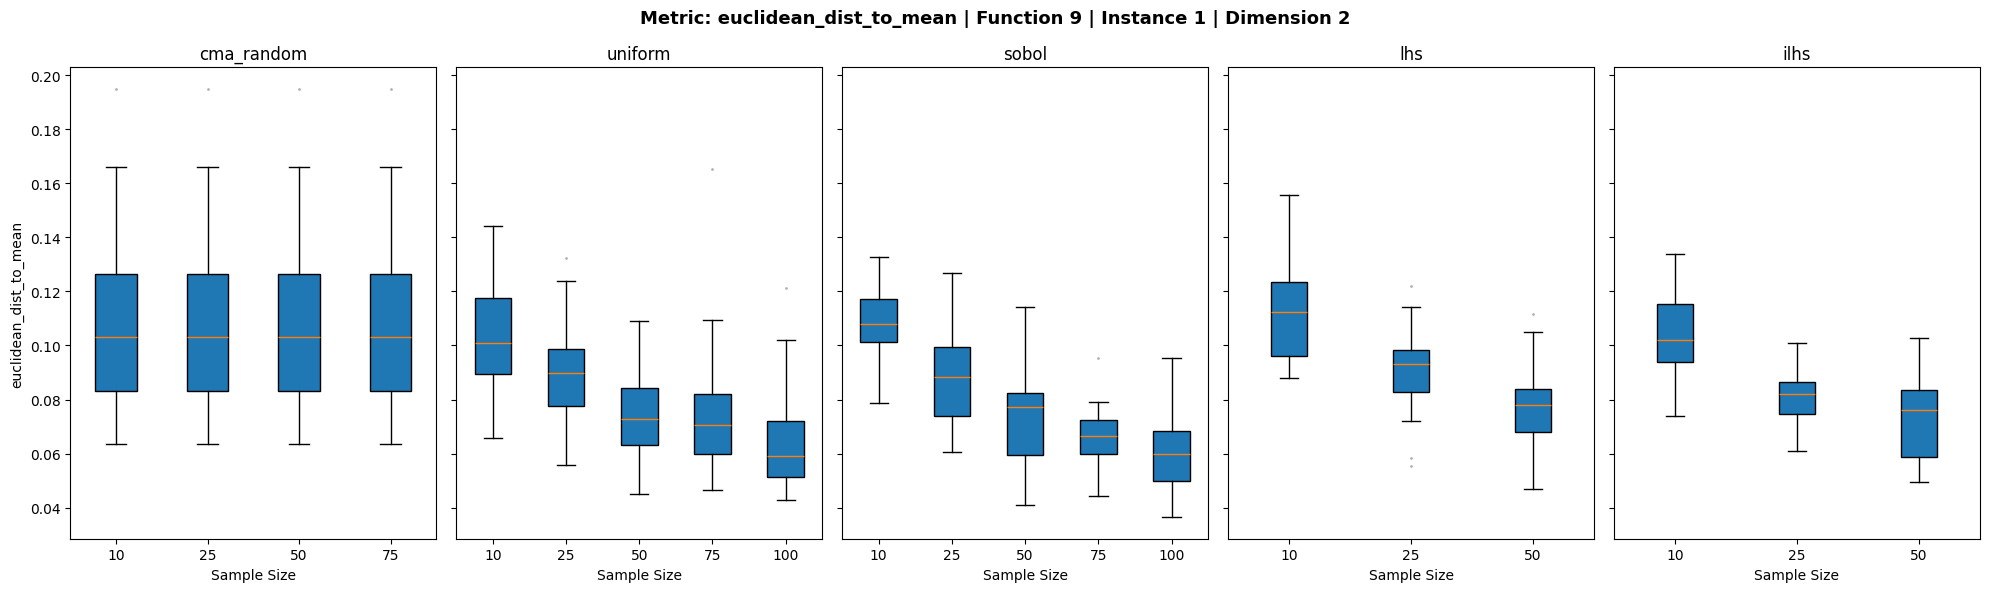

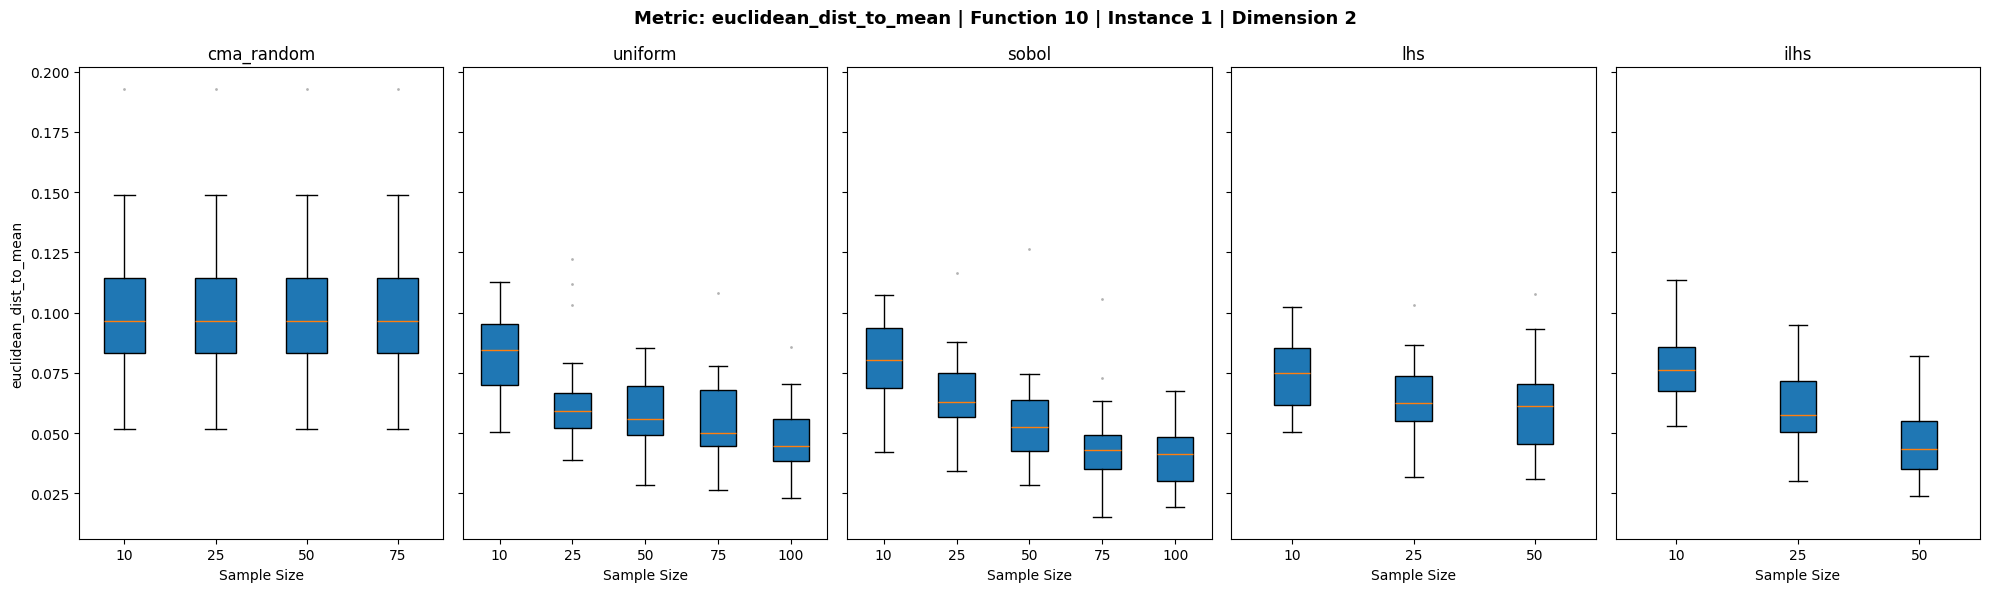

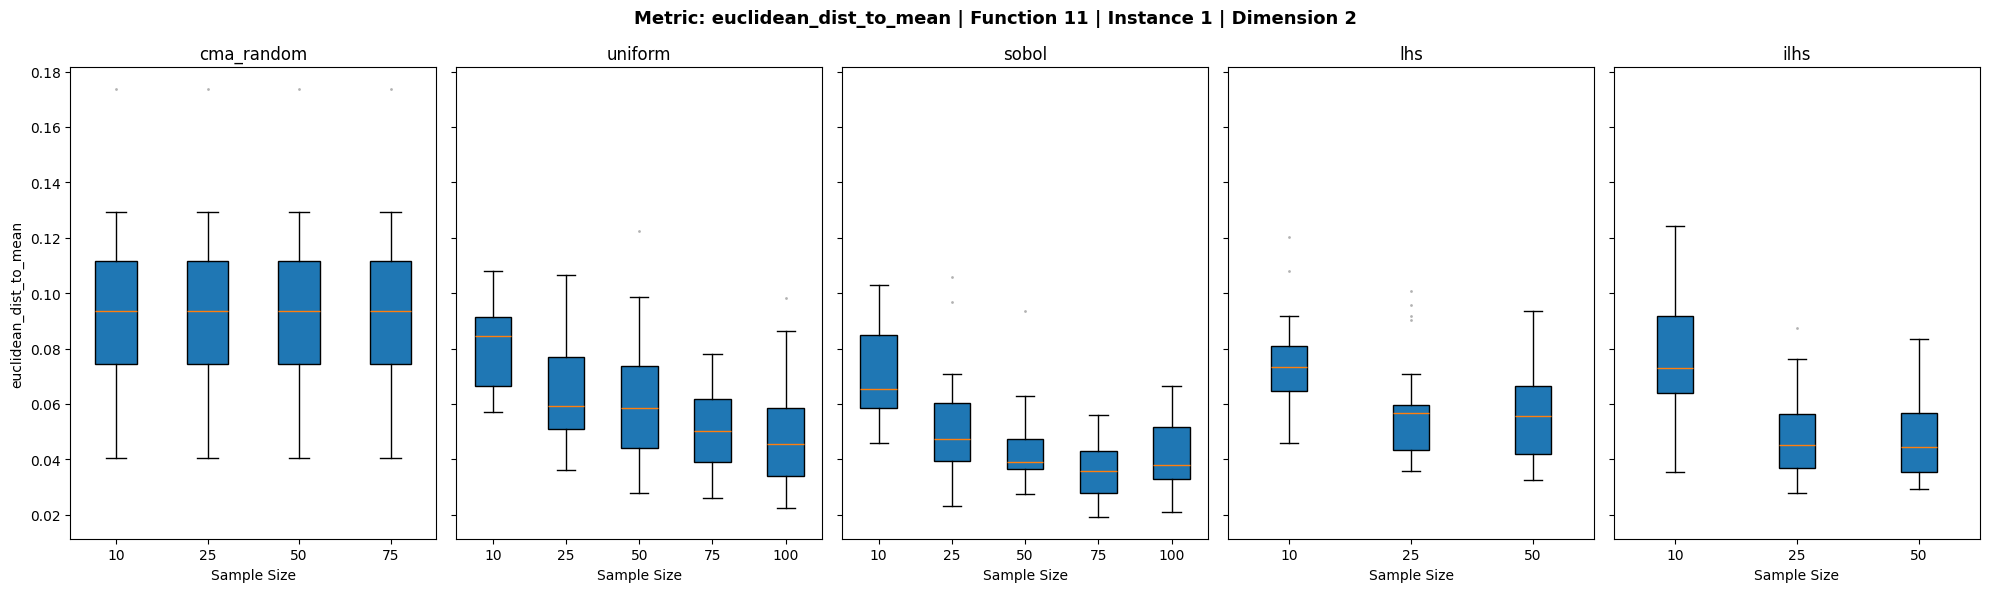

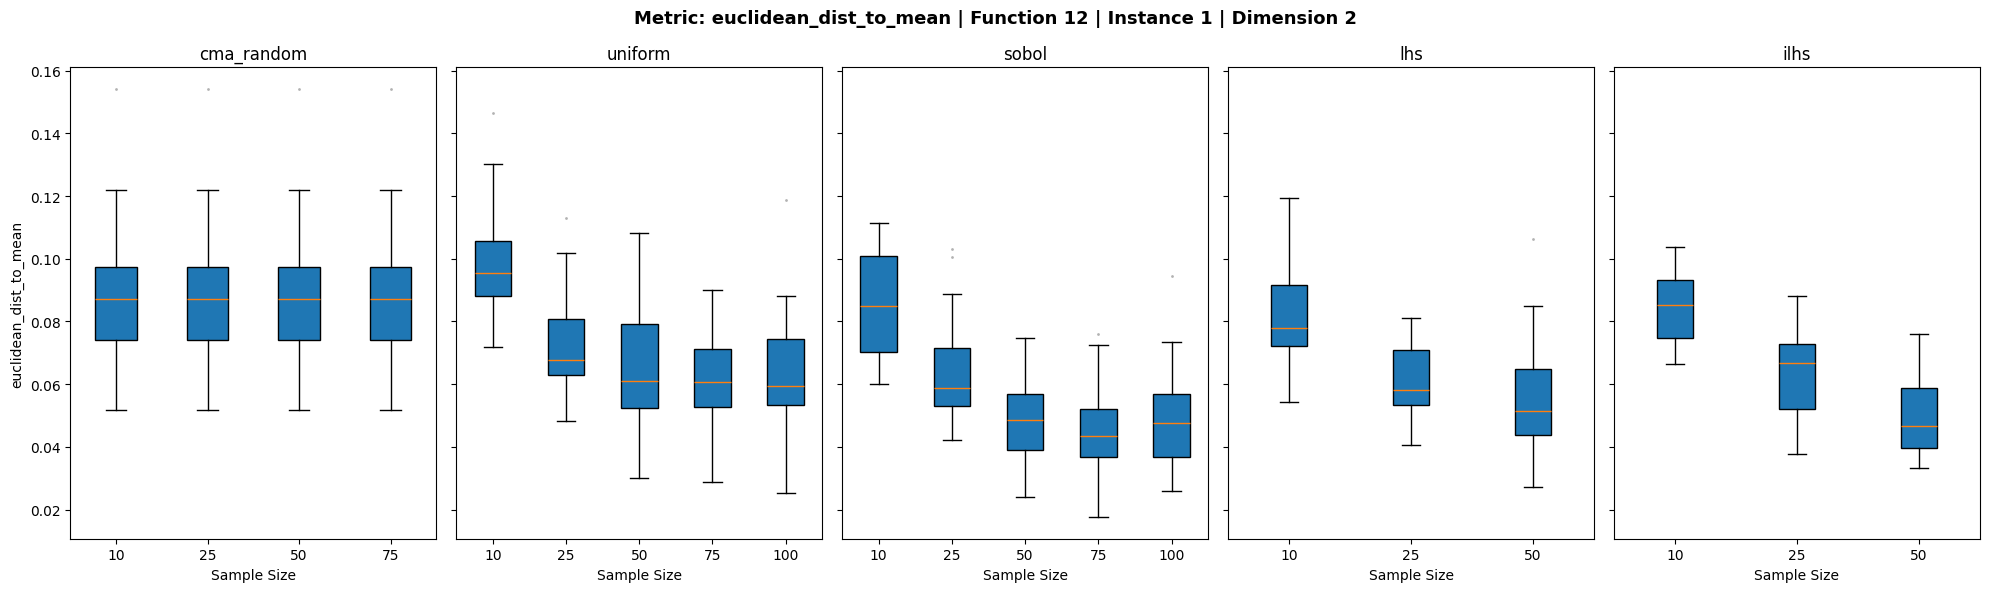

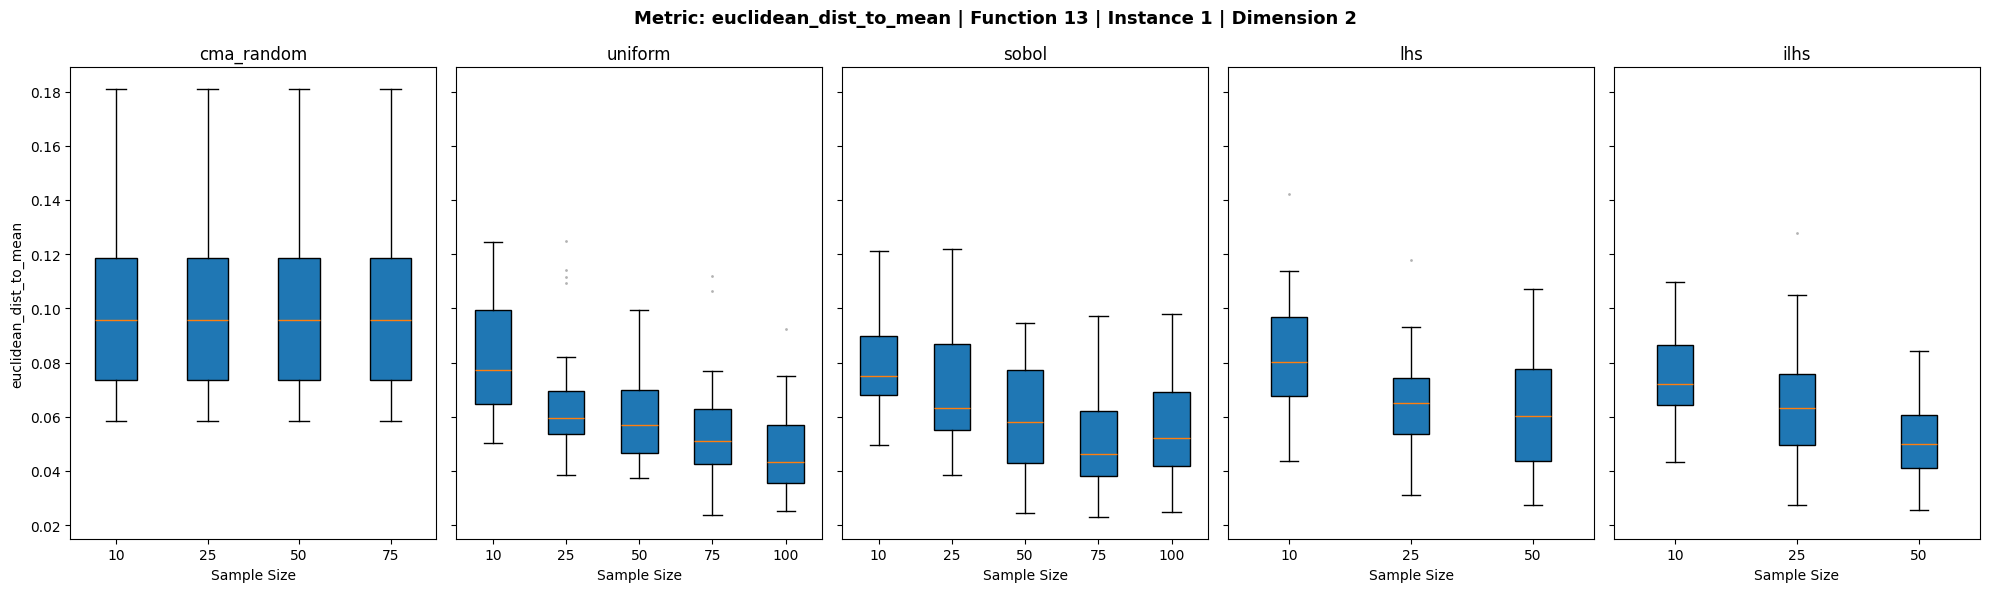

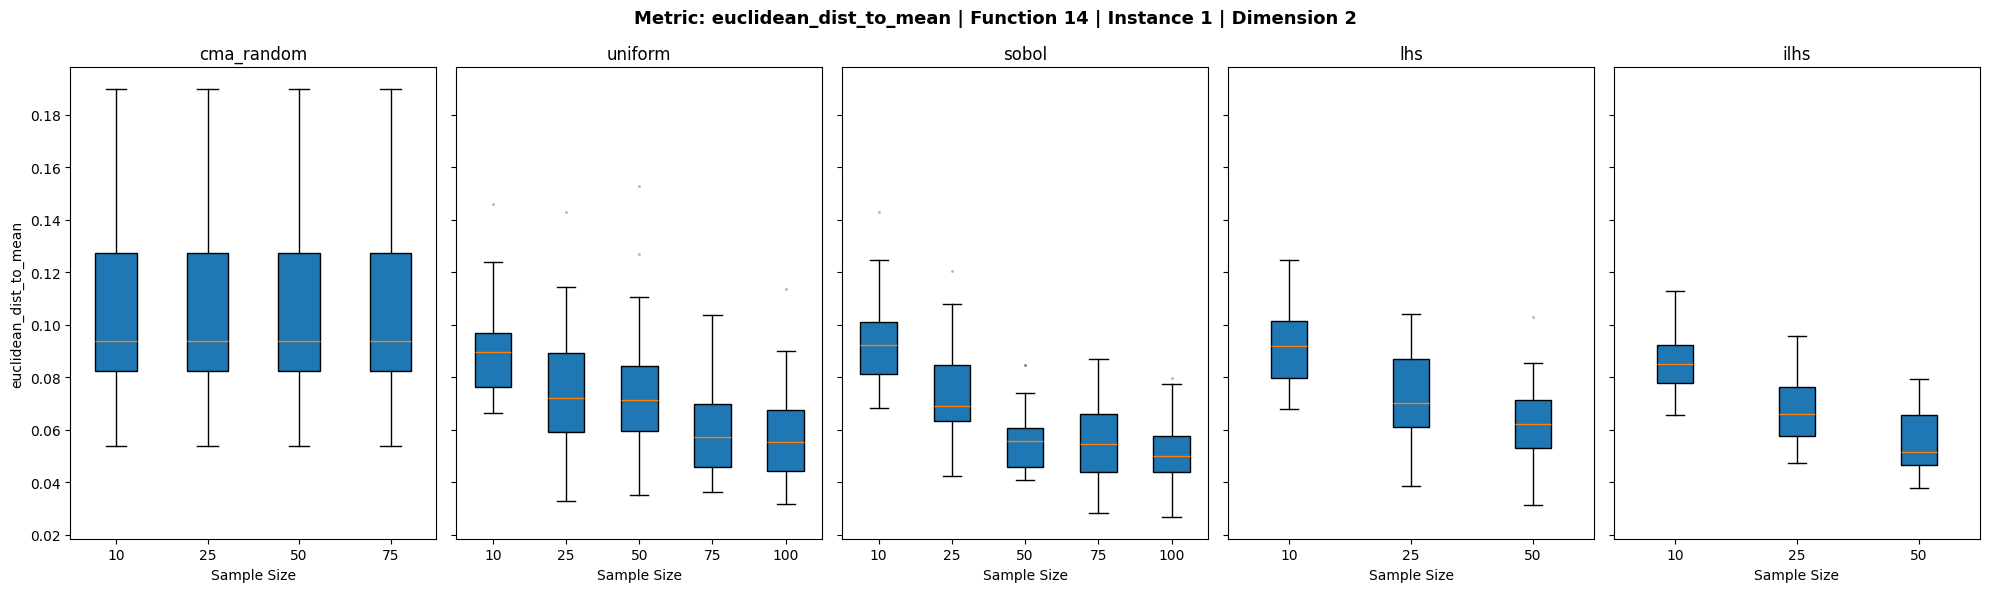

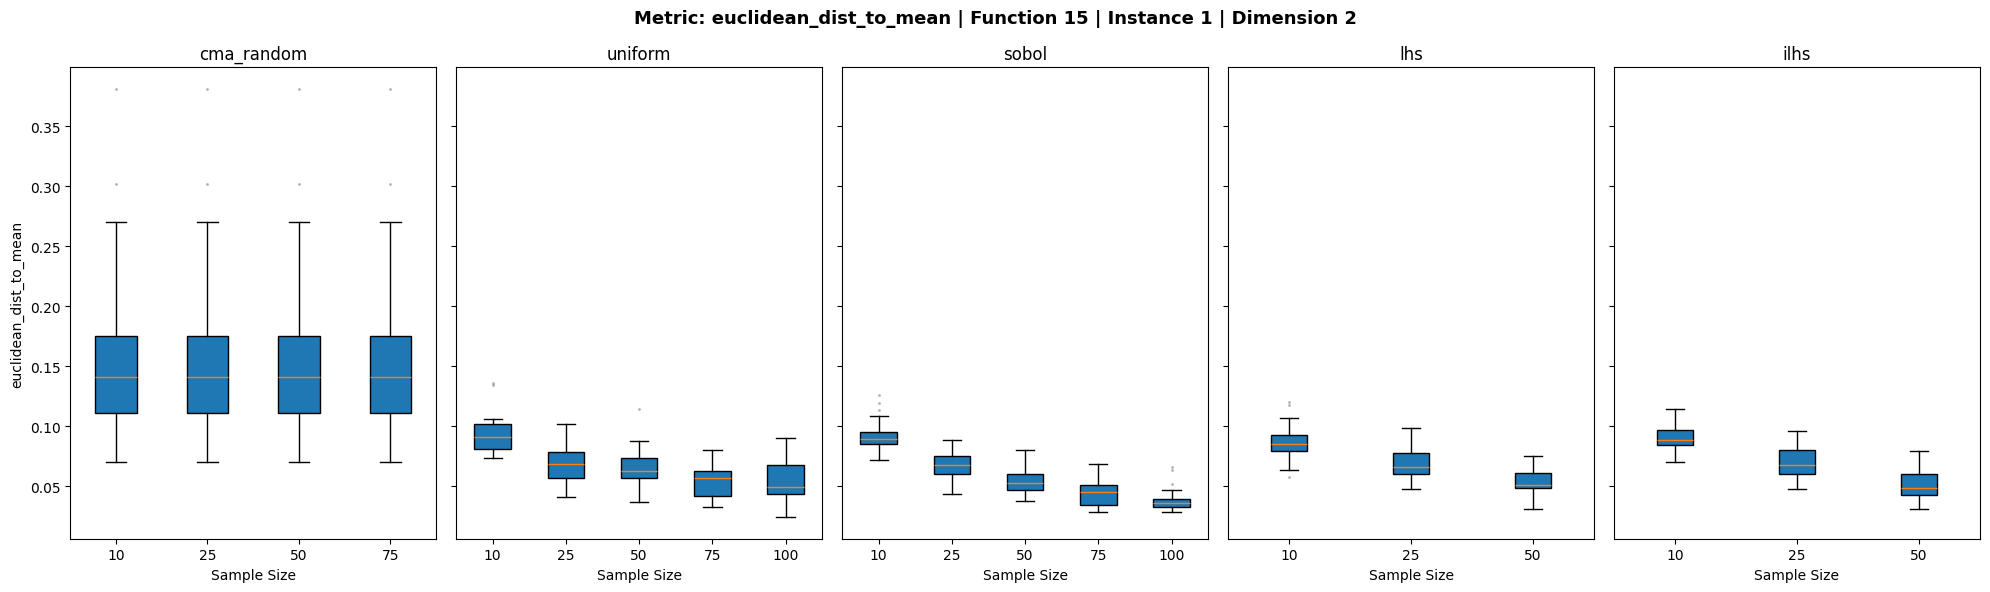

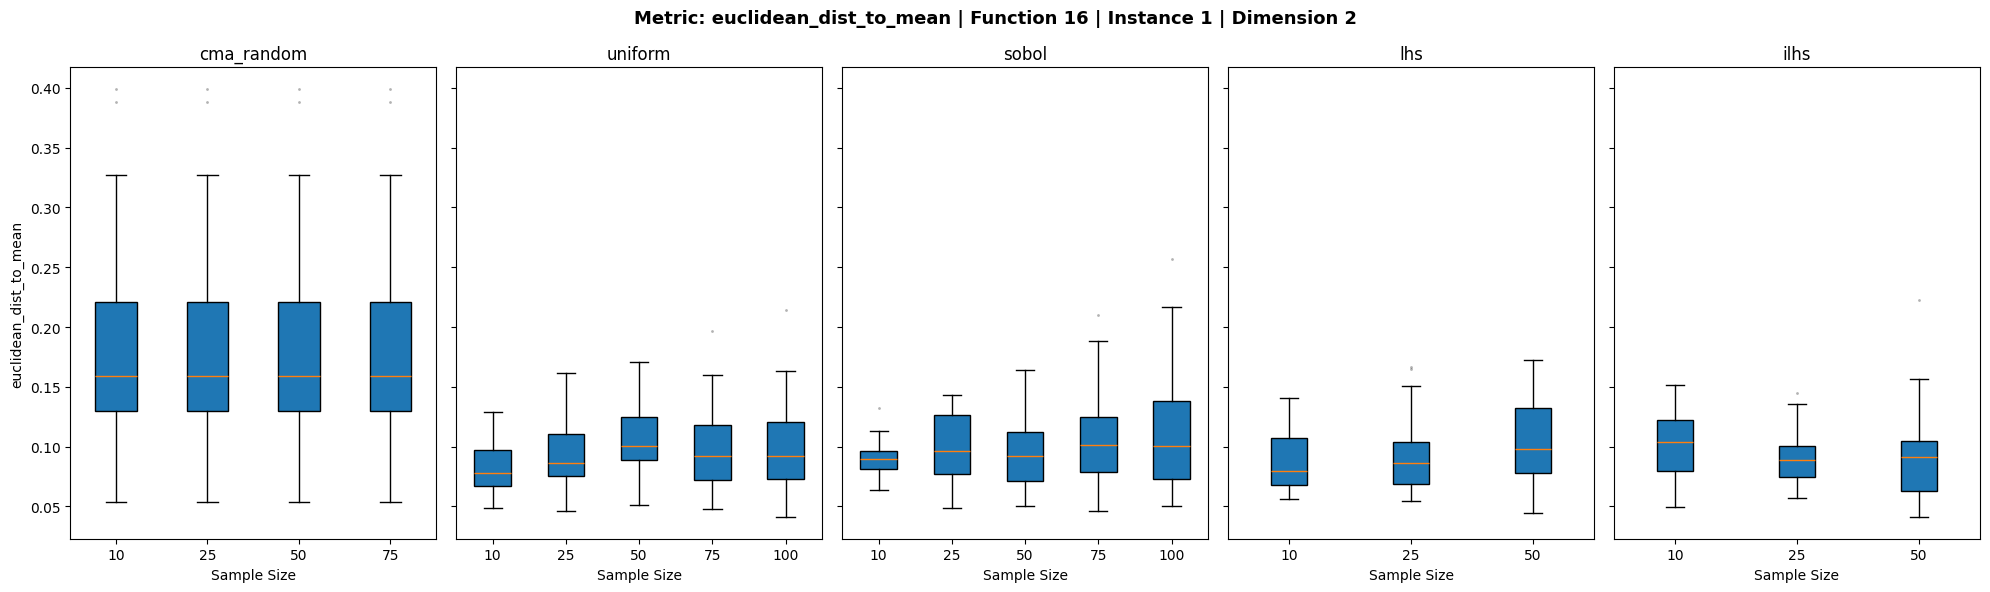

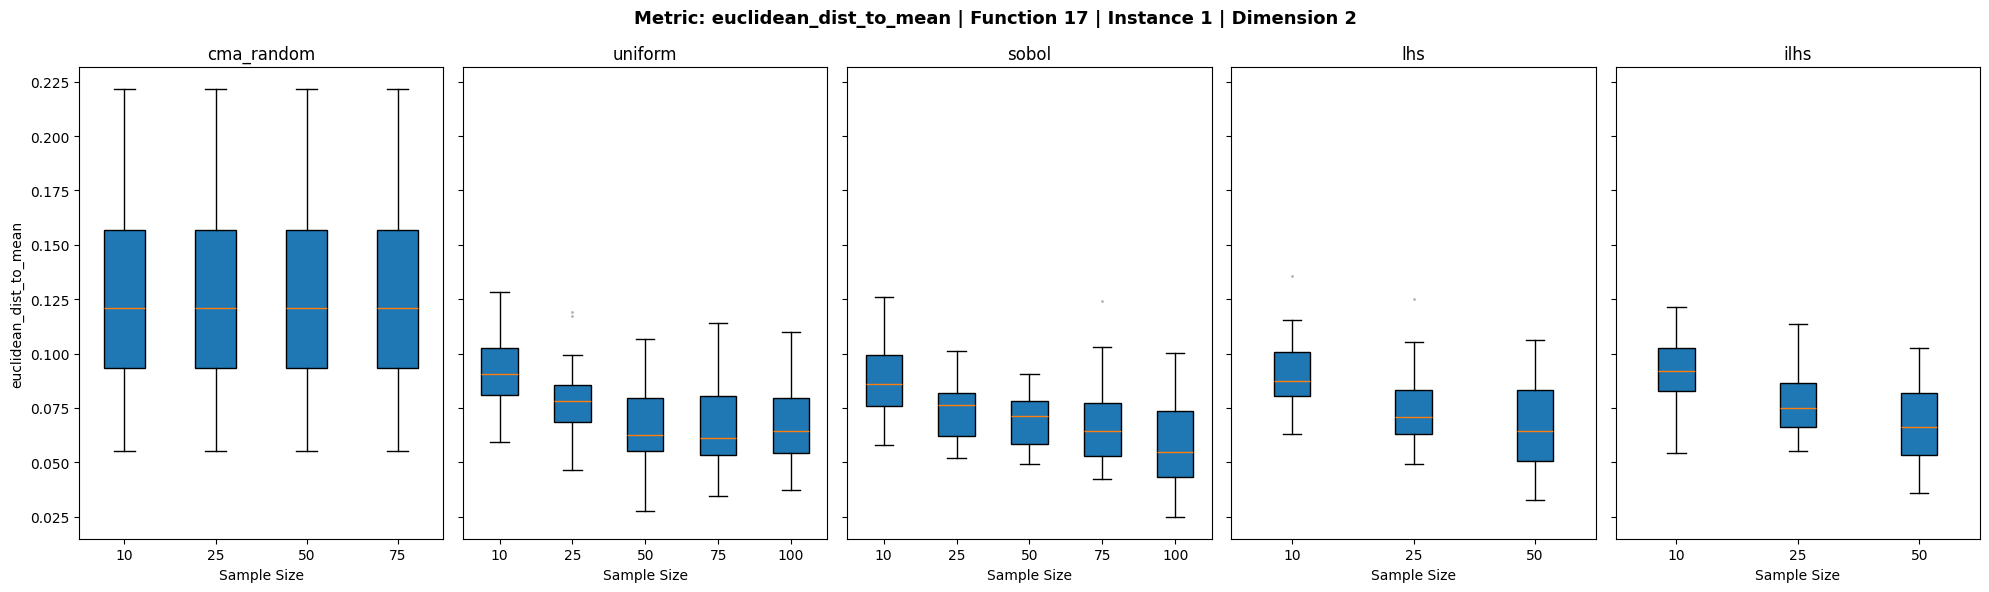

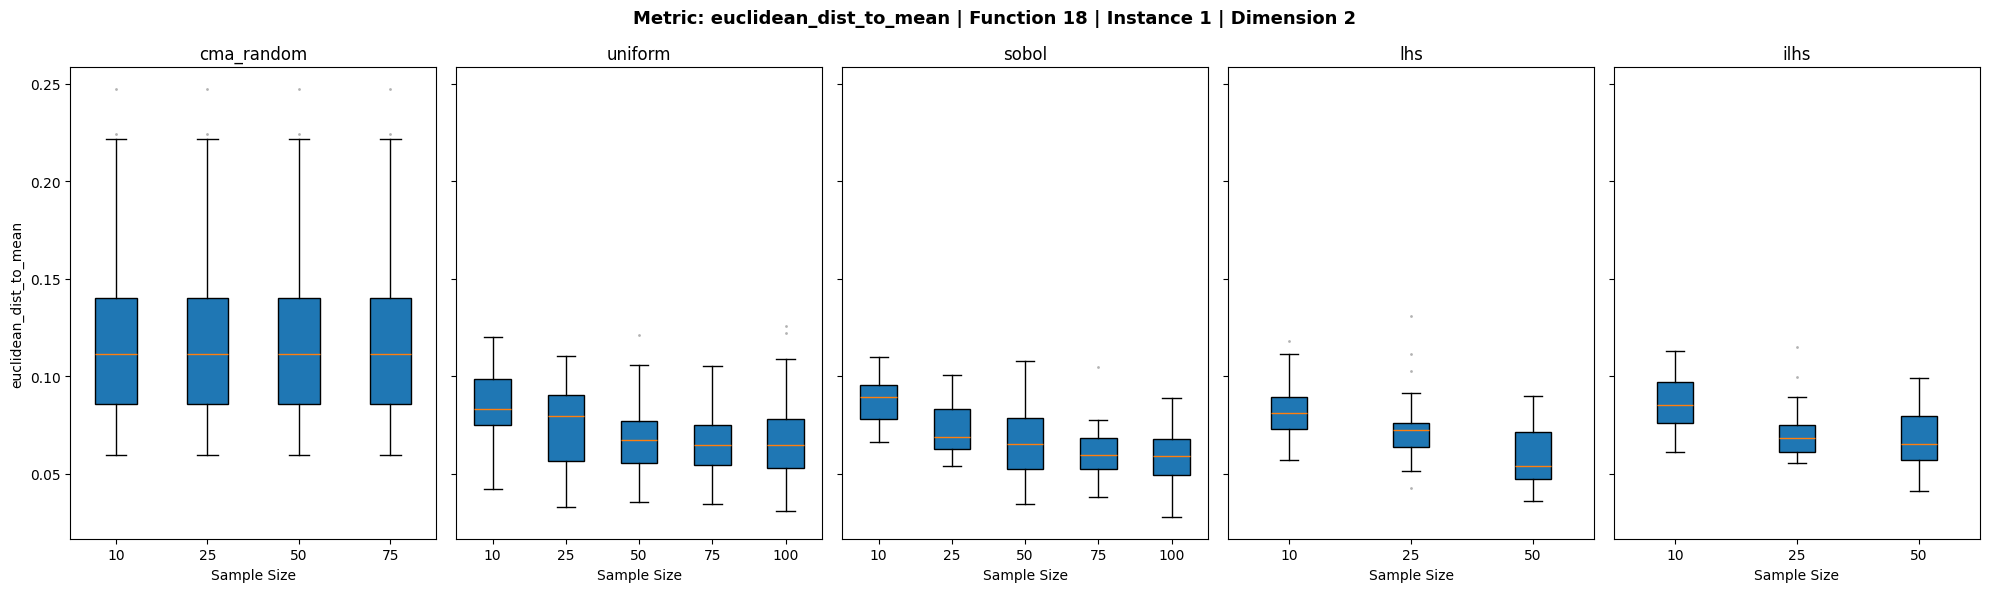

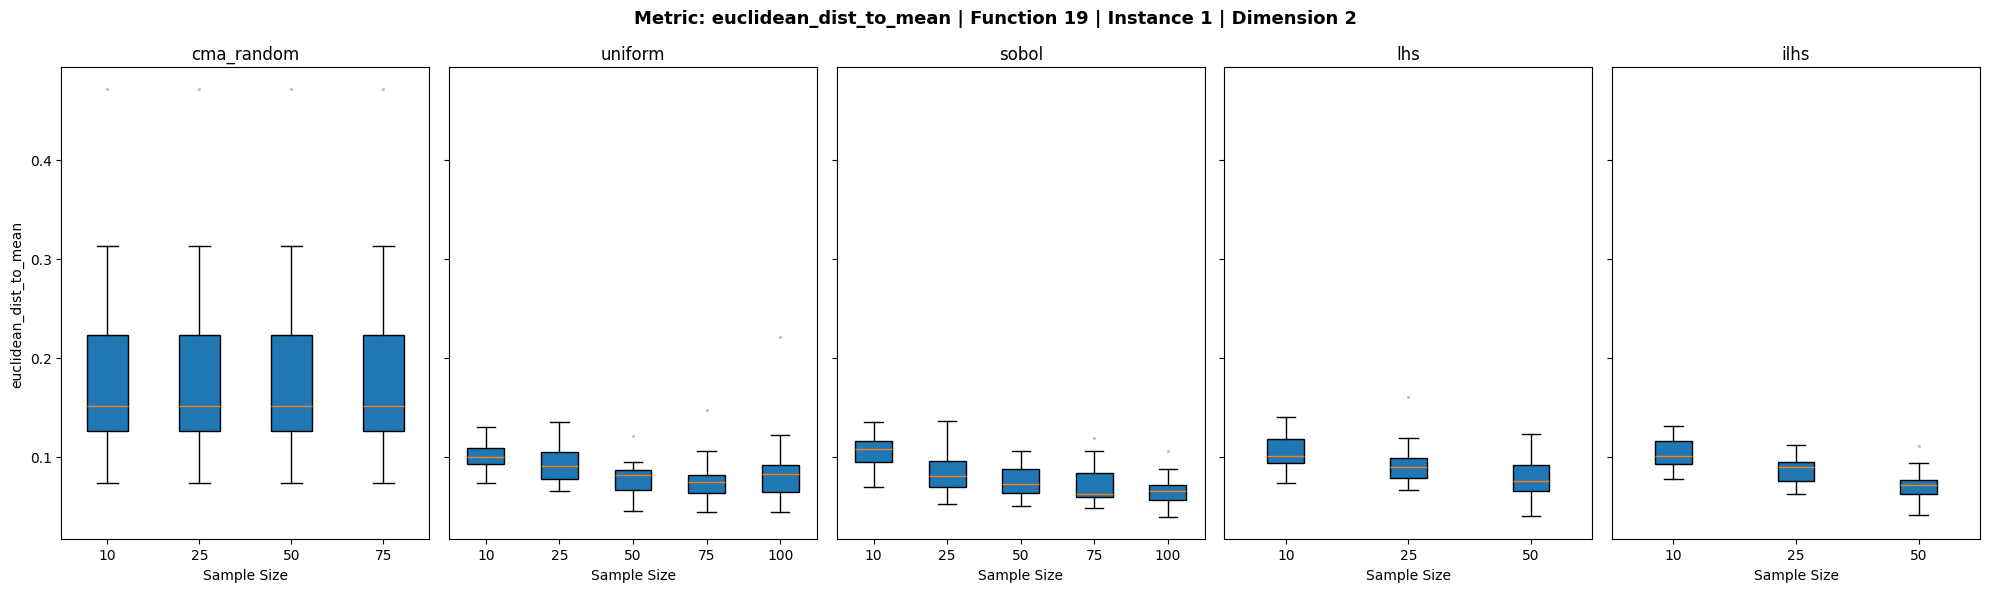

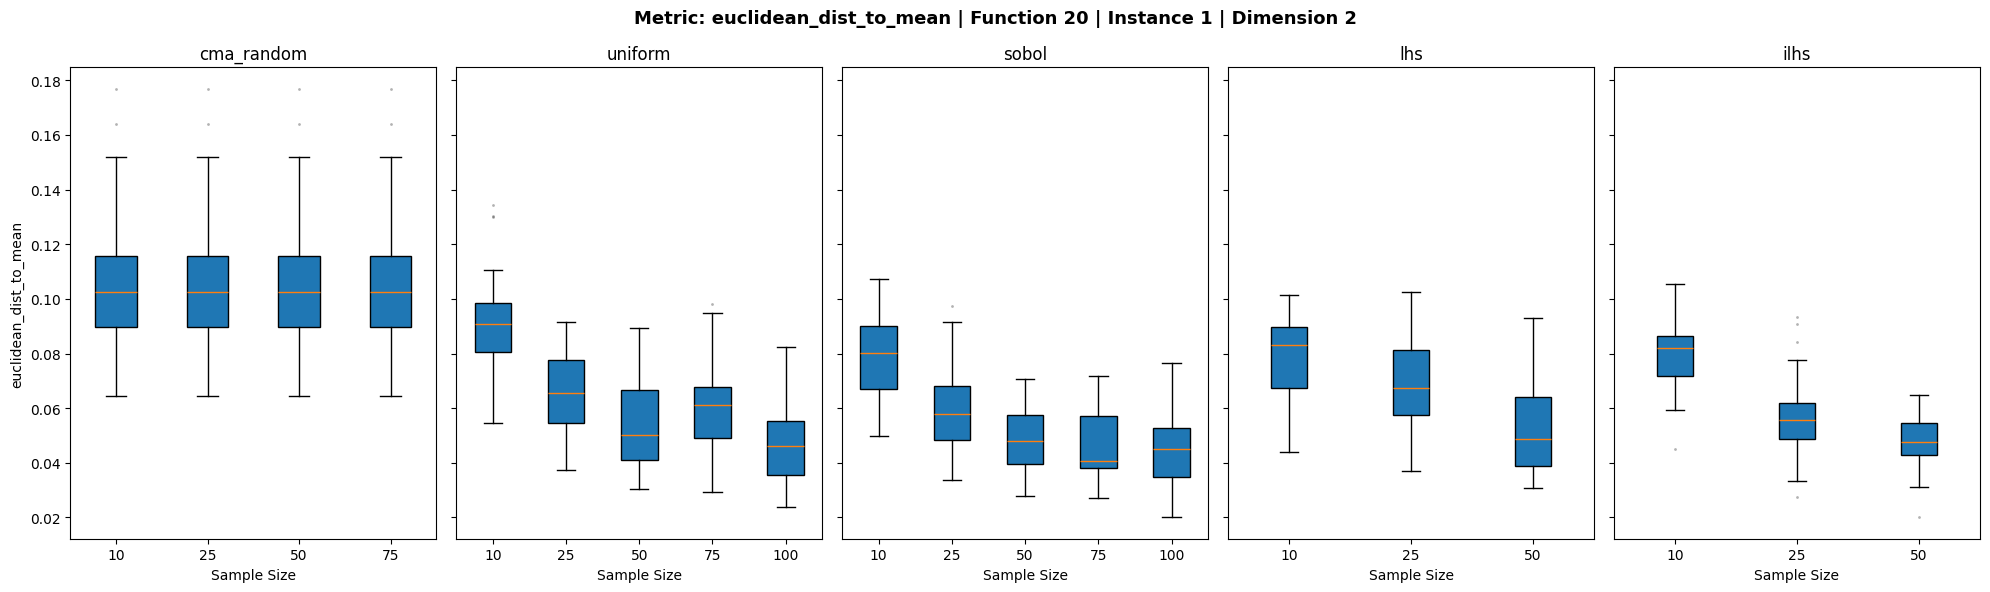

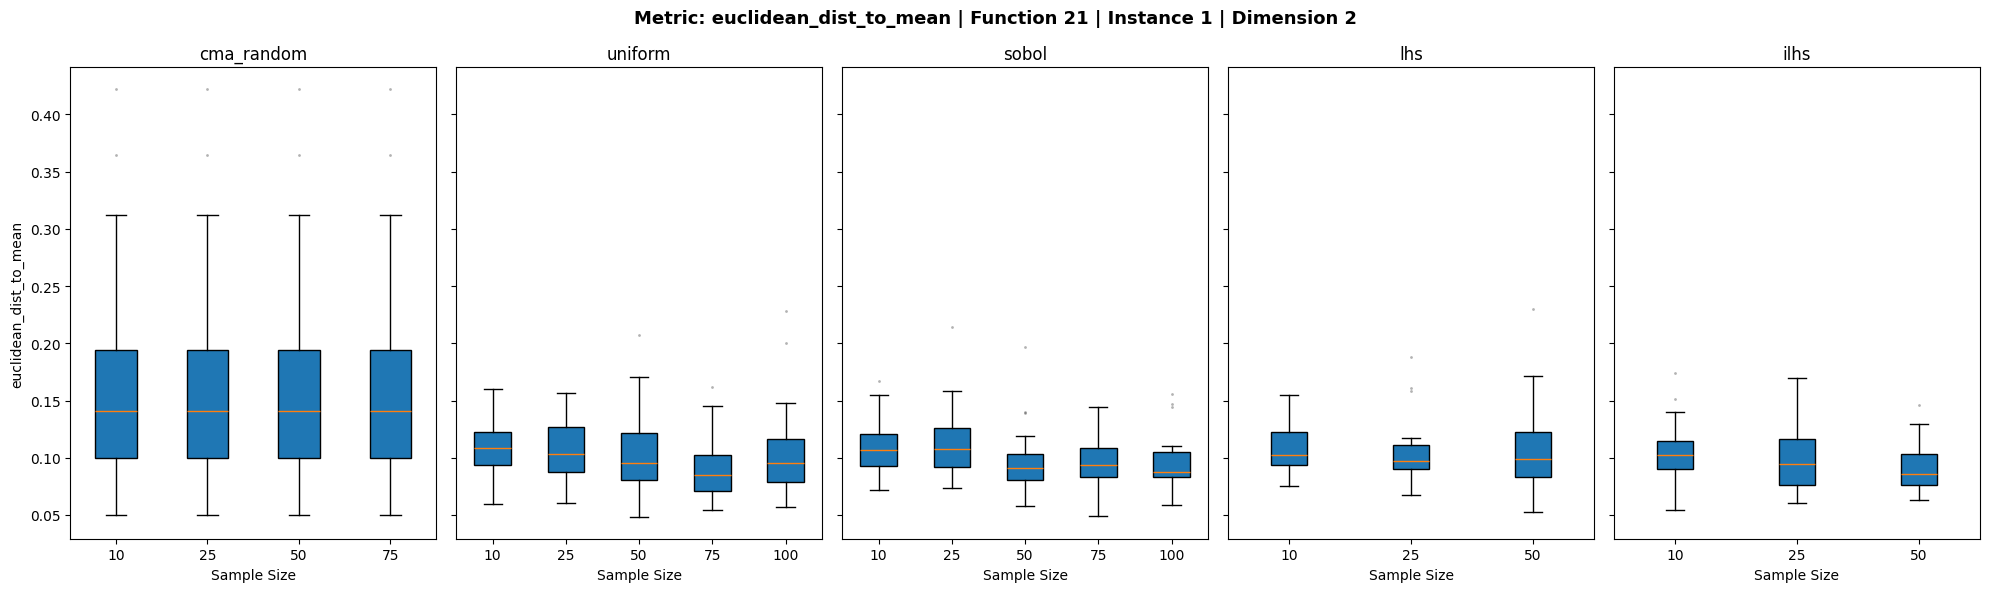

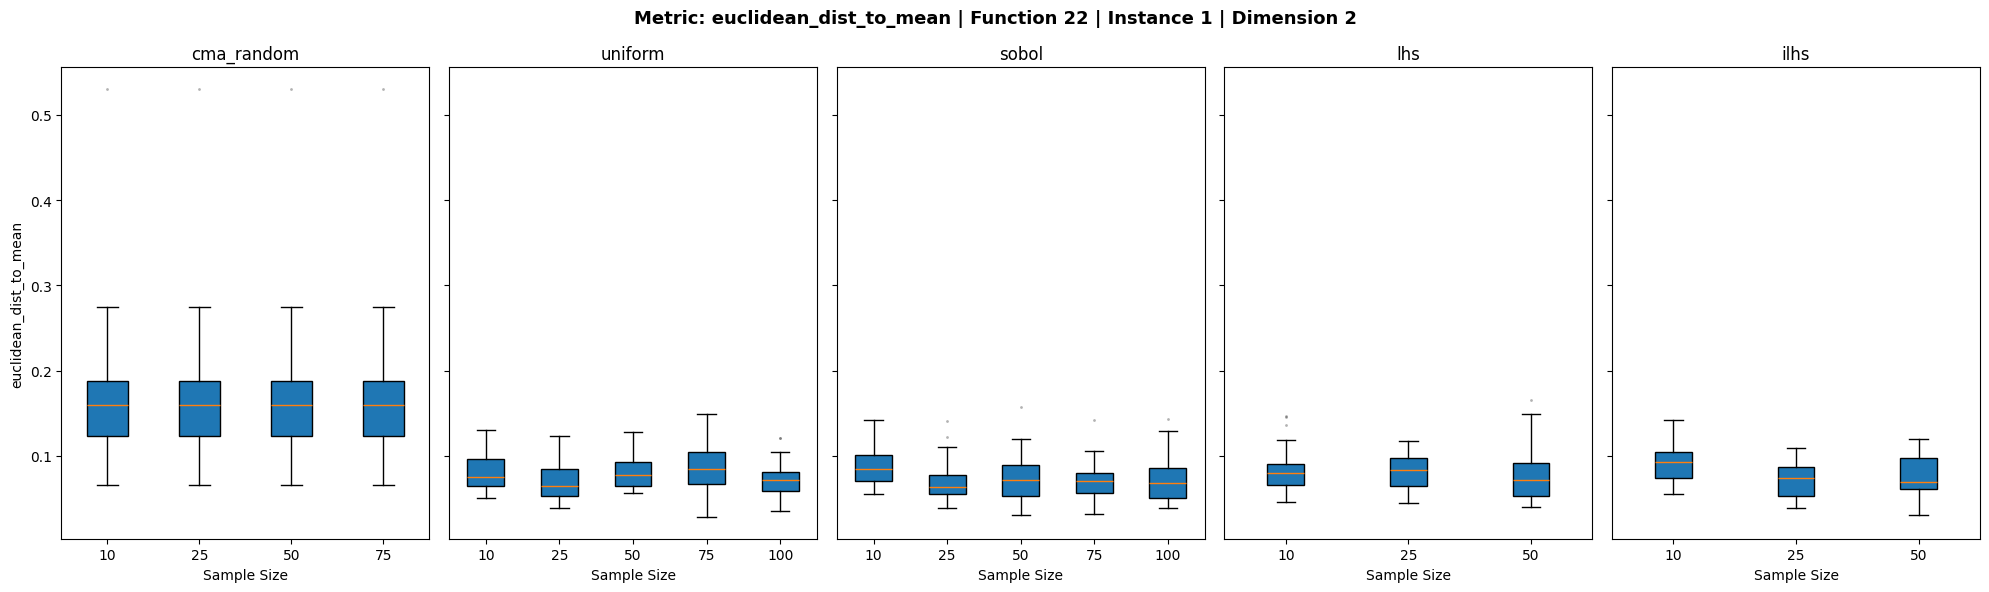

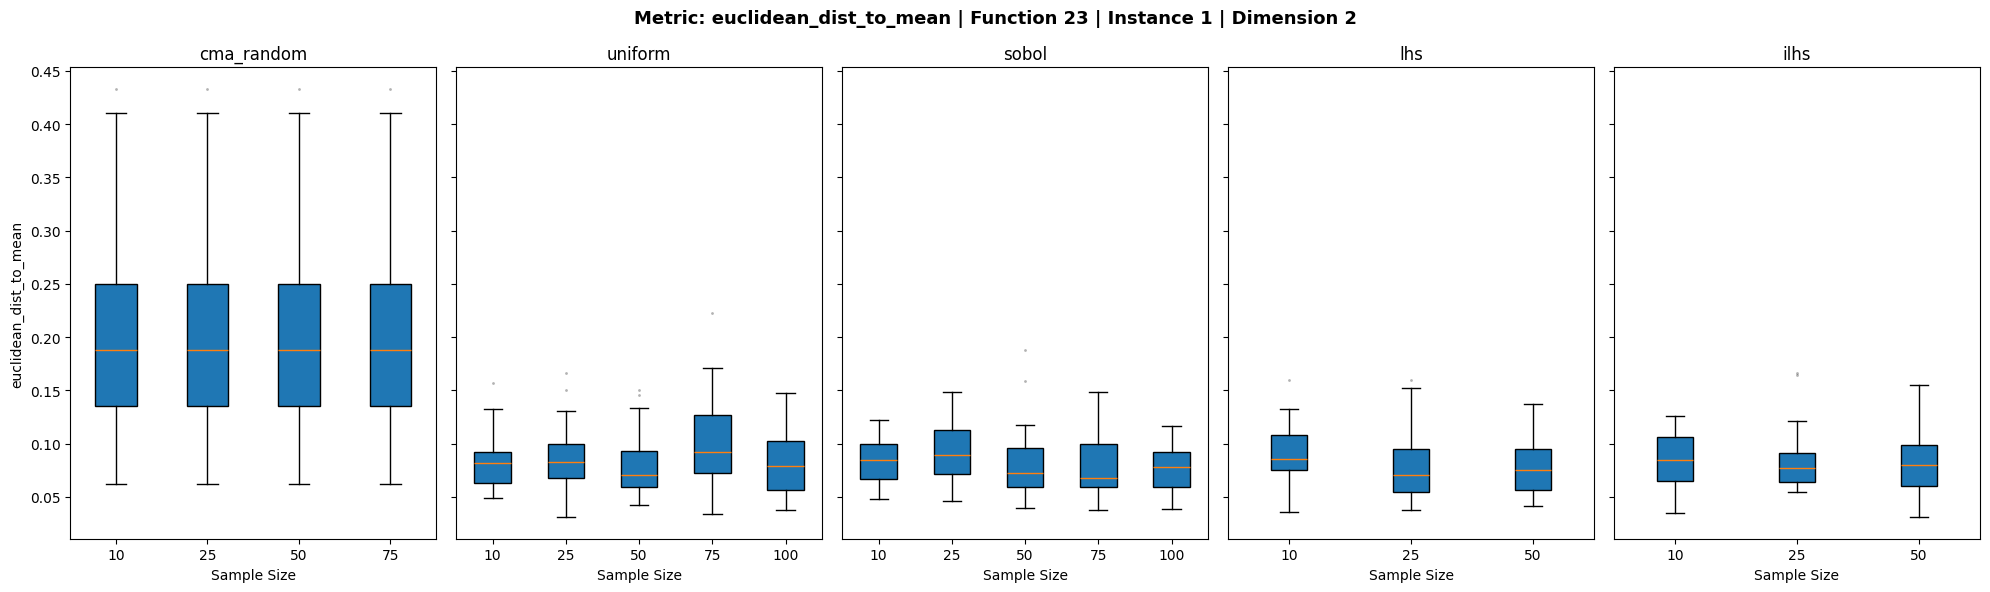

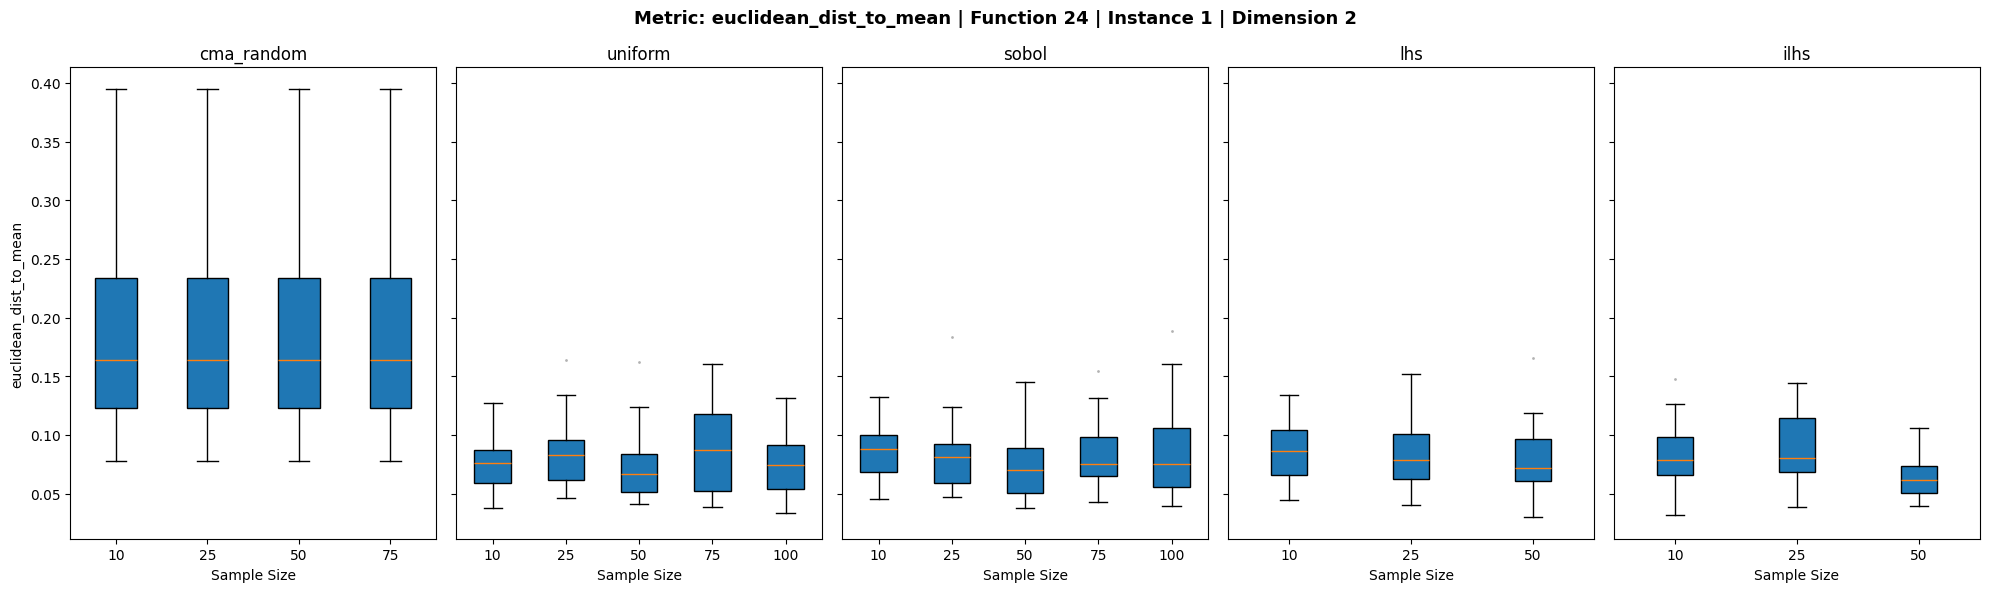

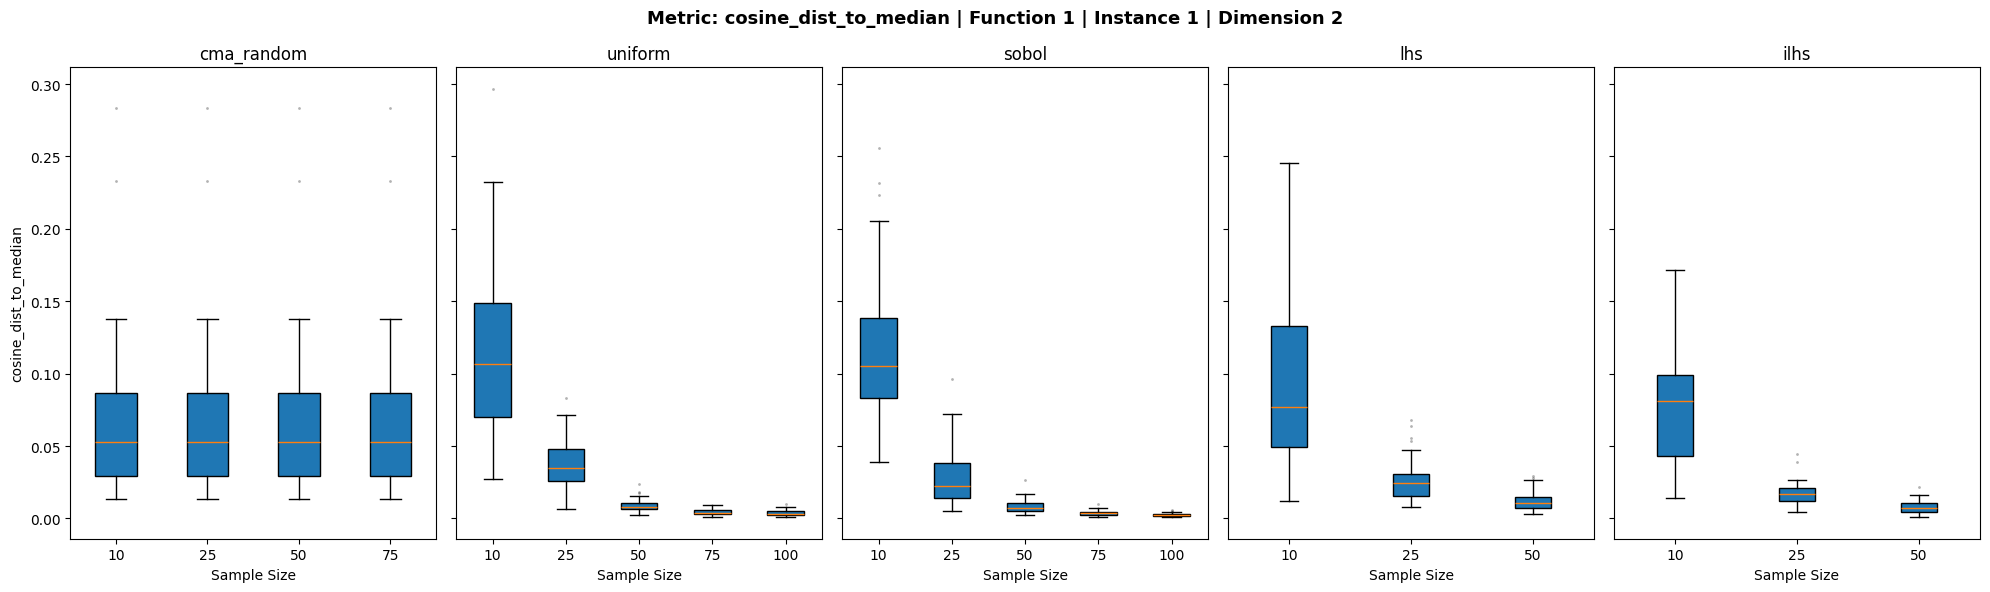

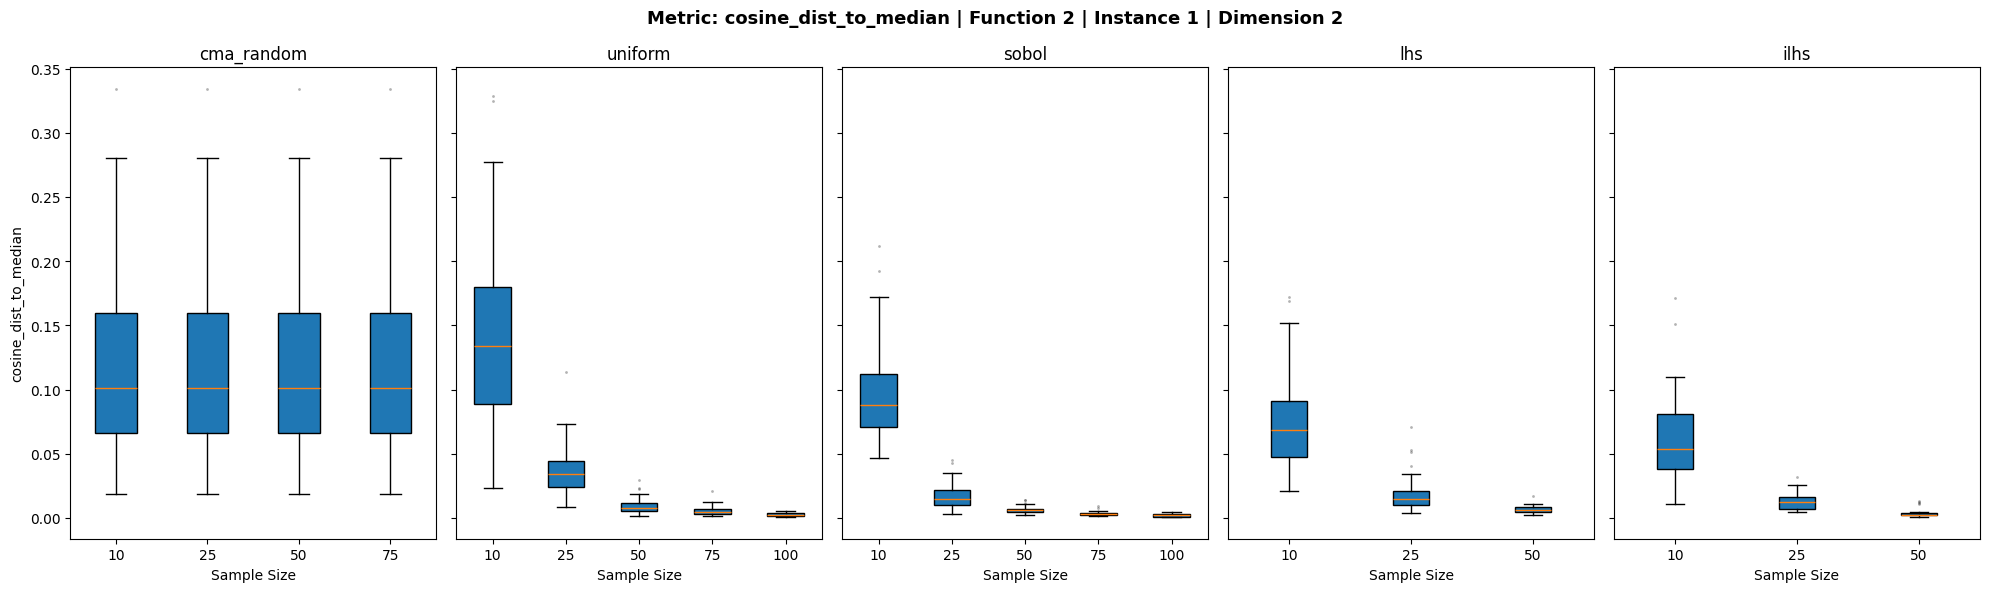

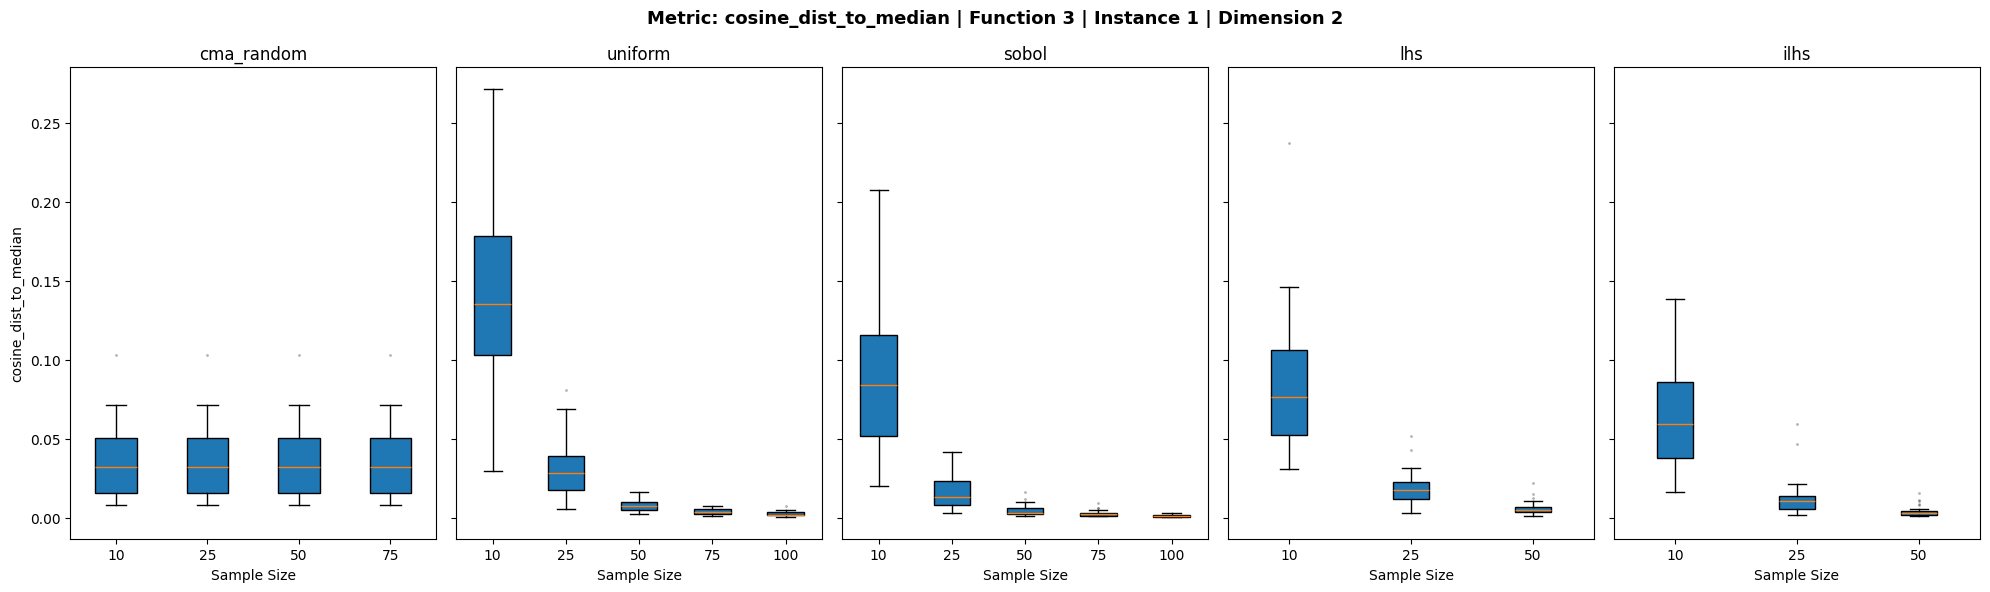

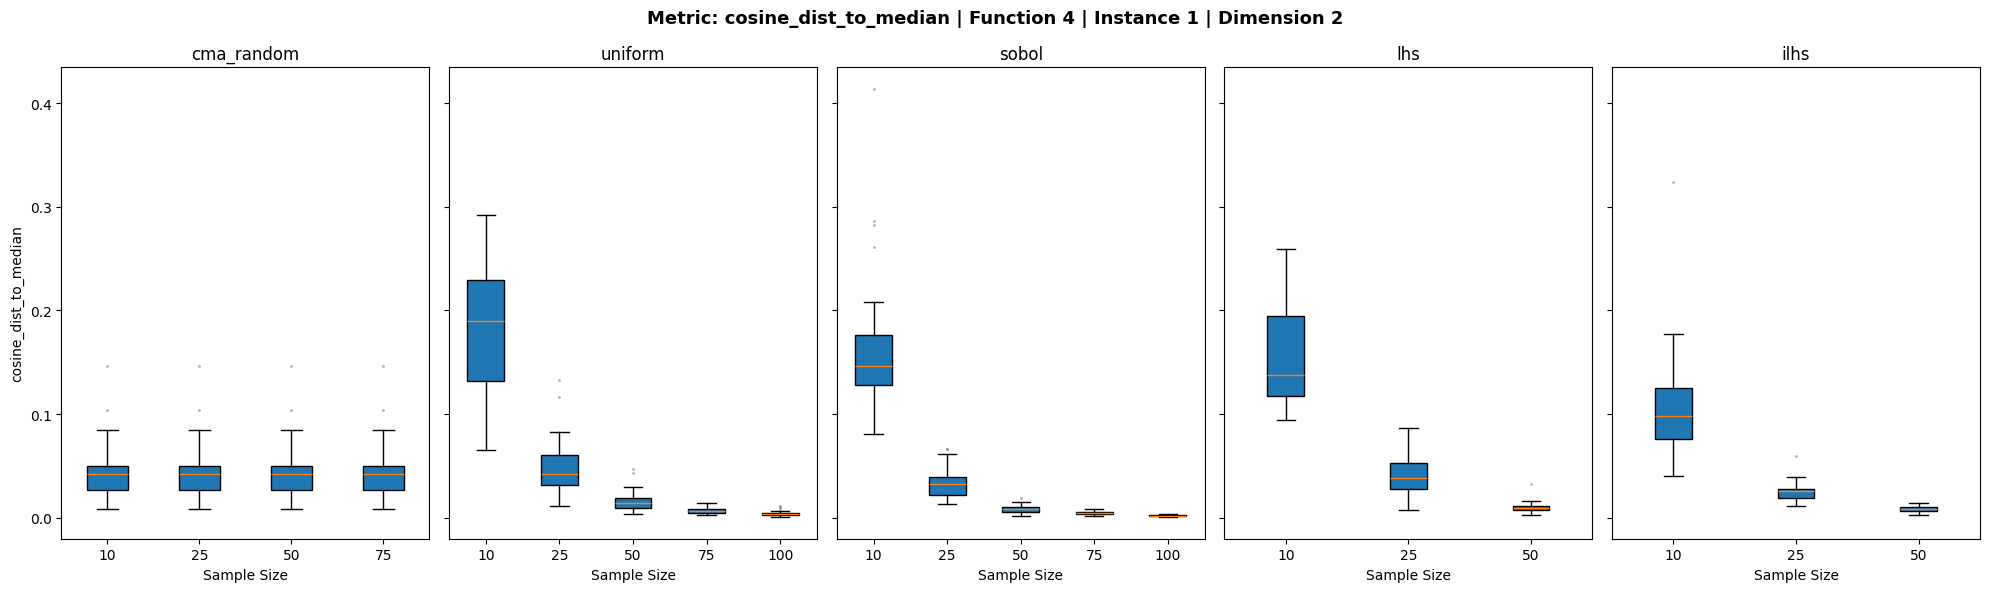

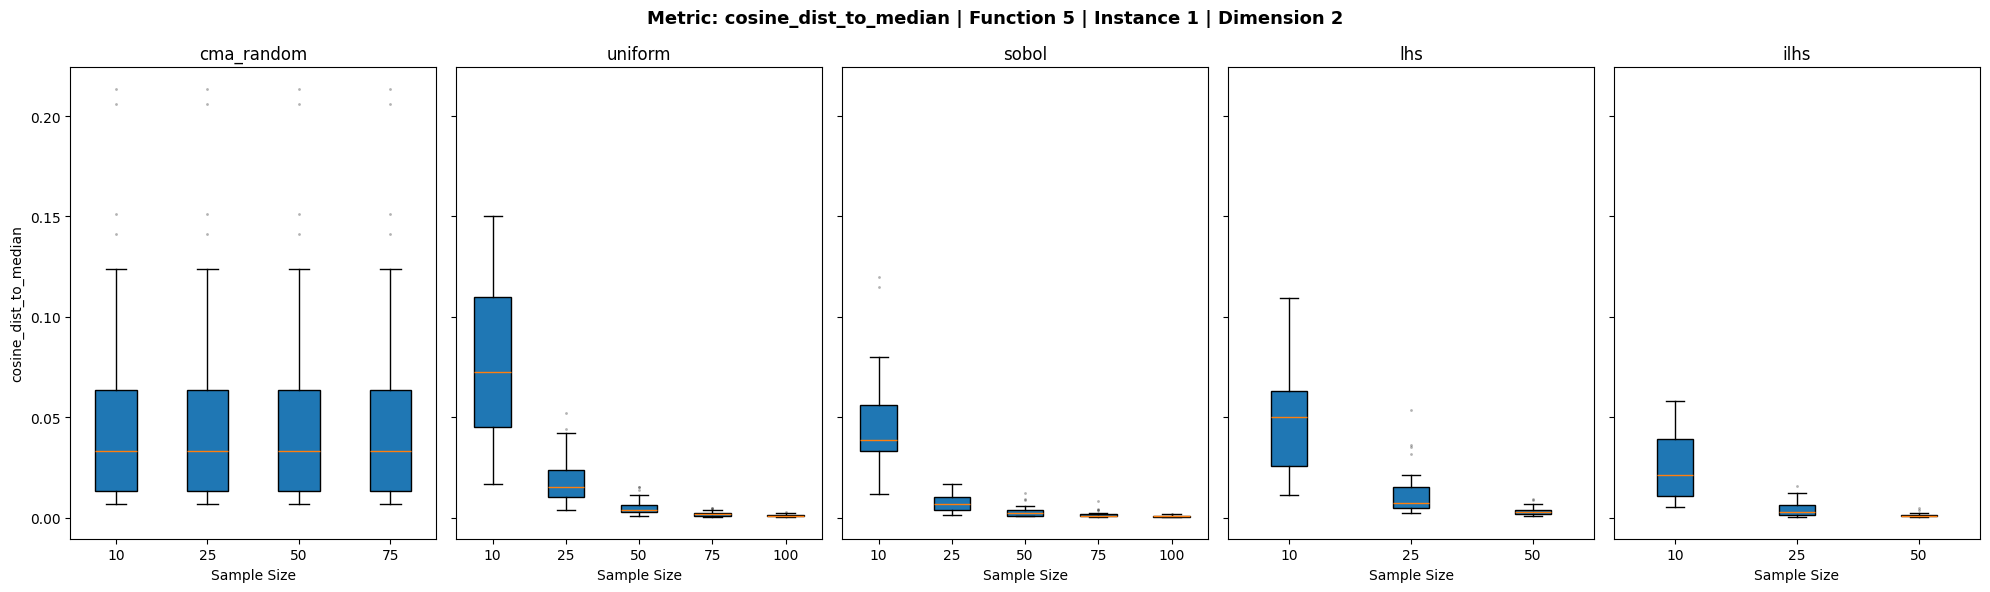

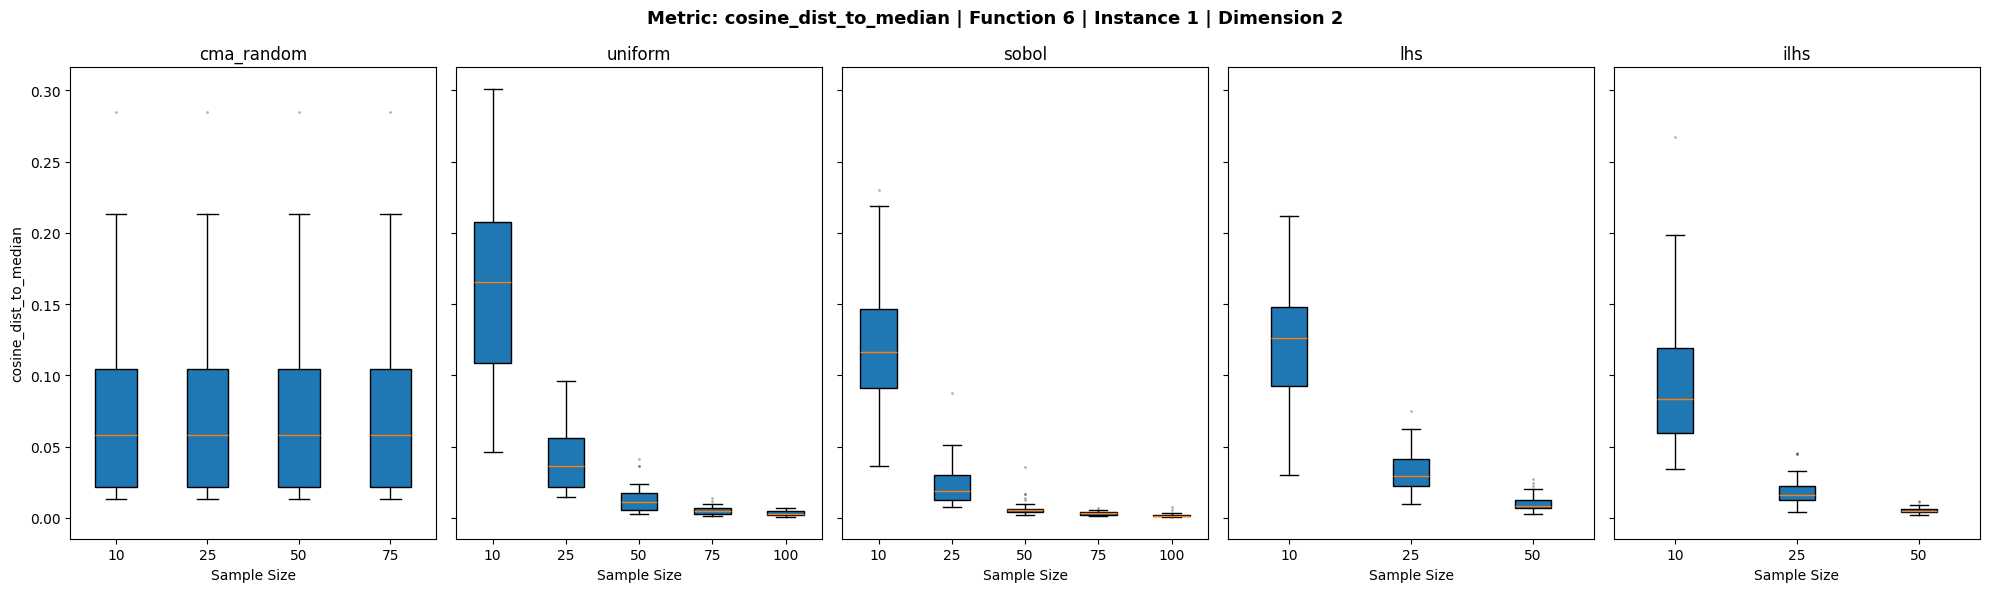

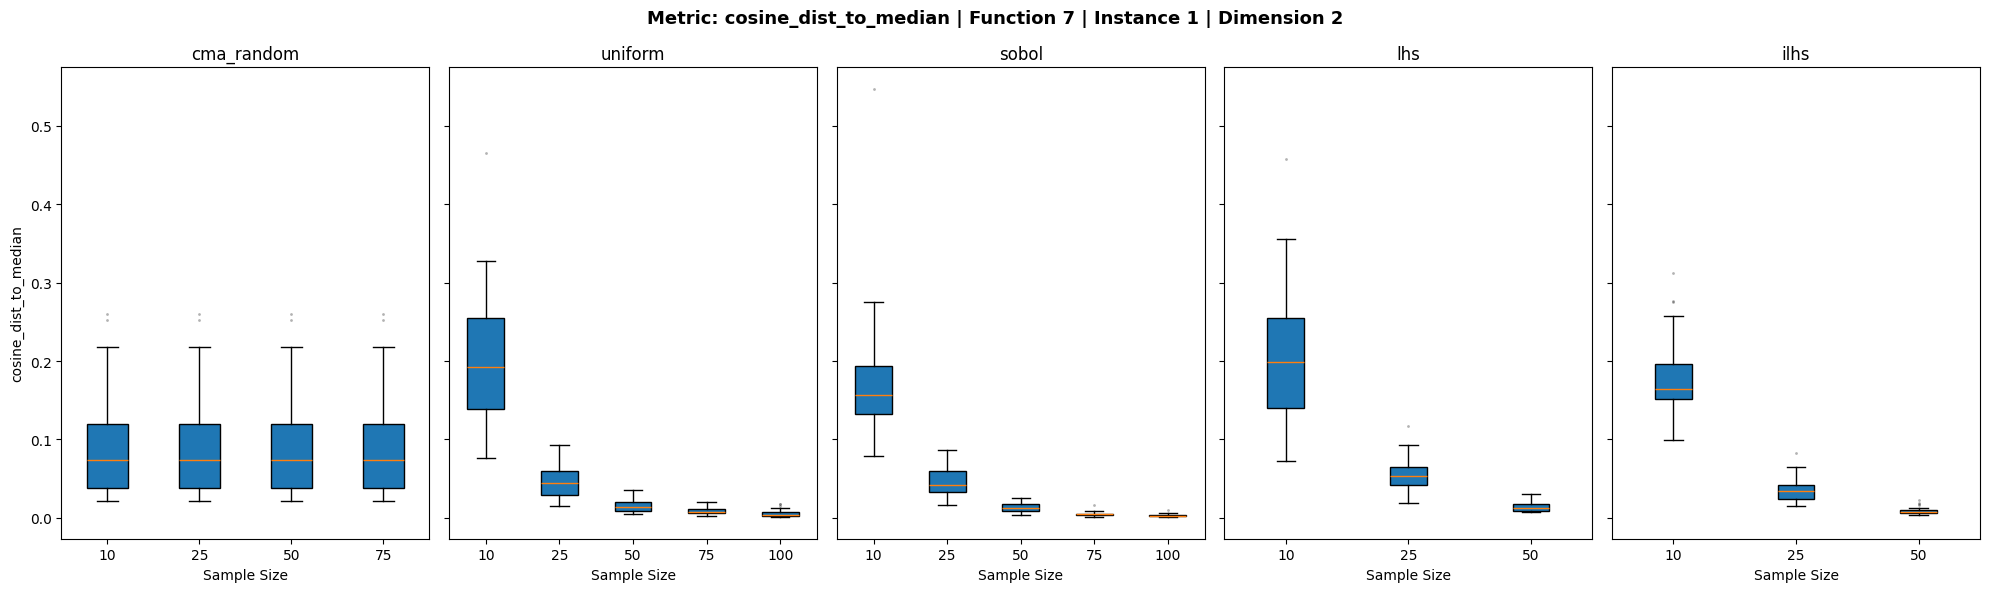

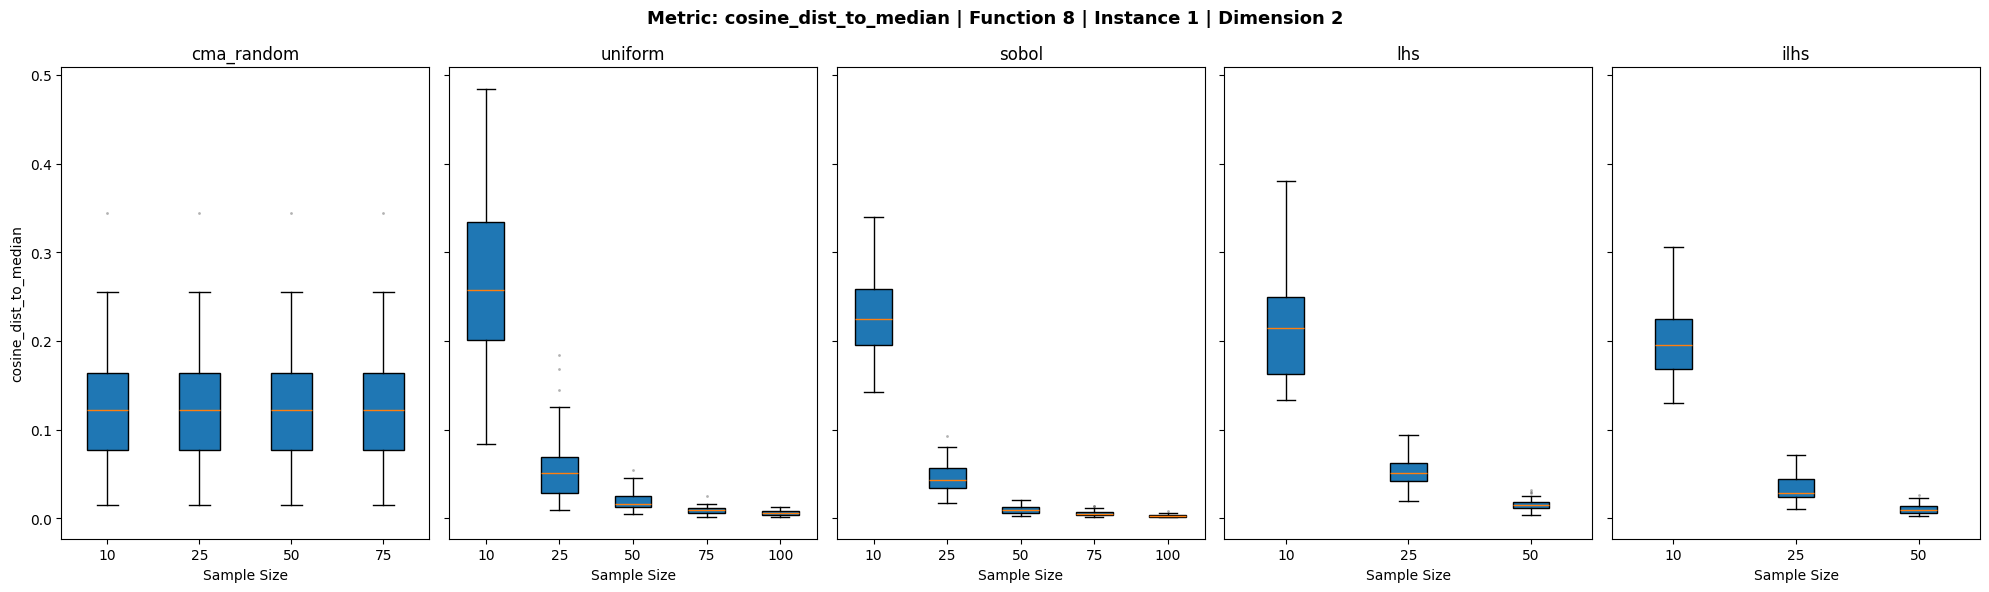

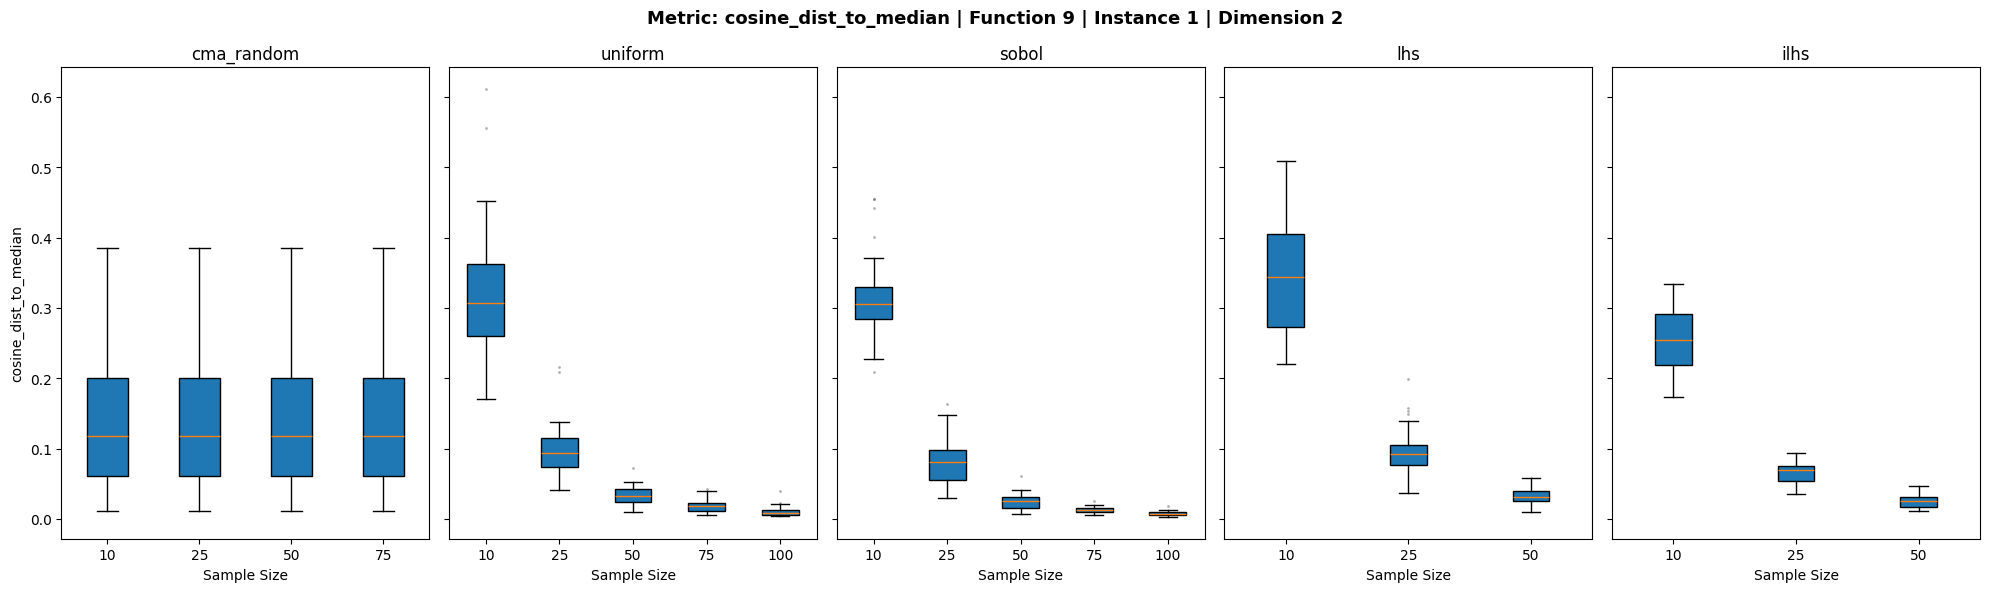

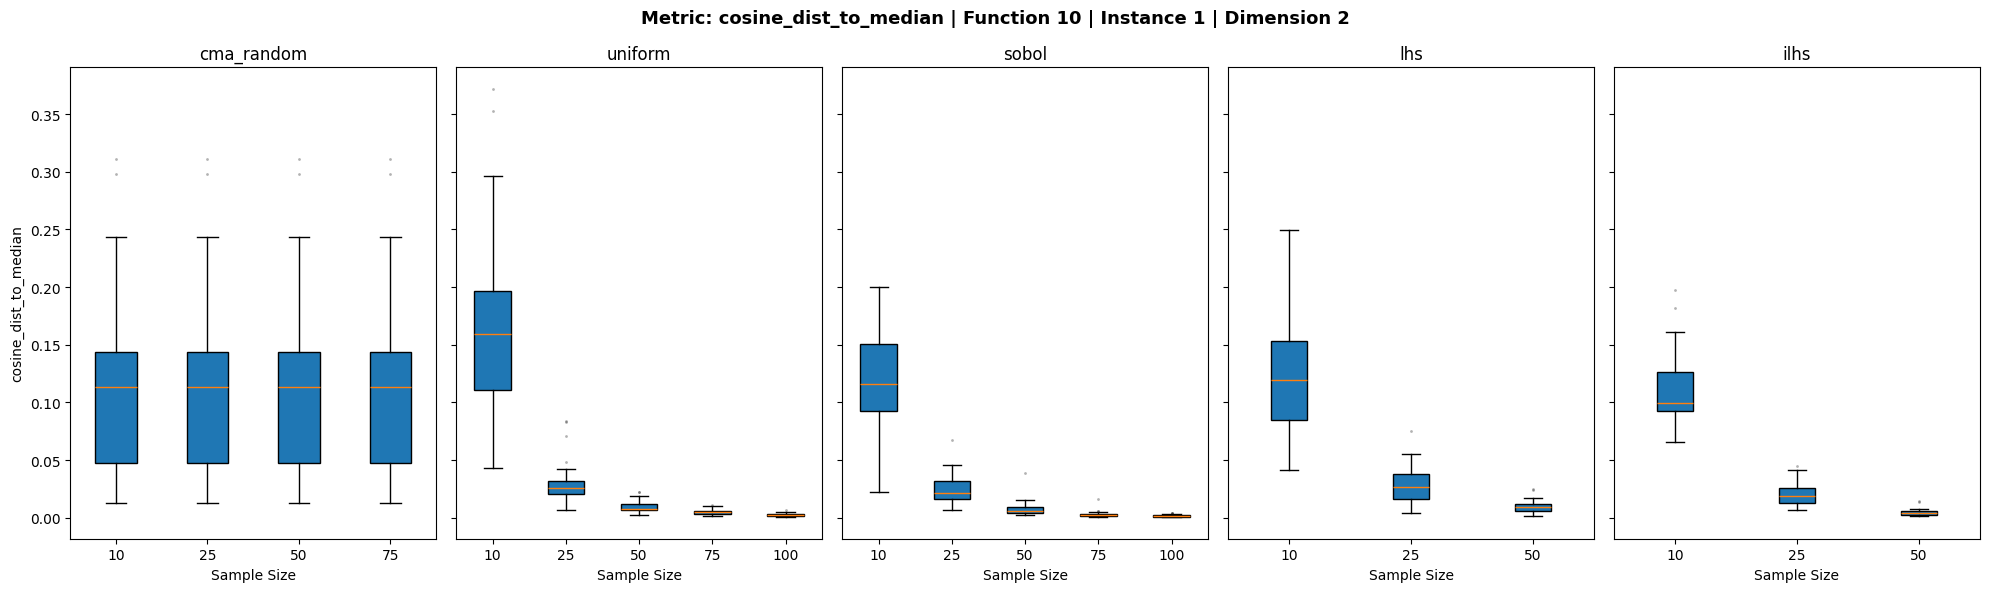

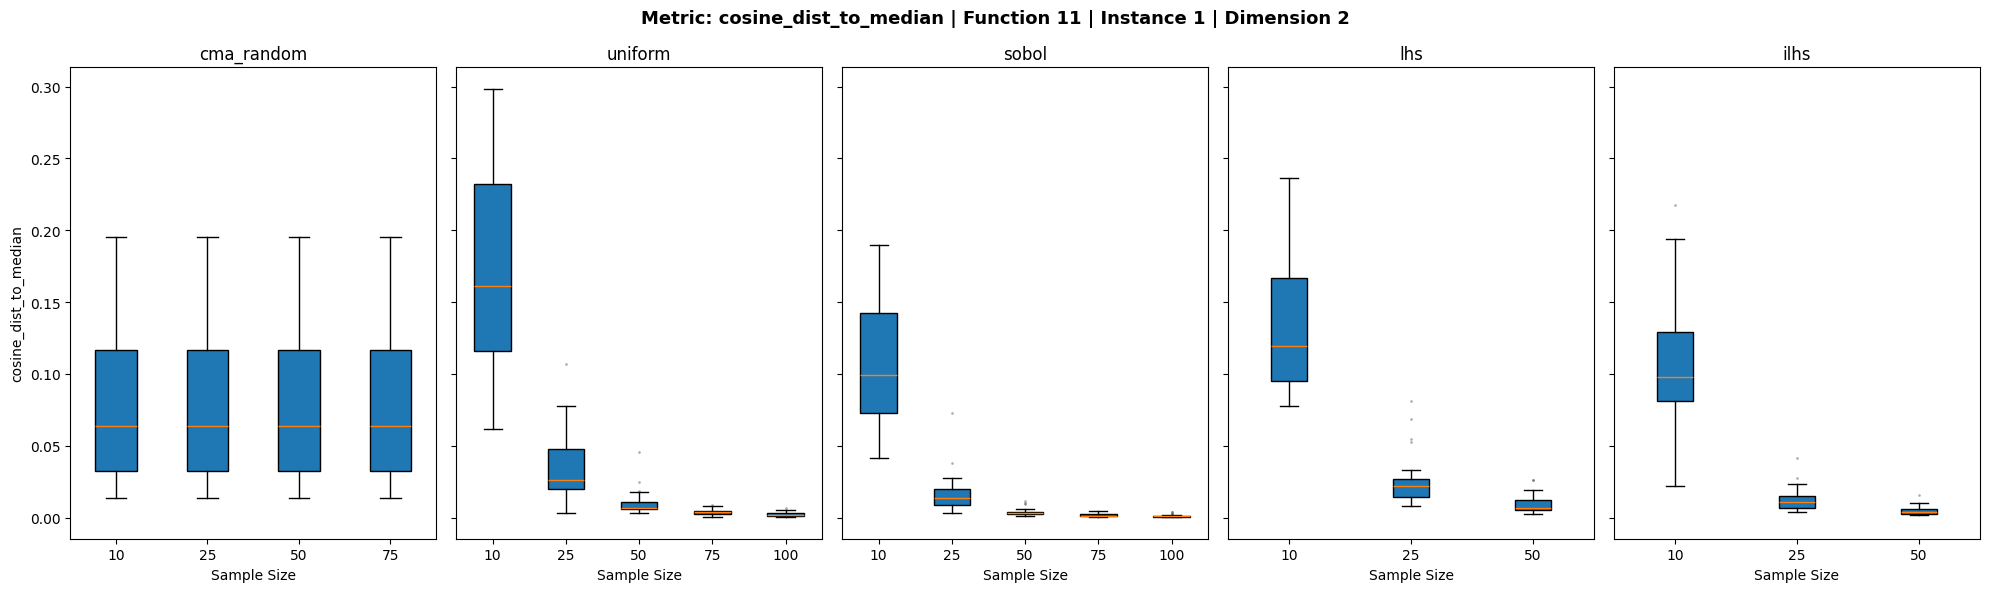

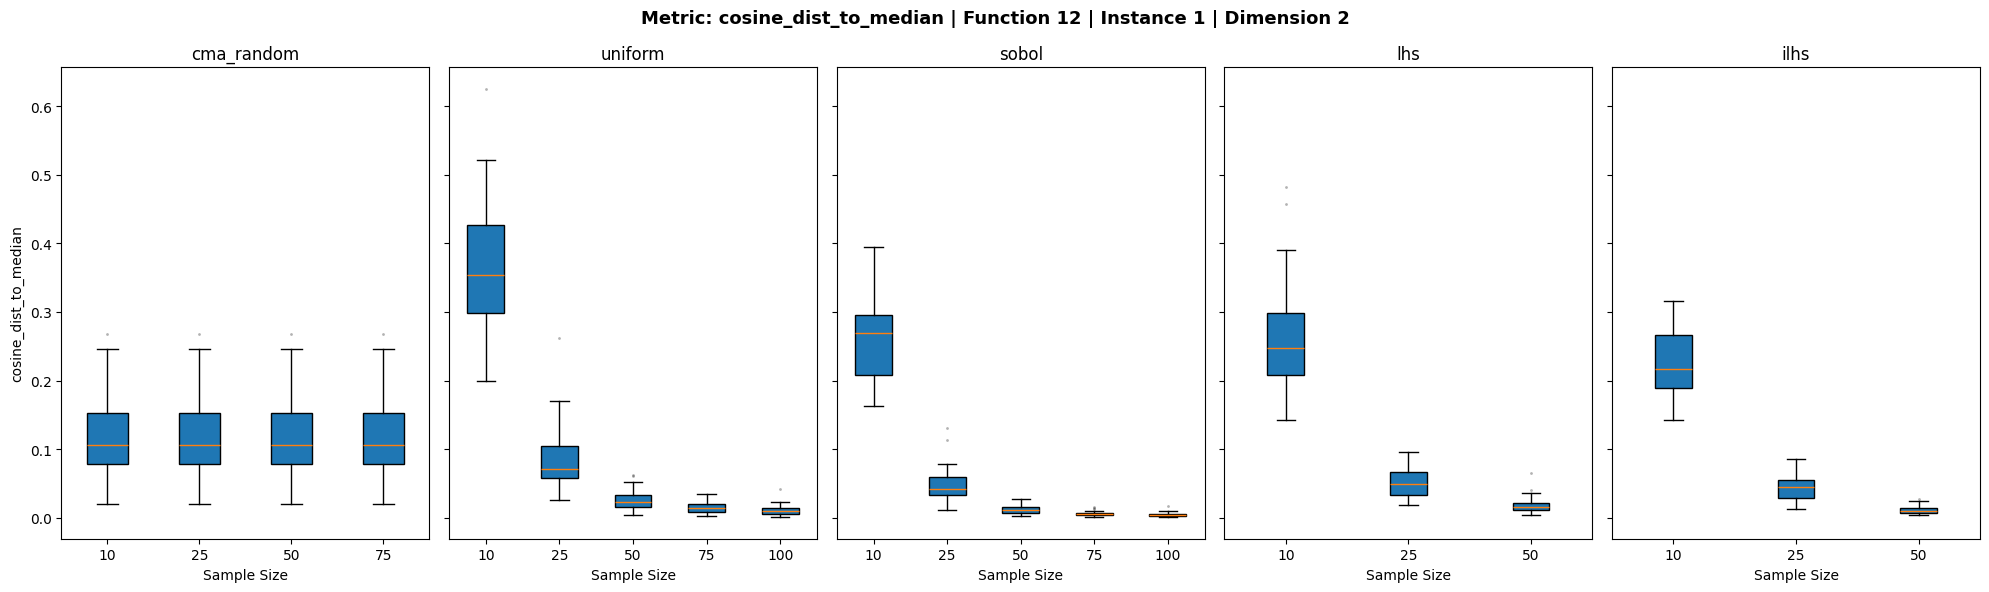

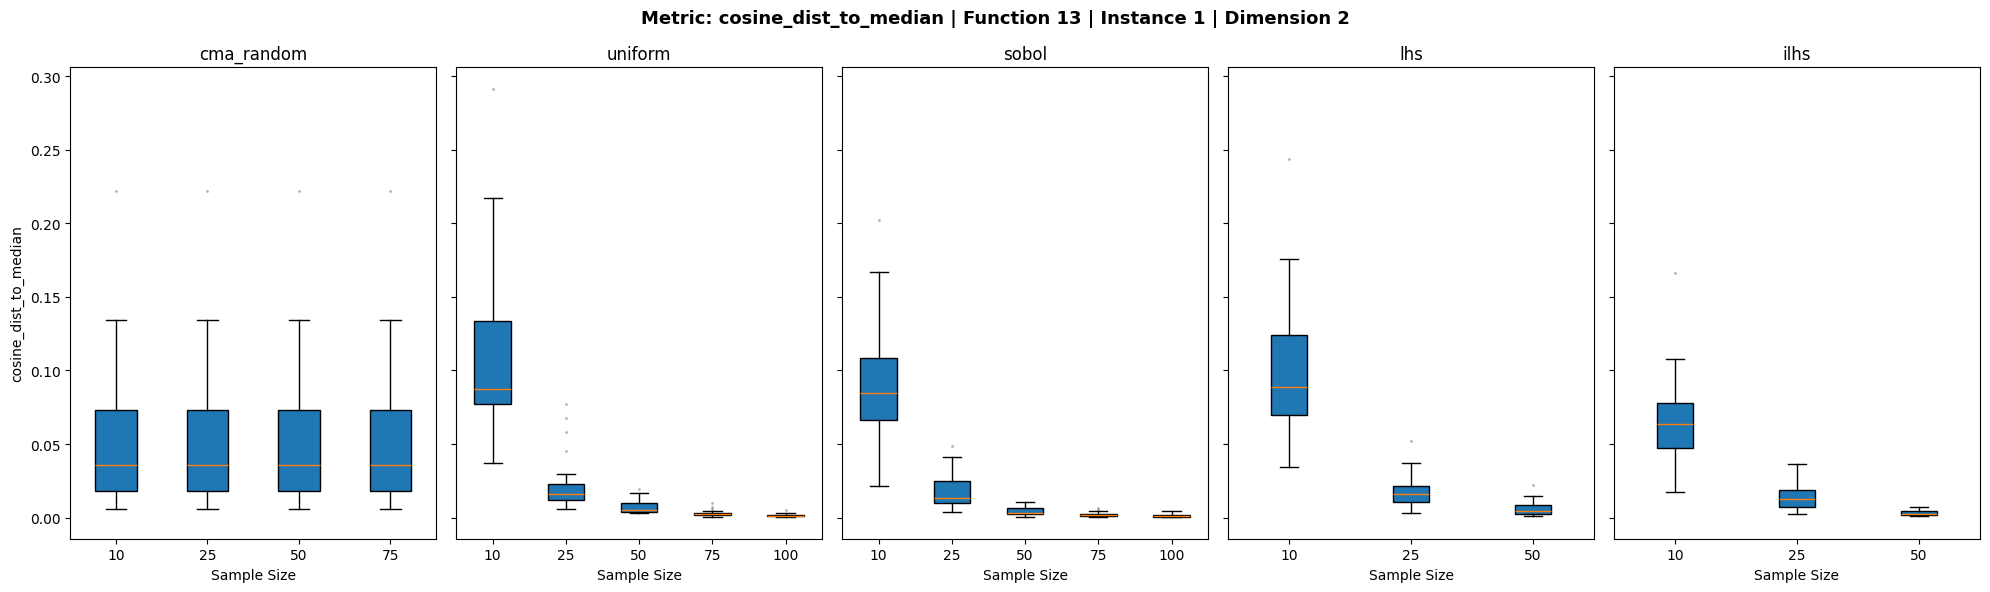

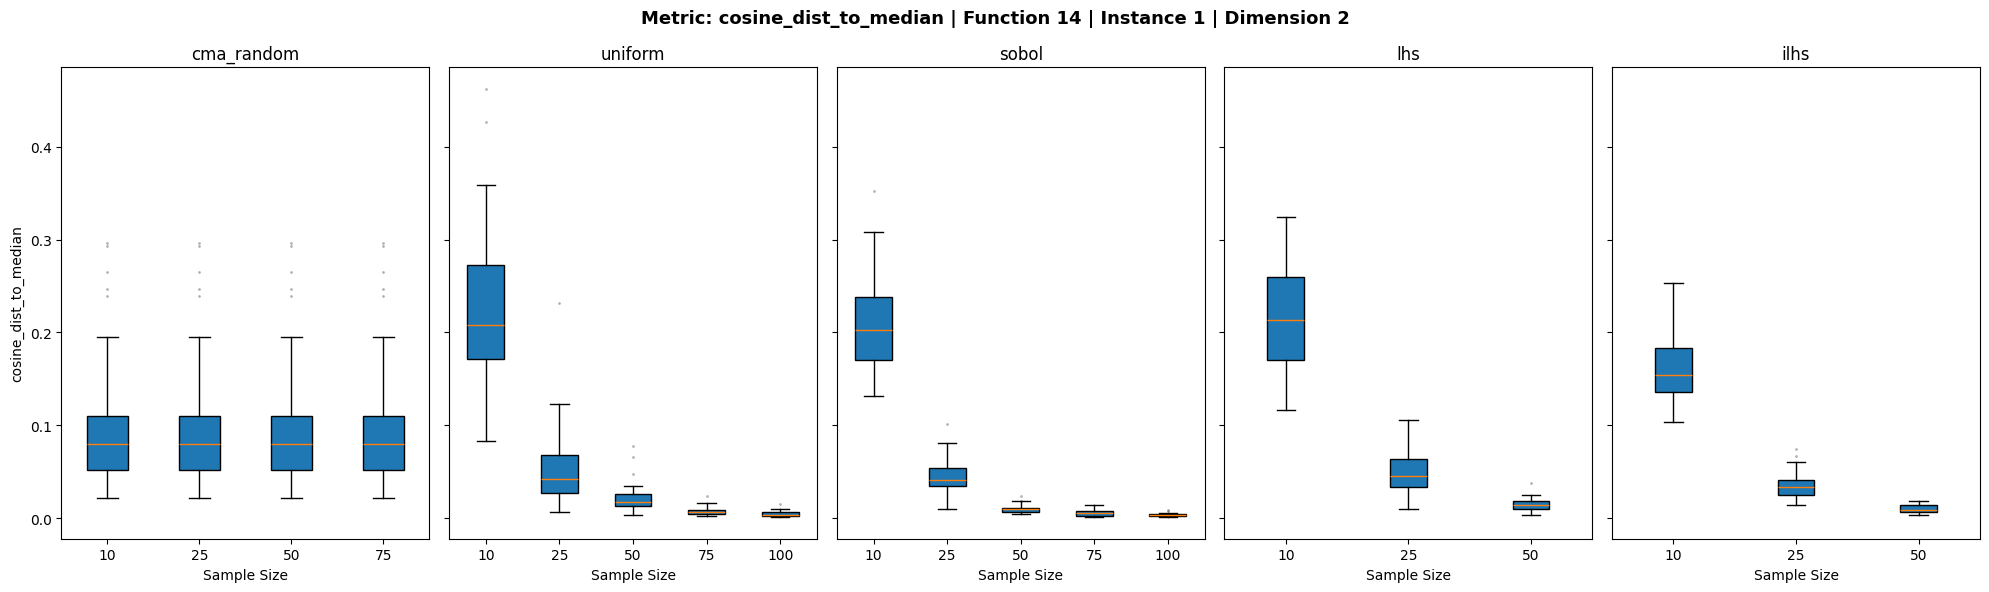

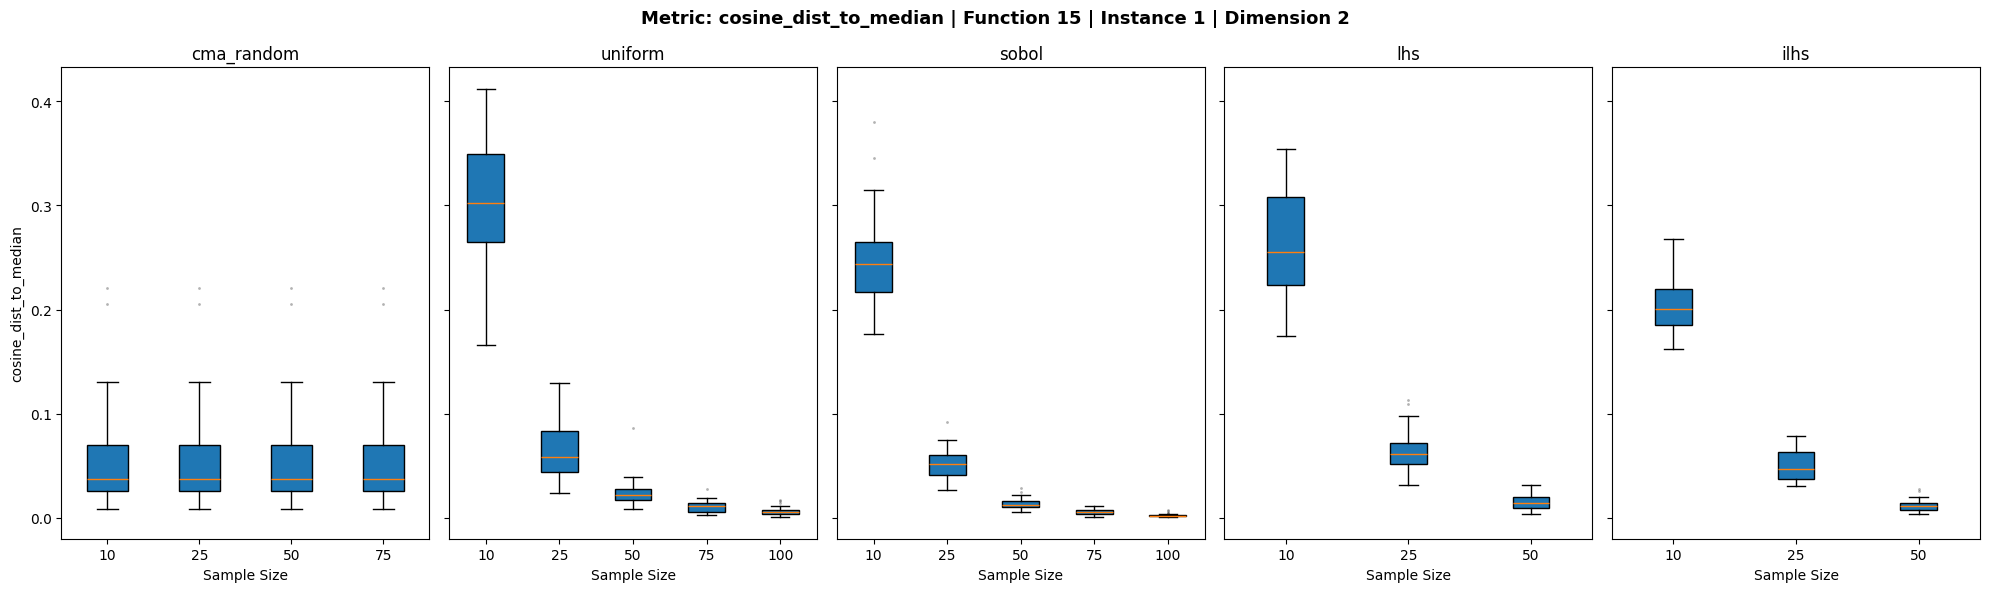

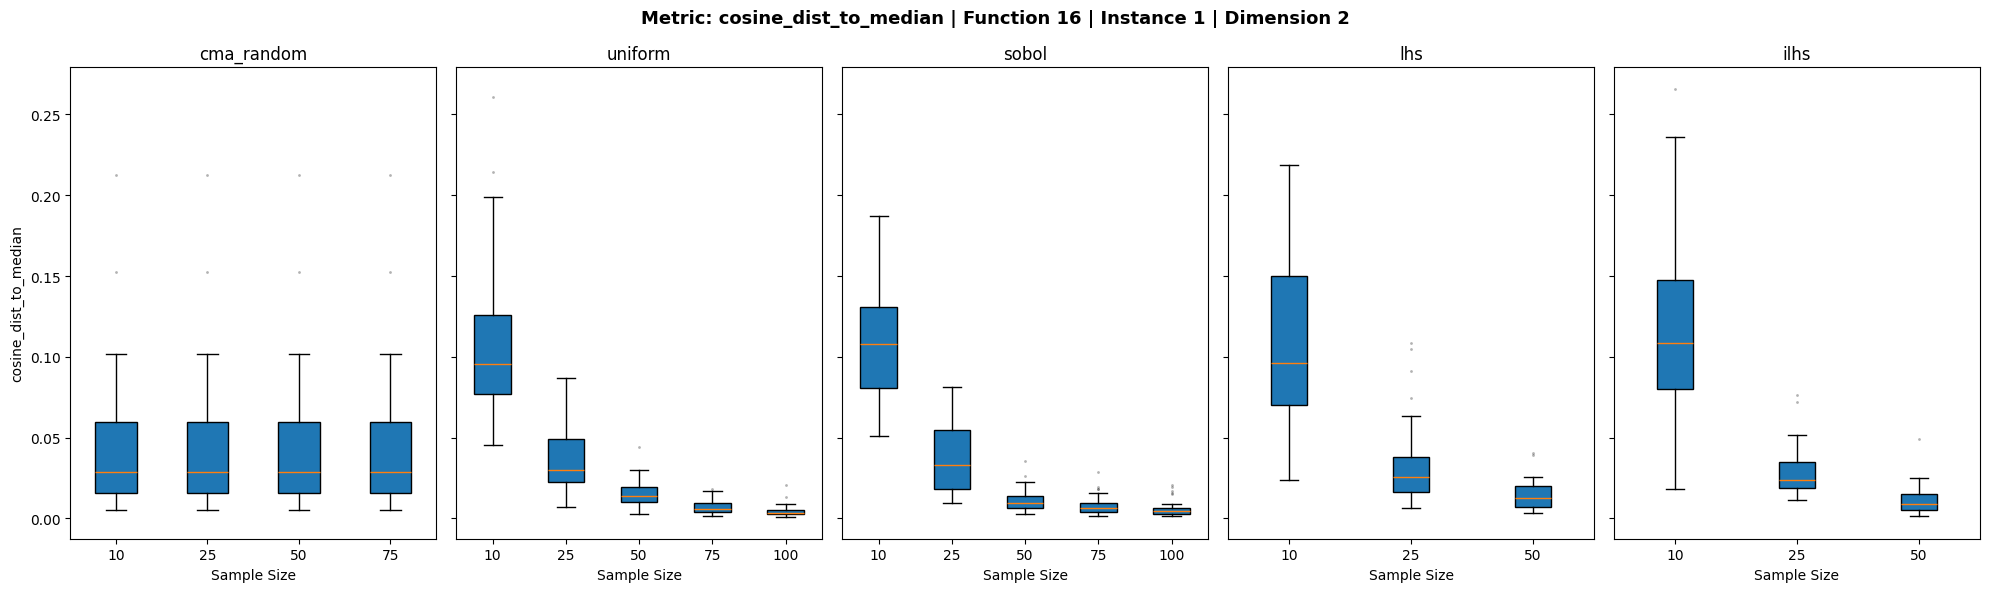

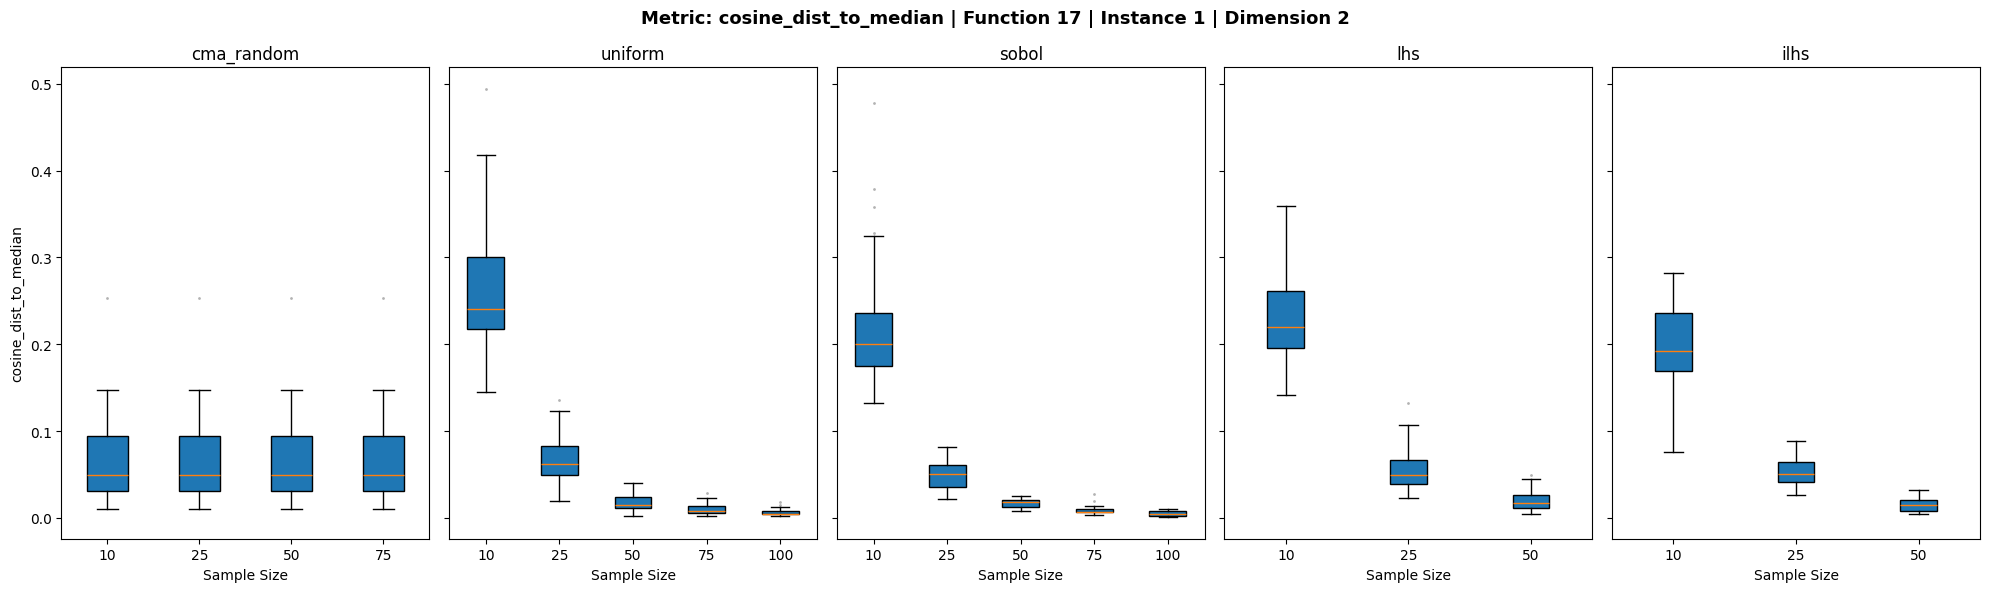

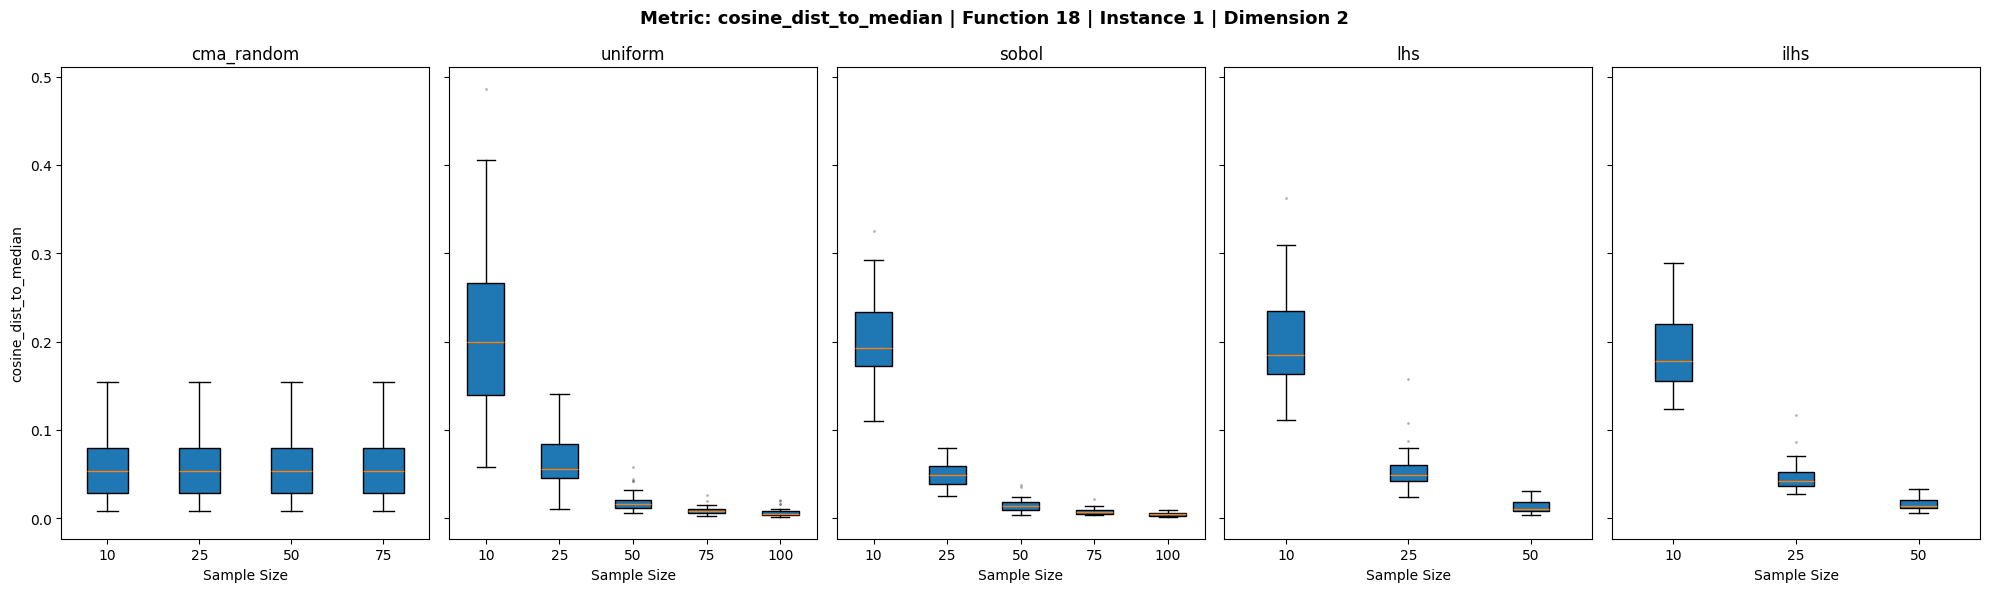

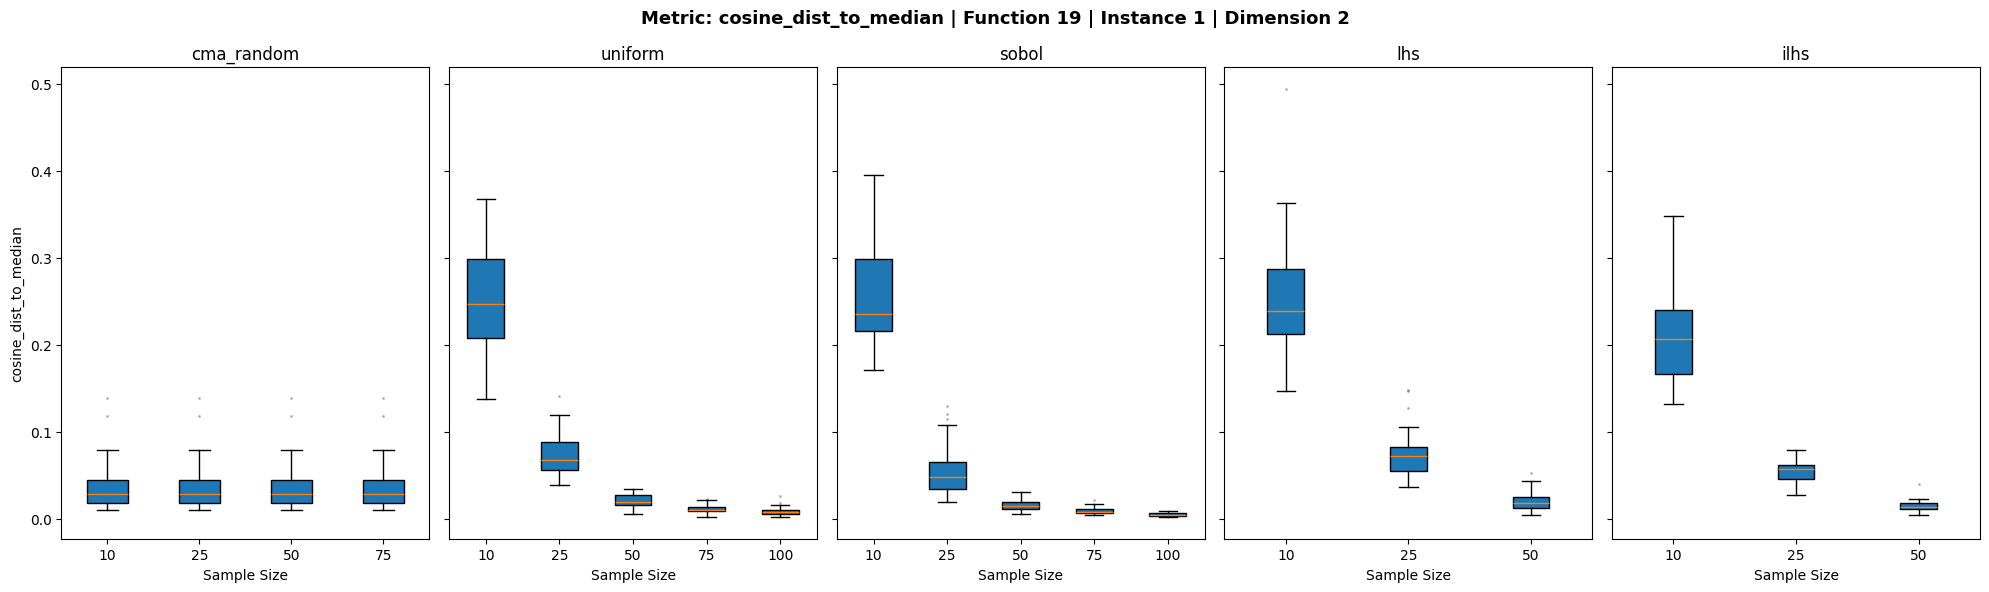

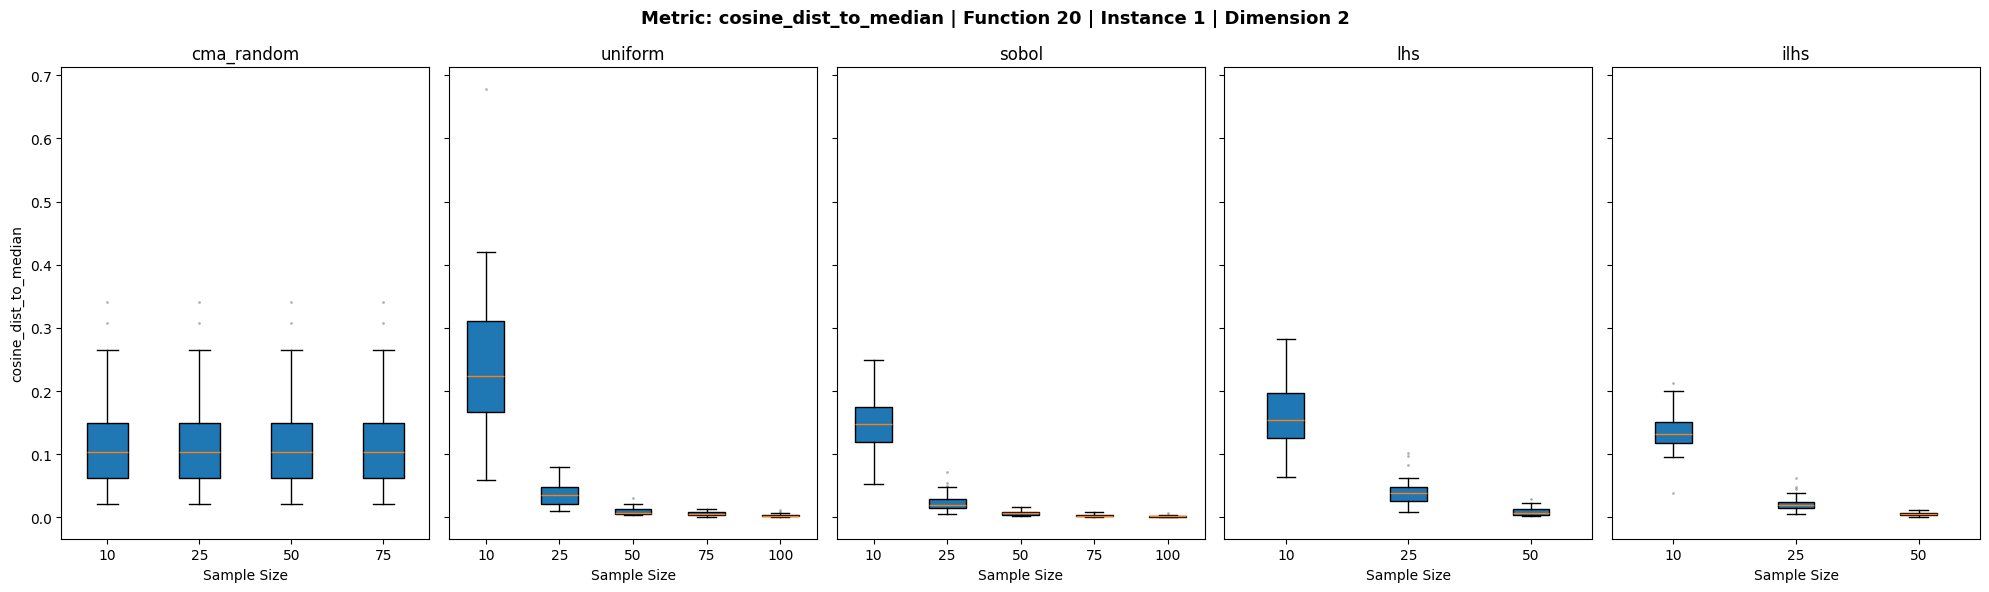

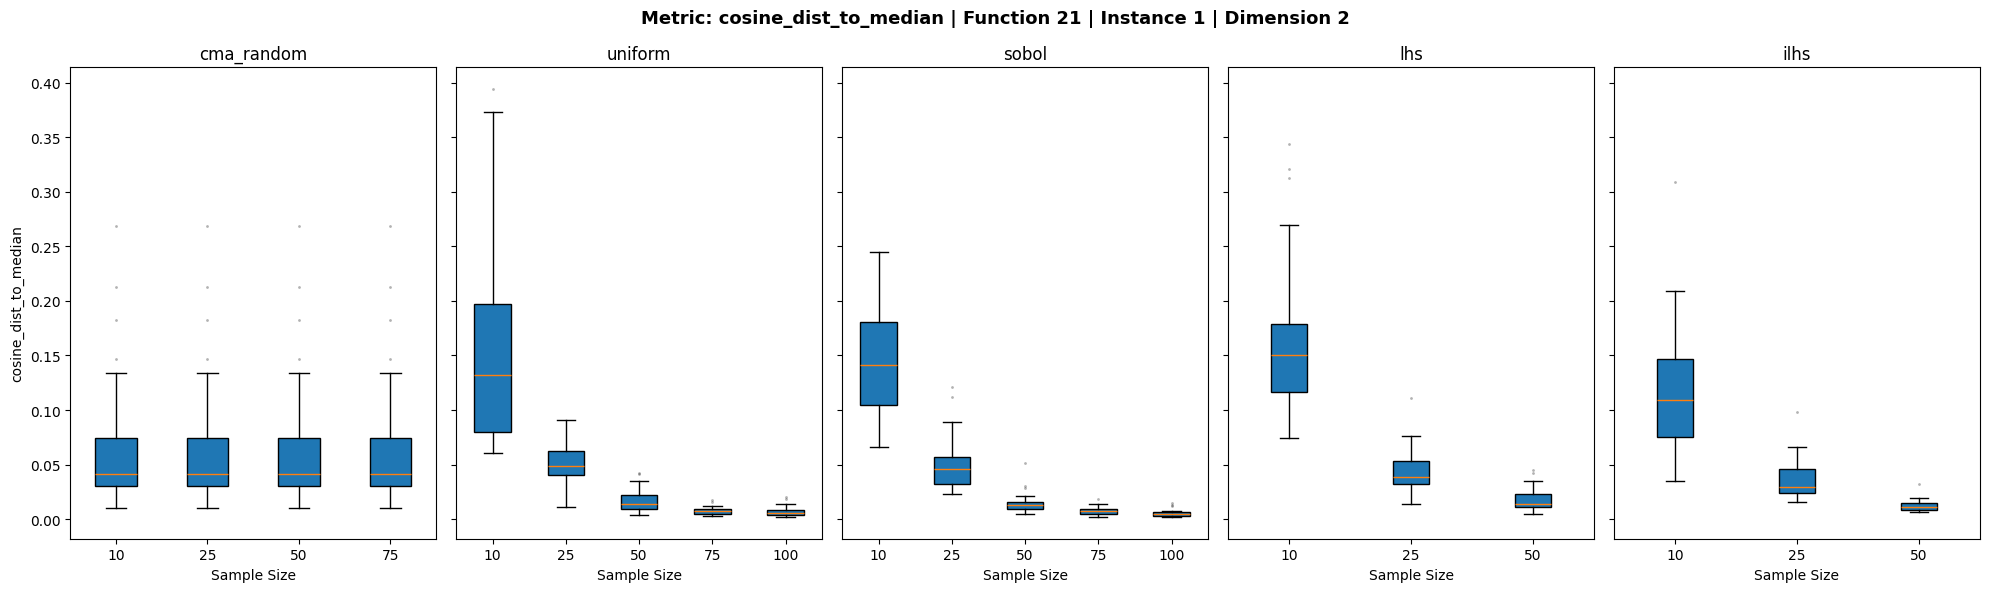

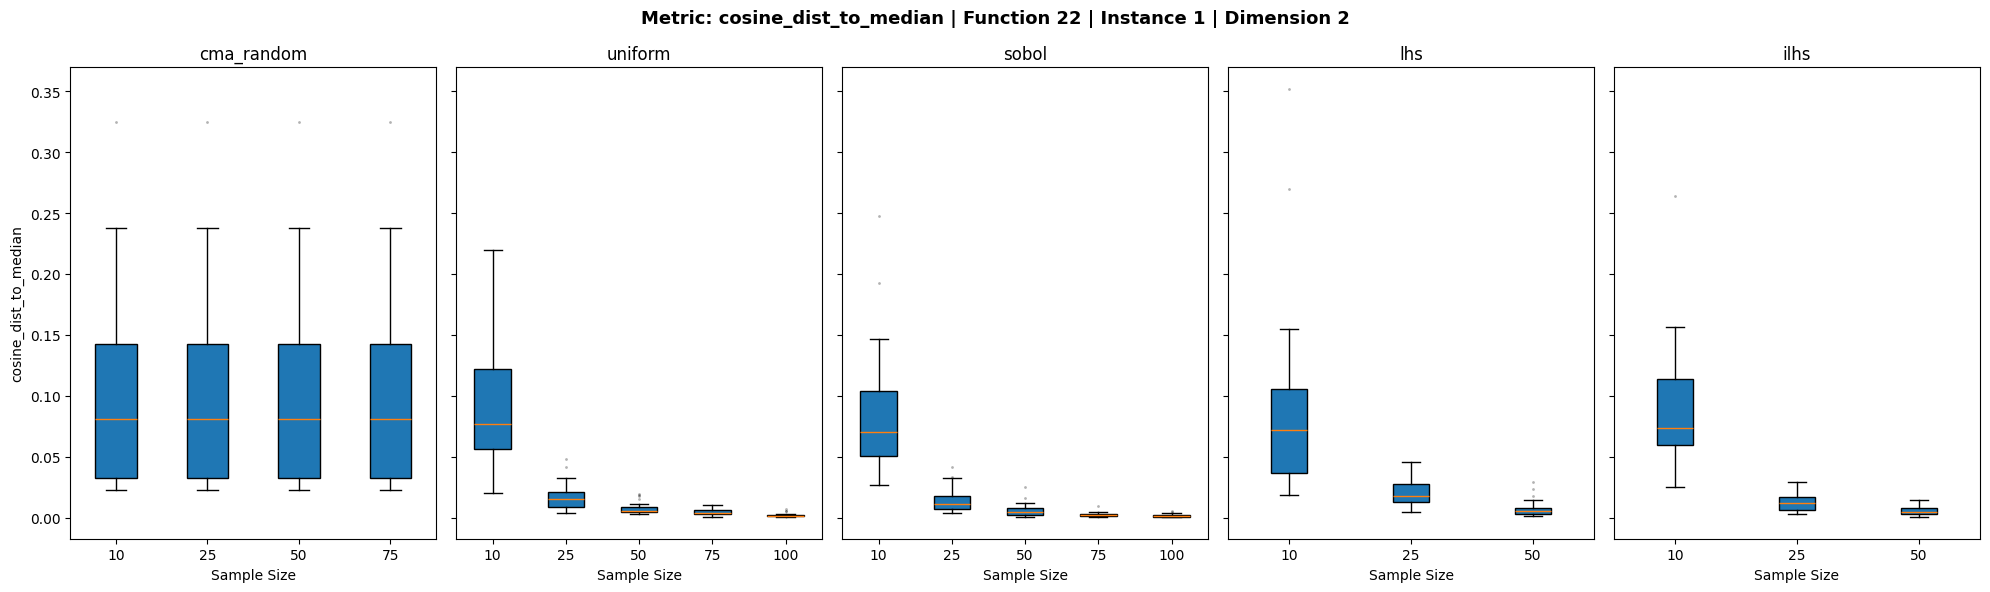

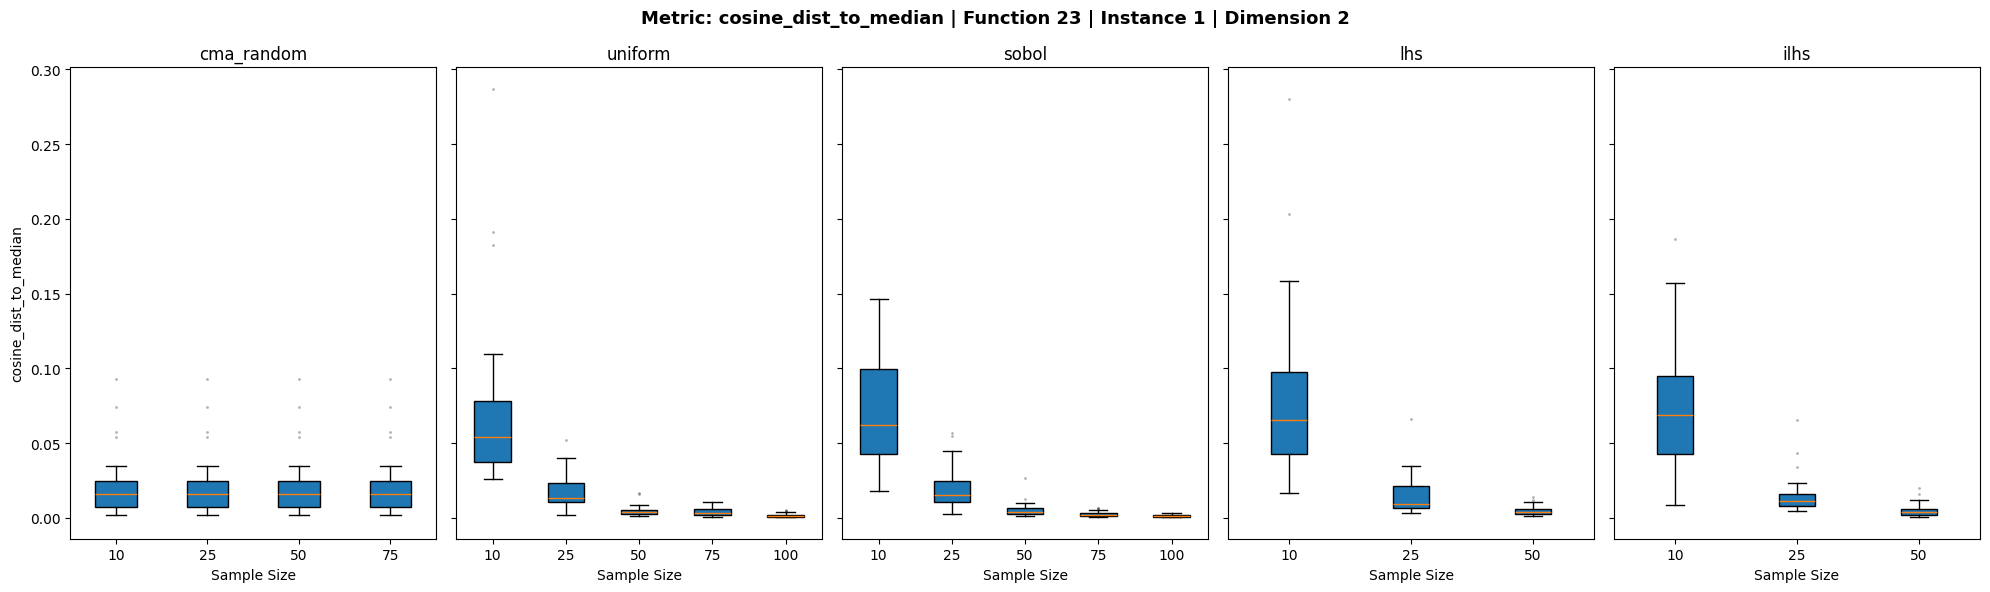

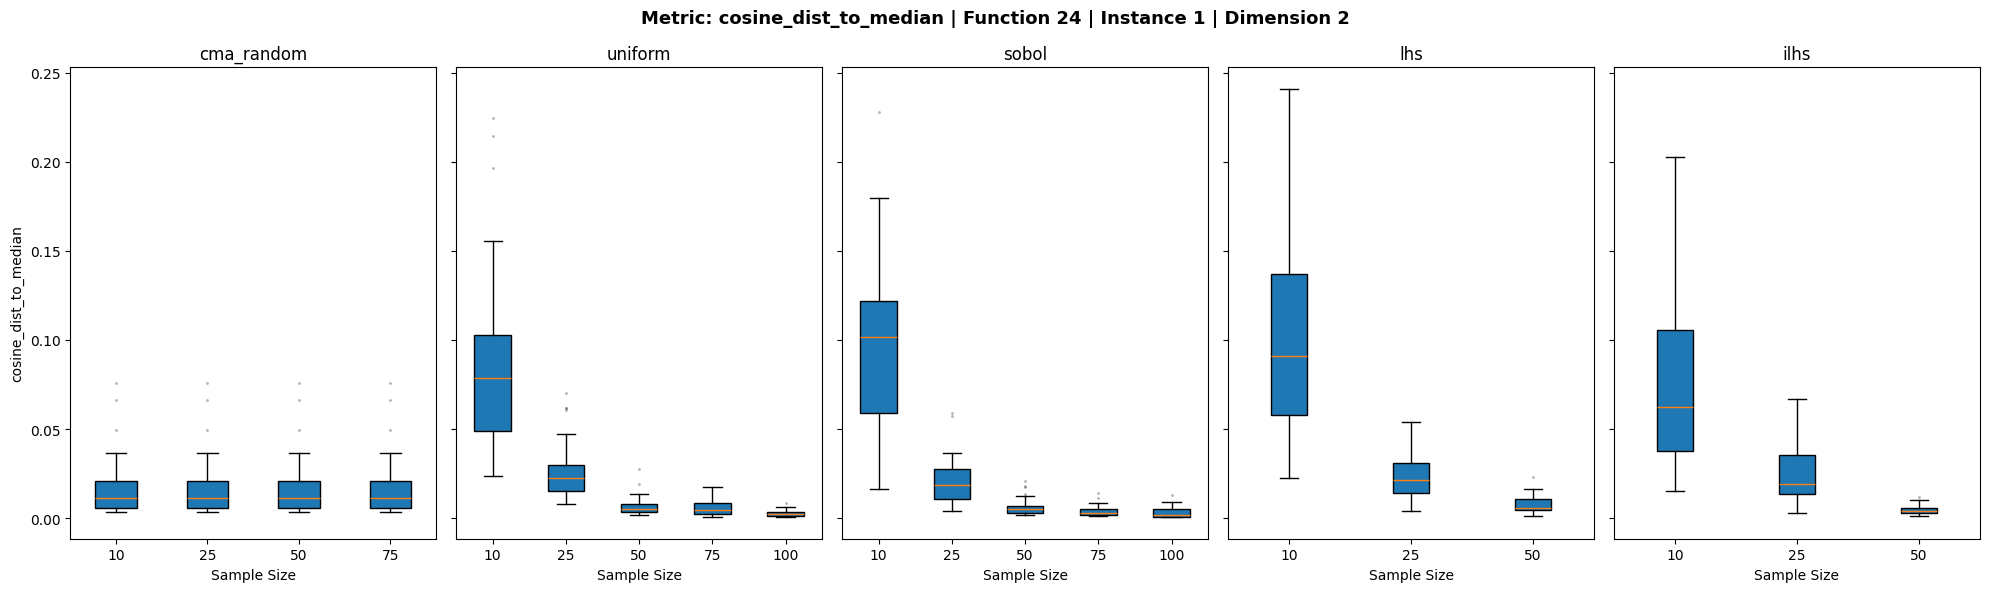

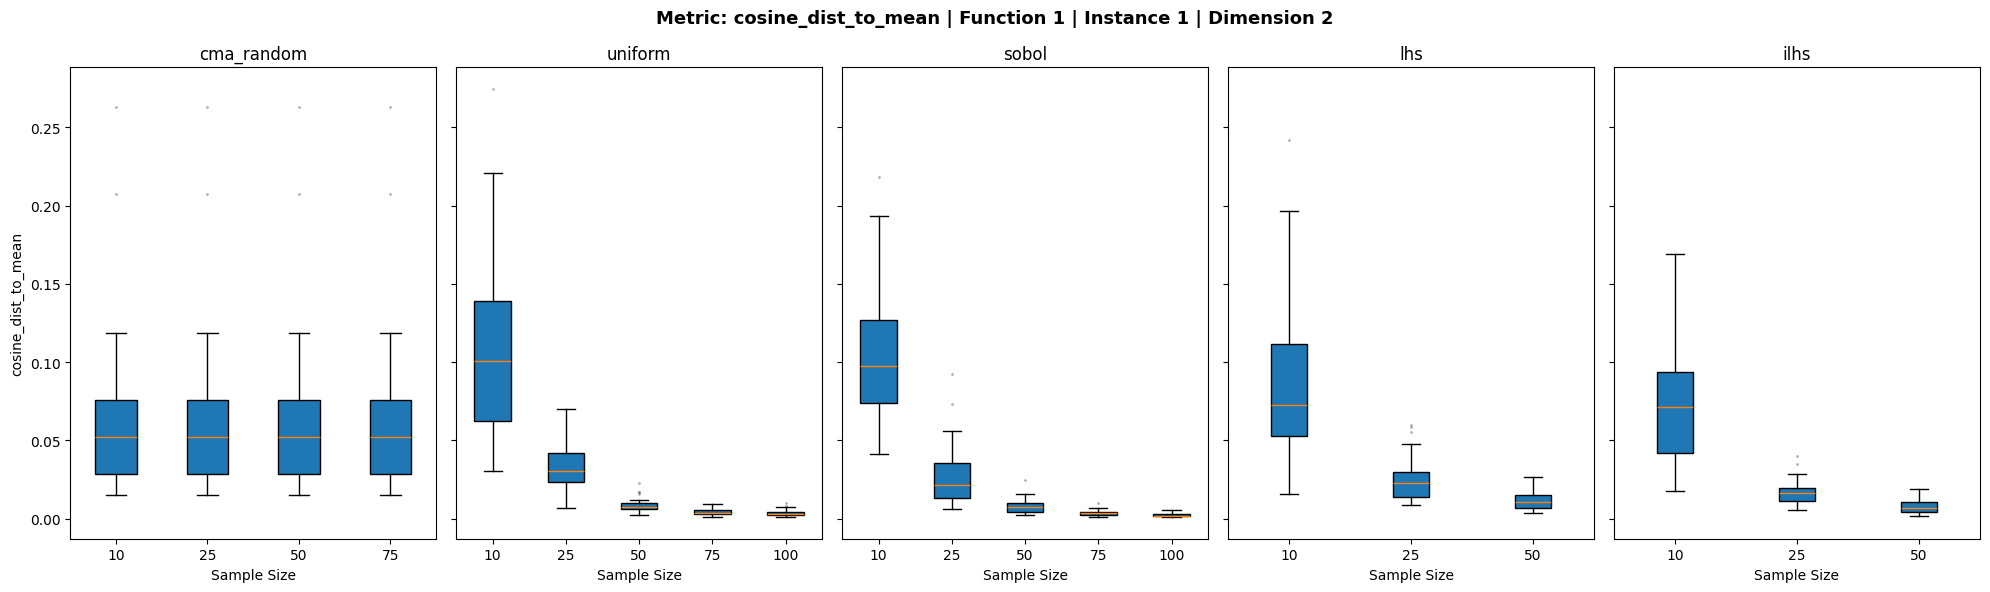

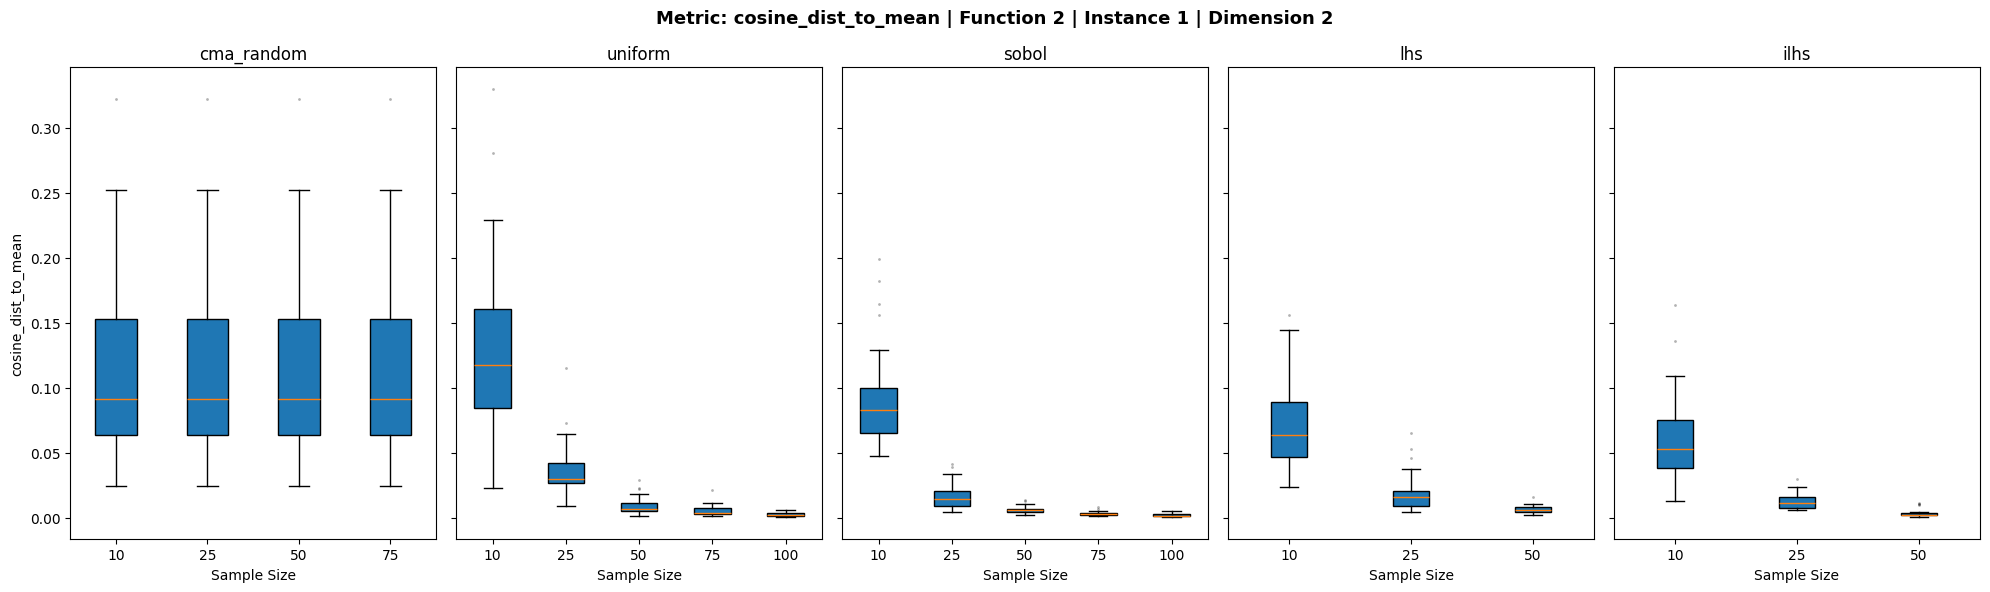

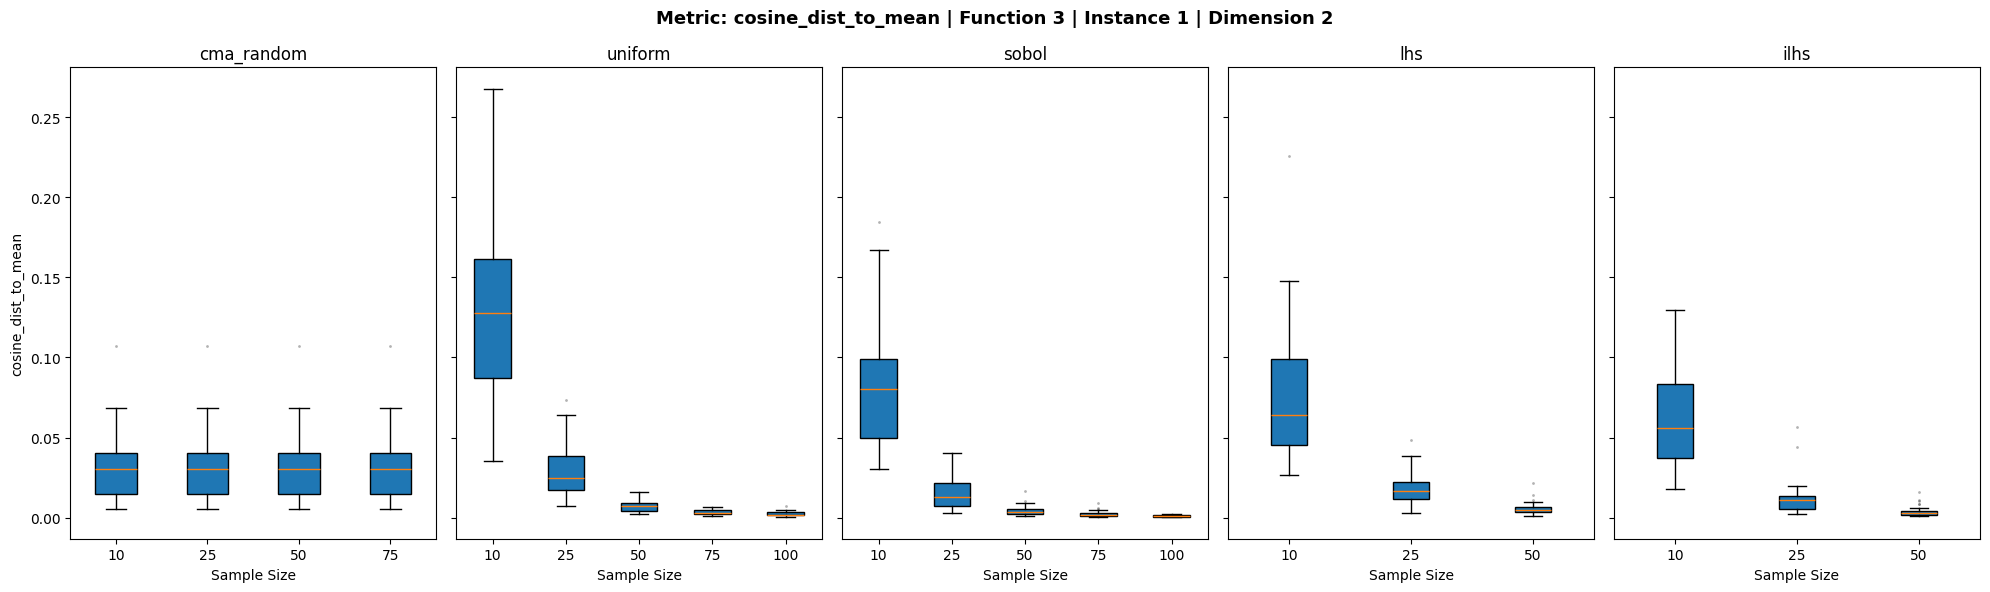

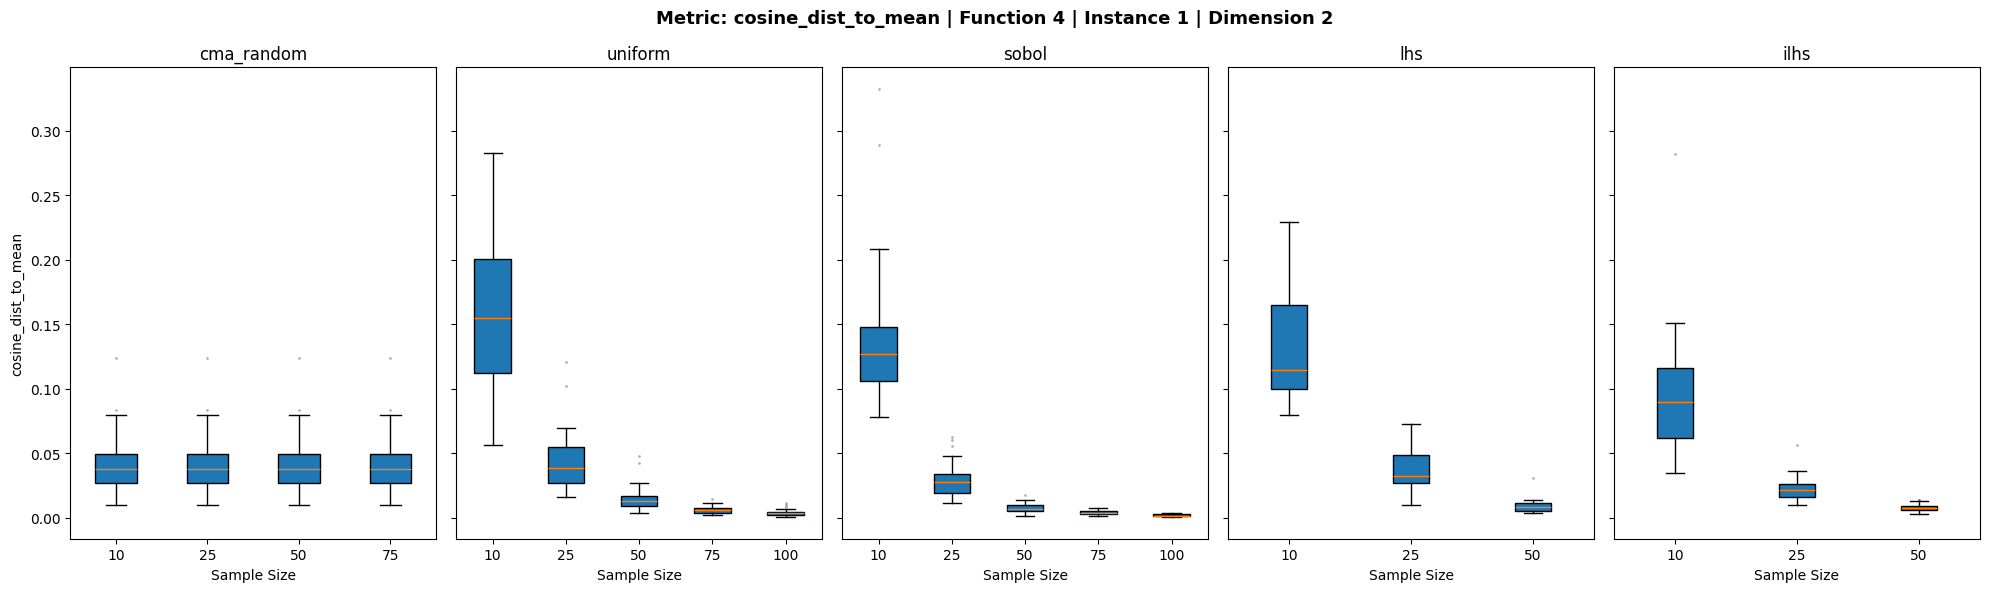

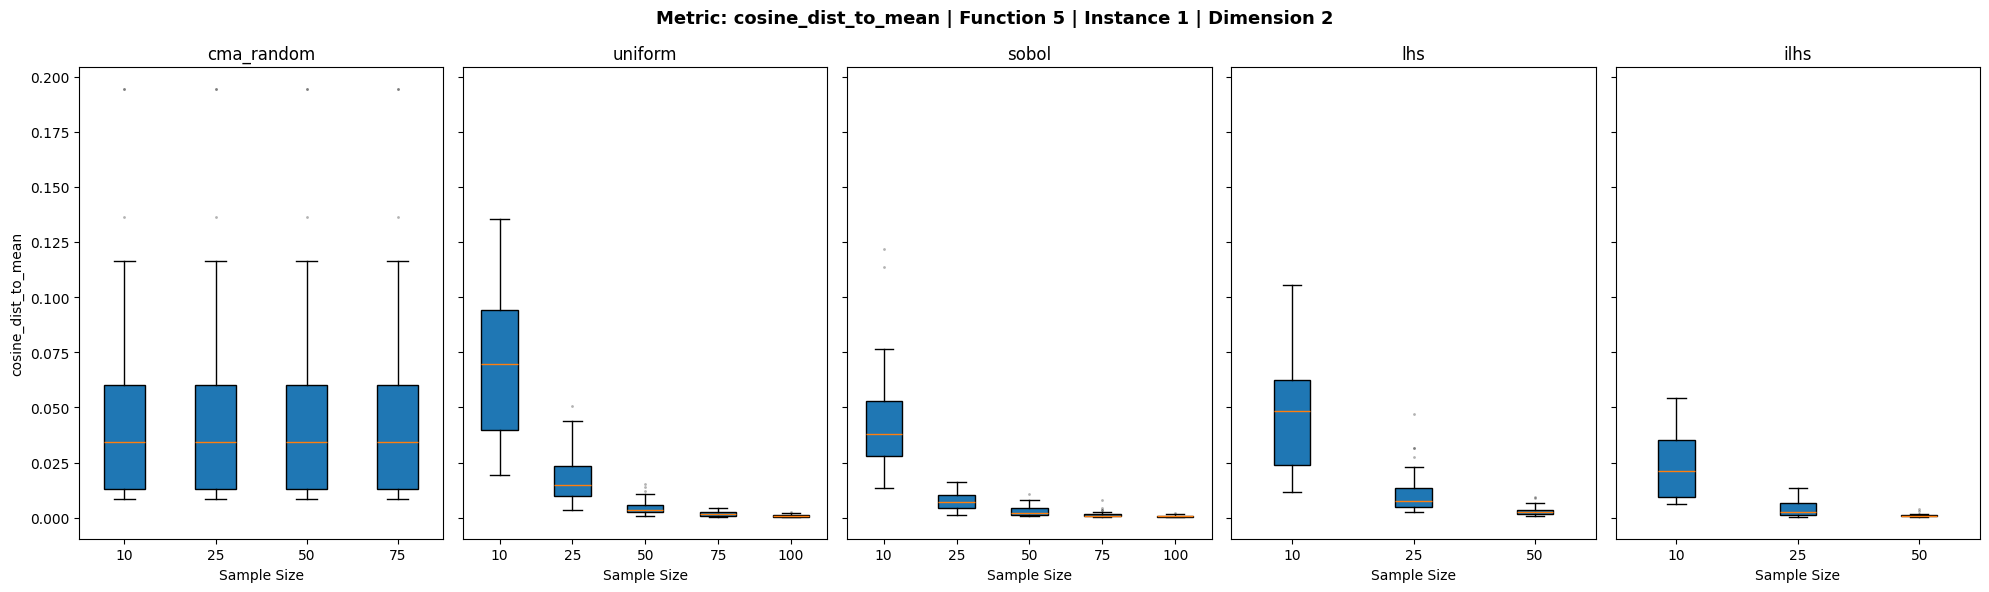

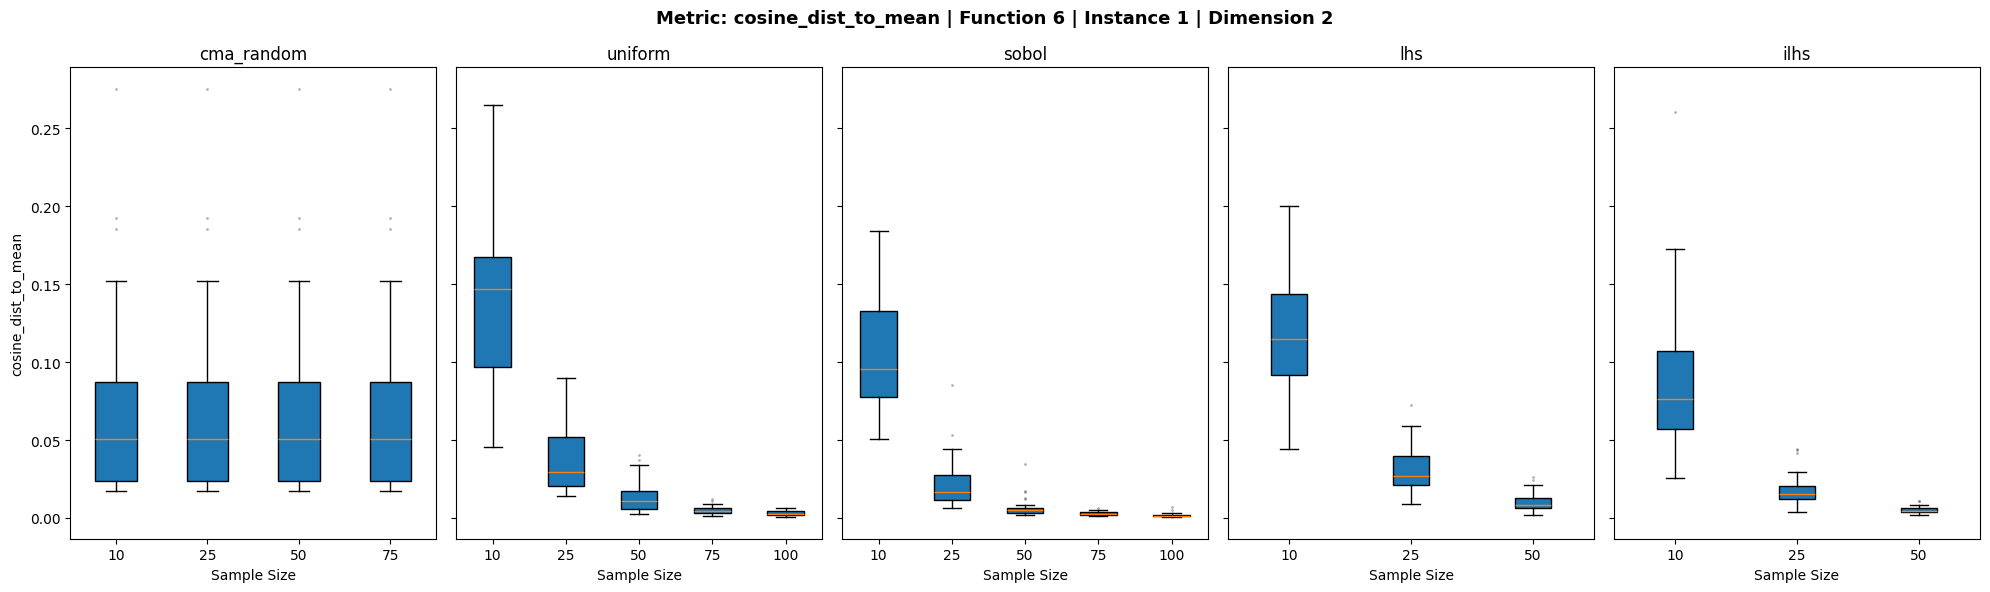

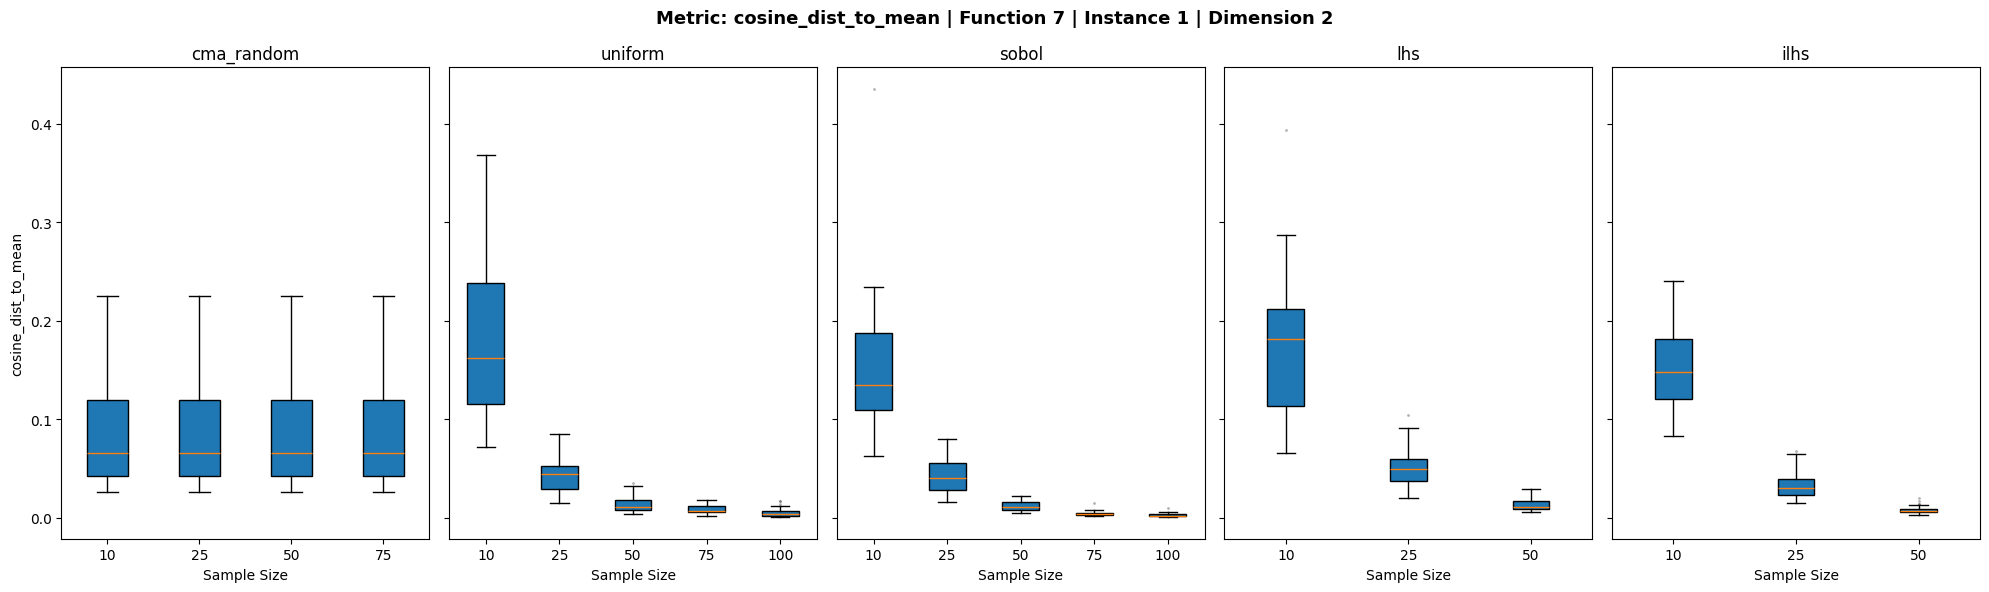

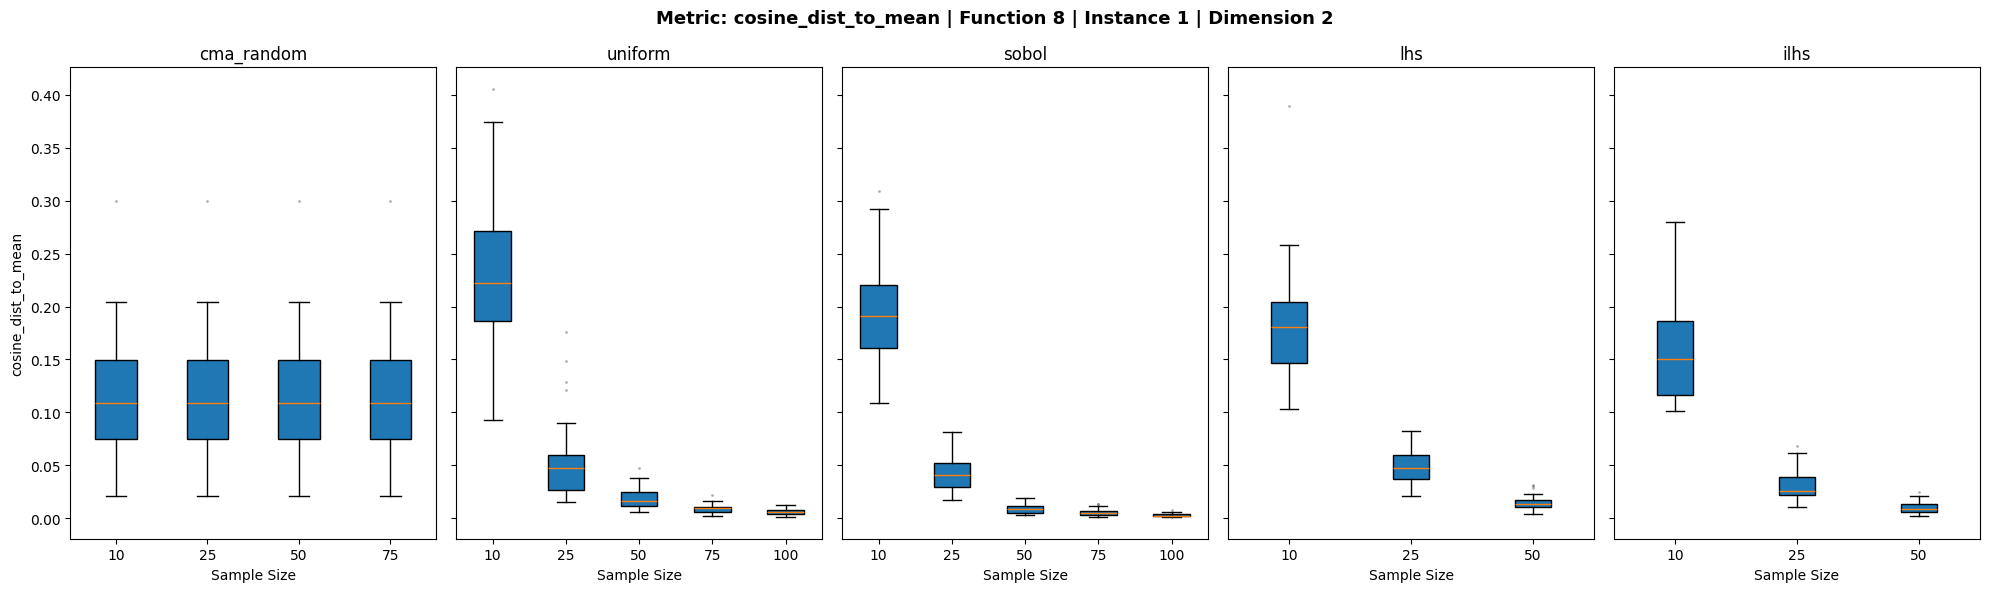

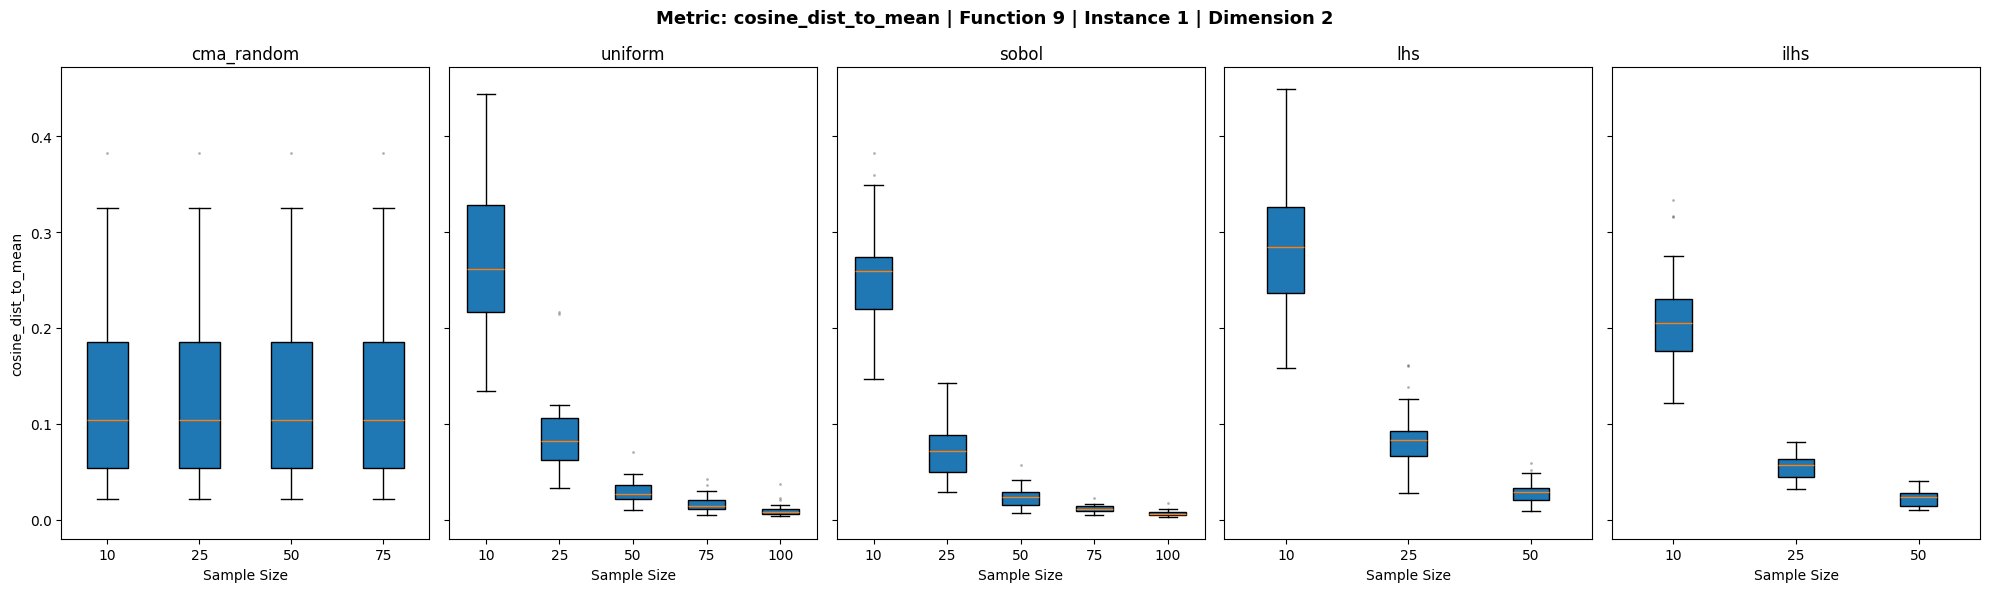

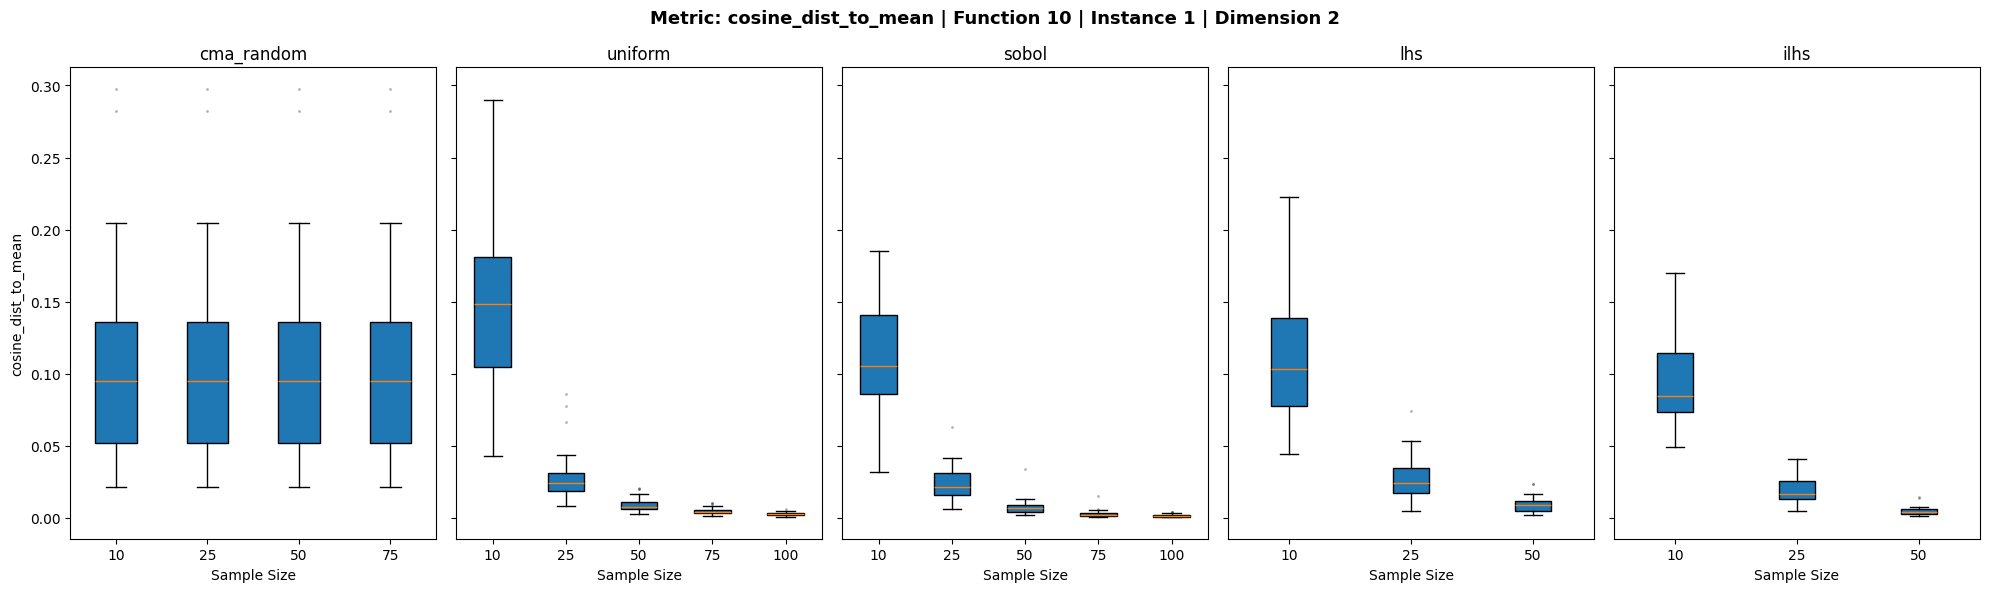

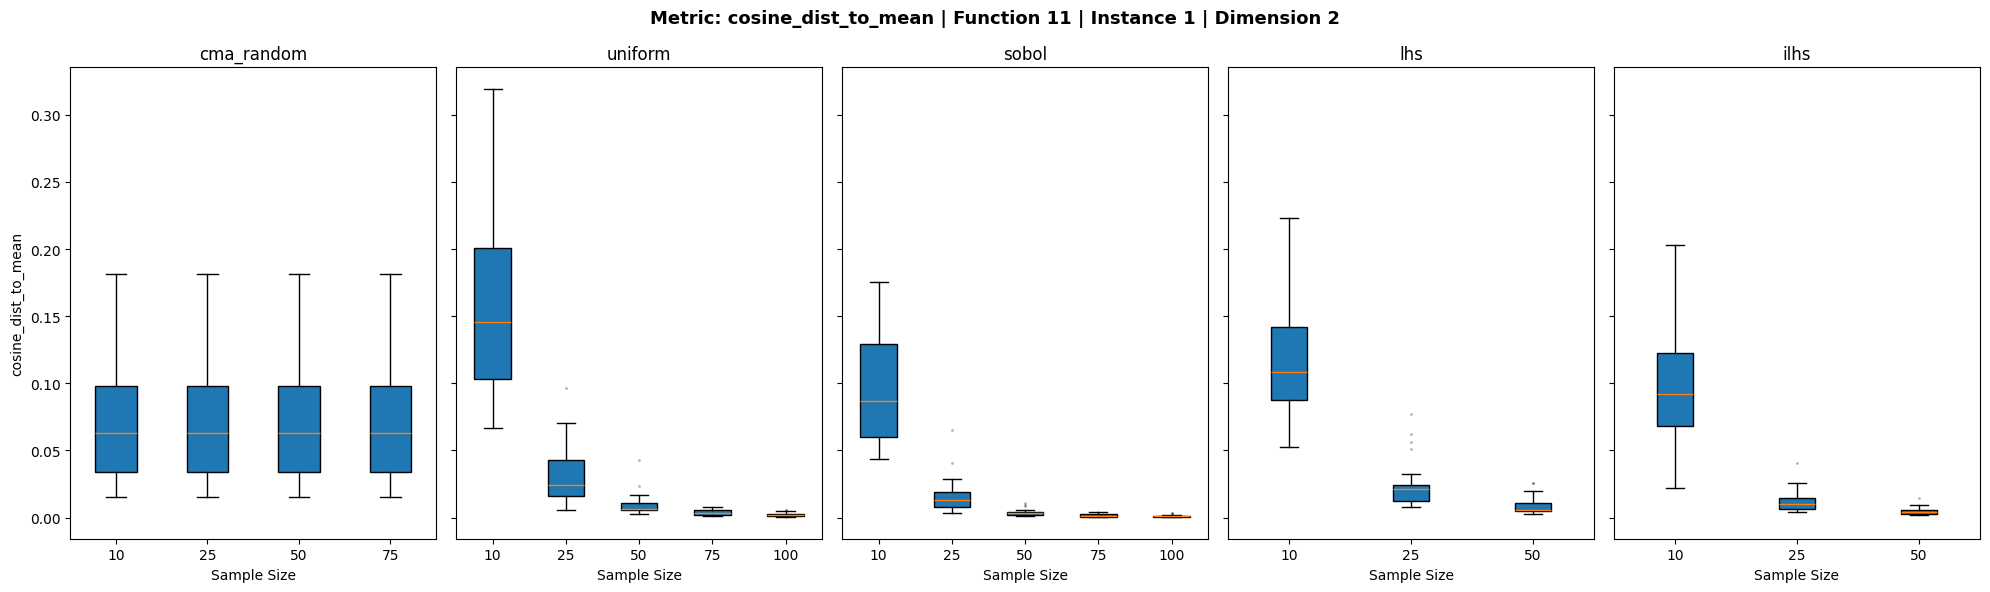

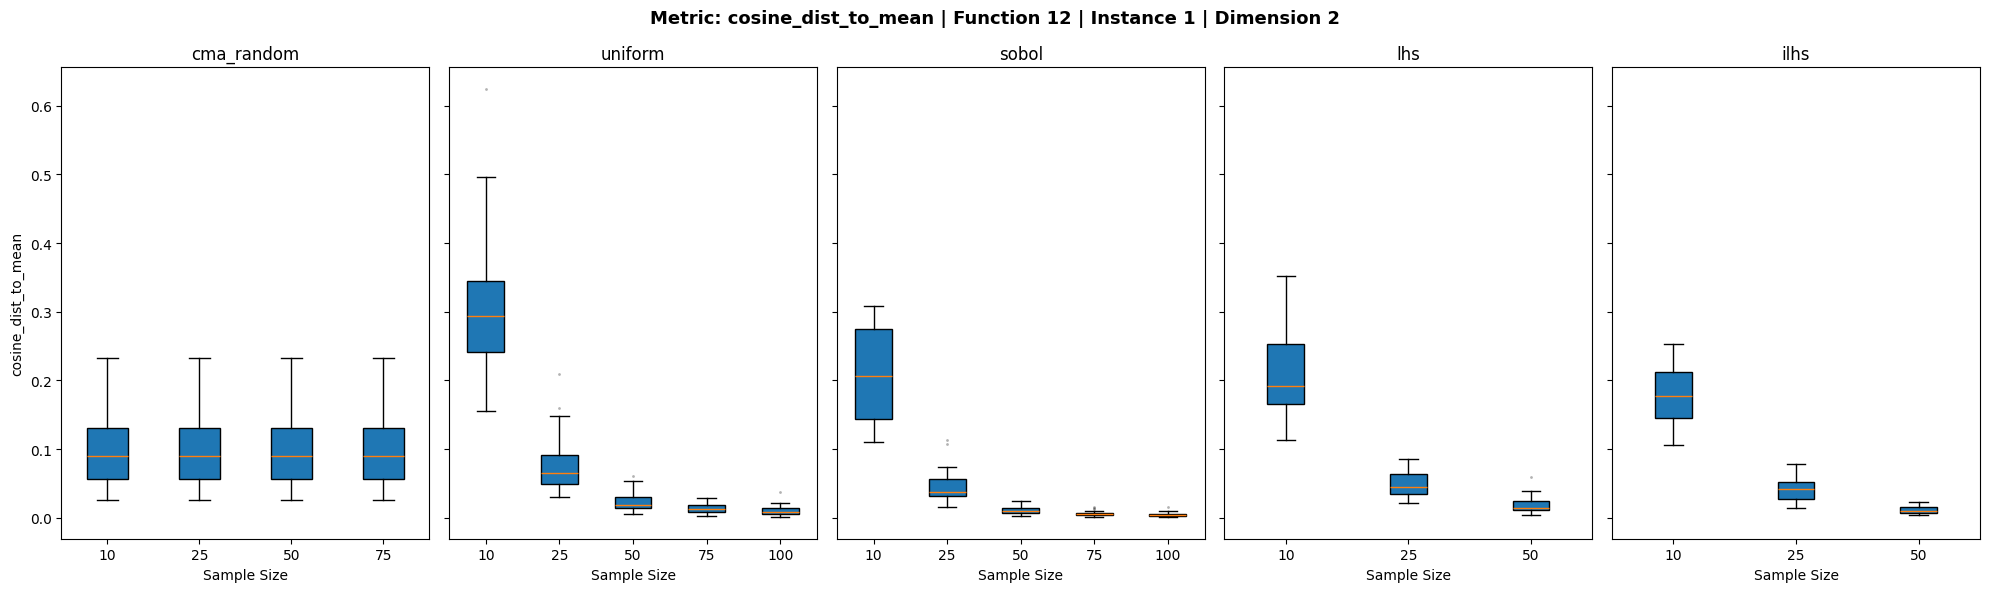

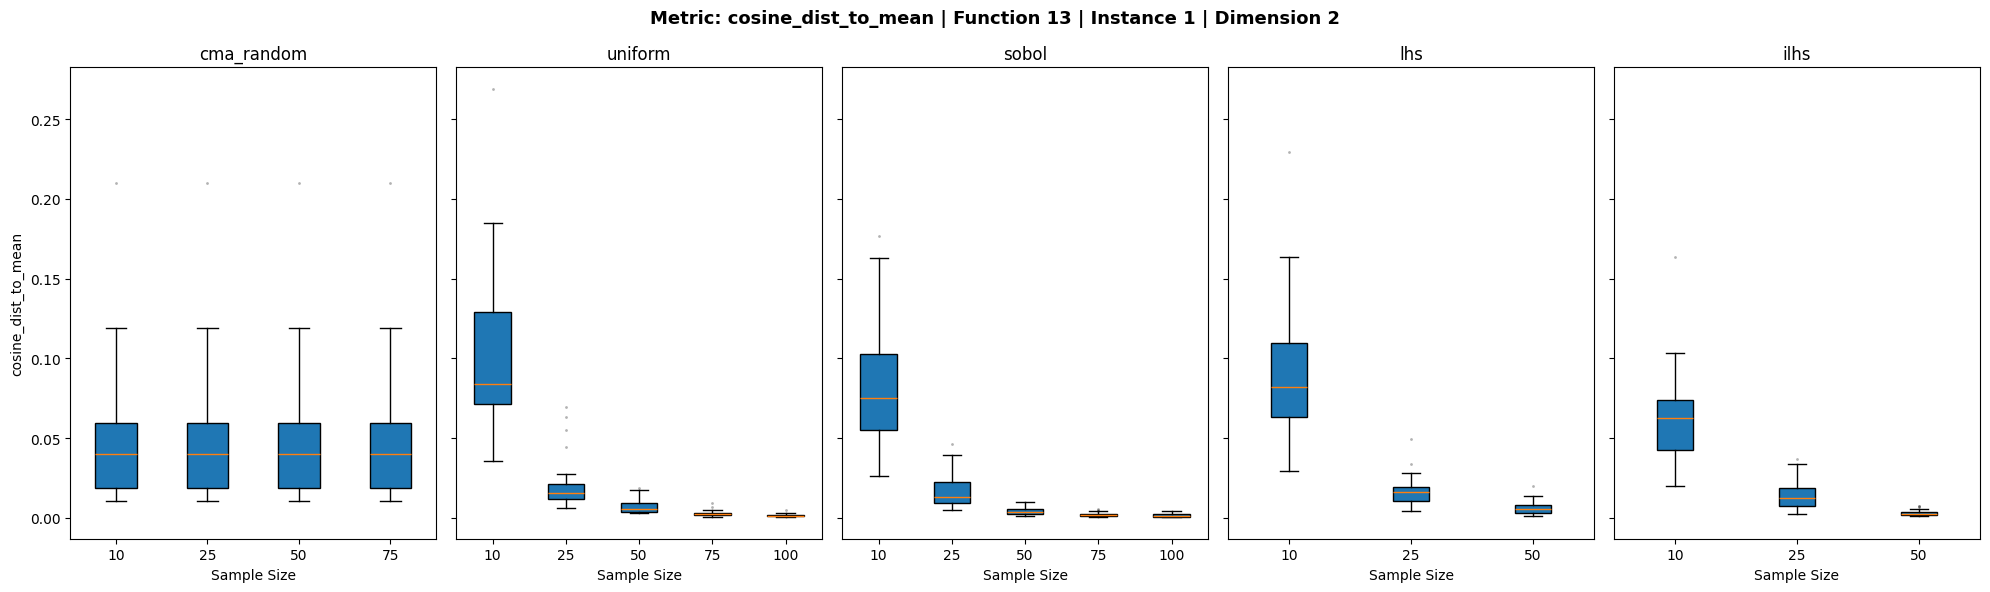

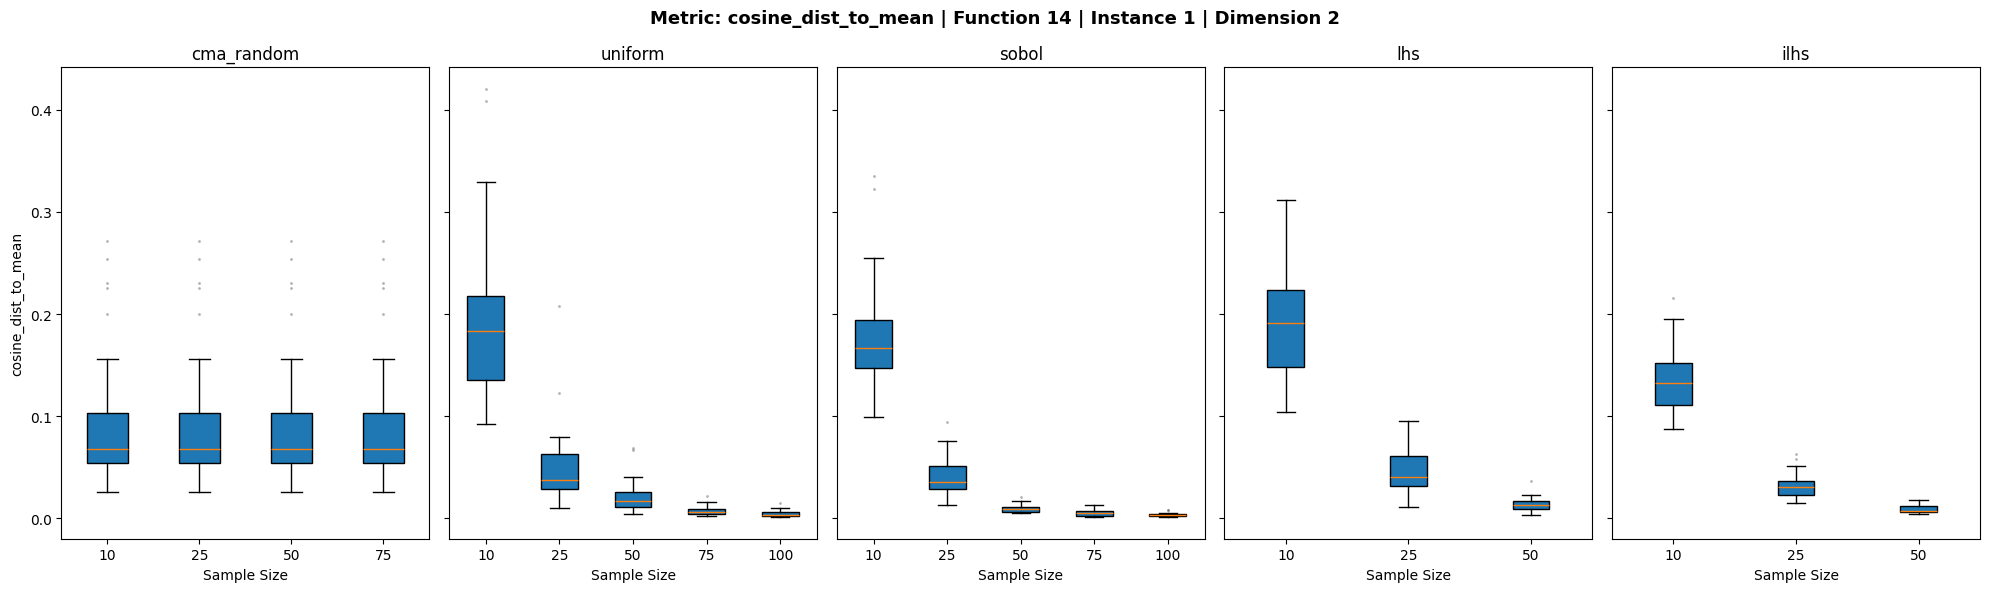

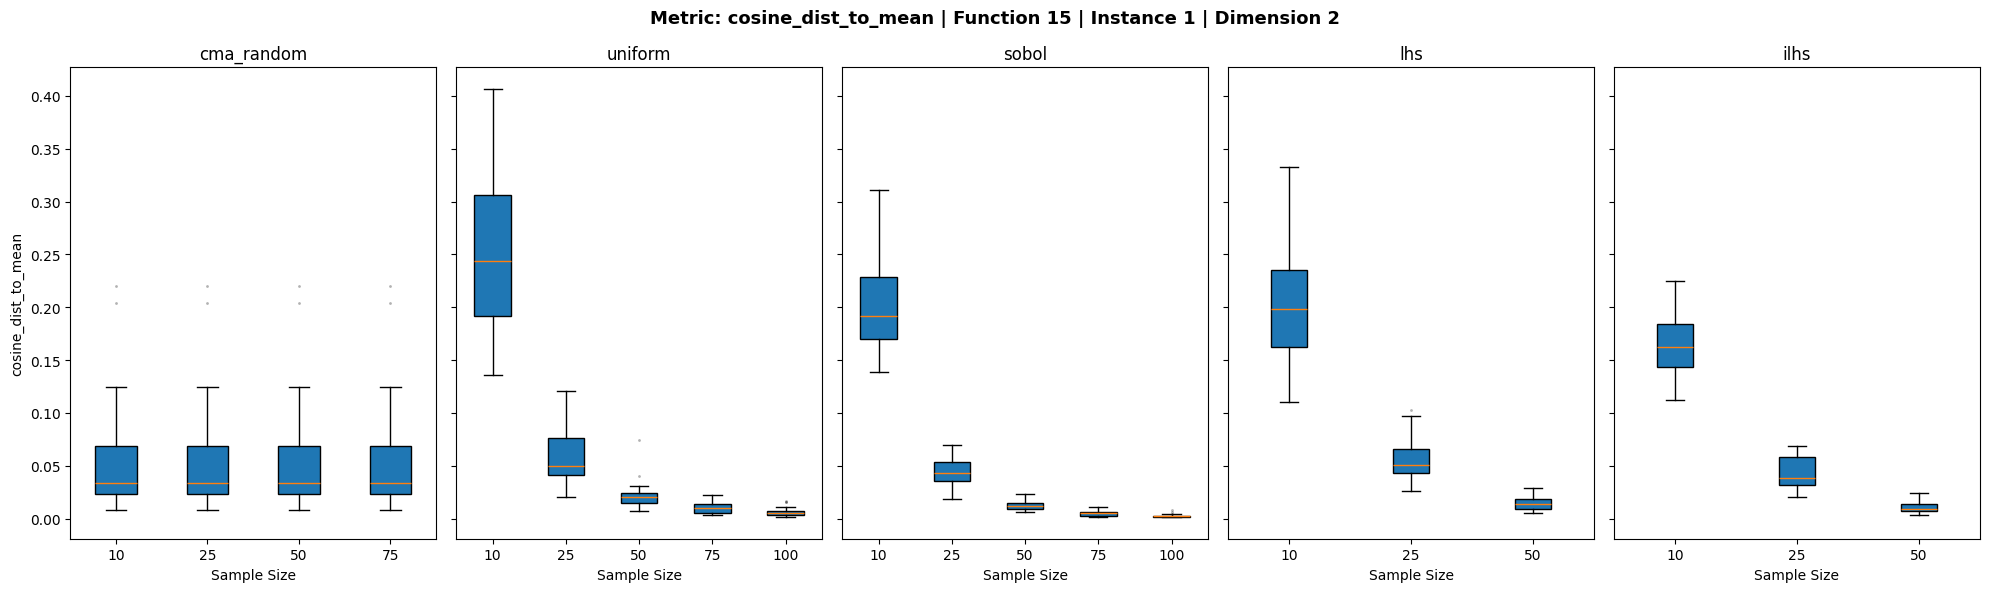

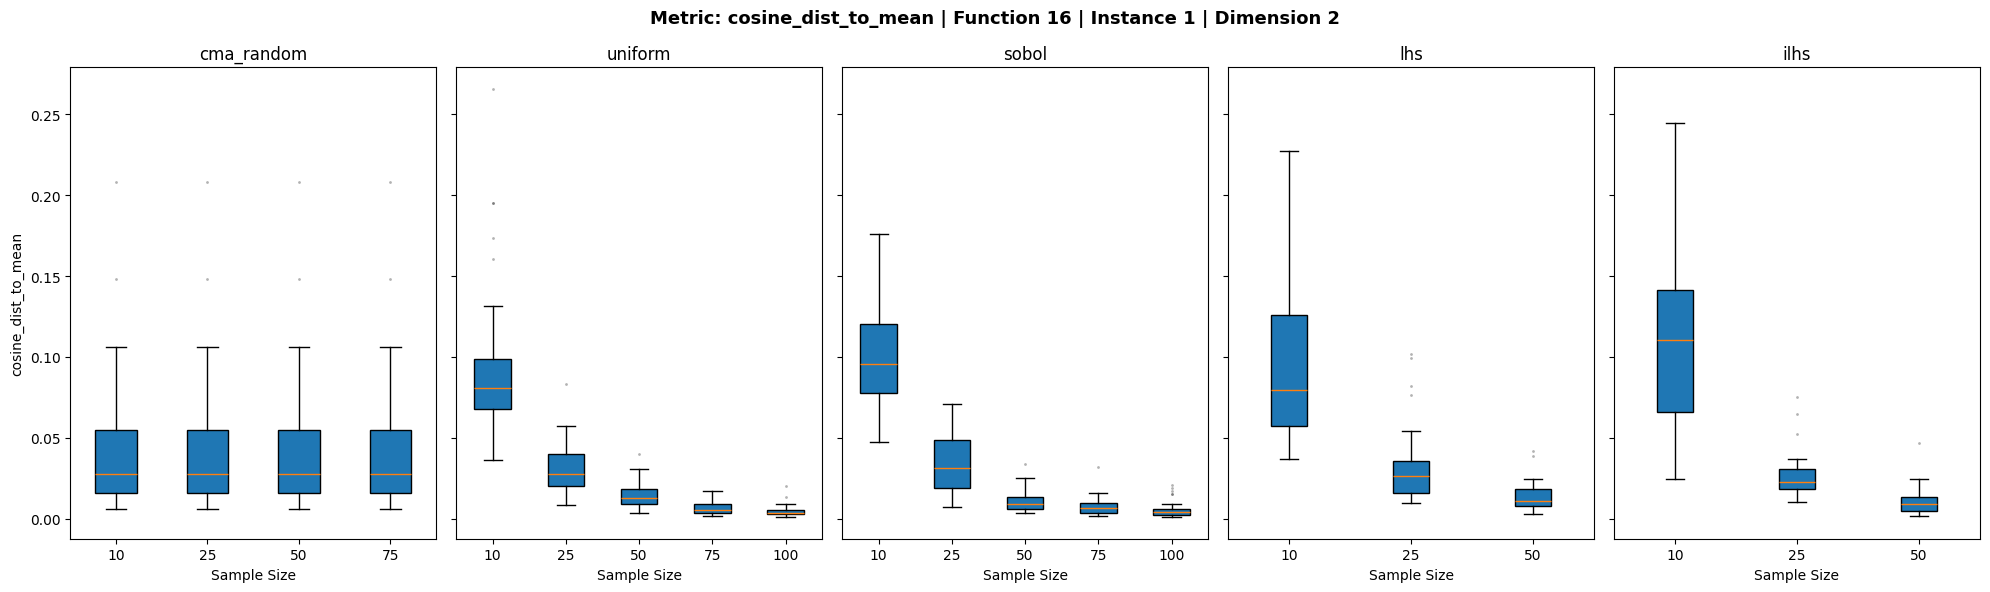

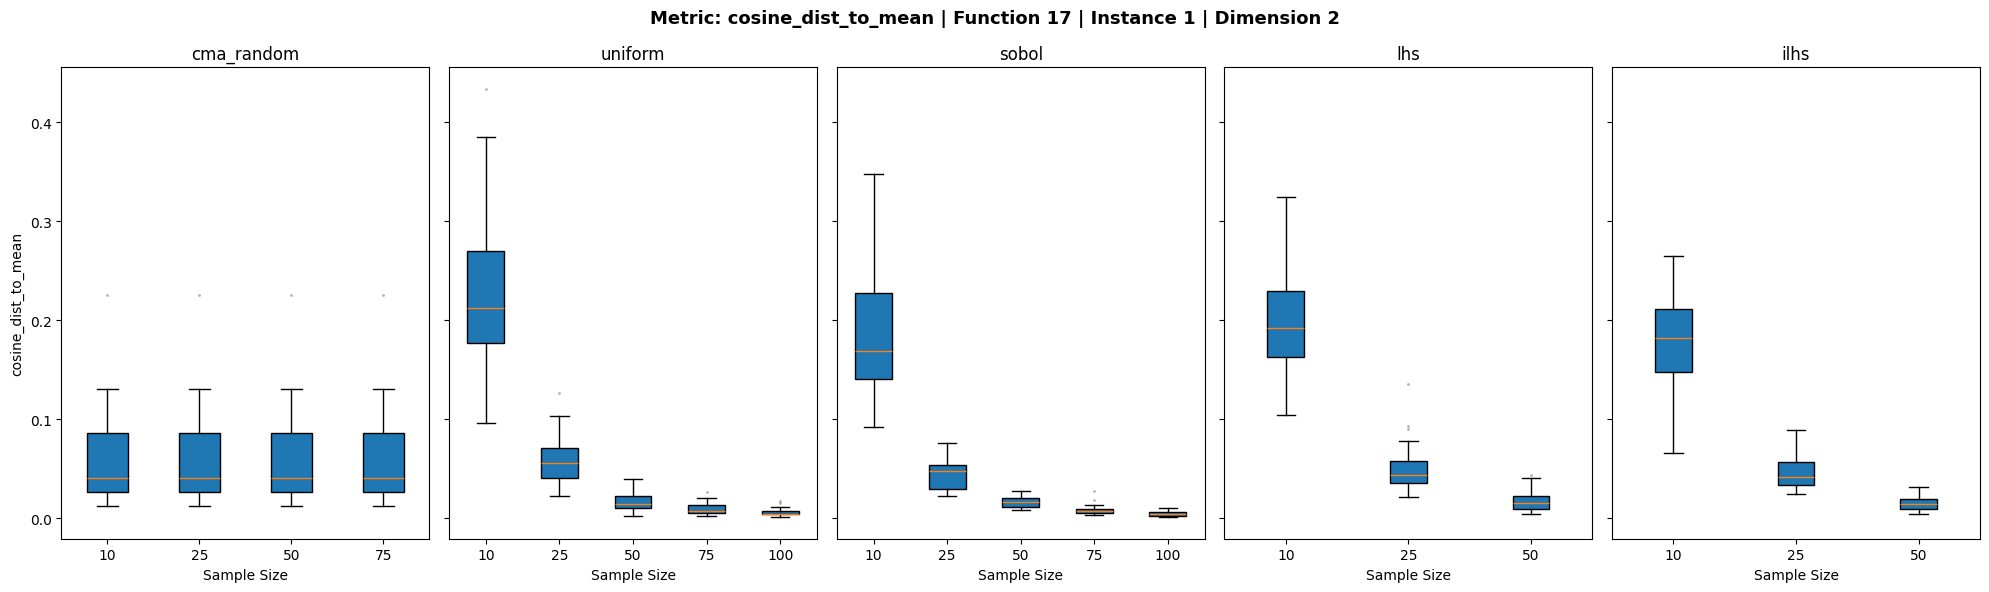

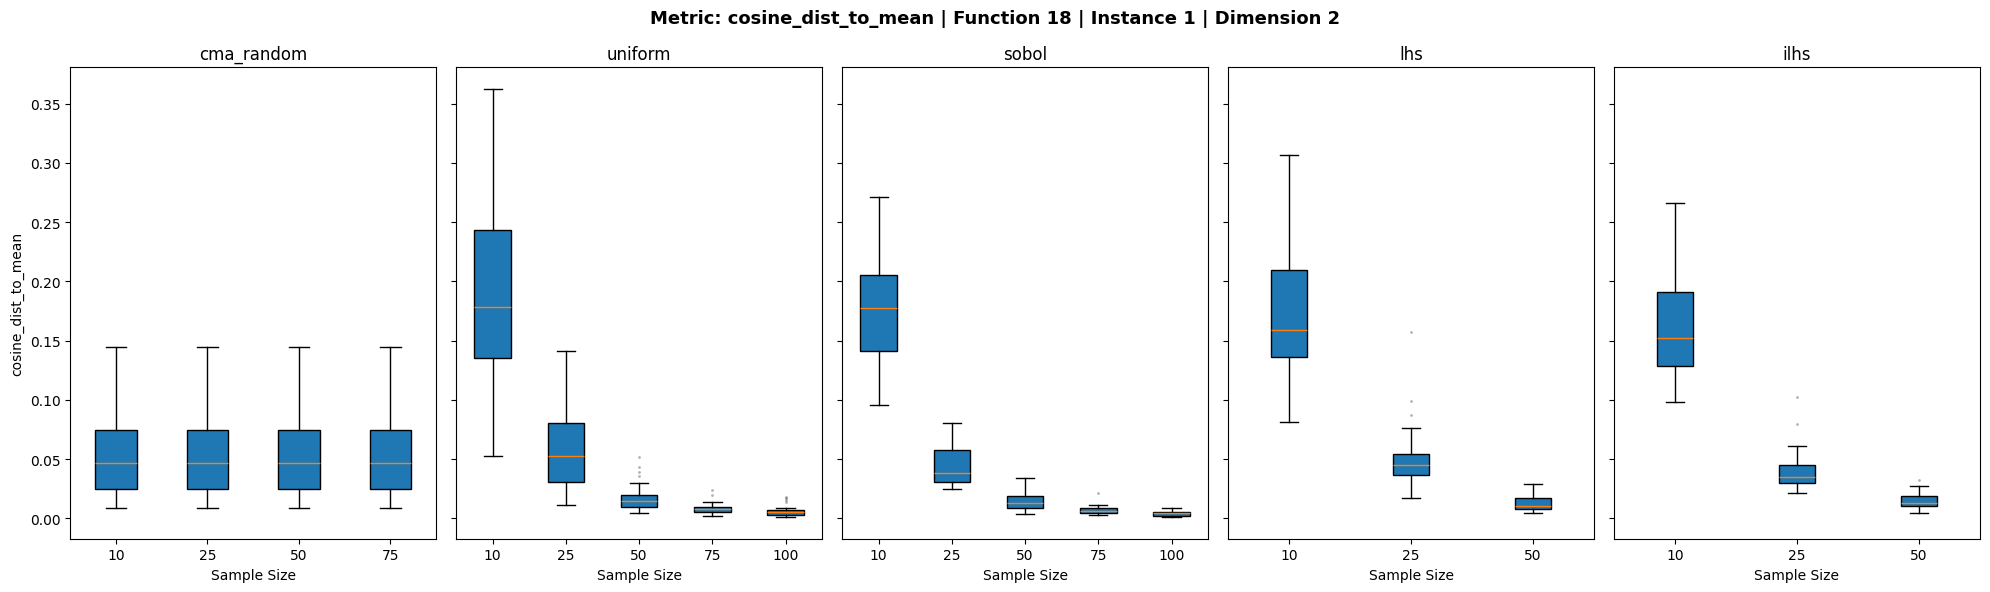

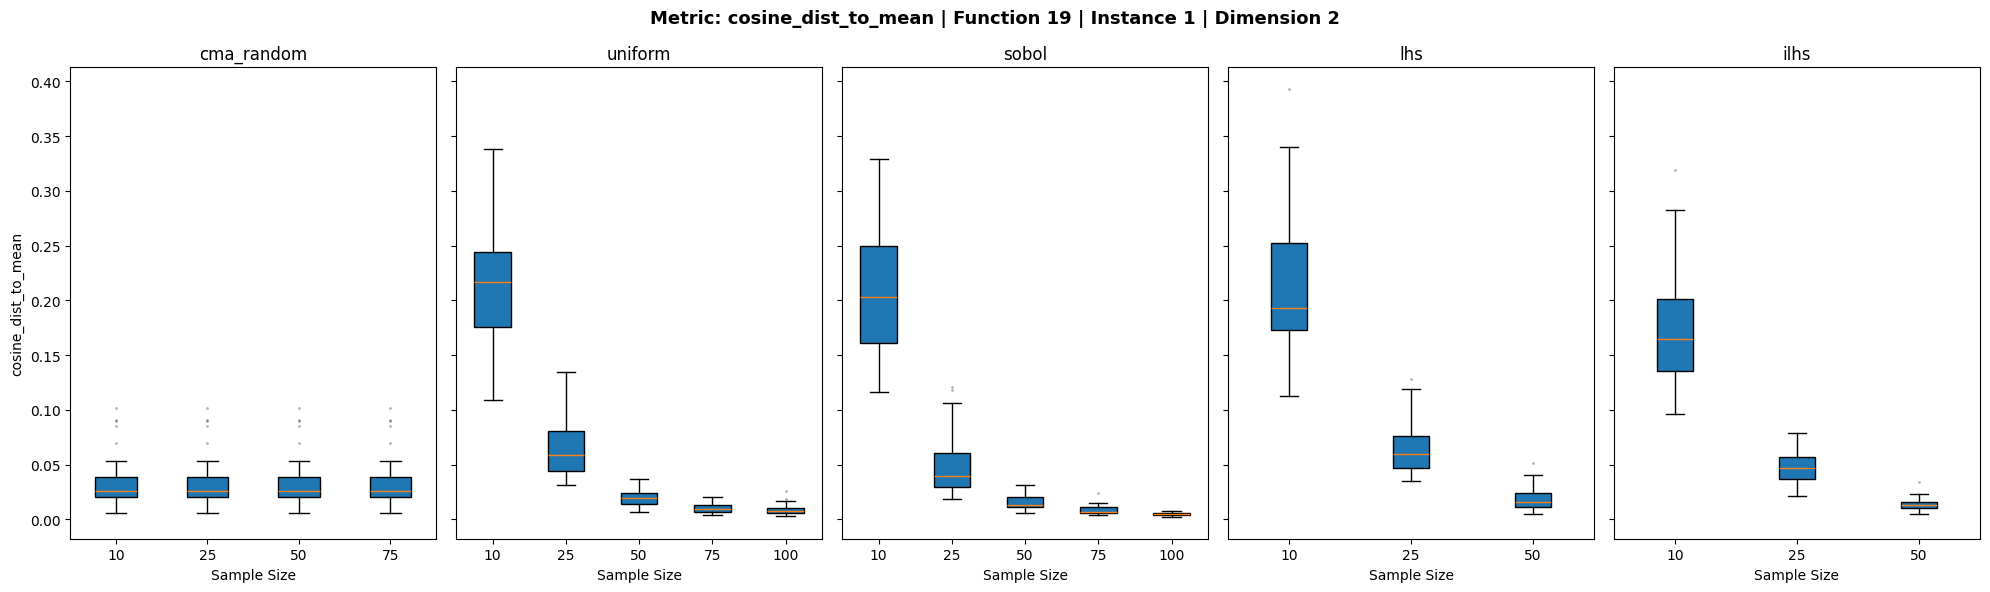

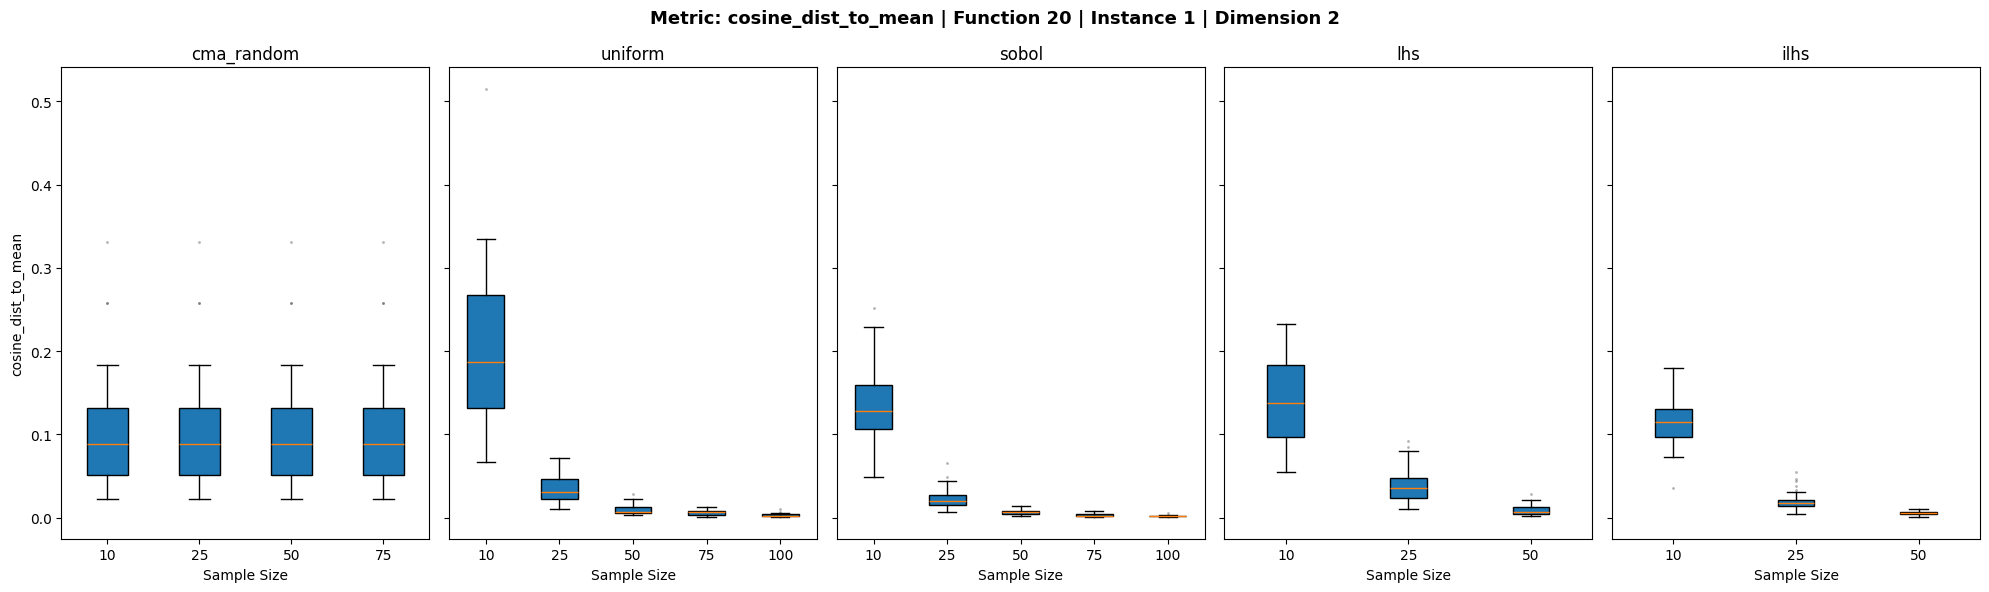

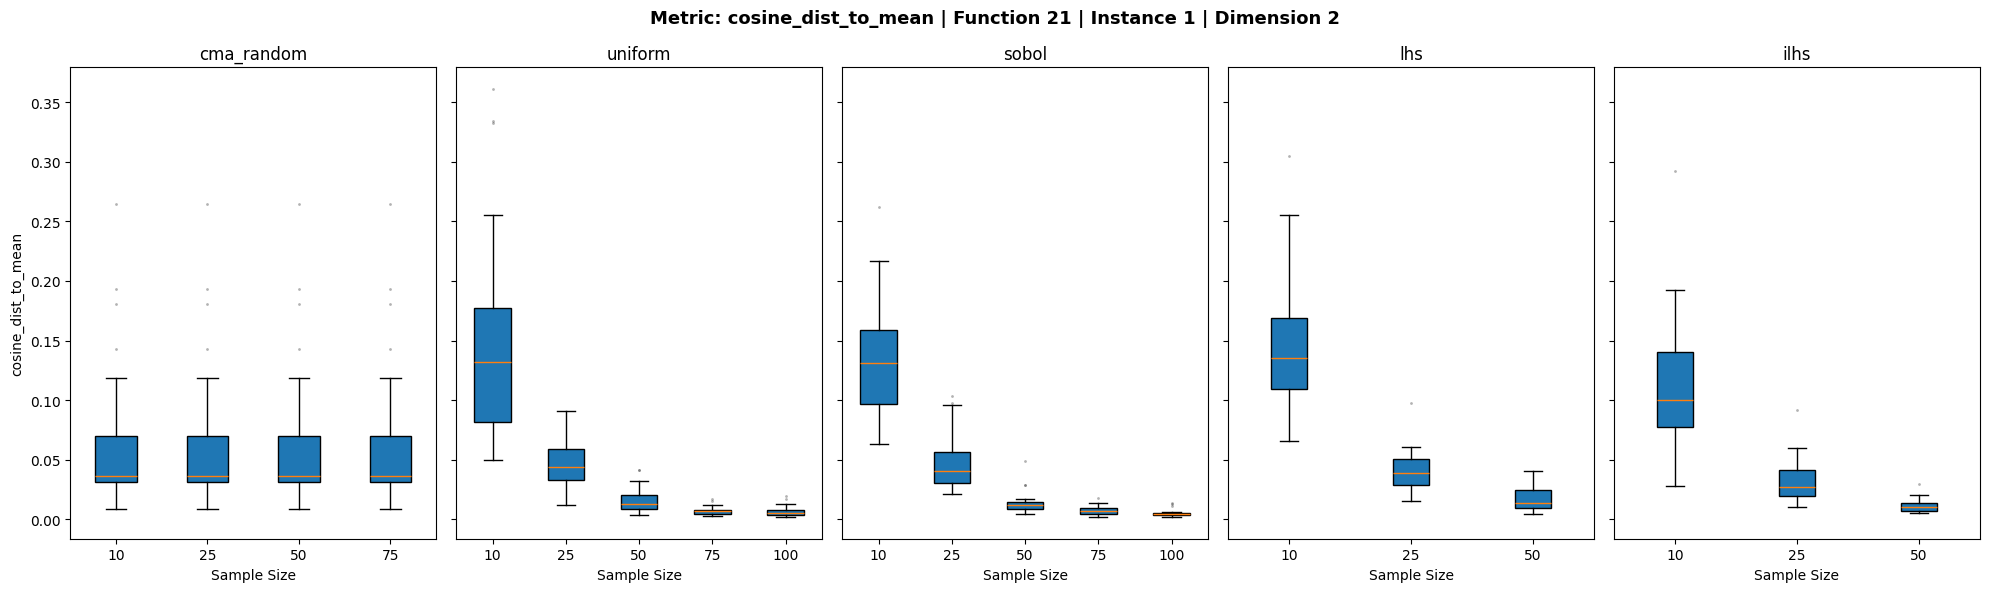

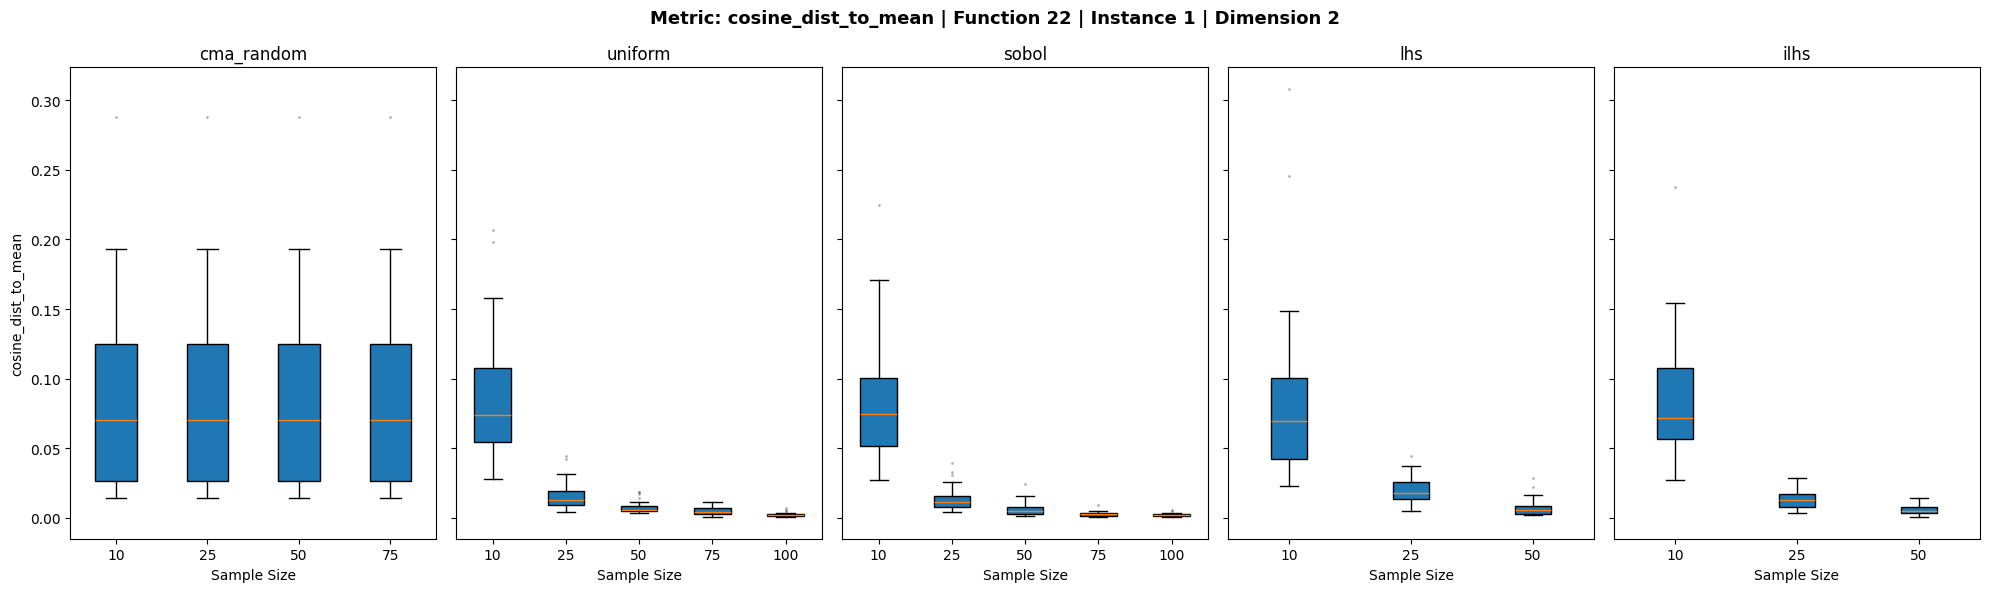

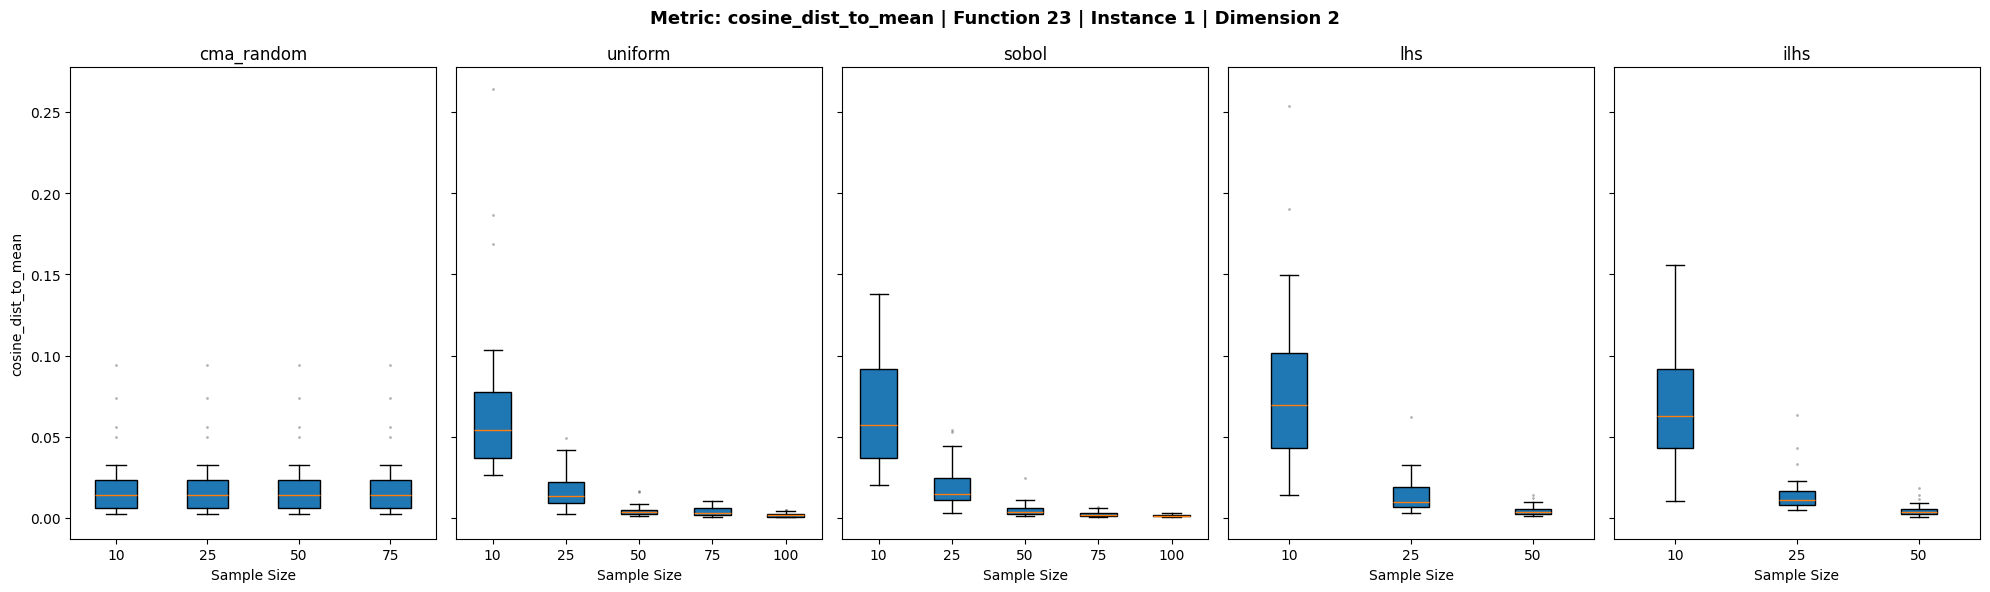

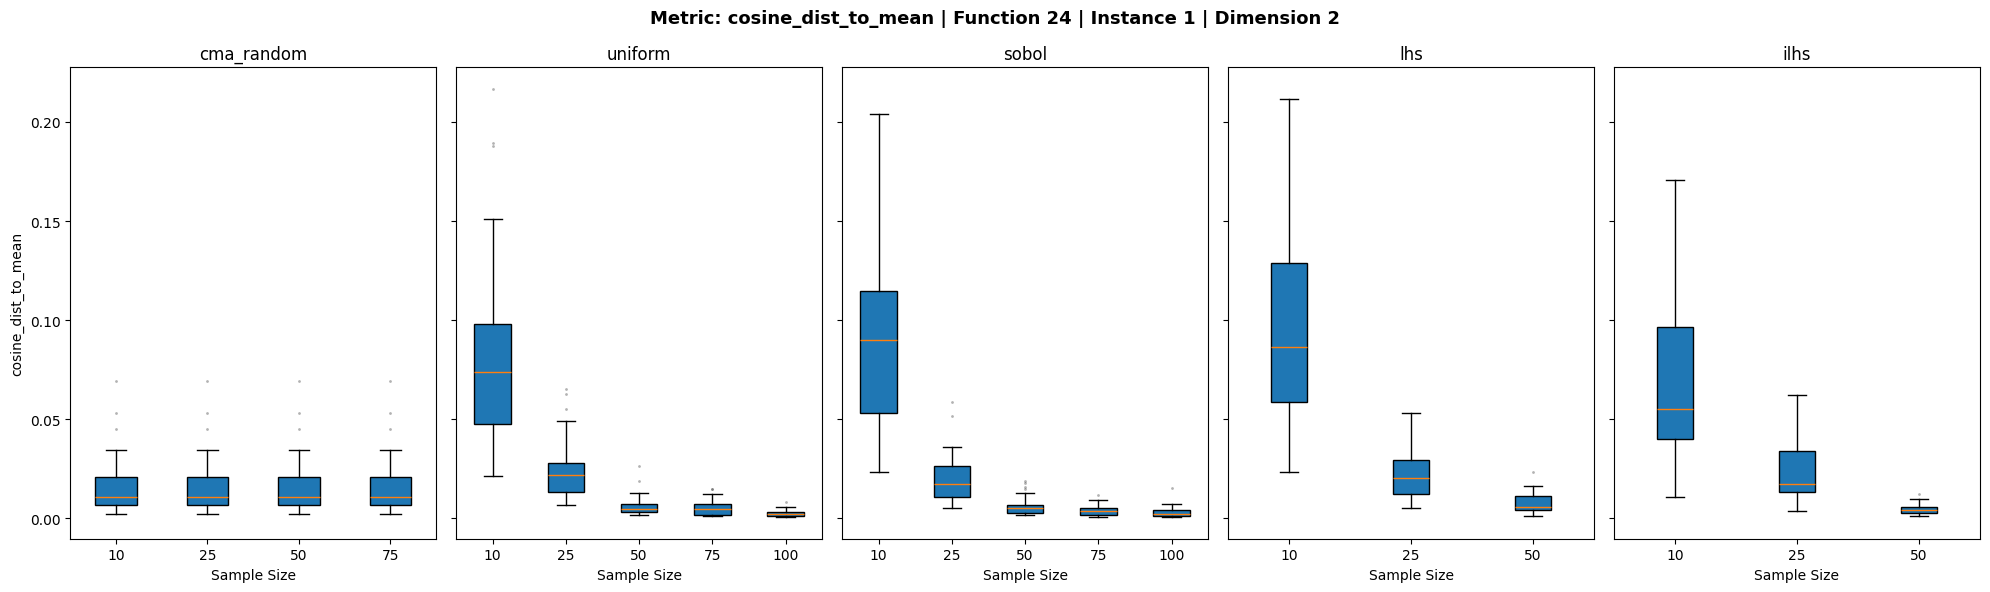

In [5]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

sample_methods = ['cma_random', 'uniform', 'sobol', 'lhs', 'ilhs']
sample_sizes = [10, 25, 50, 75, 100]
metrics = [
    'euclidean_dist_to_median',
    'euclidean_dist_to_mean',
    'cosine_dist_to_median',
    'cosine_dist_to_mean'
]
functions = range(1, 25)
instance = 1
dimension = 2

with h5py.File(data_dir, 'r') as f:
    for metric in metrics:
        for function in functions:
            fig, axes = plt.subplots(1, len(sample_methods), figsize=(20, 6), sharey=True)
            fig.suptitle(f'Metric: {metric} | Function {function} | Instance {instance} | Dimension {dimension}',
                         fontsize=13, fontweight='bold')

            for ax, method in zip(axes, sample_methods):
                box_data = []
                valid_sizes = []

                for size in sample_sizes:
                    key = f'{method}_{size}'

                    if key not in f:
                        continue

                    method_grp = f[key]
                    instance_key = f'{function}_{instance}_{dimension}'

                    if instance_key not in method_grp:
                        continue

                    try:
                        values = method_grp[instance_key]['all'][metric][:]
                        if len(values) > 0:
                            box_data.append(values.flatten())
                            valid_sizes.append(size)
                    except KeyError:
                        continue

                if len(box_data) > 0:
                    ax.boxplot(box_data, labels=valid_sizes, patch_artist=True,
                               flierprops=dict(marker='.', markersize=2, alpha=0.3))
                else:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                            transform=ax.transAxes)

                ax.set_title(method)
                ax.set_xlabel('Sample Size')
                if ax == axes[0]:
                    ax.set_ylabel(metric)

            plt.tight_layout()
            plt.show()

## Include every data point -- no averaging

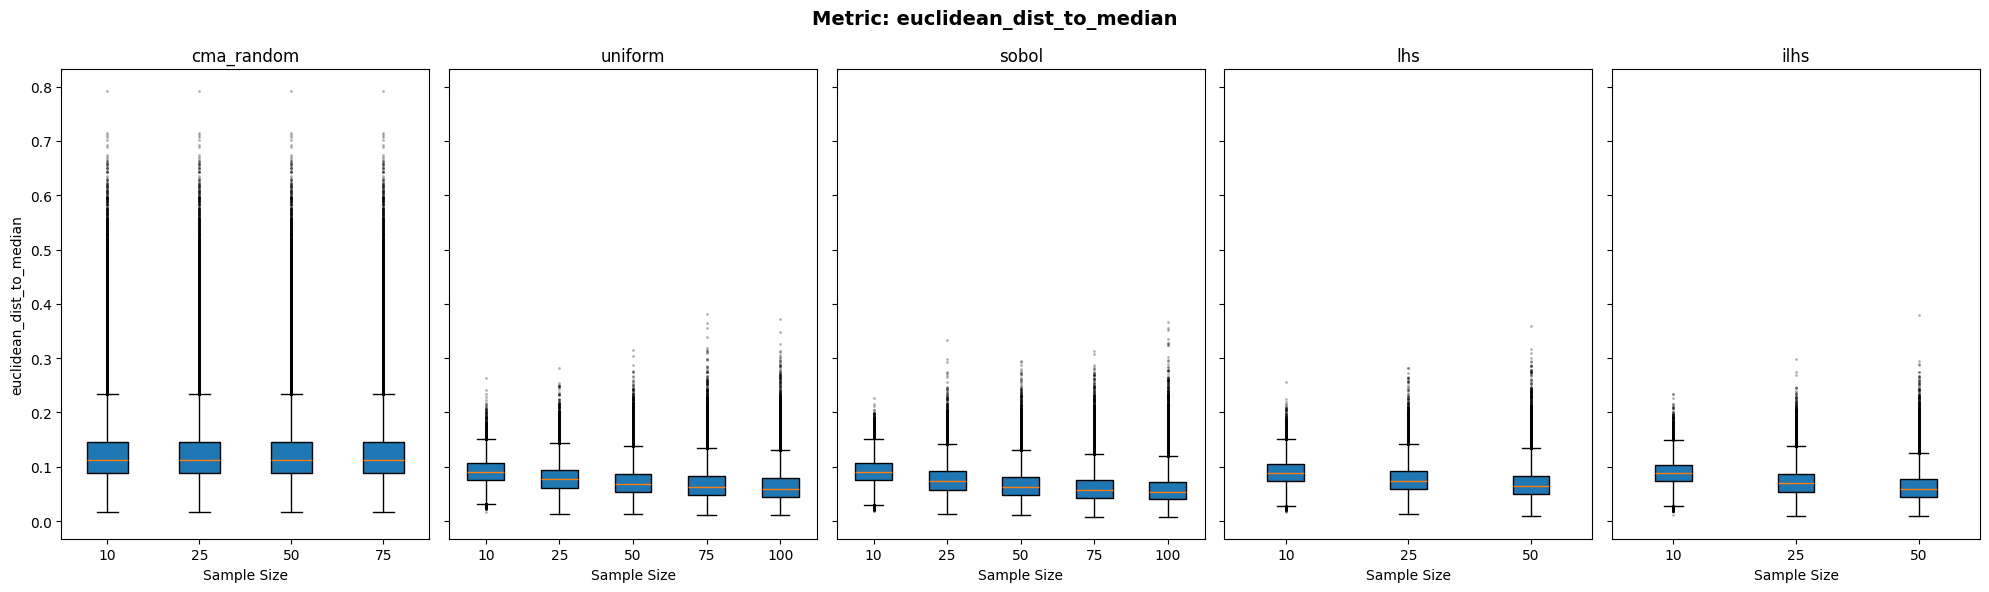

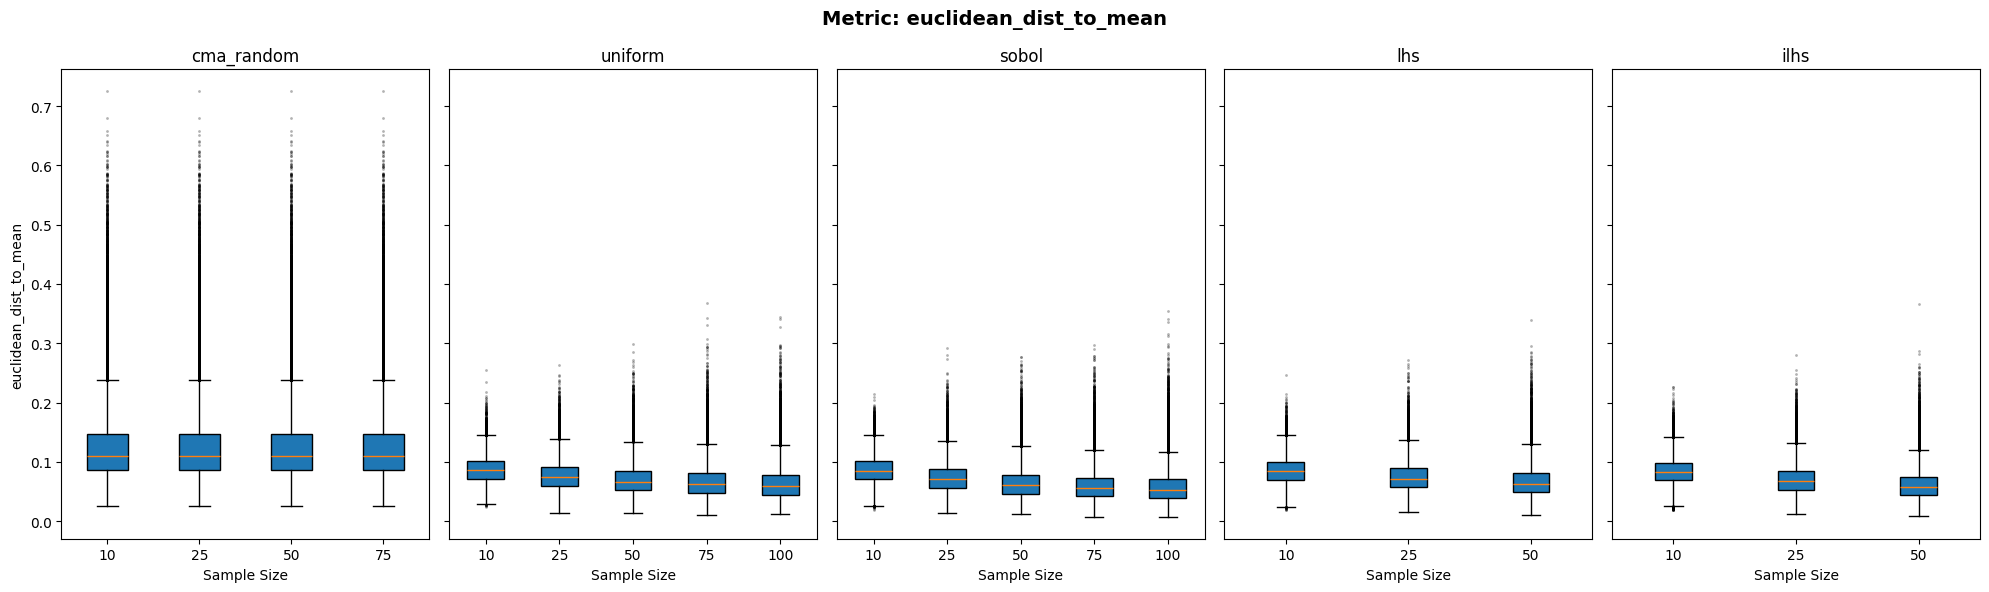

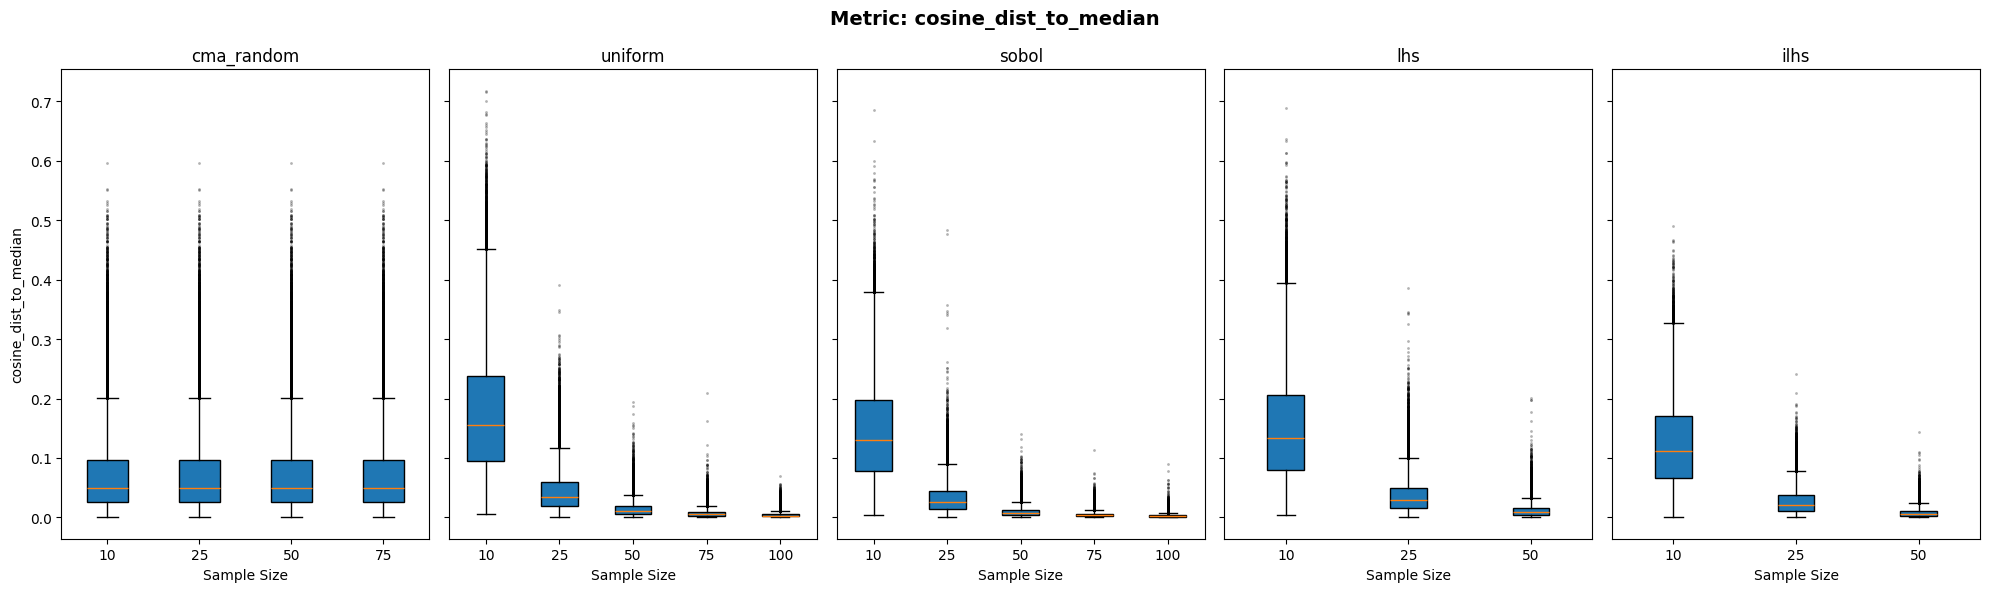

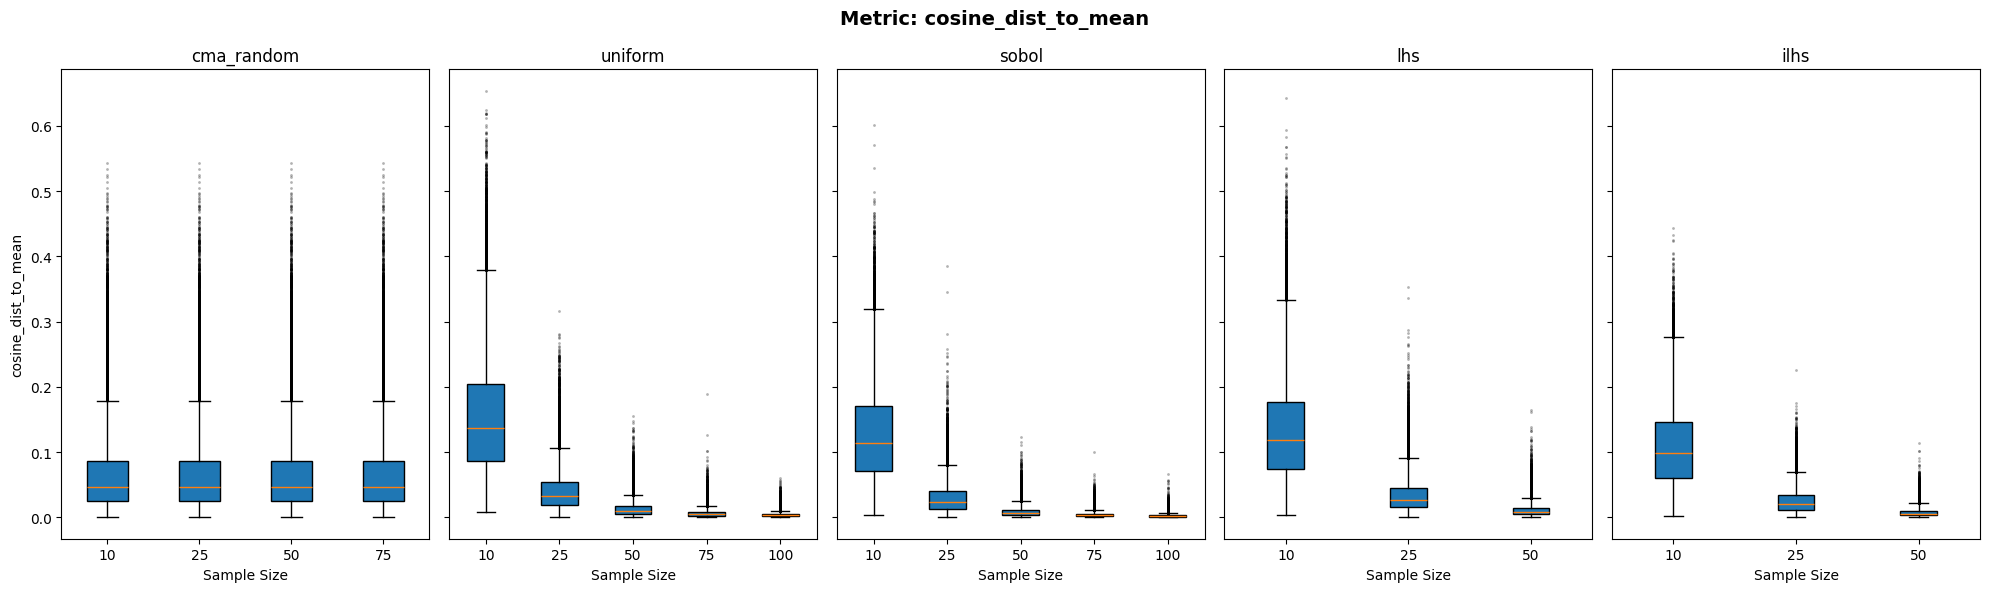

In [6]:
with h5py.File(data_dir, 'r') as f:
    for metric in metrics:
        fig, axes = plt.subplots(1, len(sample_methods), figsize=(20, 6), sharey=True)
        fig.suptitle(f'Metric: {metric}', fontsize=14, fontweight='bold')

        for ax, method in zip(axes, sample_methods):
            box_data = []
            valid_sizes = []

            for size in sample_sizes:
                key = f'{method}_{size}'

                if key not in f:
                    continue

                method_grp = f[key]

                # Collect ALL raw values across all functions and instances
                all_values = []

                for function in functions:
                    for instance in instances:
                        instance_key = f'{function}_{instance}_{dimension}'

                        if instance_key not in method_grp:
                            continue

                        try:
                            values = method_grp[instance_key]['all'][metric][:]
                            # Append all raw values (all 30 runs) directly
                            all_values.extend(values.flatten())
                        except KeyError:
                            continue

                if len(all_values) > 0:
                    box_data.append(all_values)
                    valid_sizes.append(size)

            if len(box_data) > 0:
                ax.boxplot(box_data, labels=valid_sizes, patch_artist=True,
                           flierprops=dict(marker='.', markersize=2, alpha=0.3))
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes)

            ax.set_title(method)
            ax.set_xlabel('Sample Size')
            if ax == axes[0]:
                ax.set_ylabel(metric)

        plt.tight_layout()
        plt.show()

## Per function class

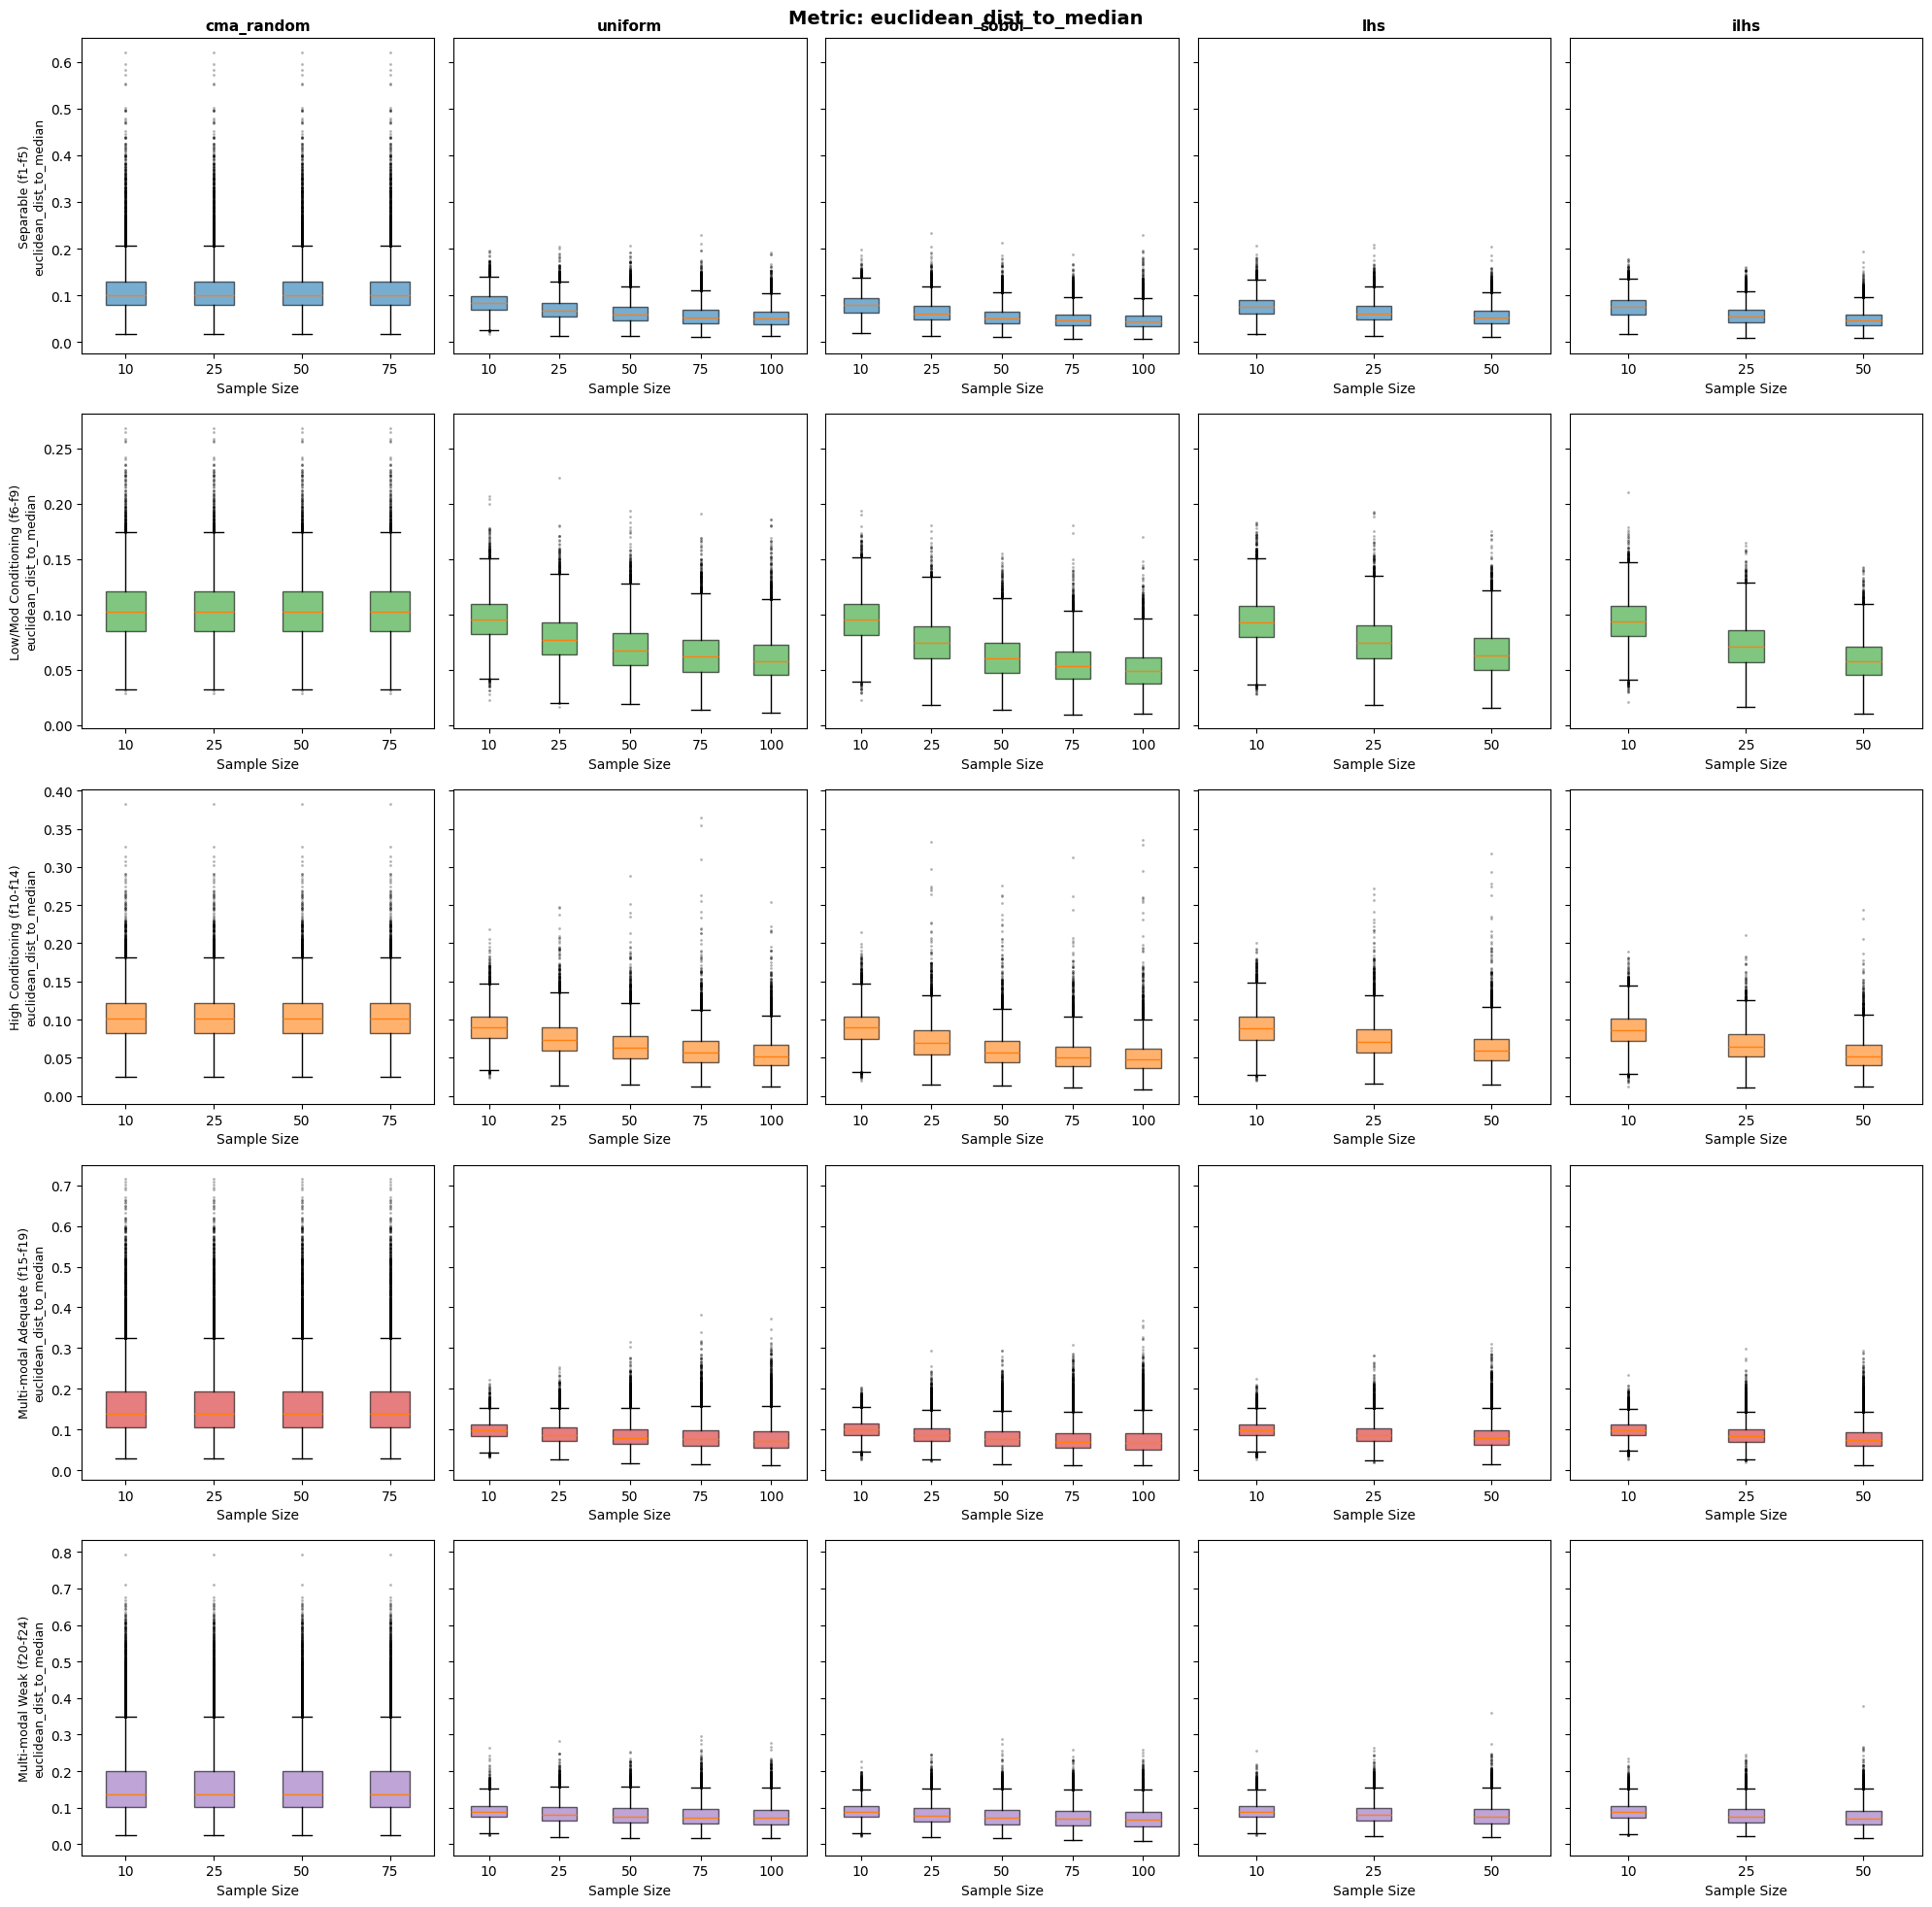

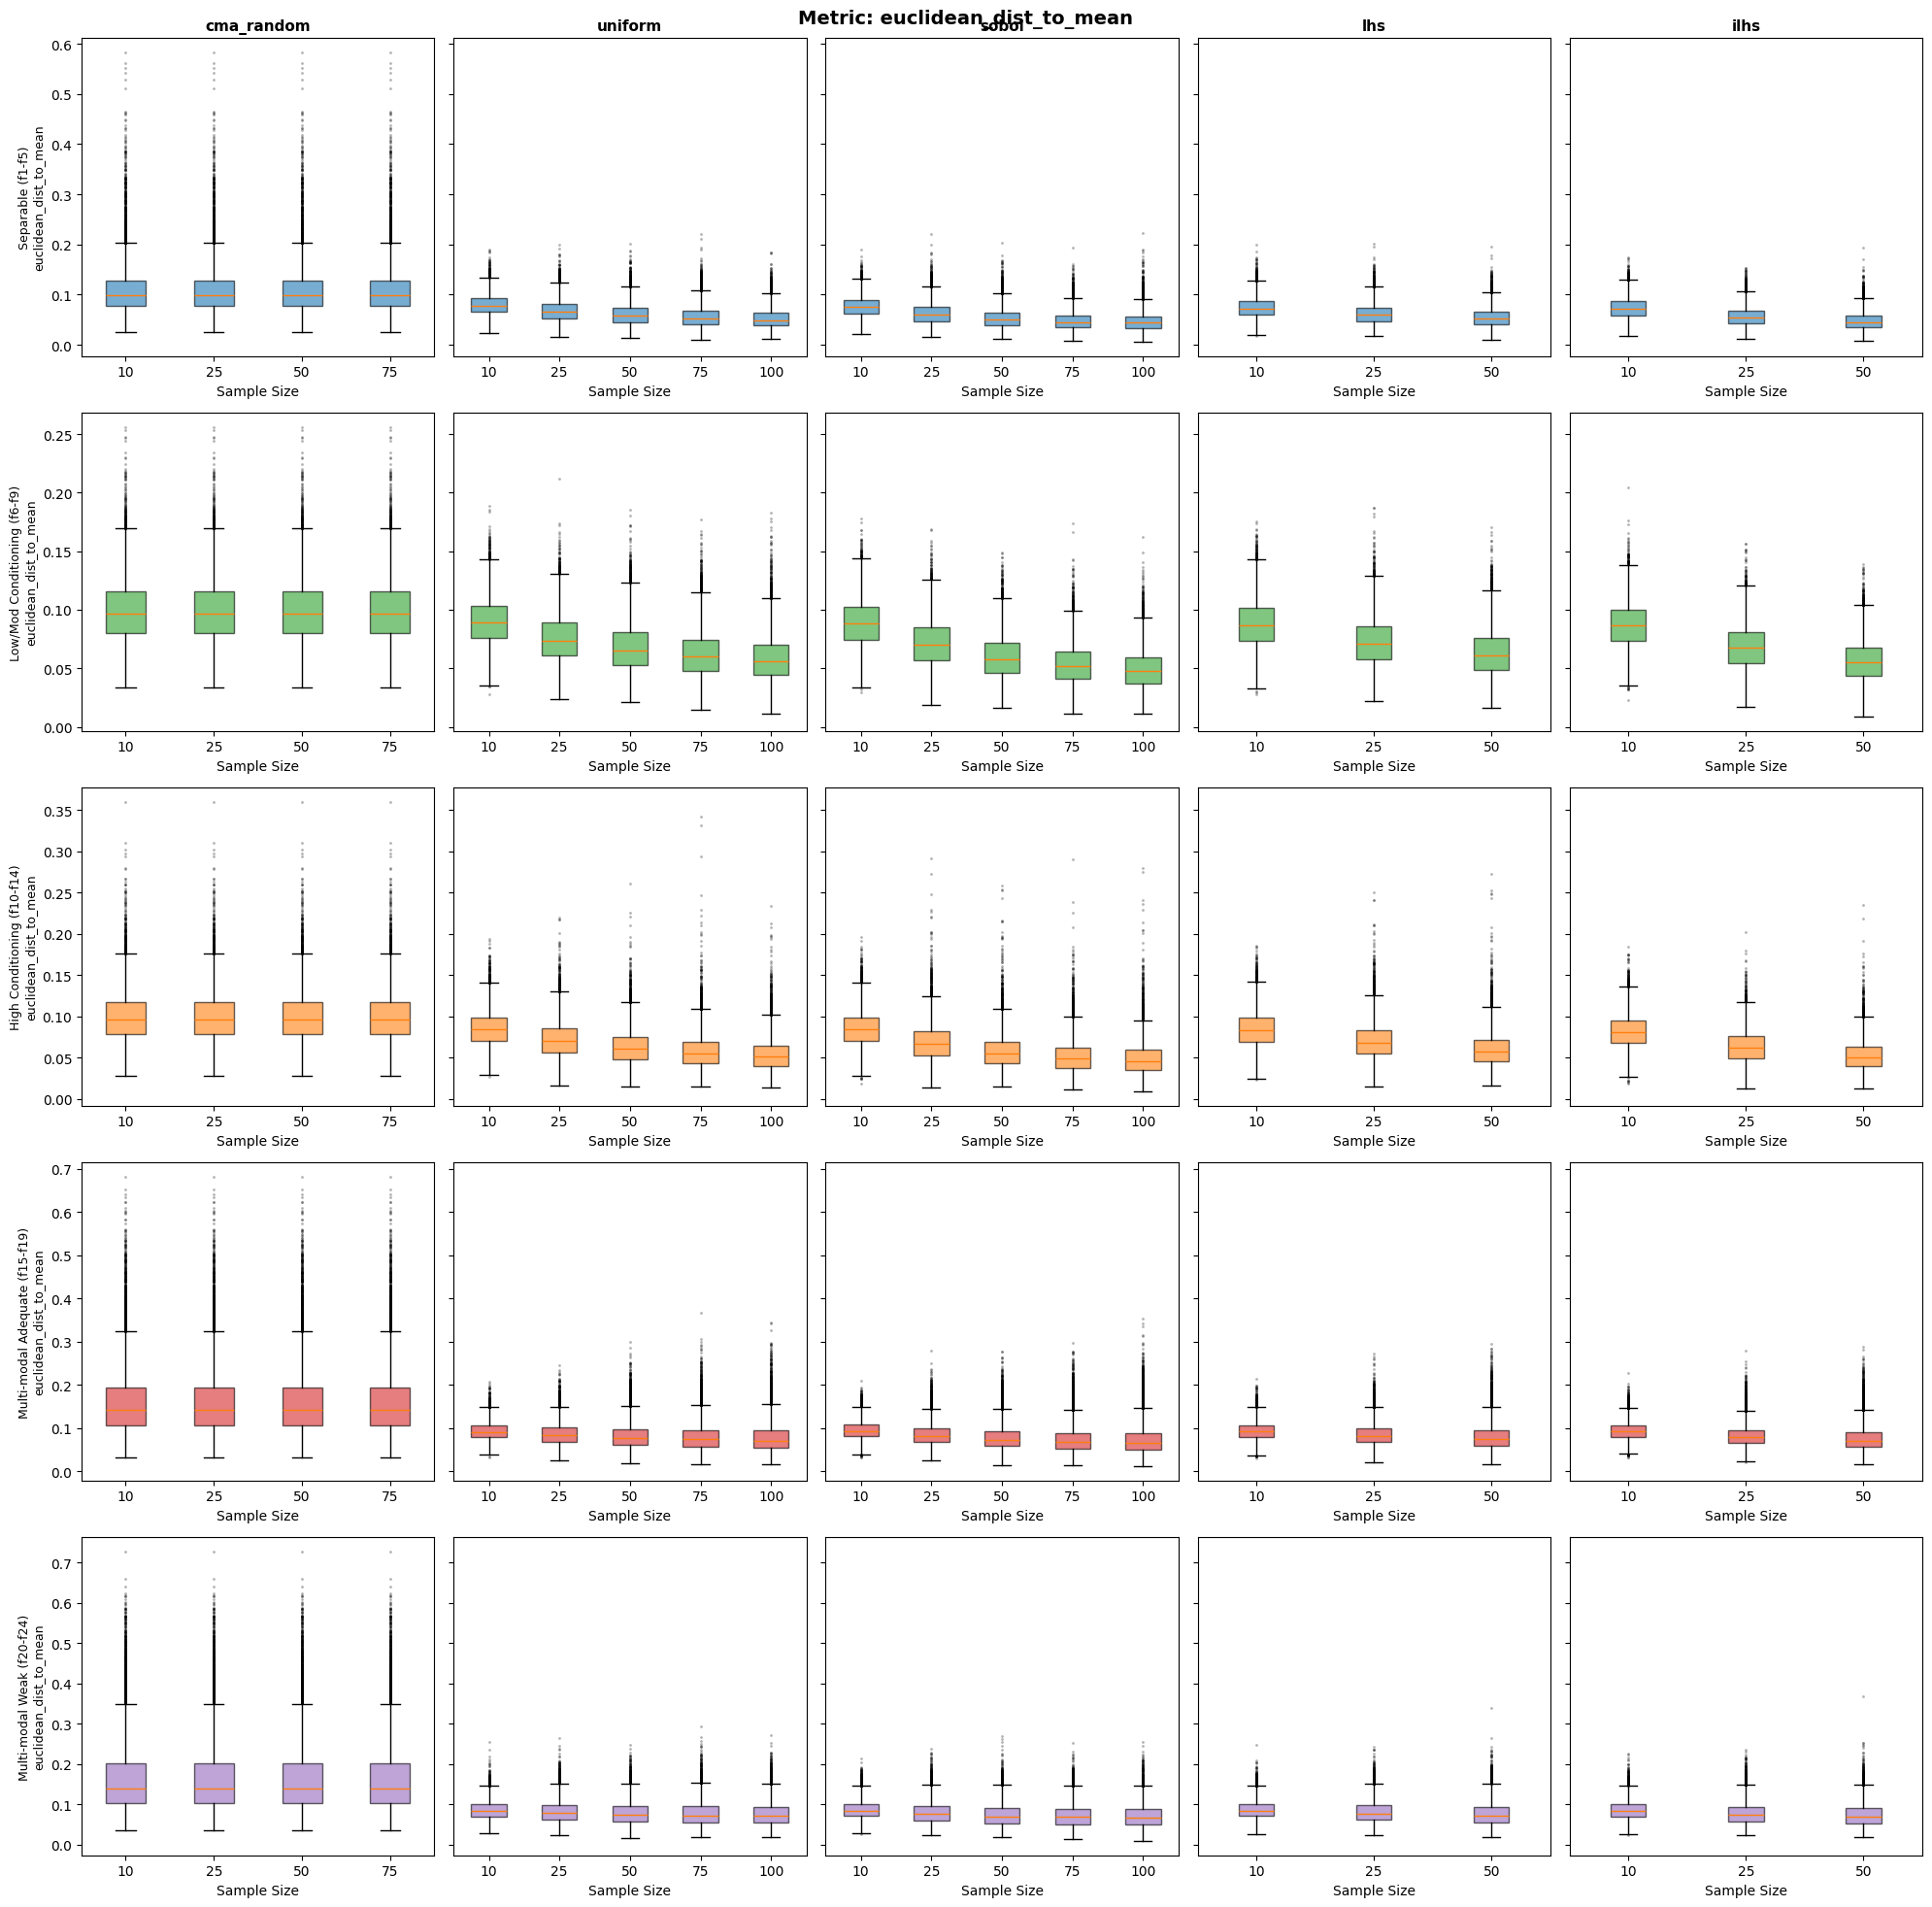

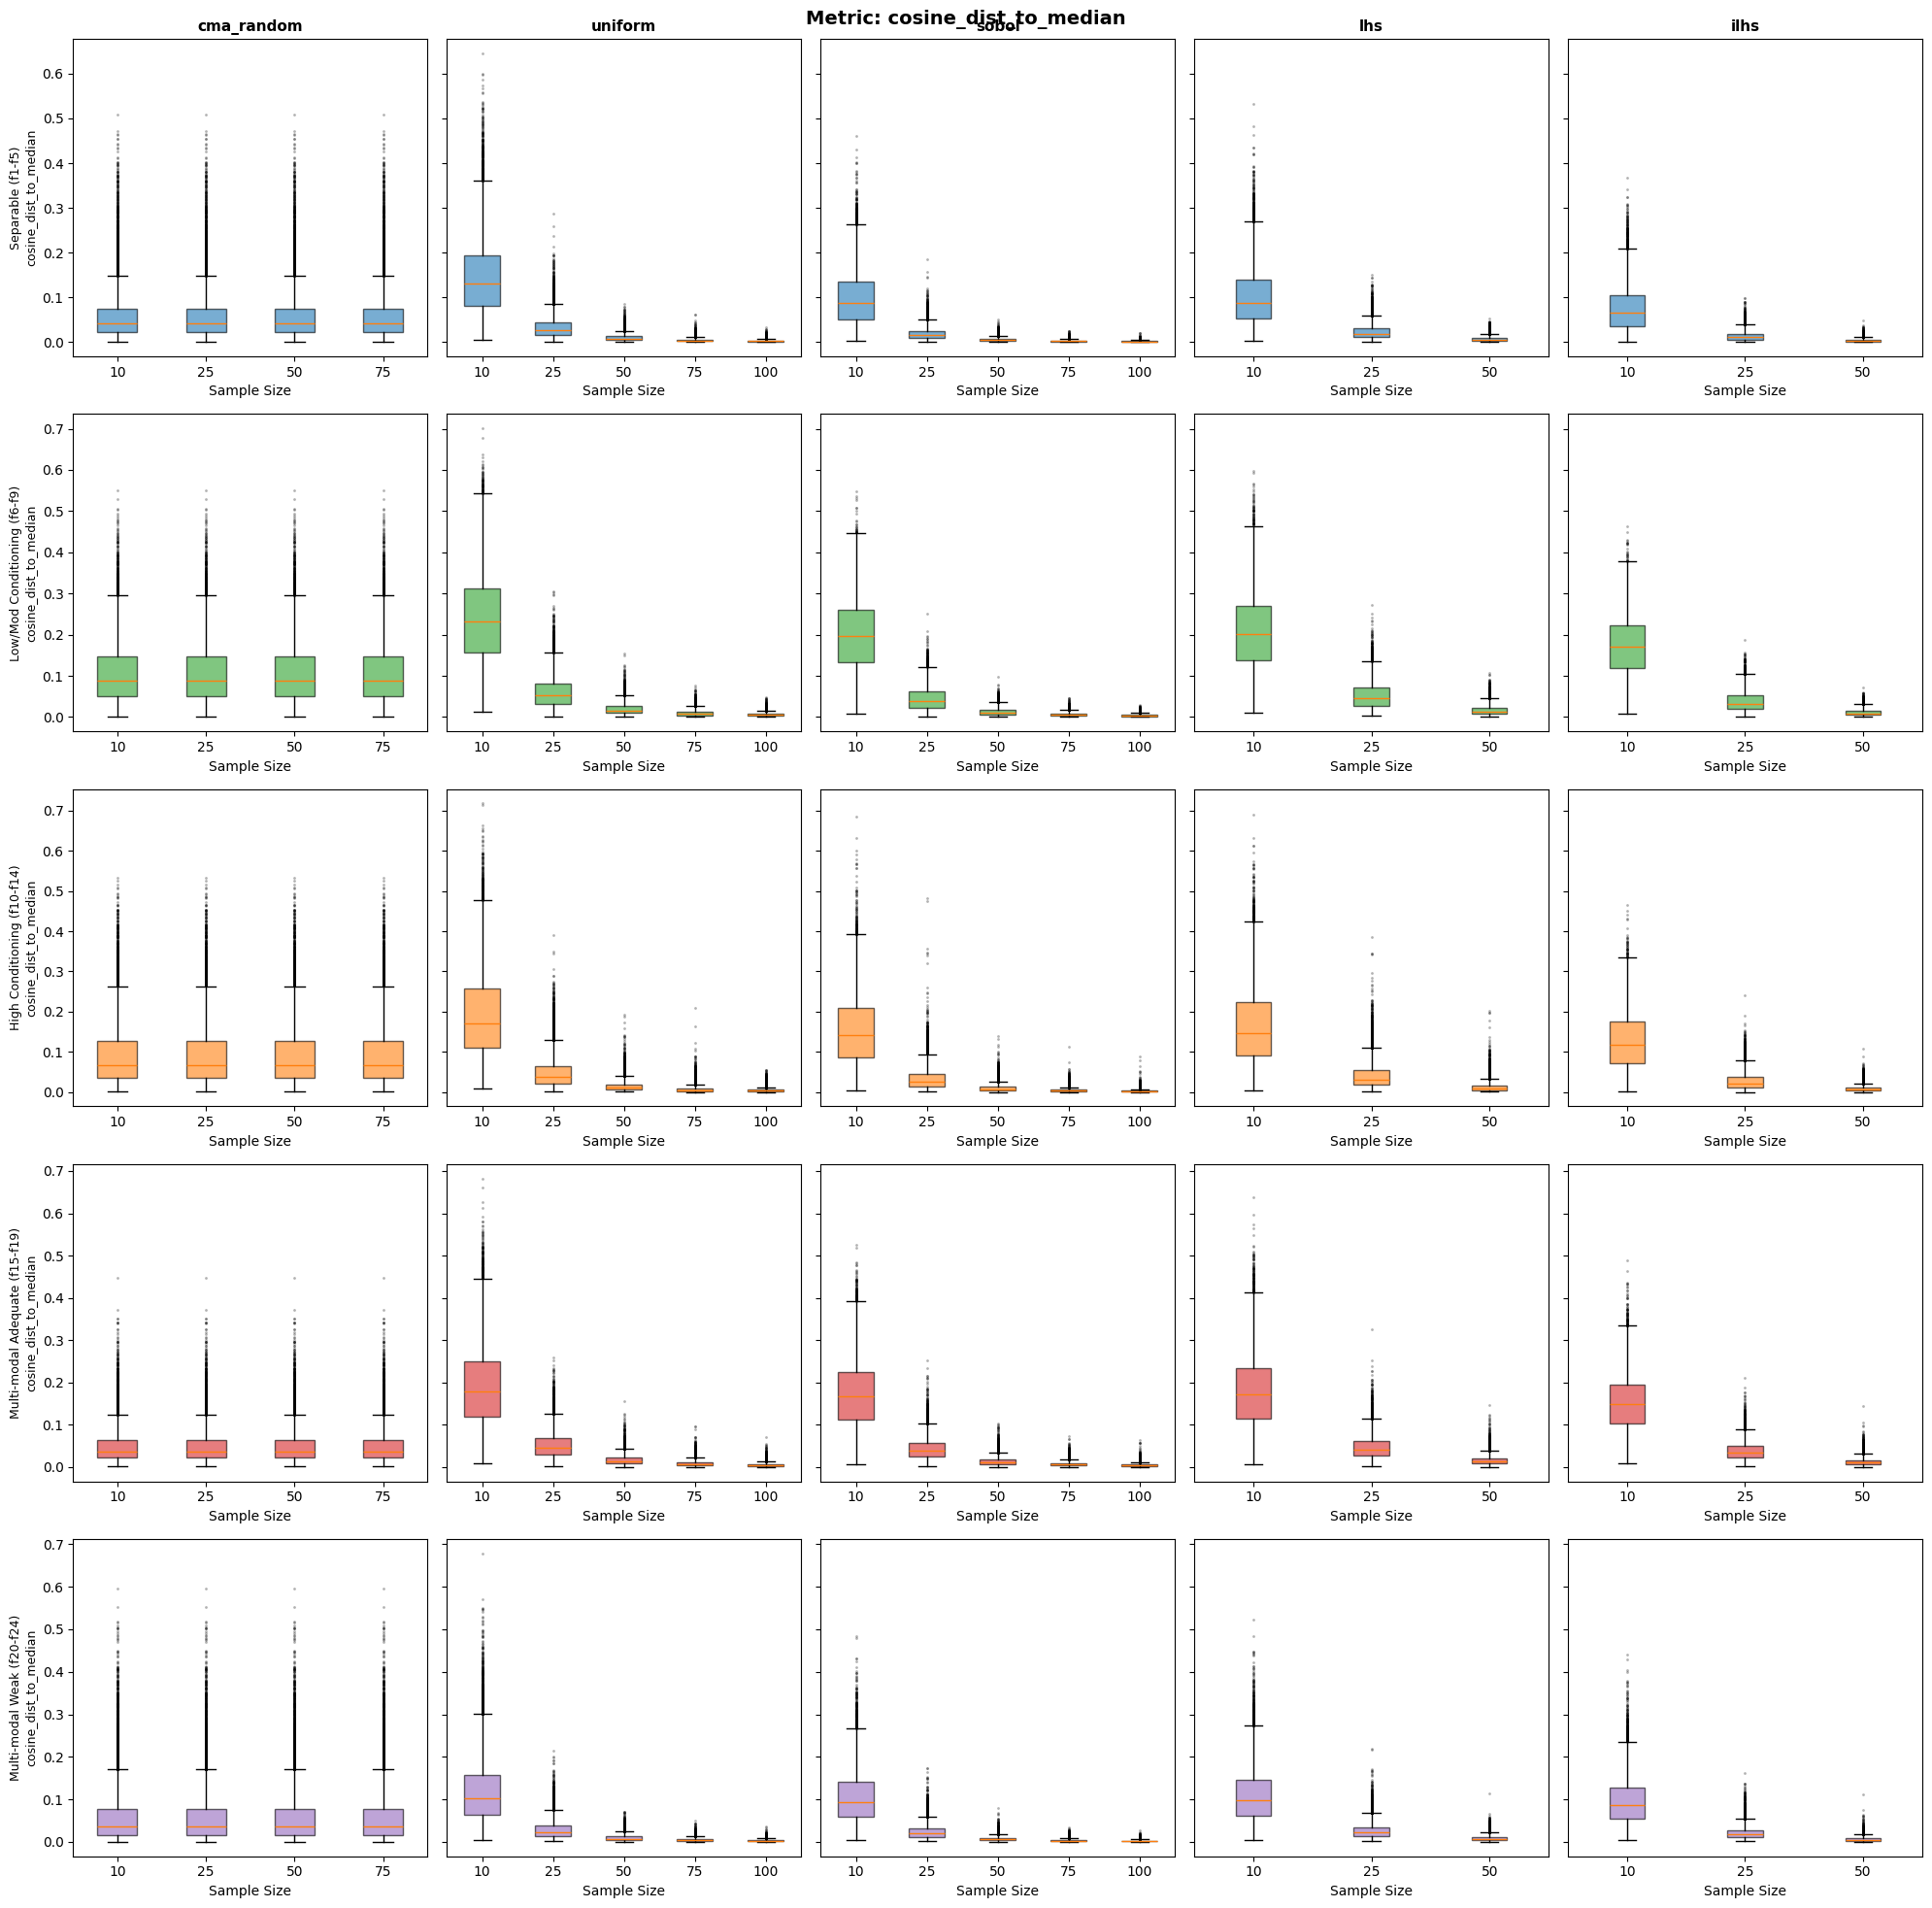

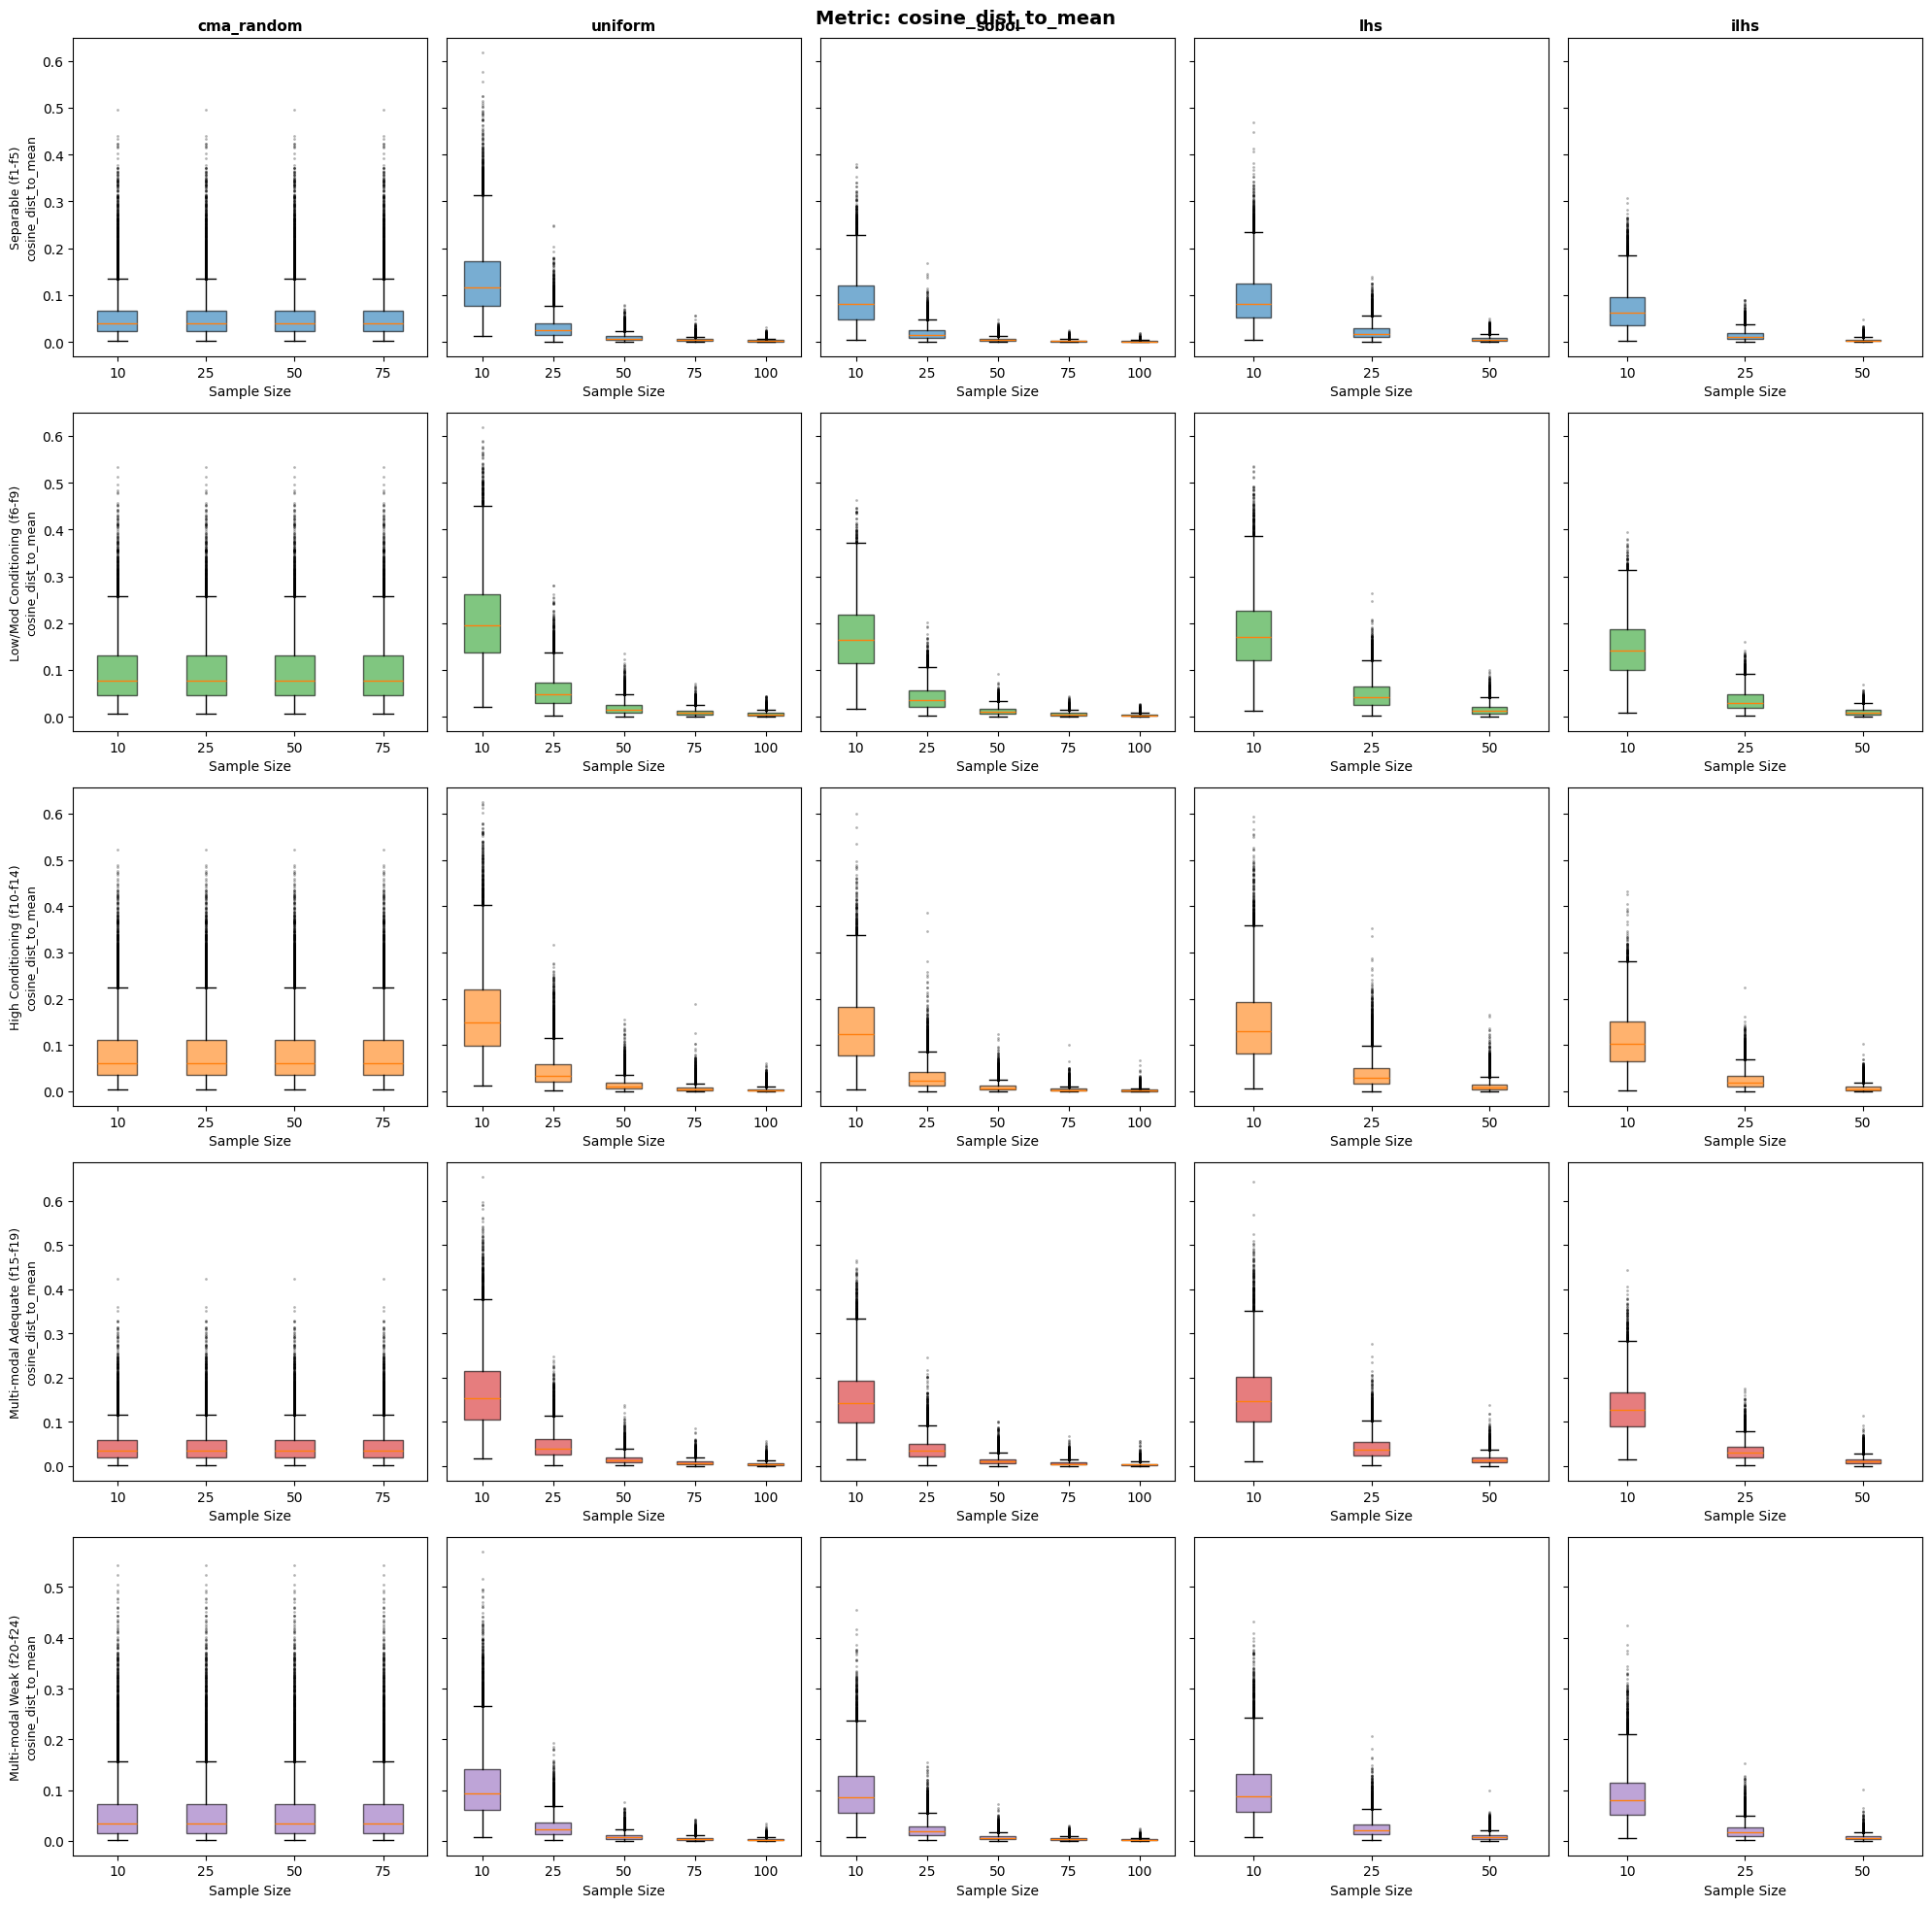

In [7]:
function_classes = [
    (range(1, 6),   '#1f77b4', 'Separable (f1-f5)'),
    (range(6, 10),  '#2ca02c', 'Low/Mod Conditioning (f6-f9)'),
    (range(10, 15), '#ff7f0e', 'High Conditioning (f10-f14)'),
    (range(15, 20), '#d62728', 'Multi-modal Adequate (f15-f19)'),
    (range(20, 25), '#9467bd', 'Multi-modal Weak (f20-f24)'),
]

with h5py.File(data_dir, 'r') as f:
    for metric in metrics:
        fig, axes = plt.subplots(
            len(function_classes), len(sample_methods),
            figsize=(20, 4 * len(function_classes)),
            sharey='row'
        )
        fig.suptitle(f'Metric: {metric}', fontsize=14, fontweight='bold')

        for row, (func_range, color, class_label) in enumerate(function_classes):
            for col, method in enumerate(sample_methods):
                ax = axes[row, col]
                box_data = []
                valid_sizes = []

                for size in sample_sizes:
                    key = f'{method}_{size}'

                    if key not in f:
                        continue

                    method_grp = f[key]
                    all_values = []

                    for function in func_range:
                        for instance in instances:
                            instance_key = f'{function}_{instance}_{dimension}'

                            if instance_key not in method_grp:
                                continue

                            try:
                                values = method_grp[instance_key]['all'][metric][:]
                                all_values.extend(values.flatten())
                            except KeyError:
                                continue

                    if len(all_values) > 0:
                        box_data.append(all_values)
                        valid_sizes.append(size)

                if len(box_data) > 0:
                    bp = ax.boxplot(
                        box_data, labels=valid_sizes, patch_artist=True,
                        flierprops=dict(marker='.', markersize=2, alpha=0.3)
                    )
                    for patch in bp['boxes']:
                        patch.set_facecolor(color)
                        patch.set_alpha(0.6)
                else:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                            transform=ax.transAxes)

                # Column headers (method names) on top row only
                if row == 0:
                    ax.set_title(method, fontsize=11, fontweight='bold')

                # Row labels (function class) on leftmost column only
                if col == 0:
                    ax.set_ylabel(f'{class_label}\n{metric}', fontsize=9)

                ax.set_xlabel('Sample Size')

        plt.tight_layout()
        plt.show()